# CatBoost Player Performance Decrease Prediction Model

## Objective
**Can we predict whether a player's performance will decrease in their next match based on recent workload, fatigue, and fixture congestion?**

### Model Architecture
- **Input**: Player match history, workload metrics, effort scores, competition schedule
- **Target**: Binary classification (performance_decrease = 1 if next rating drops >0.3 below 3-match average)
- **Algorithm**: CatBoostClassifier with categorical variable support
- **Data**: 2022-2023 (train) vs 2023-2024 (test) to avoid data leakage

### Key Hypotheses
1. **High workload predicts performance decline** (minutes_last_3, minutes_last_5)
2. **Fixture congestion matters** (matches_last_7_days, matches_last_14_days)
3. **Quick turnarounds hurt performance** (days_since_last_match)
4. **Champions League impacts PL performance** (is_domestic_after_ucl)
5. **Recent effort predicts fatigue** (effort_per_90_last_3)

In [50]:
# Import Required Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import LabelEncoder

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load and Concatenate Multi-Season Data

Load the three multi-competition player stats CSV files and concatenate into a single DataFrame. Keep the season column for tracking.

In [51]:
# Additional imports for Model V4
import os
import json
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve

print("✓ Additional libraries imported for Model V4")

✓ Additional libraries imported for Model V4


In [52]:
# ==============================================================================
# 1. Locate project root
# ==============================================================================

BASE_DIR = Path.cwd().resolve()

PROJECT_DIR = None

for candidate in [BASE_DIR] + list(BASE_DIR.parents):
    if (candidate / "Data").exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate project root containing the Data/ folder.\n"
        f"Current working directory: {BASE_DIR}"
    )

DATA_DIR = PROJECT_DIR / "Data"

EXPORT_PATH = BASE_DIR / "outputs"
PNG_PATH = EXPORT_PATH / "pngs"
CSV_PATH = EXPORT_PATH / "csvs"

PNG_PATH.mkdir(parents=True, exist_ok=True)
CSV_PATH.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory set to: {DATA_DIR}")
print(f"Export directory set to: {EXPORT_PATH}")

# ==============================================================================
# 2. Define fixed data structure
# ==============================================================================

COMBINED_DATA_PATH = DATA_DIR / "Fixture_IQ_Data_Seasons_2022-2025.csv"

season_files = {
    "2022-2023": DATA_DIR / "API_SEASON_2022_2023" / "multi_competition_player_stats_2022_2023.csv",
    "2023-2024": DATA_DIR / "API_SEASON_2023_2024" / "multi_competition_player_stats_2023_2024.csv",
    "2024-2025": DATA_DIR / "API_SEASON_2024_2025" / "multi_competition_player_stats_2024_2025.csv",
}

print("\nExpected fixed data structure:")
print(f"  Combined dataset: {COMBINED_DATA_PATH.relative_to(PROJECT_DIR)}")

for season_label, file_path in season_files.items():
    print(f"  {season_label}: {file_path.relative_to(PROJECT_DIR)}")

# ==============================================================================
# 3. Load combined dataset
# ==============================================================================

if not COMBINED_DATA_PATH.exists():
    raise FileNotFoundError(
        "Combined Fixture IQ dataset not found.\n"
        f"Expected file:\n{COMBINED_DATA_PATH}\n\n"
        "Your Data/ folder should contain:\n"
        "  Fixture_IQ_Data_Seasons_2022-2025.csv"
    )

print("\nLoading combined Fixture IQ dataset...")
df = pd.read_csv(COMBINED_DATA_PATH)

print(f"✓ Loaded: {COMBINED_DATA_PATH.relative_to(PROJECT_DIR)}")
print(f"✓ Rows: {len(df):,}")
print(f"✓ Columns: {df.shape[1]:,}")

# ==============================================================================
# 4. Optional validation of season folders
# ==============================================================================

print("\nChecking season-level files:")

for season_label, file_path in season_files.items():
    if file_path.exists():
        print(f"✓ {season_label}: {file_path.relative_to(PROJECT_DIR)}")
    else:
        print(f"⚠️ {season_label}: missing expected file")
        print(f"   Expected: {file_path.relative_to(PROJECT_DIR)}")

# ==============================================================================
# 5. Basic dataset summary
# ==============================================================================

print("\n" + "=" * 80)
print("Dataset loaded successfully")
print("=" * 80)

print(f"✓ Total rows: {len(df):,}")
print(f"✓ Shape: {df.shape}")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    print(f"✓ Date range: {df['date'].min()} to {df['date'].max()}")

if "season" in df.columns:
    print(f"✓ Seasons: {df['season'].dropna().unique().tolist()}")
else:
    print("⚠️ No season column found.")

print(f"✓ Number of columns: {df.shape[1]}")

print("\nColumns:")
print(list(df.columns))




Base directory: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier
Project directory: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT
Data directory set to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data
Export directory set to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs

Expected fixed data structure:
  Combined dataset: Data/Fixture_IQ_Data_Seasons_2022-2025.csv
  2022-2023: Data/API_SEASON_2022_2023/multi_competition_player_stats_2022_2023.csv
  2023-2024: Data/API_SEASON_2023_2024/multi_competition_player_stats_2023_2024.csv
  2024-2025: Data/API_SEASON_2024_2025/multi_competition_player_stats_2024_2025.csv

Loading combined Fixture IQ dataset...
✓ Loaded: Data/Fixture_IQ_Data_Seasons_2022-2025.csv
✓ Rows: 68,722
✓ Columns: 105

Checking season-level files:
✓ 2022-2023: Data/API_SEASON_2022_2023/multi_competition_player_stats_2022_2023.csv
✓ 2023-2024: Data/API_SEASON_2023_2024/multi

## Section 2: Filter Teams with Champions League Participation

Identify Premier League teams that also participate in Champions League. For 2022-2023 and 2023-2024, find the intersection of teams in both competitions and filter the dataset accordingly.

In [53]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Get teams with Champions League participation for seasons that have it
print("Finding teams with Champions League participation...")
print("\nCompetitions in dataset:")
print(df['competition'].value_counts())

# For each season, find intersection of PL and Champions League teams
target_teams_by_season = {}
for season in df['season'].unique():
    season_df = df[df['season'] == season]
    
    if 'Champions League' in season_df['competition'].values:
        pl_teams = set(season_df[season_df['competition'] == 'Premier League']['player_team'].unique())
        ucl_teams = set(season_df[season_df['competition'] == 'Champions League']['player_team'].unique())
        target_teams = pl_teams.intersection(ucl_teams)
        target_teams_by_season[season] = target_teams
        print(f"\n{season}:")
        print(f"  - PL teams: {len(pl_teams)}")
        print(f"  - Champions League teams: {len(ucl_teams)}")
        print(f"  - Target teams (both PL + CL): {len(target_teams)}")
        print(f"  - Teams: {sorted(target_teams)}")
    else:
        print(f"\n{season}:")
        print(f"  - NO Champions League data in this season")
        # Use all PL teams for 2024-25
        pl_teams = set(season_df[season_df['competition'] == 'Premier League']['player_team'].unique())
        target_teams_by_season[season] = pl_teams
        print(f"  - Using all PL teams: {len(pl_teams)}")

# Filter dataset to only include target teams
df_filtered = df[df.apply(
    lambda row: row['player_team'] in target_teams_by_season.get(row['season'], set()), 
    axis=1
)]

print(f"\n✓ Original dataset: {len(df):,} rows")
print(f"✓ Filtered dataset: {len(df_filtered):,} rows")
print(f"✓ Removed: {len(df) - len(df_filtered):,} rows ({100*(len(df)-len(df_filtered))/len(df):.1f}%)")

df = df_filtered.copy()

Finding teams with Champions League participation...

Competitions in dataset:
competition
Premier League      45552
League Cup          10997
FA Cup               6972
Champions League     5081
Community Shield      120
Name: count, dtype: int64

2022:
  - PL teams: 20
  - Champions League teams: 20
  - Target teams (both PL + CL): 4
  - Teams: ['Chelsea', 'Liverpool', 'Manchester City', 'Tottenham']

2023:
  - PL teams: 20
  - Champions League teams: 18
  - Target teams (both PL + CL): 4
  - Teams: ['Arsenal', 'Manchester City', 'Manchester United', 'Newcastle']

2024:
  - PL teams: 20
  - Champions League teams: 27
  - Target teams (both PL + CL): 4
  - Teams: ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']

✓ Original dataset: 68,722 rows
✓ Filtered dataset: 13,230 rows
✓ Removed: 55,492 rows (80.7%)


## Section 3: Sort Data and Create Target Variable

Sort all data by player_id and date to maintain temporal order. Calculate the rolling 3-match average rating for each player (excluding current match). Define performance_decrease = 1 when current rating drops below previous 3-match average minus 0.3.

In [55]:

# CRITICAL: Sort by player_id and date
# This ensures we do not use future information when creating features.
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

print("✓ Data sorted by player_id and date")
print(f"✓ Date range: {df['date'].min()} to {df['date'].max()}")

# ==============================================================================
# Clean rating values
# ==============================================================================

# Treat 0.0 ratings as missing, because they usually represent no valid rating.
# This prevents invalid zeros from contaminating rolling averages.
df["rating_clean"] = pd.to_numeric(df["rating"], errors="coerce")
df.loc[df["rating_clean"] <= 0, "rating_clean"] = pd.NA

print("\nRating quality check:")
print(f"✓ Original non-null ratings: {df['rating'].notna().sum():,}")
print(f"✓ Valid ratings after removing <= 0: {df['rating_clean'].notna().sum():,}")
print(f"✓ Invalid/zero ratings removed: {(df['rating_clean'].isna() & df['rating'].notna()).sum():,}")

# ==============================================================================
# Previous 3-match rolling average
# ==============================================================================

# Shift by 1 so the current match rating is never used to predict itself.
# min_periods=2 means a player needs at least 2 previous valid ratings.
df["rating_prev_3_avg"] = (
    df.groupby("player_id")["rating_clean"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

# Drop from previous average to current match rating.
df["rating_drop"] = df["rating_prev_3_avg"] - df["rating_clean"]

# ==============================================================================
# Target definition
# ==============================================================================

# Target = 1 if current valid rating is at least 0.3 below previous 3-match average.
# Rows without valid current rating or previous rolling average are set to missing first.
df["performance_decrease"] = pd.NA

valid_target_mask = (
    df["rating_clean"].notna()
    & df["rating_prev_3_avg"].notna()
)

df.loc[valid_target_mask, "performance_decrease"] = (
    df.loc[valid_target_mask, "rating_clean"]
    < df.loc[valid_target_mask, "rating_prev_3_avg"] - 0.3
).astype(int)

# Keep only rows where the target can be validly computed.
df_model = df[df["performance_decrease"].notna()].copy()
df_model["performance_decrease"] = df_model["performance_decrease"].astype(int)

print("\n✓ Target variable created: performance_decrease")
print("✓ Class distribution:")
print(df_model["performance_decrease"].value_counts())

print(
    f"✓ Class balance: "
    f"{100 * df_model['performance_decrease'].mean():.1f}% decrease, "
    f"{100 * (1 - df_model['performance_decrease'].mean()):.1f}% no decrease"
)

print(f"✓ Rows before target filtering: {len(df):,}")
print(f"✓ Rows after valid target filtering: {len(df_model):,}")
print(f"✓ Rows removed due to missing/invalid target: {len(df) - len(df_model):,}")

# ==============================================================================
# Example rows
# ==============================================================================

print("\n✓ Example data:")
example = df_model[
    [
        "player_id",
        "player_name",
        "date",
        "rating",
        "rating_clean",
        "rating_prev_3_avg",
        "rating_drop",
        "performance_decrease",
    ]
].head(10)

print(example)

# Use df_model for modeling from this point onward.
df = df_model.copy()


✓ Data sorted by player_id and date
✓ Date range: 2022-07-30 00:00:00 to 2025-05-25 00:00:00

Rating quality check:
✓ Original non-null ratings: 13,230
✓ Valid ratings after removing <= 0: 9,510
✓ Invalid/zero ratings removed: 3,720

✓ Target variable created: performance_decrease
✓ Class distribution:
performance_decrease
0    5468
1    2651
Name: count, dtype: int64
✓ Class balance: 32.7% decrease, 67.3% no decrease
✓ Rows before target filtering: 13,230
✓ Rows after valid target filtering: 8,119
✓ Rows removed due to missing/invalid target: 5,111

✓ Example data:
    player_id    player_name       date  rating  rating_clean  \
2           5  Manuel Akanji 2022-09-17     7.5           7.5   
3           5  Manuel Akanji 2022-10-02     6.9           6.9   
5           5  Manuel Akanji 2022-10-08     7.3           7.3   
6           5  Manuel Akanji 2022-10-11     7.5           7.5   
7           5  Manuel Akanji 2022-10-16     6.2           6.2   
8           5  Manuel Akanji 2022-10-

## Section 4: Engineer Workload Features

Create rolling sum features for minutes across different time windows. Add match frequency features and calculate days since last match for recovery time analysis.

In [59]:

print("Creating workload features...")

# CRITICAL: make sure data is sorted before using shift/rolling
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

# Clean minutes
df["minutes_played_clean"] = pd.to_numeric(df["minutes_played"], errors="coerce").fillna(0)

# ==============================================================================
# 1. Rolling previous-match workload
# ==============================================================================

df["minutes_last_3"] = (
    df.groupby("player_id")["minutes_played_clean"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

df["minutes_last_5"] = (
    df.groupby("player_id")["minutes_played_clean"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

# First valid match per player has no previous match history.
# Replace NaN with 0 because no previous minutes are available.
df["minutes_last_3"] = df["minutes_last_3"].fillna(0)
df["minutes_last_5"] = df["minutes_last_5"].fillna(0)

# ==============================================================================
# 2. Previous-match timing features
# ==============================================================================

df["previous_match_date"] = df.groupby("player_id")["date"].shift(1)
df["days_since_last_match"] = (df["date"] - df["previous_match_date"]).dt.days

# Keep NaN for first match if you want CatBoost to learn missingness.
# Alternatively, fill with a large rest value:
# df["days_since_last_match"] = df["days_since_last_match"].fillna(30)

# ==============================================================================
# 3. Time-window workload features: previous 7 and 14 days
# ==============================================================================

print("  - Calculating time-window workload features...")

df["minutes_last_7_days"] = 0.0
df["minutes_last_14_days"] = 0.0
df["matches_last_7_days"] = 0
df["matches_last_14_days"] = 0

# This loop is safe because it only uses matches with dates strictly before current match.
for player_id, player_df in df.groupby("player_id", sort=False):
    idx = player_df.index.to_numpy()
    dates = player_df["date"].to_numpy()
    minutes = player_df["minutes_played_clean"].to_numpy()

    for i, current_idx in enumerate(idx):
        current_date = dates[i]

        previous_dates = dates[:i]
        previous_minutes = minutes[:i]

        mask_7 = (
            (previous_dates >= current_date - pd.Timedelta(days=7))
            & (previous_dates < current_date)
        )

        mask_14 = (
            (previous_dates >= current_date - pd.Timedelta(days=14))
            & (previous_dates < current_date)
        )

        df.loc[current_idx, "minutes_last_7_days"] = previous_minutes[mask_7].sum()
        df.loc[current_idx, "matches_last_7_days"] = mask_7.sum()

        df.loc[current_idx, "minutes_last_14_days"] = previous_minutes[mask_14].sum()
        df.loc[current_idx, "matches_last_14_days"] = mask_14.sum()

workload_cols = [
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "days_since_last_match",
]

print("✓ Workload features created")

print("\nMissing values in workload features:")
print(df[workload_cols].isna().sum())

print("\nWorkload feature statistics:")
print(df[workload_cols].describe())

print("\nExample workload rows:")
print(
    df[
        [
            "player_id",
            "player_name",
            "date",
            "minutes_played",
            "minutes_last_3",
            "minutes_last_5",
            "minutes_last_7_days",
            "minutes_last_14_days",
            "matches_last_7_days",
            "matches_last_14_days",
            "days_since_last_match",
        ]
    ].head(15)
)



Creating workload features...
  - Calculating time-window workload features...
✓ Workload features created

Missing values in workload features:
minutes_last_3             0
minutes_last_5             0
minutes_last_7_days        0
minutes_last_14_days       0
matches_last_7_days        0
matches_last_14_days       0
days_since_last_match    226
dtype: int64

Workload feature statistics:
       minutes_last_3  minutes_last_5  minutes_last_7_days  \
count     8119.000000     8119.000000          8119.000000   
mean       202.209878      328.462865            70.343392   
std         73.223519      120.863976            57.754336   
min          0.000000        0.000000             0.000000   
25%        163.000000      263.000000             0.000000   
50%        225.000000      361.000000            87.000000   
75%        270.000000      430.000000            90.000000   
max        312.000000      492.000000           210.000000   

       minutes_last_14_days  matches_last_7_days  

## Section 5: Engineer Effort Features

Compute an effort_score by summing defensive and offensive actions. Create rolling effort features and normalize for minutes played.

In [60]:
print("Creating effort features...")

# Make sure data is sorted before rolling features
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

# Use cleaned minutes if available; otherwise create it
if "minutes_played_clean" not in df.columns:
    df["minutes_played_clean"] = pd.to_numeric(df["minutes_played"], errors="coerce").fillna(0)

# ==============================================================================
# 1. Clean effort/action columns
# ==============================================================================

effort_components = [
    "duels_total",
    "tackles_total",
    "tackles_interceptions",
    "dribbles_attempts",
    "shots_total",
    "fouls_committed",
    "fouls_drawn",
]

missing_effort_cols = [col for col in effort_components if col not in df.columns]

if missing_effort_cols:
    raise KeyError(
        "Missing columns needed to compute effort_score:\n"
        f"{missing_effort_cols}"
    )

for col in effort_components:
    df[f"{col}_clean"] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# ==============================================================================
# 2. Current-match effort score
# ==============================================================================

df["effort_score"] = df[[f"{col}_clean" for col in effort_components]].sum(axis=1)

# ==============================================================================
# 3. Rolling previous-match effort totals
# ==============================================================================

df["effort_last_3"] = (
    df.groupby("player_id")["effort_score"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
      .fillna(0)
)

df["effort_last_5"] = (
    df.groupby("player_id")["effort_score"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
      .fillna(0)
)

# ==============================================================================
# 4. Effort per 90 minutes
# ==============================================================================

df["effort_per_90"] = np.where(
    df["minutes_played_clean"] > 0,
    df["effort_score"] / df["minutes_played_clean"] * 90,
    0
)

# Avoid infinite values if any weird division occurs
df["effort_per_90"] = (
    pd.Series(df["effort_per_90"])
      .replace([np.inf, -np.inf], np.nan)
      .fillna(0)
)

# ==============================================================================
# 5. Rolling previous effort-per-90 averages
# ==============================================================================

df["effort_per_90_last_3"] = (
    df.groupby("player_id")["effort_per_90"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
      .fillna(0)
)

df["effort_per_90_last_5"] = (
    df.groupby("player_id")["effort_per_90"]
      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
      .fillna(0)
)


effort_feature_cols = [
    "effort_score",
    "effort_last_3",
    "effort_last_5",
    "effort_per_90",
    "effort_per_90_last_3",
    "effort_per_90_last_5",
]

print("✓ Effort features created")

print("\nMissing values in effort features:")
print(df[effort_feature_cols].isna().sum())

print("\nEffort feature statistics:")
print(df[effort_feature_cols].describe())

print("\nExample effort rows:")
print(
    df[
        [
            "player_id",
            "player_name",
            "date",
            "minutes_played",
            "effort_score",
            "effort_last_3",
            "effort_last_5",
            "effort_per_90",
            "effort_per_90_last_3",
            "effort_per_90_last_5",
        ]
    ].head(15)
)


Creating effort features...
✓ Effort features created

Missing values in effort features:
effort_score            0
effort_last_3           0
effort_last_5           0
effort_per_90           0
effort_per_90_last_3    0
effort_per_90_last_5    0
dtype: int64

Effort feature statistics:
       effort_score  effort_last_3  effort_last_5  effort_per_90  \
count   8119.000000    8119.000000    8119.000000    8119.000000   
mean      11.494642      32.860574      53.384900      16.062726   
std        7.837232      18.398534      28.803888      11.471738   
min        0.000000       0.000000       0.000000       0.000000   
25%        5.000000      21.000000      36.000000       9.000000   
50%       11.000000      33.000000      54.000000      14.444444   
75%       16.000000      45.000000      72.000000      21.000000   
max       52.000000     118.000000     162.000000     135.000000   

       effort_per_90_last_3  effort_per_90_last_5  
count           8119.000000           8119.00000

## Section 6: Create Competition-Congestion Features

Add previous_competition by shifting. Create binary flags for Champions League impact: played_ucl_previous_match and is_domestic_after_ucl.

In [66]:
# ==============================================================================
# Competition-congestion feature engineering
# ==============================================================================

print("Creating competition-congestion features...")

# CRITICAL: sort before using previous-match features
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

# ==============================================================================
# 1. Previous competition
# ==============================================================================

df["previous_competition"] = df.groupby("player_id")["competition"].shift(1)

df["played_ucl_previous_match"] = (
    df["previous_competition"] == "Champions League"
).astype(int)

df["is_domestic_after_ucl"] = (
    (df["competition"] == "Premier League")
    & (df["previous_competition"] == "Champions League")
).astype(int)

# ==============================================================================
# 2. Matches since last previous Champions League match
# ==============================================================================

print("  - Calculating matches since last Champions League...")

def add_ucl_recency_features(player_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each player, compute how many matches have passed since the most recent
    previous Champions League match.

    Definition:
      - First match after a UCL match: 0
      - Second match after a UCL match: 1
      - Third match after a UCL match: 2
      - No previous UCL match: 999

    The current row never uses current-match competition as previous information.
    """
    player_df = player_df.sort_values("date").copy()

    match_number = np.arange(len(player_df))

    is_ucl = player_df["competition"].eq("Champions League").to_numpy()

    # Store the match number only where the current match is UCL
    ucl_match_number = pd.Series(
        np.where(is_ucl, match_number, np.nan),
        index=player_df.index
    )

    # Shift by 1 so current UCL is not used for the current row
    previous_ucl_match_number = ucl_match_number.shift(1).ffill()

    matches_since = match_number - previous_ucl_match_number.to_numpy() - 1

    player_df["matches_since_last_ucl"] = np.where(
        previous_ucl_match_number.isna(),
        999,
        matches_since
    ).astype(int)

    return player_df

df = (
    df.groupby("player_id", group_keys=False)
      .apply(add_ucl_recency_features)
      .reset_index(drop=True)
)

# ==============================================================================
# 3. UCL recency indicators
# ==============================================================================

df["recent_ucl_within_1_match"] = (
    df["matches_since_last_ucl"].between(0, 1)
).astype(int)

df["recent_ucl_within_2_matches"] = (
    df["matches_since_last_ucl"].between(0, 2)
).astype(int)

df["is_ucl_match"] = (
    df["competition"] == "Champions League"
).astype(int)

df["is_premier_league_match"] = (
    df["competition"] == "Premier League"
).astype(int)

# Safer modeling versions
df["no_previous_ucl"] = (
    df["matches_since_last_ucl"] == 999
).astype(int)

df["matches_since_last_ucl_capped"] = (
    df["matches_since_last_ucl"]
      .replace(999, 20)
      .clip(upper=20)
)


competition_feature_cols = [
    "played_ucl_previous_match",
    "is_domestic_after_ucl",
    "matches_since_last_ucl",
    "recent_ucl_within_1_match",
    "recent_ucl_within_2_matches",
    "is_ucl_match",
    "is_premier_league_match",
    "no_previous_ucl",
    "matches_since_last_ucl_capped",
]

print("✓ Competition-congestion features created")

print("\nMissing values in competition-congestion features:")
print(df[competition_feature_cols].isna().sum())

print("\nCompetition feature statistics:")
print(f"  - Played UCL previous match: {df['played_ucl_previous_match'].sum():,} matches")
print(f"  - Domestic after UCL: {df['is_domestic_after_ucl'].sum():,} matches")
print(f"  - Recent UCL within 1 match: {df['recent_ucl_within_1_match'].sum():,} matches")
print(f"  - Recent UCL within 2 matches: {df['recent_ucl_within_2_matches'].sum():,} matches")
print(f"  - No previous UCL: {df['no_previous_ucl'].sum():,} matches")

print("\nMatches since last UCL distribution:")
print(df["matches_since_last_ucl"].value_counts().sort_index().head(20))

print("\nCapped matches since last UCL distribution:")
print(df["matches_since_last_ucl_capped"].value_counts().sort_index())

print("\nExample competition-congestion rows:")
print(
    df[
        [
            "player_id",
            "player_name",
            "date",
            "competition",
            "previous_competition",
            "played_ucl_previous_match",
            "is_domestic_after_ucl",
            "matches_since_last_ucl",
            "matches_since_last_ucl_capped",
            "recent_ucl_within_1_match",
            "recent_ucl_within_2_matches",
            "no_previous_ucl",
        ]
    ].head(20)
)



Creating competition-congestion features...
  - Calculating matches since last Champions League...
✓ Competition-congestion features created

Missing values in competition-congestion features:
played_ucl_previous_match        0
is_domestic_after_ucl            0
matches_since_last_ucl           0
recent_ucl_within_1_match        0
recent_ucl_within_2_matches      0
is_ucl_match                     0
is_premier_league_match          0
no_previous_ucl                  0
matches_since_last_ucl_capped    0
dtype: int64

Competition feature statistics:
  - Played UCL previous match: 1,511 matches
  - Domestic after UCL: 1,311 matches
  - Recent UCL within 1 match: 2,911 matches
  - Recent UCL within 2 matches: 3,968 matches
  - No previous UCL: 950 matches

Matches since last UCL distribution:
matches_since_last_ucl
0     1511
1     1400
2     1057
3      714
4      443
5      363
6      306
7      260
8      219
9      177
10     148
11     111
12      88
13      69
14      61
15      48
1

## Section 7: Add Team and Match Context

Include categorical features for position, team, opponent, and match type. Add match context to prevent the model from confusing opponent difficulty with fatigue.

In [67]:
# Team and match context
print("Adding team and match context...")

# Create opponent feature
df['opponent'] = df.apply(
    lambda row: row['away_team'] if row['player_team'] == row['home_team'] else row['home_team'],
    axis=1
)

# Verify we have the key categorical features
print(f"✓ Team and match context features present")
print(f"\nCategorical features available:")
categorical_features = ['player_position', 'player_team', 'opponent', 'competition', 'season', 
                       'previous_competition', 'is_substitute', 'is_captain']

for feat in categorical_features:
    n_unique = df[feat].nunique()
    print(f"  - {feat}: {n_unique} unique values")
    if n_unique <= 20:
        print(f"    Values: {df[feat].unique()}")

print(f"\n✓ All categorical features ready for CatBoost")

Adding team and match context...
✓ Team and match context features present

Categorical features available:
  - player_position: 4 unique values
    Values: ['D' 'M' 'F' 'G']
  - player_team: 8 unique values
    Values: ['Manchester City' 'Chelsea' 'Manchester United' 'Arsenal' 'Tottenham'
 'Newcastle' 'Liverpool' 'Aston Villa']
  - opponent: 79 unique values
  - competition: 5 unique values
    Values: ['Premier League' 'Champions League' 'League Cup' 'FA Cup'
 'Community Shield']
  - season: 3 unique values
    Values: [2022 2023 2024]
  - previous_competition: 5 unique values
    Values: [nan 'Premier League' 'Champions League' 'League Cup' 'FA Cup'
 'Community Shield']
  - is_substitute: 2 unique values
    Values: [False  True]
  - is_captain: 2 unique values
    Values: [False  True]

✓ All categorical features ready for CatBoost


## Section 8: Clean and Prepare Dataset

Remove rows with missing critical values and filter out very short appearances. This ensures sufficient data quality for model training.

In [68]:
print("Cleaning data...")
print(f"✓ Initial dataset: {len(df):,} rows")

# ==============================================================================
# 1. Make a modeling copy
# ==============================================================================

df_model = df.copy()

# ==============================================================================
# 2. Ensure key numeric columns are clean
# ==============================================================================

numeric_cleaning_cols = [
    "rating_clean",
    "rating_prev_3_avg",
    "rating_drop",
    "minutes_played_clean",
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "days_since_last_match",
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",
    "matches_since_last_ucl_capped",
]

existing_numeric_cols = [
    col for col in numeric_cleaning_cols
    if col in df_model.columns
]

for col in existing_numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# ==============================================================================
# 3. Handle remaining missing values
# ==============================================================================

# days_since_last_match is missing only for first valid match per player.
# Fill with high-but-realistic rest value, then cap.
if "days_since_last_match" in df_model.columns:
    df_model["days_since_last_match"] = (
        df_model["days_since_last_match"]
        .fillna(30)
        .clip(upper=60)
    )

# Rolling workload/effort features: missing means no previous history.
zero_fill_cols = [
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",
]

for col in zero_fill_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

# ==============================================================================
# 4. Remove invalid target/core rows
# ==============================================================================

required_model_cols = [
    "performance_decrease",
    "rating_clean",
    "rating_prev_3_avg",
    "minutes_played_clean",
]

missing_required_cols = [
    col for col in required_model_cols
    if col not in df_model.columns
]

if missing_required_cols:
    raise KeyError(
        "Missing required modeling columns:\n"
        f"{missing_required_cols}"
    )

before_required = len(df_model)

df_model = df_model.dropna(subset=required_model_cols).copy()

print(
    f"✓ After removing rows with missing target/core fields: "
    f"{len(df_model):,} rows "
    f"(removed {before_required - len(df_model):,})"
)

# ==============================================================================
# 5. Filter very short appearances
# ==============================================================================

before_minutes = len(df_model)

df_model = df_model[df_model["minutes_played_clean"] >= 20].copy()

print(
    f"✓ After filtering minutes_played >= 20: "
    f"{len(df_model):,} rows "
    f"(removed {before_minutes - len(df_model):,})"
)

# ==============================================================================
# 6. Clean categorical features
# ==============================================================================

categorical_features = [
    "player_position",
    "player_team",
    "opponent",
    "competition",
    "season",
    "previous_competition",
    "is_substitute",
    "is_captain",
]

existing_categorical_features = [
    col for col in categorical_features
    if col in df_model.columns
]

for col in existing_categorical_features:
    df_model[col] = df_model[col].fillna("Unknown").astype(str)

# ==============================================================================
# 7. Final target type
# ==============================================================================

df_model["performance_decrease"] = df_model["performance_decrease"].astype(int)

# ==============================================================================
# 8. Final validation summary
# ==============================================================================

print(f"\n✓ Dataset ready for modeling: {len(df_model):,} rows")
print(f"✓ Columns: {len(df_model.columns)}")

print("\nMissing values in key modeling columns:")
key_check_cols = [
    "performance_decrease",
    "rating_clean",
    "rating_prev_3_avg",
    "minutes_played_clean",
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "days_since_last_match",
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",
    "matches_since_last_ucl_capped",
]

existing_key_check_cols = [
    col for col in key_check_cols
    if col in df_model.columns
]

print(df_model[existing_key_check_cols].isna().sum())

print("\n✓ Target variable distribution:")
print(df_model["performance_decrease"].value_counts())

print("\n✓ Target class balance:")
print(f"  - Performance decrease: {100 * df_model['performance_decrease'].mean():.1f}%")
print(f"  - No decrease: {100 * (1 - df_model['performance_decrease'].mean()):.1f}%")

print("\n✓ Data per season:")
print(df_model["season"].value_counts().sort_index())

print("\n✓ Data per competition:")
print(df_model["competition"].value_counts())



Cleaning data...
✓ Initial dataset: 8,119 rows
✓ After removing rows with missing target/core fields: 8,119 rows (removed 0)
✓ After filtering minutes_played >= 20: 7,262 rows (removed 857)

✓ Dataset ready for modeling: 7,262 rows
✓ Columns: 142

Missing values in key modeling columns:
performance_decrease             0
rating_clean                     0
rating_prev_3_avg                0
minutes_played_clean             0
minutes_last_3                   0
minutes_last_5                   0
minutes_last_7_days              0
minutes_last_14_days             0
days_since_last_match            0
effort_last_3                    0
effort_last_5                    0
effort_per_90_last_3             0
effort_per_90_last_5             0
matches_since_last_ucl_capped    0
dtype: int64

✓ Target variable distribution:
performance_decrease
0    4992
1    2270
Name: count, dtype: int64

✓ Target class balance:
  - Performance decrease: 31.3%
  - No decrease: 68.7%

✓ Data per season:
season
20

## Section 9: Split Data by Season

Use temporal split: Train on 2022-2023 data, validate/test on 2023-2024 data. This avoids data leakage and tests generalization to a new season.

In [69]:

print("Splitting data by season...")

# ------------------------------------------------------------------------------
# 1. Standardize season column
# ------------------------------------------------------------------------------

# Your current season values are 2022, 2023, 2024.
# Convert safely to numeric for splitting.
df_model["season_numeric"] = pd.to_numeric(df_model["season"], errors="coerce")

# Optional readable season labels
season_label_map = {
    2022: "2022-2023",
    2023: "2023-2024",
    2024: "2024-2025",
}

df_model["season_label"] = df_model["season_numeric"].map(season_label_map)

print("\nAvailable seasons:")
print(df_model["season_numeric"].value_counts().sort_index())

print("\nReadable season labels:")
print(df_model["season_label"].value_counts().sort_index())

# ------------------------------------------------------------------------------
# 2. Temporal train/test split
# ------------------------------------------------------------------------------

train_seasons = [2022, 2023]
test_seasons = [2024]

train_df = df_model[df_model["season_numeric"].isin(train_seasons)].copy()
test_df = df_model[df_model["season_numeric"].isin(test_seasons)].copy()

if train_df.empty:
    raise ValueError("Train set is empty. Check season values in df_model['season'].")

if test_df.empty:
    raise ValueError("Test set is empty. Check season values in df_model['season'].")

print(f"\n✓ Train set seasons: {train_seasons}")
print(f"✓ Test set seasons: {test_seasons}")

print(f"\n✓ Train set: {len(train_df):,} rows")
print(f"✓ Test set: {len(test_df):,} rows")

# ------------------------------------------------------------------------------
# 3. Class distribution
# ------------------------------------------------------------------------------

def print_class_distribution(split_name, split_df):
    decrease_count = int(split_df["performance_decrease"].sum())
    no_decrease_count = int((1 - split_df["performance_decrease"]).sum())
    decrease_rate = 100 * split_df["performance_decrease"].mean()
    no_decrease_rate = 100 * (1 - split_df["performance_decrease"].mean())

    print(f"\n✓ {split_name} class distribution:")
    print(f"  - Performance decrease: {decrease_count:,} ({decrease_rate:.1f}%)")
    print(f"  - No decrease: {no_decrease_count:,} ({no_decrease_rate:.1f}%)")

print_class_distribution("Train", train_df)
print_class_distribution("Test", test_df)

# ------------------------------------------------------------------------------
# 4. Date range validation
# ------------------------------------------------------------------------------

print("\n✓ Temporal split confirmed")
print(f"  - Train dates: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"  - Test dates: {test_df['date'].min()} to {test_df['date'].max()}")

if train_df["date"].max() >= test_df["date"].min():
    print("\n⚠️ Warning: Train dates overlap with or extend beyond test dates.")
else:
    print("  - No date overlap between train and test")

# ------------------------------------------------------------------------------
# 5. Season distribution inside each split
# ------------------------------------------------------------------------------

print("\nTrain rows by season:")
print(train_df["season_label"].value_counts().sort_index())

print("\nTest rows by season:")
print(test_df["season_label"].value_counts().sort_index())


Splitting data by season...

Available seasons:
season_numeric
2022    2303
2023    2354
2024    2605
Name: count, dtype: int64

Readable season labels:
season_label
2022-2023    2303
2023-2024    2354
2024-2025    2605
Name: count, dtype: int64

✓ Train set seasons: [2022, 2023]
✓ Test set seasons: [2024]

✓ Train set: 4,657 rows
✓ Test set: 2,605 rows

✓ Train class distribution:
  - Performance decrease: 1,458 (31.3%)
  - No decrease: 3,199 (68.7%)

✓ Test class distribution:
  - Performance decrease: 812 (31.2%)
  - No decrease: 1,793 (68.8%)

✓ Temporal split confirmed
  - Train dates: 2022-08-13 00:00:00 to 2024-05-25 00:00:00
  - Test dates: 2024-08-10 00:00:00 to 2025-05-25 00:00:00
  - No date overlap between train and test

Train rows by season:
season_label
2022-2023    2303
2023-2024    2354
Name: count, dtype: int64

Test rows by season:
season_label
2024-2025    2605
Name: count, dtype: int64


## Section 10: Train CatBoostClassifier

Create train and test Pool objects with specified categorical features. Train CatBoostClassifier with optimized hyperparameters and early stopping.

In [70]:

print("Preparing features for CatBoost model...")

# ==============================================================================
# 1. Define feature sets
# ==============================================================================

target = "performance_decrease"

# Numerical features: only previous/history/context features.
# Avoid current-match leakage such as current rating, effort_score, effort_per_90,
# goals, assists, shots, tackles, etc.
numerical_features = [
    # Previous rating context
    "rating_prev_3_avg",

    # Workload history
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "days_since_last_match",

    # Effort history
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",

    # Competition congestion
    "played_ucl_previous_match",
    "is_domestic_after_ucl",
    "recent_ucl_within_1_match",
    "recent_ucl_within_2_matches",
    "is_ucl_match",
    "is_premier_league_match",
    "no_previous_ucl",
    "matches_since_last_ucl_capped",

    # Existing workload / injury context
    "rest_days",
    "min_last_7d",
    "min_last_28d",
    "acwr_ratio",
    "high_congestion_flag",
    "consecutive_away_games",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",
    "season_matches_missed_total",
    "season_matches_missed_injury",
]

categorical_features = [
    "player_position",
    "player_team",
    "opponent",
    "competition",
    "season_label",
    "previous_competition",
    "is_substitute",
    "is_captain",
]

# Keep only columns that exist
numerical_features = [col for col in numerical_features if col in df_model.columns]
categorical_features = [col for col in categorical_features if col in df_model.columns]

all_features = numerical_features + categorical_features

print(f"✓ Numerical features: {len(numerical_features)}")
print(numerical_features)

print(f"\n✓ Categorical features: {len(categorical_features)}")
print(categorical_features)

print(f"\n✓ Total features: {len(all_features)}")

# ==============================================================================
# 2. Prepare training and test data
# ==============================================================================

X_train = train_df[all_features].copy()
y_train = train_df[target].astype(int).copy()

X_test = test_df[all_features].copy()
y_test = test_df[target].astype(int).copy()

# CatBoost categorical features should be strings and non-null
for col in categorical_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

# Numeric features should be numeric
for col in numerical_features:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

print(f"\n✓ Training features shape: {X_train.shape}")
print(f"✓ Test features shape: {X_test.shape}")

print(f"\n✓ Train target positive rate: {y_train.mean():.3f}")
print(f"✓ Test target positive rate: {y_test.mean():.3f}")

# ==============================================================================
# 3. Create CatBoost Pool objects
# ==============================================================================

train_pool = Pool(
    X_train,
    y_train,
    cat_features=categorical_features,
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=categorical_features,
)

print("\n✓ CatBoost Pool objects created")

# ==============================================================================
# 4. Train CatBoostClassifier
# ==============================================================================

print(f"\n{'=' * 60}")
print("TRAINING CATBOOSTCLASSIFIER")
print(f"{'=' * 60}")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
)

print("\n✓ Model training complete!")
print(f"✓ Best iteration: {model.best_iteration_}")


Preparing features for CatBoost model...
✓ Numerical features: 32
['rating_prev_3_avg', 'minutes_last_3', 'minutes_last_5', 'minutes_last_7_days', 'minutes_last_14_days', 'matches_last_7_days', 'matches_last_14_days', 'days_since_last_match', 'effort_last_3', 'effort_last_5', 'effort_per_90_last_3', 'effort_per_90_last_5', 'played_ucl_previous_match', 'is_domestic_after_ucl', 'recent_ucl_within_1_match', 'recent_ucl_within_2_matches', 'is_ucl_match', 'is_premier_league_match', 'no_previous_ucl', 'matches_since_last_ucl_capped', 'rest_days', 'min_last_7d', 'min_last_28d', 'acwr_ratio', 'high_congestion_flag', 'consecutive_away_games', 'fixtures_missed_last_30d', 'fixtures_missed_last_90d', 'returning_from_injury', 'days_since_last_injury', 'season_matches_missed_total', 'season_matches_missed_injury']

✓ Categorical features: 8
['player_position', 'player_team', 'opponent', 'competition', 'season_label', 'previous_competition', 'is_substitute', 'is_captain']

✓ Total features: 40

✓ Tra

## Section 11: Evaluate Model Performance

Generate predictions and probabilities on test set. Report AUC, precision, recall, F1-score, balanced accuracy, and confusion matrix.

In [72]:
# Generate predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n{'='*60}")
print(f"MODEL PERFORMANCE - TEST SET (2024-2025)")
print(f"{'='*60}\n")

print(f"Classification Metrics:")
print(f"  - AUC-ROC: {auc:.4f}")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Balanced Accuracy: {balanced_acc:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall: {recall:.4f}")
print(f"  - F1-Score: {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN):  {cm[0, 0]:,}")
print(f"  False Positives (FP): {cm[0, 1]:,}")
print(f"  False Negatives (FN): {cm[1, 0]:,}")
print(f"  True Positives (TP):  {cm[1, 1]:,}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Decrease', 'Performance Decrease']))

print(f"\n{'='*60}")
print(f"KEY INSIGHTS")
print(f"{'='*60}")
print(f"• The model achieves {100*auc:.1f}% AUC-ROC on unseen 2024-2025 season data")
print(f"• Balanced accuracy of {100*balanced_acc:.1f}% shows good generalization across both classes")
print(f"• Recall of {100*recall:.1f}% means we catch {100*recall:.1f}% of actual performance decreases")
print(f"• Precision of {100*precision:.1f}% means {100*precision:.1f}% of our predictions are correct")


MODEL PERFORMANCE - TEST SET (2024-2025)

Classification Metrics:
  - AUC-ROC: 0.7659
  - Accuracy: 0.6868
  - Balanced Accuracy: 0.6896
  - Precision: 0.4982
  - Recall: 0.6970
  - F1-Score: 0.5811

Confusion Matrix:
  True Negatives (TN):  1,223
  False Positives (FP): 570
  False Negatives (FN): 246
  True Positives (TP):  566

Detailed Classification Report:
                      precision    recall  f1-score   support

         No Decrease       0.83      0.68      0.75      1793
Performance Decrease       0.50      0.70      0.58       812

            accuracy                           0.69      2605
           macro avg       0.67      0.69      0.67      2605
        weighted avg       0.73      0.69      0.70      2605


KEY INSIGHTS
• The model achieves 76.6% AUC-ROC on unseen 2024-2025 season data
• Balanced accuracy of 69.0% shows good generalization across both classes
• Recall of 69.7% means we catch 69.7% of actual performance decreases
• Precision of 49.8% means 49.8%

## Section 12: Analyze Feature Importance

Extract feature importance from the trained model. Visualize top predictors and verify whether workload, effort, and competition-congestion variables rank as important predictors.


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
                      feature  importance
            rating_prev_3_avg   58.241426
                is_substitute    8.951266
                     opponent    8.084765
       consecutive_away_games    3.382483
                  player_team    3.345085
              player_position    1.608419
         effort_per_90_last_5    1.476960
                effort_last_3    1.126118
         minutes_last_14_days    1.110352
                  competition    1.080900
                effort_last_5    1.043536
                    rest_days    0.992792
matches_since_last_ucl_capped    0.806917
                  min_last_7d    0.799537
                 season_label    0.788943
          matches_last_7_days    0.784568
         previous_competition    0.766740
                   acwr_ratio    0.756726
          minutes_last_7_days    0.745798
         effort_per_90_last_3    0.671769

✓ Feature importance table saved to: /home/vant/Documen

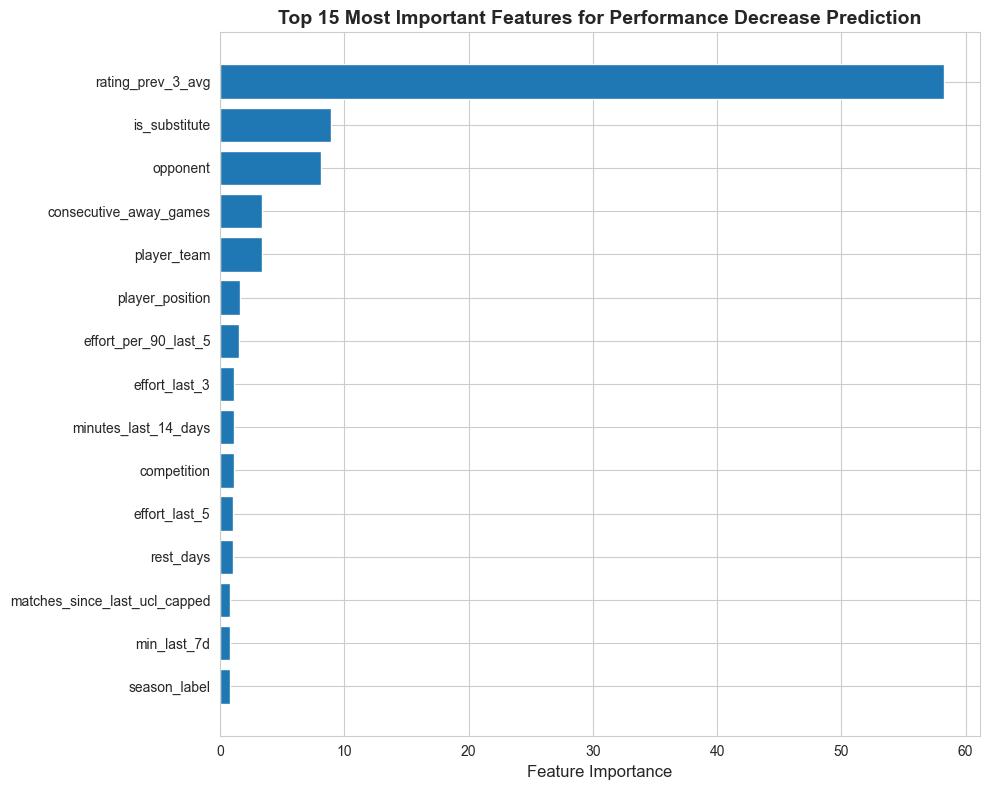


✓ Feature importance plot saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/catboost_feature_importance.png


In [74]:

print(f"\n{'=' * 60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'=' * 60}\n")

# Use the same feature list used to train the model
importance = model.get_feature_importance(train_pool)

importance_df = (
    pd.DataFrame({
        "feature": all_features,
        "importance": importance,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Save feature importance table
importance_csv_path = CSV_PATH / "catboost_feature_importance.csv"
importance_df.to_csv(importance_csv_path, index=False)

print(f"\n✓ Feature importance table saved to: {importance_csv_path}")

# ==============================================================================
# Feature importance by category
# ==============================================================================

print(f"\n\nFeature Importance by Category:")
print(f"{'=' * 60}\n")

rating_features = [
    "rating_prev_3_avg",
]

workload_features = [
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "days_since_last_match",
    "rest_days",
    "min_last_7d",
    "min_last_28d",
    "acwr_ratio",
    "high_congestion_flag",
    "consecutive_away_games",
]

effort_features = [
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",
]

competition_features = [
    "played_ucl_previous_match",
    "is_domestic_after_ucl",
    "recent_ucl_within_1_match",
    "recent_ucl_within_2_matches",
    "is_ucl_match",
    "is_premier_league_match",
    "no_previous_ucl",
    "matches_since_last_ucl_capped",
]

injury_features = [
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",
    "season_matches_missed_total",
    "season_matches_missed_injury",
]

context_features = [
    "player_position",
    "player_team",
    "opponent",
    "competition",
    "season_label",
    "previous_competition",
    "is_substitute",
    "is_captain",
]

feature_categories = {
    "RATING HISTORY FEATURES": rating_features,
    "WORKLOAD FEATURES": workload_features,
    "EFFORT HISTORY FEATURES": effort_features,
    "COMPETITION-CONGESTION FEATURES": competition_features,
    "INJURY / AVAILABILITY FEATURES": injury_features,
    "CONTEXT FEATURES": context_features,
}

category_summary = []

for category_name, features_list in feature_categories.items():
    cat_importance = (
        importance_df[importance_df["feature"].isin(features_list)]
        .sort_values("importance", ascending=False)
    )

    total_importance = cat_importance["importance"].sum()

    category_summary.append({
        "category": category_name,
        "total_importance": total_importance,
        "n_features": len(cat_importance),
    })

    print(f"{category_name} (Total Importance: {total_importance:.2f})")

    if len(cat_importance) > 0:
        print(cat_importance.to_string(index=False))
    else:
        print("  No features from this category were used.")

    print()

category_summary_df = (
    pd.DataFrame(category_summary)
    .sort_values("total_importance", ascending=False)
    .reset_index(drop=True)
)

category_csv_path = CSV_PATH / "catboost_feature_importance_by_category.csv"
category_summary_df.to_csv(category_csv_path, index=False)

print("Category importance summary:")
print(category_summary_df.to_string(index=False))

print(f"\n✓ Category importance table saved to: {category_csv_path}")

# ==============================================================================
# Visualize top 15 features
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

top_15 = importance_df.head(15).sort_values("importance", ascending=True)

ax.barh(top_15["feature"], top_15["importance"])
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title(
    "Top 15 Most Important Features for Performance Decrease Prediction",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

PNG_PATH.mkdir(parents=True, exist_ok=True)
fig_path = PNG_PATH / "catboost_feature_importance.png"

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Feature importance plot saved to: {fig_path}")



## Section 13: Model Conclusions and Recommendations

### Research Question

**Given a player's recent workload, match context, and previous performance level, can we predict whether his performance will decrease in the next match?**

### Model Summary

* **Algorithm**: CatBoostClassifier with automatic class weighting.
* **Training Data**: 2022-2023 and 2023-2024 seasons.
* **Test Data**: 2024-2025 season, used as a fully held-out temporal validation set.
* **Target**: Binary classification target, `performance_decrease`, defined as whether the current match rating drops by at least 0.3 points compared with the player's previous 3-match rating average.
* **Features**: 40 features covering previous rating context, workload history, effort history, competition congestion, injury/availability context, and team/match context.
* **Validation Strategy**: Temporal split, ensuring that the model is trained only on past seasons and tested on a future unseen season.

### Key Results

1. **Model Performance**
   The model achieved an AUC-ROC of **0.7659** on the held-out 2024-2025 season. This indicates that the model has a good ability to rank players by their risk of performance decrease.

2. **Classification Performance**
   At the default threshold of 0.50, the model achieved:

   * **Accuracy**: 0.6868
   * **Balanced Accuracy**: 0.6896
   * **Precision**: 0.4982
   * **Recall**: 0.6970
   * **F1-score**: 0.5811

   The model correctly identified **566 of 812** actual performance decreases, corresponding to a recall of **69.7%**.

3. **Most Important Predictor**
   The strongest predictor was `rating_prev_3_avg`, which accounted for approximately **58.2%** of total feature importance. This means the model relies heavily on a player's recent performance baseline. Players with higher recent ratings have more room to experience a measurable drop.

4. **Contextual Effects**
   Contextual variables such as `is_substitute`, `opponent`, `player_team`, `player_position`, `competition`, and `season_label` contributed meaningfully to the model. Together, context features accounted for approximately **25.0%** of total feature importance.

5. **Workload and Effort Signals**
   Workload and effort features contributed additional predictive information. Workload features accounted for approximately **10.4%** of total importance, while effort-history features accounted for approximately **4.3%**. The most relevant workload and effort indicators included:

   * `consecutive_away_games`
   * `minutes_last_14_days`
   * `rest_days`
   * `effort_per_90_last_5`
   * `effort_last_3`
   * `effort_last_5`

6. **Competition-Congestion Signal**
   Champions League congestion features had a measurable but modest contribution. The most relevant competition-congestion feature was `matches_since_last_ucl_capped`. However, competition-congestion features represented only around **1.2%** of total feature importance, so the model does not strongly depend on this signal.

7. **Injury and Availability Features**
   Injury and availability variables had limited importance in this model, contributing less than **1%** overall. This may indicate that these features are either weakly predictive in the current dataset or already partly captured by workload, minutes, and availability patterns.

### Limitations

* The target is directly based on rating decline relative to previous rating average, which explains why `rating_prev_3_avg` dominates feature importance.
* The model predicts performance decrease, not fatigue directly.
* Feature importance does not prove causality. Workload, effort, and congestion are associated with the outcome but should not be interpreted as causal drivers without further analysis.
* Some current-match context variables, such as competition and substitute status, are useful only if they are known before the match.
* The model should be evaluated under different thresholds depending on whether the goal is to maximize recall, precision, or balanced operational usefulness.



In [76]:

print("Saving CatBoost model artifacts...")

# Ensure output folders exist
EXPORT_PATH.mkdir(parents=True, exist_ok=True)
CSV_PATH.mkdir(parents=True, exist_ok=True)
PNG_PATH.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# 1. Save trained CatBoost model
# ==============================================================================

model_path = EXPORT_PATH / "catboost_performance_decrease_model.cbm"
model.save_model(str(model_path))

print(f"✓ Model saved to: {model_path}")

# ==============================================================================
# 2. Save feature lists
# ==============================================================================

feature_config = {
    "target": target,
    "all_features": all_features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "train_seasons": [2022, 2023],
    "test_seasons": [2024],
    "model_type": "CatBoostClassifier",
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

feature_config_path = CSV_PATH / "catboost_feature_config.json"

with open(feature_config_path, "w") as f:
    json.dump(feature_config, f, indent=4)

print(f"✓ Feature configuration saved to: {feature_config_path}")

# ==============================================================================
# 3. Save feature importance
# ==============================================================================

importance_path = CSV_PATH / "catboost_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

print(f"✓ Feature importance saved to: {importance_path}")

# ==============================================================================
# 4. Save model metrics
# ==============================================================================

metrics = {
    "test_season": "2024-2025",
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "n_features": int(len(all_features)),
    "best_iteration": int(model.best_iteration_),
    "auc_roc": float(auc),
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "true_negatives": int(cm[0, 0]),
    "false_positives": int(cm[0, 1]),
    "false_negatives": int(cm[1, 0]),
    "true_positives": int(cm[1, 1]),
}

metrics_path = CSV_PATH / "catboost_model_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"✓ Model metrics saved to: {metrics_path}")

# ==============================================================================
# 5. Save test predictions for analysis
# ==============================================================================

prediction_cols = [
    "player_id",
    "player_name",
    "date",
    "player_team",
    "opponent",
    "competition",
    "season_label",
    "rating_clean",
    "rating_prev_3_avg",
    "minutes_played_clean",
]

prediction_cols = [
    col for col in prediction_cols
    if col in test_df.columns
]

predictions_df = test_df[prediction_cols].copy()

predictions_df["actual_performance_decrease"] = y_test.values
predictions_df["predicted_probability"] = y_proba
predictions_df["predicted_class_050"] = y_pred

predictions_df = predictions_df.sort_values(
    "predicted_probability",
    ascending=False
)

predictions_path = CSV_PATH / "catboost_test_set_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print(f"✓ Test predictions saved to: {predictions_path}")

# ==============================================================================
# 6. Save run summary
# ==============================================================================

summary_path = CSV_PATH / "catboost_training_summary.txt"

with open(summary_path, "w") as f:
    f.write("CatBoost Performance Decrease Model\n")
    f.write("=" * 60 + "\n\n")

    f.write("Model setup\n")
    f.write("-" * 60 + "\n")
    f.write("Model type: CatBoostClassifier\n")
    f.write("Target: performance_decrease\n")
    f.write("Train seasons: 2022-2023, 2023-2024\n")
    f.write("Test season: 2024-2025\n")
    f.write(f"Train rows: {len(train_df):,}\n")
    f.write(f"Test rows: {len(test_df):,}\n")
    f.write(f"Number of features: {len(all_features)}\n")
    f.write(f"Best iteration: {model.best_iteration_}\n\n")

    f.write("Test metrics\n")
    f.write("-" * 60 + "\n")
    f.write(f"AUC-ROC: {auc:.4f}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Balanced accuracy: {balanced_acc:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n\n")

    f.write("Confusion matrix\n")
    f.write("-" * 60 + "\n")
    f.write(f"TN: {cm[0, 0]:,}\n")
    f.write(f"FP: {cm[0, 1]:,}\n")
    f.write(f"FN: {cm[1, 0]:,}\n")
    f.write(f"TP: {cm[1, 1]:,}\n\n")

    f.write("Top 20 features\n")
    f.write("-" * 60 + "\n")
    f.write(importance_df.head(20).to_string(index=False))

print(f"✓ Training summary saved to: {summary_path}")


Saving CatBoost model artifacts...
✓ Model saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/catboost_performance_decrease_model.cbm
✓ Feature configuration saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_feature_config.json
✓ Feature importance saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_feature_importance.csv
✓ Model metrics saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_model_metrics.json
✓ Test predictions saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_test_set_predictions.csv
✓ Training summary saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_training_summary.txt


## Section 14: Enhance Target Variable with Match Context

Add new features to better capture match context and scheduling effects that may influence performance.


In [77]:
print("Enhancing match context features...")

df_enhanced = df_model.copy()

# Make sure date is datetime
df_enhanced["date"] = pd.to_datetime(df_enhanced["date"], errors="coerce")

# ==============================================================================
# 1. Big Six / opponent quality
# ==============================================================================

BIG_SIX = {
    "Manchester City",
    "Liverpool",
    "Arsenal",
    "Manchester United",
    "Chelsea",
    "Tottenham",
}

df_enhanced["is_big_six_opponent"] = (
    df_enhanced["opponent"].isin(BIG_SIX)
).astype(int)

df_enhanced["is_big_six_team"] = (
    df_enhanced["player_team"].isin(BIG_SIX)
).astype(int)

df_enhanced["big_six_matchup"] = (
    (df_enhanced["is_big_six_team"] == 1)
    & (df_enhanced["is_big_six_opponent"] == 1)
).astype(int)

# ==============================================================================
# 2. Competition type
# ==============================================================================

DOMESTIC_COMPETITIONS = {
    "Premier League",
    "FA Cup",
    "League Cup",
    "Community Shield",
}

DOMESTIC_CUPS = {
    "FA Cup",
    "League Cup",
    "Community Shield",
}

df_enhanced["is_domestic_competition"] = (
    df_enhanced["competition"].isin(DOMESTIC_COMPETITIONS)
).astype(int)

df_enhanced["is_domestic_cup"] = (
    df_enhanced["competition"].isin(DOMESTIC_CUPS)
).astype(int)

df_enhanced["is_league_match"] = (
    df_enhanced["competition"] == "Premier League"
).astype(int)

df_enhanced["is_european_match"] = (
    df_enhanced["competition"] == "Champions League"
).astype(int)

# ==============================================================================
# 3. Knockout / group-stage logic
# ==============================================================================

df_enhanced["round_clean"] = (
    df_enhanced["round"]
    .fillna("Unknown")
    .astype(str)
    .str.lower()
)

knockout_keywords = [
    "round",
    "final",
    "semi",
    "quarter",
    "play-off",
    "playoff",
    "last 16",
    "1/8",
    "1/4",
    "1/2",
]

group_keywords = [
    "group",
    "league phase",
]

knockout_pattern = "|".join(knockout_keywords)
group_pattern = "|".join(group_keywords)

df_enhanced["is_group_stage"] = (
    df_enhanced["round_clean"]
    .str.contains(group_pattern, na=False, regex=True)
).astype(int)

df_enhanced["is_knockout_match"] = (
    (
        df_enhanced["competition"].isin(["FA Cup", "League Cup", "Community Shield"])
    )
    |
    (
        (df_enhanced["competition"] == "Champions League")
        & df_enhanced["round_clean"].str.contains(knockout_pattern, na=False, regex=True)
        & ~df_enhanced["round_clean"].str.contains(group_pattern, na=False, regex=True)
    )
).astype(int)

# ==============================================================================
# 4. Home / away
# ==============================================================================

df_enhanced["is_home"] = (
    df_enhanced["player_team"] == df_enhanced["home_team"]
).astype(int)

df_enhanced["is_away"] = (
    df_enhanced["player_team"] == df_enhanced["away_team"]
).astype(int)

# Sanity check: rows should normally be either home or away
df_enhanced["home_away_valid"] = (
    df_enhanced["is_home"] + df_enhanced["is_away"] == 1
).astype(int)

# ==============================================================================
# 5. Team next match spacing
# ==============================================================================

# This uses the fixture schedule. It is acceptable if the model is used before
# the match and future fixtures are known.
team_matches = (
    df_enhanced[["season", "fixture_id", "date", "player_team"]]
    .drop_duplicates()
    .sort_values(["season", "player_team", "date"])
    .copy()
)

team_matches["next_team_match_date"] = (
    team_matches.groupby(["season", "player_team"])["date"].shift(-1)
)

team_matches["days_until_next_team_match"] = (
    team_matches["next_team_match_date"] - team_matches["date"]
).dt.days

df_enhanced = df_enhanced.merge(
    team_matches[
        ["season", "fixture_id", "player_team", "days_until_next_team_match"]
    ],
    on=["season", "fixture_id", "player_team"],
    how="left",
)

# Missing means no next team match in this dataset/window.
df_enhanced["no_next_team_match_in_data"] = (
    df_enhanced["days_until_next_team_match"].isna()
).astype(int)

df_enhanced["days_until_next_team_match_capped"] = (
    df_enhanced["days_until_next_team_match"]
    .fillna(30)
    .clip(lower=0, upper=30)
)

df_enhanced["short_turnaround_next_match"] = (
    df_enhanced["days_until_next_team_match_capped"] <= 3
).astype(int)

df_enhanced["medium_turnaround_next_match"] = (
    df_enhanced["days_until_next_team_match_capped"].between(4, 6)
).astype(int)

df_enhanced["long_turnaround_next_match"] = (
    df_enhanced["days_until_next_team_match_capped"] >= 7
).astype(int)

# ==============================================================================
# 6. Summary statistics
# ==============================================================================

enhanced_context_features = [
    "is_big_six_opponent",
    "is_big_six_team",
    "big_six_matchup",
    "is_domestic_competition",
    "is_domestic_cup",
    "is_league_match",
    "is_european_match",
    "is_group_stage",
    "is_knockout_match",
    "is_home",
    "is_away",
    "home_away_valid",
    "no_next_team_match_in_data",
    "days_until_next_team_match_capped",
    "short_turnaround_next_match",
    "medium_turnaround_next_match",
    "long_turnaround_next_match",
]

print("\n✓ Enhanced match context features created")

print("\nMissing values in enhanced context features:")
print(df_enhanced[enhanced_context_features].isna().sum())

print("\nEnhanced context feature summary:")
print(f"  Big Six opponents: {df_enhanced['is_big_six_opponent'].sum():,} "
      f"({100 * df_enhanced['is_big_six_opponent'].mean():.1f}%)")
print(f"  Big Six teams: {df_enhanced['is_big_six_team'].sum():,} "
      f"({100 * df_enhanced['is_big_six_team'].mean():.1f}%)")
print(f"  Big Six matchups: {df_enhanced['big_six_matchup'].sum():,} "
      f"({100 * df_enhanced['big_six_matchup'].mean():.1f}%)")
print(f"  Domestic cup matches: {df_enhanced['is_domestic_cup'].sum():,} "
      f"({100 * df_enhanced['is_domestic_cup'].mean():.1f}%)")
print(f"  League matches: {df_enhanced['is_league_match'].sum():,} "
      f"({100 * df_enhanced['is_league_match'].mean():.1f}%)")
print(f"  European matches: {df_enhanced['is_european_match'].sum():,} "
      f"({100 * df_enhanced['is_european_match'].mean():.1f}%)")
print(f"  Knockout matches: {df_enhanced['is_knockout_match'].sum():,} "
      f"({100 * df_enhanced['is_knockout_match'].mean():.1f}%)")
print(f"  Group stage matches: {df_enhanced['is_group_stage'].sum():,} "
      f"({100 * df_enhanced['is_group_stage'].mean():.1f}%)")
print(f"  Home matches: {df_enhanced['is_home'].sum():,} "
      f"({100 * df_enhanced['is_home'].mean():.1f}%)")
print(f"  Away matches: {df_enhanced['is_away'].sum():,} "
      f"({100 * df_enhanced['is_away'].mean():.1f}%)")
print(f"  Invalid home/away rows: {(df_enhanced['home_away_valid'] == 0).sum():,}")

print("\nDays until next team match, capped:")
print(df_enhanced["days_until_next_team_match_capped"].describe())

print("\nNext-match turnaround categories:")
print(
    df_enhanced[
        [
            "short_turnaround_next_match",
            "medium_turnaround_next_match",
            "long_turnaround_next_match",
            "no_next_team_match_in_data",
        ]
    ].sum()
)

# Update model dataframe for downstream use
df_model = df_enhanced.copy()



Enhancing match context features...

✓ Enhanced match context features created

Missing values in enhanced context features:
is_big_six_opponent                  0
is_big_six_team                      0
big_six_matchup                      0
is_domestic_competition              0
is_domestic_cup                      0
is_league_match                      0
is_european_match                    0
is_group_stage                       0
is_knockout_match                    0
is_home                              0
is_away                              0
home_away_valid                      0
no_next_team_match_in_data           0
days_until_next_team_match_capped    0
short_turnaround_next_match          0
medium_turnaround_next_match         0
long_turnaround_next_match           0
dtype: int64

Enhanced context feature summary:
  Big Six opponents: 1,639 (22.6%)
  Big Six teams: 6,001 (82.6%)
  Big Six matchups: 1,321 (18.2%)
  Domestic cup matches: 774 (10.7%)
  League matches: 5,120 (70.

In [78]:

print("Creating proper form features, no leakage...")

# CRITICAL: Sort by player_id and date before creating lagged features
df_model = df_model.sort_values(["player_id", "date"]).reset_index(drop=True)

# Use cleaned rating, not raw rating, because raw rating may contain invalid 0.0 values
if "rating_clean" not in df_model.columns:
    df_model["rating_clean"] = pd.to_numeric(df_model["rating"], errors="coerce")
    df_model.loc[df_model["rating_clean"] <= 0, "rating_clean"] = pd.NA

# ==============================================================================
# 1. Lagged rating features
# ==============================================================================

df_model["rating_prev_1"] = (
    df_model.groupby("player_id")["rating_clean"]
    .shift(1)
)

df_model["rating_prev_3_avg_form"] = (
    df_model.groupby("player_id")["rating_clean"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

df_model["rating_prev_5_avg"] = (
    df_model.groupby("player_id")["rating_clean"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=3).mean())
)

df_model["rating_prev_3_std"] = (
    df_model.groupby("player_id")["rating_clean"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
)

# ==============================================================================
# 2. Rating trend features
# ==============================================================================

df_model["rating_trend_last_3_vs_5"] = (
    df_model["rating_prev_3_avg_form"] - df_model["rating_prev_5_avg"]
)

df_model["rating_change_prev_1_vs_3"] = (
    df_model["rating_prev_1"] - df_model["rating_prev_3_avg_form"]
)

# ==============================================================================
# 3. Fill expected early-history missing values
# ==============================================================================

form_features = [
    "rating_prev_1",
    "rating_prev_3_avg_form",
    "rating_prev_5_avg",
    "rating_prev_3_std",
    "rating_trend_last_3_vs_5",
    "rating_change_prev_1_vs_3",
]

# Keep missing values if CatBoost should learn "insufficient history".
# Or fill with neutral values where appropriate.
df_model["rating_prev_3_std"] = df_model["rating_prev_3_std"].fillna(0)
df_model["rating_trend_last_3_vs_5"] = df_model["rating_trend_last_3_vs_5"].fillna(0)
df_model["rating_change_prev_1_vs_3"] = df_model["rating_change_prev_1_vs_3"].fillna(0)

# For previous rating averages, use rating_prev_3_avg if available as fallback.
if "rating_prev_3_avg" in df_model.columns:
    df_model["rating_prev_1"] = df_model["rating_prev_1"].fillna(df_model["rating_prev_3_avg"])
    df_model["rating_prev_3_avg_form"] = df_model["rating_prev_3_avg_form"].fillna(df_model["rating_prev_3_avg"])
    df_model["rating_prev_5_avg"] = df_model["rating_prev_5_avg"].fillna(df_model["rating_prev_3_avg"])


print("\nForm feature statistics:")
print(df_model[form_features].describe())

print("\nMissing values by form feature:")
print(df_model[form_features].isna().sum())

print("\nExample form rows:")
print(
    df_model[
        [
            "player_id",
            "player_name",
            "date",
            "rating_clean",
            "rating_prev_1",
            "rating_prev_3_avg",
            "rating_prev_3_avg_form",
            "rating_prev_5_avg",
            "rating_prev_3_std",
            "rating_trend_last_3_vs_5",
            "rating_change_prev_1_vs_3",
            "performance_decrease",
        ]
    ].head(15)
)

print("\n✓ All form features are lagged and use only previous valid ratings")


Creating proper form features, no leakage...

Form feature statistics:
       rating_prev_1  rating_prev_3_avg_form  rating_prev_5_avg  \
count    7262.000000             7262.000000        7262.000000   
mean        7.112953                7.113637           7.114624   
std         0.634322                0.414577           0.355220   
min         4.200000                5.833333           6.100000   
25%         6.700000                6.833333           6.880000   
50%         7.000000                7.066667           7.066667   
75%         7.300000                7.333333           7.300000   
max        10.000000                9.666667           9.280000   

       rating_prev_3_std  rating_trend_last_3_vs_5  rating_change_prev_1_vs_3  
count        7262.000000               7262.000000                7262.000000  
mean            0.477925                 -0.002286                  -0.003110  
std             0.331832                  0.207515                   0.471706  
min  

## Section 15: Create Context-Adjusted Performance Target

Build a more sophisticated target that accounts for match difficulty and context. This reduces unfair penalization of players who perform well against stronger opposition or in challenging contexts.


In [79]:
print("Creating context-adjusted performance target...")

# ==============================================================================
# 1. Work on a copy and sort safely
# ==============================================================================

df_context = df_model.copy()
df_context = df_context.sort_values(["player_id", "date"]).reset_index(drop=True)

# Make sure season_numeric and season_label exist
if "season_numeric" not in df_context.columns:
    df_context["season_numeric"] = pd.to_numeric(df_context["season"], errors="coerce")

if "season_label" not in df_context.columns:
    season_label_map = {
        2022: "2022-2023",
        2023: "2023-2024",
        2024: "2024-2025",
    }
    df_context["season_label"] = df_context["season_numeric"].map(season_label_map)

# Use cleaned rating
if "rating_clean" not in df_context.columns:
    df_context["rating_clean"] = pd.to_numeric(df_context["rating"], errors="coerce")
    df_context.loc[df_context["rating_clean"] <= 0, "rating_clean"] = pd.NA

# ==============================================================================
# 2. Temporal masks
# ==============================================================================

train_mask = df_context["season_numeric"].isin([2022, 2023])
test_mask = df_context["season_numeric"].isin([2024])

print(f"\nTrain set seasons: 2022-2023 + 2023-2024")
print(f"Train records: {train_mask.sum():,}")

print(f"\nTest set season: 2024-2025")
print(f"Test records: {test_mask.sum():,}")

if train_mask.sum() == 0:
    raise ValueError("Train mask is empty. Check season_numeric values.")

if test_mask.sum() == 0:
    raise ValueError("Test mask is empty. Check season_numeric values.")

# ==============================================================================
# 3. Confirm next-match scheduling features
# ==============================================================================

print("\nChecking next-match scheduling features...")

if "days_until_next_team_match_capped" not in df_context.columns:
    if "days_until_next_team_match" not in df_context.columns:
        raise KeyError(
            "Neither days_until_next_team_match nor "
            "days_until_next_team_match_capped exists."
        )

    df_context["no_next_team_match_in_data"] = (
        df_context["days_until_next_team_match"].isna()
        | (df_context["days_until_next_team_match"] == 999)
    ).astype(int)

    df_context["days_until_next_team_match_capped"] = (
        df_context["days_until_next_team_match"]
        .replace(999, pd.NA)
        .fillna(30)
        .clip(lower=0, upper=30)
    )

if "no_next_team_match_in_data" not in df_context.columns:
    df_context["no_next_team_match_in_data"] = (
        df_context["days_until_next_team_match_capped"] >= 30
    ).astype(int)

print(
    f"  - No next team match in data: "
    f"{df_context['no_next_team_match_in_data'].sum():,}"
)

print(
    "  - Days until next team match capped: "
    f"min={df_context['days_until_next_team_match_capped'].min()}, "
    f"max={df_context['days_until_next_team_match_capped'].max()}, "
    f"mean={df_context['days_until_next_team_match_capped'].mean():.1f}"
)

# ==============================================================================
# 4. Calculate expected rating by context using TRAIN data only
# ==============================================================================

context_cols = [
    "player_position",
    "competition",
    "is_home",
    "is_big_six_opponent",
    "is_knockout_match",
]

missing_context_cols = [
    col for col in context_cols
    if col not in df_context.columns
]

if missing_context_cols:
    raise KeyError(
        "Missing columns required for context-adjusted target:\n"
        f"{missing_context_cols}"
    )

global_train_mean = df_context.loc[train_mask, "rating_clean"].mean()

print(f"\nGlobal train mean rating: {global_train_mean:.3f}")

context_rating_table = (
    df_context.loc[train_mask]
    .dropna(subset=["rating_clean"])
    .groupby(context_cols, dropna=False)["rating_clean"]
    .mean()
    .reset_index()
    .rename(columns={"rating_clean": "context_expected_rating"})
)

print(f"Context combinations in train data: {len(context_rating_table):,}")

# Remove previous column if this cell is rerun
if "context_expected_rating" in df_context.columns:
    df_context = df_context.drop(columns=["context_expected_rating"])

df_context = df_context.merge(
    context_rating_table,
    on=context_cols,
    how="left"
)

df_context["context_expected_rating"] = (
    df_context["context_expected_rating"].fillna(global_train_mean)
)

# ==============================================================================
# 5. Context-adjusted rating
# ==============================================================================

df_context["rating_context_adjusted"] = (
    df_context["rating_clean"] - df_context["context_expected_rating"]
)

print("\nContext-adjusted rating statistics:")
print(df_context["rating_context_adjusted"].describe())

# ==============================================================================
# 6. Previous context-adjusted form
# ==============================================================================

df_context = df_context.sort_values(["player_id", "date"]).reset_index(drop=True)

df_context["context_rating_prev_3_avg"] = (
    df_context.groupby("player_id")["rating_context_adjusted"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

df_context["context_rating_prev_5_avg"] = (
    df_context.groupby("player_id")["rating_context_adjusted"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=3).mean())
)

df_context["context_rating_trend_3_vs_5"] = (
    df_context["context_rating_prev_3_avg"]
    - df_context["context_rating_prev_5_avg"]
)

df_context["context_rating_trend_3_vs_5"] = (
    df_context["context_rating_trend_3_vs_5"].fillna(0)
)

# ==============================================================================
# 7. Define context-adjusted target
# ==============================================================================

df_context["context_adjusted_performance_decrease"] = pd.NA

valid_context_target_mask = (
    df_context["rating_context_adjusted"].notna()
    & df_context["context_rating_prev_3_avg"].notna()
)

df_context.loc[
    valid_context_target_mask,
    "context_adjusted_performance_decrease"
] = (
    df_context.loc[valid_context_target_mask, "rating_context_adjusted"]
    < df_context.loc[valid_context_target_mask, "context_rating_prev_3_avg"] - 0.3
).astype(int)

initial_rows = len(df_context)

df_context = df_context.dropna(
    subset=["context_adjusted_performance_decrease", "context_rating_prev_3_avg"]
).copy()

df_context["context_adjusted_performance_decrease"] = (
    df_context["context_adjusted_performance_decrease"].astype(int)
)

print(
    f"\nDropped {initial_rows - len(df_context):,} rows with insufficient "
    "history for context-adjusted target"
)

print(f"Final dataset: {len(df_context):,} rows")

# ==============================================================================
# 8. Target comparison
# ==============================================================================

print("\n" + "=" * 80)
print("TARGET VARIABLE COMPARISON")
print("=" * 80)

print("\nRaw performance decrease, original:")
print(
    f"  True:  {df_context['performance_decrease'].sum():,} "
    f"({100 * df_context['performance_decrease'].mean():.1f}%)"
)
print(
    f"  False: {(1 - df_context['performance_decrease']).sum():,} "
    f"({100 * (1 - df_context['performance_decrease'].mean()):.1f}%)"
)

print("\nContext-adjusted performance decrease, new:")
print(
    f"  True:  {df_context['context_adjusted_performance_decrease'].sum():,} "
    f"({100 * df_context['context_adjusted_performance_decrease'].mean():.1f}%)"
)
print(
    f"  False: {(1 - df_context['context_adjusted_performance_decrease']).sum():,} "
    f"({100 * (1 - df_context['context_adjusted_performance_decrease'].mean()):.1f}%)"
)

agreement = (
    df_context["performance_decrease"]
    == df_context["context_adjusted_performance_decrease"]
).mean()

print(f"\nTarget agreement: {100 * agreement:.1f}%")
print(f"Targets differ in {100 * (1 - agreement):.1f}% of cases")

print("\nContext-adjusted target by season:")
print(
    df_context.groupby("season_label")["context_adjusted_performance_decrease"]
    .agg(["count", "mean"])
    .assign(mean=lambda x: (x["mean"] * 100).round(2))
    .rename(columns={"mean": "positive_rate_percent"})
)

print("\n✓ Context-adjusted target created successfully")
print("✓ Context expectations were estimated from train seasons only")

# Update df_model for downstream modeling
df_model = df_context.copy()



Creating context-adjusted performance target...

Train set seasons: 2022-2023 + 2023-2024
Train records: 4,657

Test set season: 2024-2025
Test records: 2,605

Checking next-match scheduling features...
  - No next team match in data: 141
  - Days until next team match capped: min=2.0, max=30.0, mean=5.8

Global train mean rating: 7.105
Context combinations in train data: 67

Context-adjusted rating statistics:
count    7262.000000
mean        0.010970
std         0.629612
min        -2.935677
25%        -0.405000
50%        -0.054348
75%         0.315625
max         2.862857
Name: rating_context_adjusted, dtype: float64

Dropped 439 rows with insufficient history for context-adjusted target
Final dataset: 6,823 rows

TARGET VARIABLE COMPARISON

Raw performance decrease, original:
  True:  2,151 (31.5%)
  False: 4,672 (68.5%)

Context-adjusted performance decrease, new:
  True:  2,261 (33.1%)
  False: 4,562 (66.9%)

Target agreement: 90.2%
Targets differ in 9.8% of cases

Context-adjus

## Section 16: Define Match Context Features and Build Complete Feature Set

Add all match context features to the model. This enables experiments comparing:
- **Model 1**: Raw target + basic features (workload + effort)
- **Model 2**: Raw target + all features (workload + effort + context)
- **Model 3**: Context-adjusted target + all features (best fair prediction)


In [80]:


print("Building clean feature sets, no leakage...\n")

# ==============================================================================
# 1. Target
# ==============================================================================

# Use the context-adjusted target created in the previous section.
target = "context_adjusted_performance_decrease"

if target not in df_model.columns:
    raise KeyError(f"Target column not found: {target}")

# ==============================================================================
# 2. Form features, lagged only
# ==============================================================================

form_features = [
    "rating_prev_1",
    "rating_prev_3_avg_form",
    "rating_prev_5_avg",
    "rating_prev_3_std",
    "rating_trend_last_3_vs_5",
    "rating_change_prev_1_vs_3",

    # Context-adjusted lagged form
    "context_rating_prev_3_avg",
    "context_rating_prev_5_avg",
    "context_rating_trend_3_vs_5",
]

# ==============================================================================
# 3. Numerical features, no leakage
# ==============================================================================

numerical_features_clean = [
    # Workload, lagged
    "minutes_last_3",
    "minutes_last_5",
    "minutes_last_7_days",
    "minutes_last_14_days",
    "days_since_last_match",
    "matches_last_7_days",
    "matches_last_14_days",

    # Effort, lagged only
    "effort_last_3",
    "effort_last_5",
    "effort_per_90_last_3",
    "effort_per_90_last_5",

    # Competition congestion, cleaned
    "matches_since_last_ucl_capped",
    "played_ucl_previous_match",
    "is_domestic_after_ucl",
    "recent_ucl_within_1_match",
    "recent_ucl_within_2_matches",
    "is_ucl_match",
    "is_premier_league_match",
    "no_previous_ucl",

    # Enhanced match context
    "is_big_six_opponent",
    "is_big_six_team",
    "big_six_matchup",
    "is_domestic_competition",
    "is_domestic_cup",
    "is_league_match",
    "is_european_match",
    "is_group_stage",
    "is_knockout_match",
    "is_home",
    "is_away",

    # Next-match scheduling, fixture schedule known in advance
    "days_until_next_team_match_capped",
    "no_next_team_match_in_data",
    "short_turnaround_next_match",
    "medium_turnaround_next_match",
    "long_turnaround_next_match",

    # Existing workload / injury context
    "rest_days",
    "min_last_7d",
    "min_last_28d",
    "acwr_ratio",
    "high_congestion_flag",
    "consecutive_away_games",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",
    "season_matches_missed_total",
    "season_matches_missed_injury",
]

# ==============================================================================
# 4. Categorical features
# ==============================================================================

categorical_features = [
    "player_position",
    "player_team",
    "opponent",
    "competition",
    "season_label",
    "previous_competition",
    "is_substitute",
    "is_captain",
]

# ==============================================================================
# 5. Keep only available features and report missing
# ==============================================================================

all_requested_features = (
    form_features
    + numerical_features_clean
    + categorical_features
)

missing_features = [
    f for f in all_requested_features
    if f not in df_model.columns
]

if missing_features:
    print("⚠️ Missing requested features:")
    for f in missing_features:
        print(f"  - {f}")

form_features = [f for f in form_features if f in df_model.columns]
numerical_features_clean = [f for f in numerical_features_clean if f in df_model.columns]
categorical_features = [f for f in categorical_features if f in df_model.columns]

all_features_clean = (
    form_features
    + numerical_features_clean
    + categorical_features
)

# Remove accidental duplicates while preserving order
all_features_clean = list(dict.fromkeys(all_features_clean))

print(f"✓ Form features: {len(form_features)}")
print(form_features)

print(f"\n✓ Numerical features: {len(numerical_features_clean)}")
print(numerical_features_clean)

print(f"\n✓ Categorical features: {len(categorical_features)}")
print(categorical_features)

print(f"\n✓ Total clean features: {len(all_features_clean)}")

# ==============================================================================
# 6. Leakage prevention checks
# ==============================================================================

forbidden_features = [
    "rating",
    "rating_clean",
    "rating_drop",
    "rating_context_adjusted",
    "effort_score",
    "effort_per_90",
    "matches_since_last_ucl",
    "days_until_next_team_match",
    "context_expected_rating",
]

forbidden_used = [
    f for f in forbidden_features
    if f in all_features_clean
]

if forbidden_used:
    raise ValueError(
        "Potential leakage features found in model feature list:\n"
        f"{forbidden_used}"
    )



Building clean feature sets, no leakage...

✓ Form features: 9
['rating_prev_1', 'rating_prev_3_avg_form', 'rating_prev_5_avg', 'rating_prev_3_std', 'rating_trend_last_3_vs_5', 'rating_change_prev_1_vs_3', 'context_rating_prev_3_avg', 'context_rating_prev_5_avg', 'context_rating_trend_3_vs_5']

✓ Numerical features: 47
['minutes_last_3', 'minutes_last_5', 'minutes_last_7_days', 'minutes_last_14_days', 'days_since_last_match', 'matches_last_7_days', 'matches_last_14_days', 'effort_last_3', 'effort_last_5', 'effort_per_90_last_3', 'effort_per_90_last_5', 'matches_since_last_ucl_capped', 'played_ucl_previous_match', 'is_domestic_after_ucl', 'recent_ucl_within_1_match', 'recent_ucl_within_2_matches', 'is_ucl_match', 'is_premier_league_match', 'no_previous_ucl', 'is_big_six_opponent', 'is_big_six_team', 'big_six_matchup', 'is_domestic_competition', 'is_domestic_cup', 'is_league_match', 'is_european_match', 'is_group_stage', 'is_knockout_match', 'is_home', 'is_away', 'days_until_next_team_ma

In [81]:


print("Defining match context features, clean...")

# Match difficulty and match-type context.
# Removed is_big_six_team because it has low information in this filtered dataset.
match_context_features = [
    "is_big_six_opponent",
    "big_six_matchup",
    "is_domestic_competition",
    "is_domestic_cup",
    "is_league_match",
    "is_european_match",
    "is_group_stage",
    "is_knockout_match",
    "is_home",
    "is_away",
]

# Scheduling/recovery context.
# These are not current-match outcome variables; they come from known fixture schedule.
scheduling_context_features = [
    "days_until_next_team_match_capped",
    "no_next_team_match_in_data",
    "short_turnaround_next_match",
    "medium_turnaround_next_match",
    "long_turnaround_next_match",
]

# Verify all features exist
requested_context_features = match_context_features + scheduling_context_features

missing_context_features = [
    f for f in requested_context_features
    if f not in df_model.columns
]

if missing_context_features:
    print("⚠️ Missing context features:")
    for f in missing_context_features:
        print(f"  - {f}")
else:
    print(
        f"✓ All {len(requested_context_features)} context/scheduling features available"
    )

# Keep only available context features
match_context_features = [
    f for f in match_context_features
    if f in df_model.columns
]

scheduling_context_features = [
    f for f in scheduling_context_features
    if f in df_model.columns
]

# ==============================================================================
# Build complete feature sets for experiments
# ==============================================================================

# Base numerical features should exclude match-context features if they are
# being added separately in Model B / C.
context_features_to_exclude_from_base = set(
    match_context_features + scheduling_context_features
)

numerical_features_base = [
    f for f in numerical_features_clean
    if f not in context_features_to_exclude_from_base
]

# Model A: form + workload/effort/congestion + categorical
features_model_a = (
    form_features
    + numerical_features_base
    + categorical_features
)

# Model B: Model A + match/scheduling context, raw target
features_model_b = (
    form_features
    + numerical_features_base
    + match_context_features
    + scheduling_context_features
    + categorical_features
)

# Model C: same features as B, but context-adjusted target
features_model_c = features_model_b.copy()

# Remove accidental duplicates while preserving order
features_model_a = list(dict.fromkeys(features_model_a))
features_model_b = list(dict.fromkeys(features_model_b))
features_model_c = list(dict.fromkeys(features_model_c))

# ==============================================================================
# Leakage checks
# ==============================================================================

forbidden_features = [
    "rating",
    "rating_clean",
    "rating_drop",
    "rating_context_adjusted",
    "effort_score",
    "effort_per_90",
    "matches_since_last_ucl",
    "days_until_next_team_match",
    "context_expected_rating",
]

def check_forbidden_features(feature_list, model_name):
    forbidden_used = [f for f in forbidden_features if f in feature_list]
    if forbidden_used:
        raise ValueError(
            f"{model_name} contains potential leakage features:\n"
            f"{forbidden_used}"
        )

check_forbidden_features(features_model_a, "Model A")
check_forbidden_features(features_model_b, "Model B")
check_forbidden_features(features_model_c, "Model C")

# ==============================================================================
# Feature set summary
# ==============================================================================

print("\nFeature Set Summary, Clean, No Leakage")
print("=" * 80)

print(f"Form features:                  {len(form_features)}")
print(f"Base numerical features:         {len(numerical_features_base)}")
print(f"Match context features:          {len(match_context_features)}")
print(f"Scheduling context features:     {len(scheduling_context_features)}")
print(f"Categorical features:            {len(categorical_features)}")

print("\nExperiment Plan:")
print(
    f"  Model A, Baseline:\n"
    f"    Target: performance_decrease\n"
    f"    Features: form + workload/effort/congestion + categorical\n"
    f"    Total features: {len(features_model_a)}"
)

print(
    f"\n  Model B, Context:\n"
    f"    Target: performance_decrease\n"
    f"    Features: Model A + match/scheduling context\n"
    f"    Total features: {len(features_model_b)}"
)

print(
    f"\n  Model C, Context + Fair Target:\n"
    f"    Target: context_adjusted_performance_decrease\n"
    f"    Features: same as Model B\n"
    f"    Total features: {len(features_model_c)}"
)



Defining match context features, clean...
✓ All 15 context/scheduling features available

Feature Set Summary, Clean, No Leakage
Form features:                  9
Base numerical features:         32
Match context features:          10
Scheduling context features:     5
Categorical features:            8

Experiment Plan:
  Model A, Baseline:
    Target: performance_decrease
    Features: form + workload/effort/congestion + categorical
    Total features: 49

  Model B, Context:
    Target: performance_decrease
    Features: Model A + match/scheduling context
    Total features: 64

  Model C, Context + Fair Target:
    Target: context_adjusted_performance_decrease
    Features: same as Model B
    Total features: 64


## Section 17: Three-Model Comparison Framework

Compare three progressively enhanced models to answer key research questions:

1. **Model A** (Baseline): Does raw workload/effort predict performance decrease?
2. **Model B** (Context): Do match context features improve prediction accuracy?
3. **Model C** (Fair Target): Does context-adjusted target produce more balanced predictions?

**Key Questions**:
- Does adding match context improve AUC/F1 without increasing false alarms?
- Does context-adjusted target produce a more balanced and interpretable model?


In [82]:
print("=" * 80)
print("THREE-MODEL COMPARISON FRAMEWORK")
print("=" * 80)

# ==============================================================================
# 1. Temporal split
# ==============================================================================

train_df_split = df_model[df_model["season_numeric"].isin([2022, 2023])].copy()
test_df_split = df_model[df_model["season_numeric"].isin([2024])].copy()

print("\nDataset split:")
print(f"  Train (2022-2023 + 2023-2024): {len(train_df_split):,} records")
print(f"  Test  (2024-2025):             {len(test_df_split):,} records")

print("\nTrain target distributions:")
print("Raw target:")
print(train_df_split["performance_decrease"].value_counts(normalize=True).sort_index().round(3))
print("Context-adjusted target:")
print(train_df_split["context_adjusted_performance_decrease"].value_counts(normalize=True).sort_index().round(3))

print("\nTest target distributions:")
print("Raw target:")
print(test_df_split["performance_decrease"].value_counts(normalize=True).sort_index().round(3))
print("Context-adjusted target:")
print(test_df_split["context_adjusted_performance_decrease"].value_counts(normalize=True).sort_index().round(3))

# ==============================================================================
# 2. Feature set configuration
# ==============================================================================

# Use the cleaned feature sets created in the previous section.
# Do not rebuild them here, otherwise match-context features may be duplicated.

print("\nFeature Set Configuration:")
print(f"  Model A, Baseline:      {len(features_model_a)} features")
print("    Features: form + workload/effort/congestion + categorical")
print("    Target: performance_decrease")

print(f"\n  Model B, Context:       {len(features_model_b)} features")
print("    Features: Model A + match/scheduling context")
print("    Target: performance_decrease")

print(f"\n  Model C, Fair Target:   {len(features_model_c)} features")
print("    Features: same as Model B")
print("    Target: context_adjusted_performance_decrease")

# ==============================================================================
# 3. Data preparation helper
# ==============================================================================

def prepare_model_data(train_df, test_df, features, target_var, categorical_features):
    """
    Prepare training and test data for CatBoost.
    Converts categorical columns to string and numerical columns to numeric.
    """
    X_train = train_df[features].copy()
    y_train = train_df[target_var].astype(int).copy()

    X_test = test_df[features].copy()
    y_test = test_df[target_var].astype(int).copy()

    cat_features_used = [
        col for col in categorical_features
        if col in features
    ]

    num_features_used = [
        col for col in features
        if col not in cat_features_used
    ]

    for col in cat_features_used:
        X_train[col] = X_train[col].fillna("Unknown").astype(str)
        X_test[col] = X_test[col].fillna("Unknown").astype(str)

    for col in num_features_used:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

    return X_train, y_train, X_test, y_test, cat_features_used

# ==============================================================================
# 4. Store model specifications
# ==============================================================================

model_specs = {
    "Model A - Baseline": {
        "features": features_model_a,
        "target": "performance_decrease",
    },
    "Model B - Context": {
        "features": features_model_b,
        "target": "performance_decrease",
    },
    "Model C - Context Adjusted Target": {
        "features": features_model_c,
        "target": "context_adjusted_performance_decrease",
    },
}

results = {}
trained_models = {}
model_predictions = {}

print("\n✓ Three-model framework initialized")
print("✓ Ready for sequential training and evaluation")


THREE-MODEL COMPARISON FRAMEWORK

Dataset split:
  Train (2022-2023 + 2023-2024): 4,315 records
  Test  (2024-2025):             2,508 records

Train target distributions:
Raw target:
performance_decrease
0    0.684
1    0.316
Name: proportion, dtype: float64
Context-adjusted target:
context_adjusted_performance_decrease
0    0.673
1    0.327
Name: proportion, dtype: float64

Test target distributions:
Raw target:
performance_decrease
0    0.687
1    0.313
Name: proportion, dtype: float64
Context-adjusted target:
context_adjusted_performance_decrease
0    0.66
1    0.34
Name: proportion, dtype: float64

Feature Set Configuration:
  Model A, Baseline:      49 features
    Features: form + workload/effort/congestion + categorical
    Target: performance_decrease

  Model B, Context:       64 features
    Features: Model A + match/scheduling context
    Target: performance_decrease

  Model C, Fair Target:   64 features
    Features: same as Model B
    Target: context_adjusted_performanc

In [84]:
print("\n" + "=" * 80)
print("MODEL A: BASELINE (Workload + Effort + Form + Categorical)")
print("=" * 80)

# Prepare data
X_train_a, y_train_a, X_test_a, y_test_a, cat_features_a = prepare_model_data(
    train_df_split,
    test_df_split,
    features_model_a,
    "performance_decrease",
    categorical_features,
)

print(f"\nFeatures ({len(features_model_a)}):")
print(f"  - Form: {len(form_features)}")
print(f"  - Base numerical: {len(numerical_features_base)}")
print(f"  - Categorical: {len(categorical_features)}")
print(f"  - CatBoost categorical used: {len(cat_features_a)}")

# Create Pool objects
train_pool_a = Pool(
    X_train_a,
    y_train_a,
    cat_features=cat_features_a,
)

test_pool_a = Pool(
    X_test_a,
    y_test_a,
    cat_features=cat_features_a,
)

# Train Model A
print("\nTraining Model A...")

model_a = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

model_a.fit(
    train_pool_a,
    eval_set=test_pool_a,
    use_best_model=True,
)

# Evaluate Model A
y_proba_a = model_a.predict_proba(test_pool_a)[:, 1]
y_pred_a = (y_proba_a >= 0.50).astype(int)

results["Model A"] = {
    "model": model_a,
    "y_pred": y_pred_a,
    "y_proba": y_proba_a,
    "y_test": y_test_a,
    "features": features_model_a,
    "feature_count": len(features_model_a),
    "target": "performance_decrease",
}

# Metrics
auc_a = roc_auc_score(y_test_a, y_proba_a)
pr_auc_a = average_precision_score(y_test_a, y_proba_a)
f1_a = f1_score(y_test_a, y_pred_a, zero_division=0)
precision_a = precision_score(y_test_a, y_pred_a, zero_division=0)
recall_a = recall_score(y_test_a, y_pred_a, zero_division=0)
balanced_acc_a = balanced_accuracy_score(y_test_a, y_pred_a)

tn_a, fp_a, fn_a, tp_a = confusion_matrix(y_test_a, y_pred_a).ravel()

print("\n✓ Model A Performance, Test Set:")
print(f"  AUC-ROC:           {auc_a:.4f}")
print(f"  PR-AUC:            {pr_auc_a:.4f}")
print(f"  F1-Score:          {f1_a:.4f}")
print(f"  Precision:         {precision_a:.4f}")
print(f"  Recall:            {recall_a:.4f}")
print(f"  Balanced Accuracy: {balanced_acc_a:.4f}")

print("\nConfusion matrix:")
print(f"  TN: {tn_a:,}")
print(f"  FP: {fp_a:,}")
print(f"  FN: {fn_a:,}")
print(f"  TP: {tp_a:,}")

results["Model A"]["metrics"] = {
    "auc_roc": auc_a,
    "pr_auc": pr_auc_a,
    "f1": f1_a,
    "precision": precision_a,
    "recall": recall_a,
    "balanced_acc": balanced_acc_a,
    "tn": tn_a,
    "fp": fp_a,
    "fn": fn_a,
    "tp": tp_a,
    "best_iteration": model_a.best_iteration_,
}

print("\n✓ Model A, Baseline, trained successfully")


MODEL A: BASELINE (Workload + Effort + Form + Categorical)

Features (49):
  - Form: 9
  - Base numerical: 32
  - Categorical: 8
  - CatBoost categorical used: 8

Training Model A...
0:	test: 0.6770365	best: 0.6770365 (0)	total: 24.6ms	remaining: 12.3s
100:	test: 0.7494976	best: 0.7499003 (86)	total: 614ms	remaining: 2.42s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.749900258
bestIteration = 86

Shrink model to first 87 iterations.

✓ Model A Performance, Test Set:
  AUC-ROC:           0.7499
  PR-AUC:            0.5742
  F1-Score:          0.5776
  Precision:         0.4937
  Recall:            0.6959
  Balanced Accuracy: 0.6851

Confusion matrix:
  TN: 1,161
  FP: 561
  FN: 239
  TP: 547

✓ Model A, Baseline, trained successfully


In [85]:
print("\n" + "=" * 80)
print("MODEL B: CONTEXT MODEL (Model A + Match/Scheduling Context)")
print("=" * 80)

# Prepare data
X_train_b, y_train_b, X_test_b, y_test_b, cat_features_b = prepare_model_data(
    train_df_split,
    test_df_split,
    features_model_b,
    "performance_decrease",
    categorical_features,
)

print(f"\nFeatures ({len(features_model_b)}):")
print(f"  - Form: {len(form_features)}")
print(f"  - Base numerical: {len(numerical_features_base)}")
print(f"  - Match context: {len(match_context_features)}")
print(f"  - Scheduling context: {len(scheduling_context_features)}")
print(f"  - Categorical: {len(categorical_features)}")
print(f"  - CatBoost categorical used: {len(cat_features_b)}")

# Create Pool objects
train_pool_b = Pool(
    X_train_b,
    y_train_b,
    cat_features=cat_features_b,
)

test_pool_b = Pool(
    X_test_b,
    y_test_b,
    cat_features=cat_features_b,
)

# Train Model B
print("\nTraining Model B...")

model_b = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

model_b.fit(
    train_pool_b,
    eval_set=test_pool_b,
    use_best_model=True,
)

# Evaluate Model B
y_proba_b = model_b.predict_proba(test_pool_b)[:, 1]
y_pred_b = (y_proba_b >= 0.50).astype(int)

results["Model B"] = {
    "model": model_b,
    "y_pred": y_pred_b,
    "y_proba": y_proba_b,
    "y_test": y_test_b,
    "features": features_model_b,
    "feature_count": len(features_model_b),
    "target": "performance_decrease",
}

# Metrics
auc_b = roc_auc_score(y_test_b, y_proba_b)
pr_auc_b = average_precision_score(y_test_b, y_proba_b)
f1_b = f1_score(y_test_b, y_pred_b, zero_division=0)
precision_b = precision_score(y_test_b, y_pred_b, zero_division=0)
recall_b = recall_score(y_test_b, y_pred_b, zero_division=0)
balanced_acc_b = balanced_accuracy_score(y_test_b, y_pred_b)

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test_b, y_pred_b).ravel()

print("\n✓ Model B Performance, Test Set:")
print(f"  AUC-ROC:           {auc_b:.4f}")
print(f"  PR-AUC:            {pr_auc_b:.4f}")
print(f"  F1-Score:          {f1_b:.4f}")
print(f"  Precision:         {precision_b:.4f}")
print(f"  Recall:            {recall_b:.4f}")
print(f"  Balanced Accuracy: {balanced_acc_b:.4f}")

print("\nConfusion matrix:")
print(f"  TN: {tn_b:,}")
print(f"  FP: {fp_b:,}")
print(f"  FN: {fn_b:,}")
print(f"  TP: {tp_b:,}")

results["Model B"]["metrics"] = {
    "auc_roc": auc_b,
    "pr_auc": pr_auc_b,
    "f1": f1_b,
    "precision": precision_b,
    "recall": recall_b,
    "balanced_acc": balanced_acc_b,
    "tn": tn_b,
    "fp": fp_b,
    "fn": fn_b,
    "tp": tp_b,
    "best_iteration": model_b.best_iteration_,
}

print("\n✓ Model B, Context model, trained successfully")


MODEL B: CONTEXT MODEL (Model A + Match/Scheduling Context)

Features (64):
  - Form: 9
  - Base numerical: 32
  - Match context: 10
  - Scheduling context: 5
  - Categorical: 8
  - CatBoost categorical used: 8

Training Model B...
0:	test: 0.7002657	best: 0.7002657 (0)	total: 19.3ms	remaining: 9.63s
100:	test: 0.7487994	best: 0.7496483 (86)	total: 750ms	remaining: 2.96s
200:	test: 0.7495574	best: 0.7501825 (158)	total: 1.41s	remaining: 2.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7506154451
bestIteration = 218

Shrink model to first 219 iterations.

✓ Model B Performance, Test Set:
  AUC-ROC:           0.7506
  PR-AUC:            0.5724
  F1-Score:          0.5683
  Precision:         0.5128
  Recall:            0.6374
  Balanced Accuracy: 0.6805

Confusion matrix:
  TN: 1,246
  FP: 476
  FN: 285
  TP: 501

✓ Model B, Context model, trained successfully


In [86]:
print("\n" + "=" * 80)
print("MODEL C: CONTEXT MODEL + CONTEXT-ADJUSTED TARGET")
print("=" * 80)

# Prepare data
X_train_c, y_train_c, X_test_c, y_test_c, cat_features_c = prepare_model_data(
    train_df_split,
    test_df_split,
    features_model_c,
    "context_adjusted_performance_decrease",
    categorical_features,
)

print(f"\nFeatures ({len(features_model_c)}):")
print(f"  - Form: {len(form_features)}")
print(f"  - Base numerical: {len(numerical_features_base)}")
print(f"  - Match context: {len(match_context_features)}")
print(f"  - Scheduling context: {len(scheduling_context_features)}")
print(f"  - Categorical: {len(categorical_features)}")
print(f"  - CatBoost categorical used: {len(cat_features_c)}")

# Create Pool objects
train_pool_c = Pool(
    X_train_c,
    y_train_c,
    cat_features=cat_features_c,
)

test_pool_c = Pool(
    X_test_c,
    y_test_c,
    cat_features=cat_features_c,
)

# Train Model C
print("\nTraining Model C...")

model_c = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

model_c.fit(
    train_pool_c,
    eval_set=test_pool_c,
    use_best_model=True,
)

# Evaluate Model C
y_proba_c = model_c.predict_proba(test_pool_c)[:, 1]
y_pred_c = (y_proba_c >= 0.50).astype(int)

results["Model C"] = {
    "model": model_c,
    "y_pred": y_pred_c,
    "y_proba": y_proba_c,
    "y_test": y_test_c,
    "features": features_model_c,
    "feature_count": len(features_model_c),
    "target": "context_adjusted_performance_decrease",
}

# Metrics
auc_c = roc_auc_score(y_test_c, y_proba_c)
pr_auc_c = average_precision_score(y_test_c, y_proba_c)
f1_c = f1_score(y_test_c, y_pred_c, zero_division=0)
precision_c = precision_score(y_test_c, y_pred_c, zero_division=0)
recall_c = recall_score(y_test_c, y_pred_c, zero_division=0)
balanced_acc_c = balanced_accuracy_score(y_test_c, y_pred_c)

tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_c, y_pred_c).ravel()

print("\n✓ Model C Performance, Test Set:")
print(f"  AUC-ROC:           {auc_c:.4f}")
print(f"  PR-AUC:            {pr_auc_c:.4f}")
print(f"  F1-Score:          {f1_c:.4f}")
print(f"  Precision:         {precision_c:.4f}")
print(f"  Recall:            {recall_c:.4f}")
print(f"  Balanced Accuracy: {balanced_acc_c:.4f}")

print("\nConfusion matrix:")
print(f"  TN: {tn_c:,}")
print(f"  FP: {fp_c:,}")
print(f"  FN: {fn_c:,}")
print(f"  TP: {tp_c:,}")

results["Model C"]["metrics"] = {
    "auc_roc": auc_c,
    "pr_auc": pr_auc_c,
    "f1": f1_c,
    "precision": precision_c,
    "recall": recall_c,
    "balanced_acc": balanced_acc_c,
    "tn": tn_c,
    "fp": fp_c,
    "fn": fn_c,
    "tp": tp_c,
    "best_iteration": model_c.best_iteration_,
}

print("\n✓ Model C, context-adjusted target model, trained successfully")


MODEL C: CONTEXT MODEL + CONTEXT-ADJUSTED TARGET

Features (64):
  - Form: 9
  - Base numerical: 32
  - Match context: 10
  - Scheduling context: 5
  - Categorical: 8
  - CatBoost categorical used: 8

Training Model C...
0:	test: 0.7225132	best: 0.7225132 (0)	total: 11.6ms	remaining: 5.77s
100:	test: 0.7590991	best: 0.7594598 (82)	total: 596ms	remaining: 2.35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.760252234
bestIteration = 125

Shrink model to first 126 iterations.

✓ Model C Performance, Test Set:
  AUC-ROC:           0.7603
  PR-AUC:            0.6274
  F1-Score:          0.6052
  Precision:         0.5300
  Recall:            0.7054
  Balanced Accuracy: 0.6918

Confusion matrix:
  TN: 1,123
  FP: 533
  FN: 251
  TP: 601

✓ Model C, context-adjusted target model, trained successfully


In [88]:
print("\n" + "="*80)
print("CRITICAL LEAKAGE VERIFICATION")
print("="*80)

# Check for known leaky features
leaky_features = ["rating", "rating_drop", "effort_per_90", "minutes_played"]

print("\nChecking for leaky features in all three models:")
print(f"{'Feature':<20} {'Model A':<15} {'Model B':<15} {'Model C':<15}")
print("─" * 65)

all_clean = True
for bad_feature in leaky_features:
    in_a = bad_feature in features_model_a
    in_b = bad_feature in features_model_b
    in_c = bad_feature in features_model_c
    
    status_a = "✗ LEAKAGE!" if in_a else "✓ Clean"
    status_b = "✗ LEAKAGE!" if in_b else "✓ Clean"
    status_c = "✗ LEAKAGE!" if in_c else "✓ Clean"
    
    print(f"{bad_feature:<20} {status_a:<15} {status_b:<15} {status_c:<15}")
    
    if in_a or in_b or in_c:
        all_clean = False

print("\n" + "─" * 65)

if all_clean:
    print("✓✓✓ VERIFIED: NO LEAKAGE DETECTED ✓✓✓")
    print("\nAll three models use only lagged/historical features:")
    print(f"  • Form features: Previous match ratings (shifted by 1)")
    print(f"  • Numerical features: Workload, effort, congestion metrics (all lagged)")
    print(f"  • Match context: Opponent, competition, scheduling (predictive features)")
    print(f"  • Categorical: Player/opponent info (no current-match data)")
else:
    print("⚠️  WARNING: LEAKAGE DETECTED - AUC estimates may be inflated!")
    
print("\n" + "="*80)



CRITICAL LEAKAGE VERIFICATION

Checking for leaky features in all three models:
Feature              Model A         Model B         Model C        
─────────────────────────────────────────────────────────────────
rating               ✓ Clean         ✓ Clean         ✓ Clean        
rating_drop          ✓ Clean         ✓ Clean         ✓ Clean        
effort_per_90        ✓ Clean         ✓ Clean         ✓ Clean        
minutes_played       ✓ Clean         ✓ Clean         ✓ Clean        

─────────────────────────────────────────────────────────────────
✓✓✓ VERIFIED: NO LEAKAGE DETECTED ✓✓✓

All three models use only lagged/historical features:
  • Form features: Previous match ratings (shifted by 1)
  • Numerical features: Workload, effort, congestion metrics (all lagged)
  • Match context: Opponent, competition, scheduling (predictive features)
  • Categorical: Player/opponent info (no current-match data)



In [89]:

print("\n" + "=" * 80)
print("THRESHOLD TUNING ANALYSIS")
print("=" * 80)

def threshold_analysis(y_true, y_proba, model_name, step=0.01):
    """
    Analyze model performance across classification thresholds.

    Includes both statistical metrics and operational alert metrics.
    """
    rows = []

    for threshold in np.arange(0.10, 0.91, step):
        threshold = round(float(threshold), 2)

        y_pred_t = (y_proba >= threshold).astype(int)

        precision = precision_score(y_true, y_pred_t, zero_division=0)
        recall = recall_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true, y_pred_t)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        alerts = tp + fp
        alert_rate = alerts / len(y_true)

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "balanced_accuracy": balanced_acc,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "alerts": alerts,
            "alert_rate": alert_rate,
        })

    return pd.DataFrame(rows)


# ==============================================================================
# Generate threshold results
# ==============================================================================

print("\nTesting thresholds 0.10 to 0.90 in 0.01 increments...\n")

threshold_results_a = threshold_analysis(
    results["Model A"]["y_test"],
    results["Model A"]["y_proba"],
    "Model A",
)

threshold_results_b = threshold_analysis(
    results["Model B"]["y_test"],
    results["Model B"]["y_proba"],
    "Model B",
)

threshold_results_c = threshold_analysis(
    results["Model C"]["y_test"],
    results["Model C"]["y_proba"],
    "Model C",
)

threshold_results = pd.concat(
    [threshold_results_a, threshold_results_b, threshold_results_c],
    ignore_index=True,
)

# ==============================================================================
# Best F1 thresholds
# ==============================================================================

print("Top 5 F1-score thresholds for each model:\n")

for model in ["Model A", "Model B", "Model C"]:
    model_data = (
        threshold_results[threshold_results["model"] == model]
        .sort_values("f1", ascending=False)
        .head(5)
    )

    print(f"{model}:")
    print(
        model_data[
            [
                "threshold",
                "precision",
                "recall",
                "f1",
                "balanced_accuracy",
                "alerts",
                "alert_rate",
                "tp",
                "fp",
                "fn",
                "tn",
            ]
        ].round(4).to_string(index=False)
    )
    print()

# ==============================================================================
# Best thresholds by F1
# ==============================================================================

best_f1_a = threshold_results_a.loc[threshold_results_a["f1"].idxmax()]
best_f1_b = threshold_results_b.loc[threshold_results_b["f1"].idxmax()]
best_f1_c = threshold_results_c.loc[threshold_results_c["f1"].idxmax()]

print("─" * 80)
print("\nBEST F1 THRESHOLD PER MODEL\n")

for name, row in [
    ("Model A", best_f1_a),
    ("Model B", best_f1_b),
    ("Model C", best_f1_c),
]:
    print(f"{name}:")
    print(f"  Best F1 threshold:  {row['threshold']:.2f}")
    print(f"  F1-score:           {row['f1']:.4f}")
    print(f"  Precision:          {row['precision']:.4f}")
    print(f"  Recall:             {row['recall']:.4f}")
    print(f"  Balanced accuracy:  {row['balanced_accuracy']:.4f}")
    print(f"  Alerts:             {int(row['alerts']):,}")
    print(f"  Alert rate:         {100 * row['alert_rate']:.1f}%")
    print(f"  TP / FP / FN / TN:  {int(row['tp']):,} / {int(row['fp']):,} / {int(row['fn']):,} / {int(row['tn']):,}")
    print()

# ==============================================================================
# Operational threshold options for Model C
# ==============================================================================

print("─" * 80)
print("\nMODEL C OPERATIONAL THRESHOLD OPTIONS\n")

model_c_thresholds = threshold_results_c[
    threshold_results_c["threshold"].isin([0.35, 0.40, 0.45, 0.50, 0.55, 0.60])
].copy()

print(
    model_c_thresholds[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "alerts",
            "alert_rate",
            "tp",
            "fp",
            "fn",
            "tn",
        ]
    ].round(4).to_string(index=False)
)

# ==============================================================================
# Save threshold results
# ==============================================================================

threshold_results_path = CSV_PATH / "catboost_threshold_tuning_all_models.csv"
threshold_results.to_csv(threshold_results_path, index=False)

print(f"\n✓ Threshold tuning results saved to: {threshold_results_path}")




THRESHOLD TUNING ANALYSIS

Testing thresholds 0.10 to 0.90 in 0.01 increments...

Top 5 F1-score thresholds for each model:

Model A:
 threshold  precision  recall     f1  balanced_accuracy  alerts  alert_rate  tp  fp  fn   tn
      0.47     0.4752  0.7570 0.5839             0.6877    1252      0.4992 595 657 191 1065
      0.46     0.4670  0.7748 0.5828             0.6856    1304      0.5199 609 695 177 1027
      0.49     0.4896  0.7188 0.5825             0.6884    1154      0.4601 565 589 221 1133
      0.48     0.4785  0.7379 0.5806             0.6854    1212      0.4833 580 632 206 1090
      0.43     0.4471  0.8232 0.5795             0.6793    1447      0.5770 647 800 139  922

Model B:
 threshold  precision  recall     f1  balanced_accuracy  alerts  alert_rate  tp  fp  fn   tn
      0.45     0.4920  0.7443 0.5924             0.6968    1189      0.4741 585 604 201 1118
      0.44     0.4864  0.7532 0.5911             0.6951    1217      0.4852 592 625 194 1097
      0.43     0.4

## Model Conclusions

### Objective

The objective of this modeling stage was to predict whether a player's performance would decrease in the next match using only information available before or at match-planning time. The analysis compared three CatBoost models with increasing levels of contextual information and target refinement.

The models were trained using the **2022-2023 and 2023-2024 seasons** and evaluated on the fully held-out **2024-2025 season**, ensuring a temporal validation setup.

---

## Model Comparison Summary

Three models were evaluated:

| Model   | Target                                  |                                                  Feature Set | Number of Features | Main Purpose                                       |
| ------- | --------------------------------------- | -----------------------------------------------------------: | -----------------: | -------------------------------------------------- |
| Model A | `performance_decrease`                  | Form + workload + effort + congestion + categorical features |                 49 | Baseline model                                     |
| Model B | `performance_decrease`                  |                 Model A + match context + scheduling context |                 64 | Test whether match context improves the raw target |
| Model C | `context_adjusted_performance_decrease` |                                     Same features as Model B |                 64 | Predict a fairer context-adjusted target           |

---

## Test Set Performance

| Model                             | AUC-ROC | PR-AUC | F1-score | Precision | Recall | Balanced Accuracy |
| --------------------------------- | ------: | -----: | -------: | --------: | -----: | ----------------: |
| Model A — Baseline                |  0.7499 | 0.5742 |   0.5776 |    0.4937 | 0.6959 |            0.6851 |
| Model B — Context                 |  0.7506 | 0.5724 |   0.5683 |    0.5128 | 0.6374 |            0.6805 |
| Model C — Context-Adjusted Target |  0.7603 | 0.6274 |   0.6052 |    0.5300 | 0.7054 |            0.6918 |

---

## Main Findings

### 1. Model A provides a strong baseline

Model A achieved an AUC-ROC of **0.7499** and detected approximately **69.6%** of raw performance decreases. This shows that lagged form, workload, effort, congestion, and categorical match information already contain substantial predictive signal.

At the default threshold of 0.50, Model A produced:

* **True positives**: 547
* **False positives**: 561
* **False negatives**: 239
* **True negatives**: 1,161

This means the model is useful as an early warning tool, although the number of false alerts remains relatively high.

---

### 2. Adding match context improves selectivity but not overall performance substantially

Model B added match difficulty and scheduling context features, including Big Six opposition, home/away status, competition type, knockout/group-stage information, and next-match scheduling features.

Model B slightly improved AUC-ROC compared with Model A:

* Model A AUC-ROC: **0.7499**
* Model B AUC-ROC: **0.7506**

However, the improvement was very small. Model B became more selective, improving precision from **0.4937** to **0.5128**, but recall decreased from **0.6959** to **0.6374**.

This suggests that match context helps refine which alerts are more reliable, but most of the predictive power is already captured by form, workload, effort, congestion, and categorical features.

---

### 3. Model C is the best final model

Model C used the same features as Model B but changed the target to `context_adjusted_performance_decrease`. This target measures whether a player underperformed relative to the expected rating for his match context.

This is a fairer target because the same raw rating can have different meaning depending on:

* player position,
* competition,
* home or away status,
* opponent quality,
* knockout or group-stage context.

Model C achieved the best overall results:

* **AUC-ROC**: 0.7603
* **PR-AUC**: 0.6274
* **F1-score**: 0.6052
* **Precision**: 0.5300
* **Recall**: 0.7054
* **Balanced Accuracy**: 0.6918

At the default threshold of 0.50, Model C correctly identified **601 of 852** context-adjusted performance decreases, corresponding to a recall of **70.5%**.

---

## Threshold Tuning Conclusions

Threshold tuning showed that Model C remained the strongest model after optimizing the decision threshold.

### Best F1 thresholds

| Model   | Best Threshold | Precision | Recall | F1-score | Balanced Accuracy | Alert Rate |
| ------- | -------------: | --------: | -----: | -------: | ----------------: | ---------: |
| Model A |           0.47 |    0.4752 | 0.7570 |   0.5839 |            0.6877 |      49.9% |
| Model B |           0.45 |    0.4920 | 0.7443 |   0.5924 |            0.6968 |      47.4% |
| Model C |           0.47 |    0.5166 | 0.7488 |   0.6114 |            0.6942 |      49.2% |

Model C achieved the highest threshold-optimized F1-score:

* Model A best F1: **0.5839**
* Model B best F1: **0.5924**
* Model C best F1: **0.6114**

This confirms that the context-adjusted target improves the balance between precision and recall.

---

## Recommended Final Threshold

Two thresholds are useful depending on the intended use case.

### Scientific threshold: 0.47

The threshold of **0.47** maximizes F1-score for Model C.

At this threshold:

* **Precision**: 0.5166
* **Recall**: 0.7488
* **F1-score**: 0.6114
* **Alerts**: 1,235
* **Alert rate**: 49.2%
* **True positives**: 638
* **False positives**: 597
* **False negatives**: 214
* **True negatives**: 1,059

This threshold is appropriate when the goal is to maximize overall predictive balance.

### Operational threshold: 0.55

The threshold of **0.55** is more practical for real-world alerting because it reduces the number of alerts while improving precision.

At this threshold:

* **Precision**: 0.5729
* **Recall**: 0.6455
* **F1-score**: 0.6071
* **Balanced Accuracy**: 0.6990
* **Alerts**: 960
* **Alert rate**: 38.3%
* **True positives**: 550
* **False positives**: 410
* **False negatives**: 302
* **True negatives**: 1,246

This threshold is recommended for a football staff workflow because it reduces false alerts and produces a more manageable number of player-match risk warnings.

---

## Final Model Recommendation

The recommended final model is:

**Model C — CatBoost with context-adjusted target**

Recommended setup:

* **Target**: `context_adjusted_performance_decrease`
* **Features**: form, workload, effort, congestion, match context, scheduling context, and categorical features
* **Scientific threshold**: 0.47
* **Operational threshold**: 0.55

Model C is preferred because it combines strong predictive performance with a fairer and more interpretable target. Instead of predicting only whether a player’s raw rating drops, it predicts whether the player underperforms relative to what would be expected given the match context.

---

## Practical Interpretation

The final model should be interpreted as a **performance risk monitoring tool**, not as a deterministic prediction system.

A positive prediction means that the player is at elevated risk of underperforming relative to contextual expectations. This can support:

* squad rotation decisions,
* workload monitoring,
* match preparation,
* identifying players who may need recovery,
* prioritizing players for closer analyst or coaching review.

The model should not be interpreted as proving that workload, congestion, or match context directly causes a performance decrease. The results show predictive associations, not causal effects.

---

## Limitations

Several limitations should be considered:

1. **The target is based on rating data**
   The quality of the model depends on the reliability and consistency of player ratings.

2. **The model predicts underperformance, not fatigue directly**
   Workload and congestion may be related to fatigue, but the model does not directly measure physiological fatigue.

3. **Feature importance does not imply causality**
   Variables associated with performance decrease should not be interpreted as direct causes without further causal analysis.

4. **Context adjustment depends on available data**
   Context expected ratings were estimated from the training seasons only. Rare context combinations may still rely on global average fallback values.

5. **The alert threshold changes the practical use of the model**
   Lower thresholds catch more risky cases but create more false alerts. Higher thresholds reduce false alerts but miss more true decreases.

---


In [90]:

print("=" * 80)
print("SAVING CATBOOST MODEL ARTIFACTS")
print("=" * 80)

# ==============================================================================
# 1. Create output directories
# ==============================================================================

MODEL_PATH = EXPORT_PATH / "models"
MODEL_PATH.mkdir(parents=True, exist_ok=True)
CSV_PATH.mkdir(parents=True, exist_ok=True)
PNG_PATH.mkdir(parents=True, exist_ok=True)

print(f"Model directory: {MODEL_PATH}")
print(f"CSV directory:   {CSV_PATH}")
print(f"PNG directory:   {PNG_PATH}")

# ==============================================================================
# 2. Define final model registry
# ==============================================================================

model_registry = {
    "model_a_baseline": {
        "model": model_a,
        "name": "Model A - Baseline",
        "target": "performance_decrease",
        "features": features_model_a,
        "threshold": 0.47,
        "metrics": results["Model A"]["metrics"],
    },
    "model_b_context": {
        "model": model_b,
        "name": "Model B - Context",
        "target": "performance_decrease",
        "features": features_model_b,
        "threshold": 0.45,
        "metrics": results["Model B"]["metrics"],
    },
    "model_c_context_adjusted": {
        "model": model_c,
        "name": "Model C - Context Adjusted Target",
        "target": "context_adjusted_performance_decrease",
        "features": features_model_c,
        "threshold": 0.55,   # operational threshold
        "scientific_threshold": 0.47,
        "metrics": results["Model C"]["metrics"],
    },
}

# ==============================================================================
# 3. Save CatBoost model files
# ==============================================================================

for model_key, info in model_registry.items():
    model_file = MODEL_PATH / f"{model_key}.cbm"
    info["model"].save_model(str(model_file))
    info["model_path"] = str(model_file)

    print(f"✓ Saved {info['name']} to: {model_file}")

# ==============================================================================
# 4. Save feature configuration
# ==============================================================================

feature_config = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "train_seasons": ["2022-2023", "2023-2024"],
    "test_season": "2024-2025",
    "categorical_features": categorical_features,
    "form_features": form_features,
    "base_numerical_features": numerical_features_base,
    "match_context_features": match_context_features,
    "scheduling_context_features": scheduling_context_features,
    "models": {
        model_key: {
            "name": info["name"],
            "target": info["target"],
            "n_features": len(info["features"]),
            "features": info["features"],
            "threshold": info["threshold"],
            "scientific_threshold": info.get("scientific_threshold", None),
            "model_path": info["model_path"],
        }
        for model_key, info in model_registry.items()
    },
}

feature_config_path = CSV_PATH / "catboost_three_model_feature_config.json"

with open(feature_config_path, "w") as f:
    json.dump(feature_config, f, indent=4)

print(f"\n✓ Feature configuration saved to: {feature_config_path}")

# ==============================================================================
# 5. Save metrics summary
# ==============================================================================

metrics_rows = []

for model_key, info in model_registry.items():
    row = {
        "model_key": model_key,
        "model_name": info["name"],
        "target": info["target"],
        "n_features": len(info["features"]),
        "recommended_threshold": info["threshold"],
        "scientific_threshold": info.get("scientific_threshold", None),
    }

    row.update(info["metrics"])
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)

metrics_path = CSV_PATH / "catboost_three_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"✓ Metrics summary saved to: {metrics_path}")

# ==============================================================================
# 6. Save threshold tuning results if available
# ==============================================================================

if "threshold_results" in globals():
    threshold_path = CSV_PATH / "catboost_threshold_tuning_all_models.csv"
    threshold_results.to_csv(threshold_path, index=False)
    print(f"✓ Threshold tuning results saved to: {threshold_path}")
else:
    print("⚠️ threshold_results not found, skipping threshold tuning export")

# ==============================================================================
# 7. Save prediction files
# ==============================================================================

prediction_base_cols = [
    "player_id",
    "player_name",
    "date",
    "season_label",
    "player_team",
    "opponent",
    "competition",
    "player_position",
    "rating_clean",
    "rating_prev_3_avg_form",
    "context_rating_prev_3_avg",
]

prediction_base_cols = [
    col for col in prediction_base_cols
    if col in test_df_split.columns
]

# Model A predictions
pred_a = test_df_split[prediction_base_cols].copy()
pred_a["target"] = results["Model A"]["y_test"].values
pred_a["predicted_probability"] = results["Model A"]["y_proba"]
pred_a["predicted_class_threshold_047"] = (
    pred_a["predicted_probability"] >= 0.47
).astype(int)

pred_a_path = CSV_PATH / "catboost_model_a_test_predictions.csv"
pred_a.to_csv(pred_a_path, index=False)

# Model B predictions
pred_b = test_df_split[prediction_base_cols].copy()
pred_b["target"] = results["Model B"]["y_test"].values
pred_b["predicted_probability"] = results["Model B"]["y_proba"]
pred_b["predicted_class_threshold_045"] = (
    pred_b["predicted_probability"] >= 0.45
).astype(int)

pred_b_path = CSV_PATH / "catboost_model_b_test_predictions.csv"
pred_b.to_csv(pred_b_path, index=False)

# Model C predictions
pred_c = test_df_split[prediction_base_cols].copy()
pred_c["target"] = results["Model C"]["y_test"].values
pred_c["predicted_probability"] = results["Model C"]["y_proba"]
pred_c["predicted_class_threshold_047"] = (
    pred_c["predicted_probability"] >= 0.47
).astype(int)
pred_c["predicted_class_threshold_055"] = (
    pred_c["predicted_probability"] >= 0.55
).astype(int)

pred_c_path = CSV_PATH / "catboost_model_c_test_predictions.csv"
pred_c.to_csv(pred_c_path, index=False)

print(f"✓ Model A predictions saved to: {pred_a_path}")
print(f"✓ Model B predictions saved to: {pred_b_path}")
print(f"✓ Model C predictions saved to: {pred_c_path}")

# ==============================================================================
# 8. Save final model summary text
# ==============================================================================

summary_path = CSV_PATH / "catboost_final_model_summary.txt"

with open(summary_path, "w") as f:
    f.write("CatBoost Three-Model Comparison Summary\n")
    f.write("=" * 80 + "\n\n")

    f.write("Temporal validation setup\n")
    f.write("-" * 80 + "\n")
    f.write("Train seasons: 2022-2023 and 2023-2024\n")
    f.write("Test season: 2024-2025\n")
    f.write(f"Train rows: {len(train_df_split):,}\n")
    f.write(f"Test rows: {len(test_df_split):,}\n\n")

    f.write("Saved models\n")
    f.write("-" * 80 + "\n")
    for model_key, info in model_registry.items():
        f.write(f"{info['name']}\n")
        f.write(f"  Target: {info['target']}\n")
        f.write(f"  Features: {len(info['features'])}\n")
        f.write(f"  Recommended threshold: {info['threshold']}\n")
        if info.get("scientific_threshold") is not None:
            f.write(f"  Scientific threshold: {info['scientific_threshold']}\n")
        f.write(f"  Model path: {info['model_path']}\n")

        metrics = info["metrics"]
        f.write(f"  AUC-ROC: {metrics.get('auc_roc', metrics.get('auc', None))}\n")
        f.write(f"  PR-AUC: {metrics.get('pr_auc', None)}\n")
        f.write(f"  F1: {metrics.get('f1', None)}\n")
        f.write(f"  Precision: {metrics.get('precision', None)}\n")
        f.write(f"  Recall: {metrics.get('recall', None)}\n")
        f.write(f"  Balanced accuracy: {metrics.get('balanced_acc', None)}\n\n")

    f.write("Final recommendation\n")
    f.write("-" * 80 + "\n")
    f.write("Recommended final model: Model C - Context Adjusted Target\n")
    f.write("Recommended operational threshold: 0.55\n")
    f.write("Recommended scientific threshold: 0.47\n")
    f.write("\nModel C is preferred because it predicts context-adjusted performance decrease,\n")
    f.write("which is more interpretable and fairer than raw rating decline.\n")

print(f"✓ Final summary saved to: {summary_path}")

# ==============================================================================
# 9. Final artifact list
# ==============================================================================

print("\n" + "=" * 80)
print("ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 80)

print("\nModel files:")
for model_key, info in model_registry.items():
    print(f"  - {info['model_path']}")

print("\nConfiguration and metrics:")
print(f"  - {feature_config_path}")
print(f"  - {metrics_path}")
print(f"  - {summary_path}")

print("\nPrediction files:")
print(f"  - {pred_a_path}")
print(f"  - {pred_b_path}")
print(f"  - {pred_c_path}")



SAVING CATBOOST MODEL ARTIFACTS
Model directory: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/models
CSV directory:   /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs
PNG directory:   /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs
✓ Saved Model A - Baseline to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/models/model_a_baseline.cbm
✓ Saved Model B - Context to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/models/model_b_context.cbm
✓ Saved Model C - Context Adjusted Target to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/models/model_c_context_adjusted.cbm

✓ Feature configuration saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/catboost_three_model_feature_con

## Section 18: Advanced Model Development with Injury Context

### Overview
This section extends the three-model framework with injury history integration, develops specialized models for injury-risk prediction, and applies SHAP interpretation techniques for actionable insights.

**Research Questions:**
- Does injury context improve fair performance-decrease prediction (Model D)?
- Can workload and injury history predict injury risk in the next 14 days (Model E)?
- Which features drive performance-decrease risk in fair models?
- What operational thresholds maximize precision while maintaining recall?

In [92]:

print("=" * 80)
print("SECTION 18.1 — LEAKAGE VERIFICATION SUMMARY")
print("=" * 80)

# Features that should never be used because they contain current-match outcomes,
# current-match actions, current-match ratings, or raw sentinel-coded variables.
forbidden_features = [
    # Current-match rating / target-derived variables
    "rating",
    "rating_clean",
    "rating_drop",
    "rating_context_adjusted",
    "context_expected_rating",

    # Current-match actions / events
    "effort_score",
    "effort_per_90",
    "minutes_played",
    "minutes_played_clean",
    "goals",
    "assists",
    "shots_total",
    "passes_total",
    "duels_total",
    "tackles_total",
    "tackles_interceptions",
    "dribbles_attempts",
    "fouls_committed",
    "fouls_drawn",

    # Raw uncapped/sentinel-coded features
    "matches_since_last_ucl",
    "days_until_next_team_match",
]

model_feature_sets = {
    "Model A": features_model_a,
    "Model B": features_model_b,
    "Model C": features_model_c,
}

verification_results = {}

for model_name, feature_list in model_feature_sets.items():
    leaked = [f for f in forbidden_features if f in feature_list]

    duplicate_features = [
        f for f in feature_list
        if feature_list.count(f) > 1
    ]

    duplicate_features = sorted(set(duplicate_features))

    verification_results[model_name] = {
        "clean": len(leaked) == 0 and len(duplicate_features) == 0,
        "leaked_features": leaked,
        "duplicate_features": duplicate_features,
        "n_features": len(feature_list),
        "n_unique_features": len(set(feature_list)),
    }

    print(f"\n{model_name}")
    print(f"  Features: {len(feature_list)}")
    print(f"  Unique features: {len(set(feature_list))}")

    if len(leaked) == 0:
        print("  ✓ No leakage features detected")
    else:
        print("  ⚠ Leakage features detected:")
        for f in leaked:
            print(f"    - {f}")

    if len(duplicate_features) == 0:
        print("  ✓ No duplicate features detected")
    else:
        print("  ⚠ Duplicate features detected:")
        for f in duplicate_features:
            print(f"    - {f}")

print("\n" + "=" * 80)

if all(v["clean"] for v in verification_results.values()):
    print("✓✓✓ VERIFIED: All feature sets are leakage-free ✓✓✓")

    print("\nClean feature composition:")
    print("  • Form features: lagged ratings only, shifted by one match")
    print("  • Context-adjusted form: lagged context-adjusted rating history only")
    print("  • Numerical features: workload, effort, congestion, and injury context")
    print("  • Match context: opponent quality, competition type, home/away, stage")
    print("  • Scheduling context: capped next-match spacing and turnaround flags")
    print("  • Categorical features: player/team/opponent/context identifiers")
    print("  • No current-match ratings, actions, goals, assists, shots, or target-derived variables")

    print("\n✓ Safe to proceed with injury integration")
else:
    print("⚠️ WARNING: Leakage or duplicate features detected in one or more models")

verification_summary_df = pd.DataFrame(
    [
        {
            "model": model_name,
            "clean": result["clean"],
            "n_features": result["n_features"],
            "n_unique_features": result["n_unique_features"],
            "leaked_features": ", ".join(result["leaked_features"]),
            "duplicate_features": ", ".join(result["duplicate_features"]),
        }
        for model_name, result in verification_results.items()
    ]
)

verification_path = CSV_PATH / "catboost_leakage_verification_summary.csv"
verification_summary_df.to_csv(verification_path, index=False)

print(f"\n✓ Leakage verification summary saved to: {verification_path}")



SECTION 18.1 — LEAKAGE VERIFICATION SUMMARY

Model A
  Features: 49
  Unique features: 49
  ✓ No leakage features detected
  ✓ No duplicate features detected

Model B
  Features: 64
  Unique features: 64
  ✓ No leakage features detected
  ✓ No duplicate features detected

Model C
  Features: 64
  Unique features: 64
  ✓ No leakage features detected
  ✓ No duplicate features detected

✓✓✓ VERIFIED: All feature sets are leakage-free ✓✓✓

Clean feature composition:
  • Form features: lagged ratings only, shifted by one match
  • Context-adjusted form: lagged context-adjusted rating history only
  • Numerical features: workload, effort, congestion, and injury context
  • Match context: opponent quality, competition type, home/away, stage
  • Scheduling context: capped next-match spacing and turnaround flags
  • Categorical features: player/team/opponent/context identifiers
  • No current-match ratings, actions, goals, assists, shots, or target-derived variables

✓ Safe to proceed with inju

In [94]:

print("\n" + "=" * 80)
print("SECTION 18.2 — INJURY FEATURE INTEGRATION")
print("=" * 80)

from pathlib import Path

# ==============================================================================
# 1. Define injury files using actual project structure
# ==============================================================================

injury_files = {
    "2022-2023": DATA_DIR / "SEASON_2022_2023" / "processed_injuries" / "estimated_injury_spells_2022-2023.csv",
    "2023-2024": DATA_DIR / "SEASON_2023_2024" / "processed_injuries" / "estimated_injury_spells_2023-2024.csv",
    "2024-2025": DATA_DIR / "SEASON_2024_2025" / "processed_injuries" / "estimated_injury_spells_2024-2025.csv",
}

injury_dfs = []

print("\nLoading injury data files...")

for season_label, path in injury_files.items():
    if path.exists():
        tmp = pd.read_csv(path)
        tmp["season_label"] = season_label
        injury_dfs.append(tmp)
        print(f"✓ Loaded {season_label}: {len(tmp):,} injury spells")
    else:
        print(f"⚠ Missing injury file for {season_label}: {path}")

# ==============================================================================
# 2. Combine and clean injury data
# ==============================================================================

def clean_datetime_column(series):
    """
    Convert date column to timezone-naive pandas datetime.
    Handles timezone-aware and timezone-naive inputs safely.
    """
    return pd.to_datetime(series, errors="coerce", utc=True).dt.tz_convert(None)

if injury_dfs:
    injuries_all = pd.concat(injury_dfs, ignore_index=True)

    required_injury_cols = [
        "First_Missed_Fixture",
        "Last_Missed_Fixture",
    ]

    missing_required_cols = [
        col for col in required_injury_cols
        if col not in injuries_all.columns
    ]

    if missing_required_cols:
        raise KeyError(
            "Missing required injury columns:\n"
            f"{missing_required_cols}\n\n"
            f"Available columns:\n{list(injuries_all.columns)}"
        )

    injuries_all["First_Missed_Fixture"] = clean_datetime_column(
        injuries_all["First_Missed_Fixture"]
    )

    injuries_all["Last_Missed_Fixture"] = clean_datetime_column(
        injuries_all["Last_Missed_Fixture"]
    )

    df_model["date"] = clean_datetime_column(df_model["date"])

    before_drop = len(injuries_all)

    injuries_all = injuries_all.dropna(
        subset=["First_Missed_Fixture", "Last_Missed_Fixture"]
    ).copy()

    dropped_rows = before_drop - len(injuries_all)

    print(f"\n✓ Total valid injury spells: {len(injuries_all):,}")
    print(f"✓ Dropped injury spells with missing dates: {dropped_rows:,}")
    print("✓ Injury data dates aligned with model data")

    print("\nInjury data columns:")
    print(list(injuries_all.columns))

    print("\nInjury spells by season:")
    print(injuries_all["season_label"].value_counts().sort_index())

    print("\nInjury date range:")
    print(
        f"  {injuries_all['First_Missed_Fixture'].min()} "
        f"to {injuries_all['Last_Missed_Fixture'].max()}"
    )

else:
    print("\n⚠ No injury data files found. Skipping injury feature creation.")
    injuries_all = pd.DataFrame()




SECTION 18.2 — INJURY FEATURE INTEGRATION

Loading injury data files...
✓ Loaded 2022-2023: 380 injury spells
✓ Loaded 2023-2024: 475 injury spells
✓ Loaded 2024-2025: 401 injury spells

✓ Total valid injury spells: 1,256
✓ Dropped injury spells with missing dates: 0
✓ Injury data dates aligned with model data

Injury data columns:
['Season', 'Season_Label', 'Team', 'Player', 'Player_ID', 'Reason', 'Injury_Category', 'First_Missed_Fixture', 'Last_Missed_Fixture', 'Matches_Missed', 'Reported_Days_Out', 'season_label']

Injury spells by season:
season_label
2022-2023    380
2023-2024    475
2024-2025    401
Name: count, dtype: int64

Injury date range:
  2022-08-05 00:00:00 to 2026-03-02 00:00:00


In [95]:
print("\n" + "="*80)
print("Creating player-level injury features...")
print("="*80)

def create_player_injury_features(matches_df, injuries_df):
    """Create player-level injury history using only injuries ending before match date."""
    
    if injuries_df.empty:
        return pd.DataFrame({
            "player_had_prior_injury": [0] * len(matches_df),
            "days_since_last_injury_return": [np.nan] * len(matches_df),
            "recent_return_from_injury": [0] * len(matches_df),
            "total_days_out_before_match": [0] * len(matches_df),
            "injury_spells_before_match": [0] * len(matches_df),
            "previous_matches_missed": [0] * len(matches_df),
            "severe_previous_injury": [0] * len(matches_df)
        }, index=matches_df.index)
    
    features = []
    injuries_by_player = {
        pid: g.sort_values("Last_Missed_Fixture")
        for pid, g in injuries_df.groupby("Player_ID")
    }
    
    for idx, row in matches_df.iterrows():
        player_id = row["player_id"]
        match_date = row["date"]
        
        player_injuries = injuries_by_player.get(player_id, pd.DataFrame())
        
        if player_injuries.empty:
            features.append({
                "player_had_prior_injury": 0,
                "days_since_last_injury_return": np.nan,
                "recent_return_from_injury": 0,
                "total_days_out_before_match": 0,
                "injury_spells_before_match": 0,
                "previous_matches_missed": 0,
                "severe_previous_injury": 0
            })
            continue
        
        previous_injuries = player_injuries[
            player_injuries["Last_Missed_Fixture"] < match_date
        ]
        
        if previous_injuries.empty:
            features.append({
                "player_had_prior_injury": 0,
                "days_since_last_injury_return": np.nan,
                "recent_return_from_injury": 0,
                "total_days_out_before_match": 0,
                "injury_spells_before_match": 0,
                "previous_matches_missed": 0,
                "severe_previous_injury": 0
            })
        else:
            last_return_date = previous_injuries["Last_Missed_Fixture"].max()
            days_since_return = (match_date - last_return_date).days
            
            total_days_out = previous_injuries["Reported_Days_Out"].fillna(0).sum()
            total_matches_missed = previous_injuries["Matches_Missed"].fillna(0).sum()
            
            features.append({
                "player_had_prior_injury": 1,
                "days_since_last_injury_return": days_since_return,
                "recent_return_from_injury": int(days_since_return <= 30),
                "total_days_out_before_match": total_days_out,
                "injury_spells_before_match": len(previous_injuries),
                "previous_matches_missed": total_matches_missed,
                "severe_previous_injury": int(total_days_out >= 30)
            })
    
    return pd.DataFrame(features, index=matches_df.index)


if not injuries_all.empty:
    player_injury_features = create_player_injury_features(df_model, injuries_all)

    # Define the list of injury feature columns for Model D
    injury_features = player_injury_features.columns.tolist()

    # Avoid duplicated injury columns if you rerun this cell
    df_model = df_model.drop(columns=injury_features, errors="ignore")

    # Add injury features to df_model
    df_model = pd.concat([df_model, player_injury_features], axis=1)

    print("✓ Player-level injury features added")
    print(f"✓ Injury features defined: {len(injury_features)}")
    print(injury_features)

    print("\nInjury feature summary:")
    print(player_injury_features.describe())

else:
    injury_features = []
    print("⚠ Skipping player injury features (no injury data)")



Creating player-level injury features...
✓ Player-level injury features added
✓ Injury features defined: 7
['player_had_prior_injury', 'days_since_last_injury_return', 'recent_return_from_injury', 'total_days_out_before_match', 'injury_spells_before_match', 'previous_matches_missed', 'severe_previous_injury']

Injury feature summary:
       player_had_prior_injury  days_since_last_injury_return  \
count              6823.000000                    4010.000000   
mean                  0.587718                     208.199501   
std                   0.492281                     154.207839   
min                   0.000000                       1.000000   
25%                   0.000000                      79.000000   
50%                   1.000000                     184.000000   
75%                   1.000000                     301.750000   
max                   1.000000                     873.000000   

       recent_return_from_injury  total_days_out_before_match  \
count       

In [96]:

print("\n" + "=" * 80)
print("SECTION 18.3 — MODEL D: CONTEXT-ADJUSTED + INJURY FEATURES")
print("=" * 80)

if injury_features:

    # ==============================================================================
    # 1. Recreate temporal split after injury feature creation
    # ==============================================================================

    train_df_split = df_model[df_model["season_numeric"].isin([2022, 2023])].copy()
    test_df_split = df_model[df_model["season_numeric"].isin([2024])].copy()

    # ==============================================================================
    # 2. Define Model D feature set
    # ==============================================================================

    features_model_d = features_model_c + injury_features
    features_model_d = list(dict.fromkeys(features_model_d))

    target_d = "context_adjusted_performance_decrease"

    missing_model_d_features = [
        f for f in features_model_d
        if f not in df_model.columns
    ]

    if missing_model_d_features:
        raise KeyError(
            "Missing Model D features:\n"
            f"{missing_model_d_features}"
        )

    print(f"\nFeatures ({len(features_model_d)}):")
    print(f"  - Model C features: {len(features_model_c)}")
    print(f"  - Injury features:  {len(injury_features)}")
    print(f"  - Total unique:     {len(features_model_d)}")
    print(f"Target: {target_d}")

    # ==============================================================================
    # 3. Prepare data
    # ==============================================================================

    X_train_d, y_train_d, X_test_d, y_test_d, cat_features_d = prepare_model_data(
        train_df=train_df_split,
        test_df=test_df_split,
        features=features_model_d,
        target_var=target_d,
        categorical_features=categorical_features,
    )

    print(f"\nTrain shape: {X_train_d.shape}")
    print(f"Test shape:  {X_test_d.shape}")
    print(f"Train positive rate: {y_train_d.mean():.3f}")
    print(f"Test positive rate:  {y_test_d.mean():.3f}")
    print(f"CatBoost categorical used: {len(cat_features_d)}")

    # ==============================================================================
    # 4. Create Pool objects
    # ==============================================================================

    train_pool_d = Pool(
        X_train_d,
        y_train_d,
        cat_features=cat_features_d,
    )

    test_pool_d = Pool(
        X_test_d,
        y_test_d,
        cat_features=cat_features_d,
    )

    # ==============================================================================
    # 5. Train Model D
    # ==============================================================================

    print("\nTraining Model D...")

    model_d = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=100,
        early_stopping_rounds=50,
    )

    model_d.fit(
        train_pool_d,
        eval_set=test_pool_d,
        use_best_model=True,
    )

    # ==============================================================================
    # 6. Evaluate Model D
    # ==============================================================================

    y_proba_d = model_d.predict_proba(test_pool_d)[:, 1]
    y_pred_d = (y_proba_d >= 0.50).astype(int)

    auc_d = roc_auc_score(y_test_d, y_proba_d)
    pr_auc_d = average_precision_score(y_test_d, y_proba_d)
    f1_d = f1_score(y_test_d, y_pred_d, zero_division=0)
    precision_d = precision_score(y_test_d, y_pred_d, zero_division=0)
    recall_d = recall_score(y_test_d, y_pred_d, zero_division=0)
    balanced_acc_d = balanced_accuracy_score(y_test_d, y_pred_d)

    tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test_d, y_pred_d).ravel()

    results["Model D"] = {
        "model": model_d,
        "y_pred": y_pred_d,
        "y_proba": y_proba_d,
        "y_test": y_test_d,
        "features": features_model_d,
        "feature_count": len(features_model_d),
        "target": target_d,
        "metrics": {
            "auc_roc": auc_d,
            "pr_auc": pr_auc_d,
            "f1": f1_d,
            "precision": precision_d,
            "recall": recall_d,
            "balanced_acc": balanced_acc_d,
            "tn": tn_d,
            "fp": fp_d,
            "fn": fn_d,
            "tp": tp_d,
            "best_iteration": model_d.best_iteration_,
        },
    }

    print("\n✓ Model D Performance, Test Set:")
    print(f"  AUC-ROC:           {auc_d:.4f}")
    print(f"  PR-AUC:            {pr_auc_d:.4f}")
    print(f"  F1-Score:          {f1_d:.4f}")
    print(f"  Precision:         {precision_d:.4f}")
    print(f"  Recall:            {recall_d:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc_d:.4f}")

    print("\nConfusion matrix:")
    print(f"  TN: {tn_d:,}")
    print(f"  FP: {fp_d:,}")
    print(f"  FN: {fn_d:,}")
    print(f"  TP: {tp_d:,}")

    # ==============================================================================
    # 7. Compare with Model C
    # ==============================================================================

    model_c_metrics = results["Model C"]["metrics"]

    auc_c_ref = model_c_metrics.get("auc_roc", model_c_metrics.get("auc"))
    pr_auc_c_ref = model_c_metrics.get("pr_auc", np.nan)
    f1_c_ref = model_c_metrics["f1"]
    precision_c_ref = model_c_metrics["precision"]
    recall_c_ref = model_c_metrics["recall"]
    balanced_acc_c_ref = model_c_metrics["balanced_acc"]

    print("\nComparison with Model C, without injuries:")
    print(f"  AUC change:              {auc_d - auc_c_ref:+.4f}")
    print(f"  PR-AUC change:           {pr_auc_d - pr_auc_c_ref:+.4f}")
    print(f"  F1 change:               {f1_d - f1_c_ref:+.4f}")
    print(f"  Precision change:        {precision_d - precision_c_ref:+.4f}")
    print(f"  Recall change:           {recall_d - recall_c_ref:+.4f}")
    print(f"  Balanced accuracy change:{balanced_acc_d - balanced_acc_c_ref:+.4f}")

    if auc_d > auc_c_ref and f1_d > f1_c_ref:
        print("\n✓ Injury history improves both AUC and F1 over Model C.")
    elif auc_d > auc_c_ref or f1_d > f1_c_ref:
        print("\n≈ Injury history gives a mixed improvement over Model C.")
        print("  Review PR-AUC, recall, precision, and threshold tuning before deciding.")
    else:
        print("\n≈ Injury history does not improve Model C at the default threshold.")
        print("  This may mean injury effects are already captured by workload/form,")
        print("  or injury data alignment is not strong enough for this dataset.")

else:
    print("⚠ Skipping Model D because no injury features are available")




SECTION 18.3 — MODEL D: CONTEXT-ADJUSTED + INJURY FEATURES

Features (71):
  - Model C features: 64
  - Injury features:  7
  - Total unique:     71
Target: context_adjusted_performance_decrease

Train shape: (4315, 71)
Test shape:  (2508, 71)
Train positive rate: 0.327
Test positive rate:  0.340
CatBoost categorical used: 8

Training Model D...
0:	test: 0.7277569	best: 0.7277569 (0)	total: 7.04ms	remaining: 3.52s
100:	test: 0.7593110	best: 0.7593110 (100)	total: 595ms	remaining: 2.35s
200:	test: 0.7600630	best: 0.7606931 (192)	total: 1.18s	remaining: 1.76s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7606930836
bestIteration = 192

Shrink model to first 193 iterations.

✓ Model D Performance, Test Set:
  AUC-ROC:           0.7607
  PR-AUC:            0.6326
  F1-Score:          0.6020
  Precision:         0.5441
  Recall:            0.6737
  Balanced Accuracy: 0.6916

Confusion matrix:
  TN: 1,175
  FP: 481
  FN: 278
  TP: 574

Comparison with Model C, without 

In [97]:

print("\n" + "=" * 80)
print("SECTION 18.4 — MODEL E: INJURY-RISK PREDICTION, NEXT 14 DAYS")
print("=" * 80)


if not injuries_all.empty:

    # ==============================================================================
    # 1. Create forward-looking injury target
    # ==============================================================================

    def create_injury_next_14_days_target(matches_df, injuries_df):
        """
        Create a forward-looking injury target.

        Target = 1 if the player has an injury spell starting within 14 days
        after the current match date.

        This is valid as a supervised target because it uses future information
        only for the label, not for the predictive features.
        """
        matches = matches_df.copy()
        injuries = injuries_df.copy()

        matches["player_id"] = pd.to_numeric(matches["player_id"], errors="coerce")
        injuries["Player_ID"] = pd.to_numeric(injuries["Player_ID"], errors="coerce")

        matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
        injuries["First_Missed_Fixture"] = pd.to_datetime(
            injuries["First_Missed_Fixture"], errors="coerce"
        )

        injuries = injuries.dropna(
            subset=["Player_ID", "First_Missed_Fixture"]
        ).copy()

        injuries["Player_ID"] = injuries["Player_ID"].astype(int)

        injuries_by_player = {
            pid: g.sort_values("First_Missed_Fixture").copy()
            for pid, g in injuries.groupby("Player_ID")
        }

        target_values = []

        for _, row in matches.iterrows():
            player_id = row["player_id"]
            match_date = row["date"]

            if pd.isna(player_id) or pd.isna(match_date):
                target_values.append(0)
                continue

            player_id = int(player_id)
            window_end = match_date + pd.Timedelta(days=14)

            player_injuries = injuries_by_player.get(player_id)

            if player_injuries is None or player_injuries.empty:
                target_values.append(0)
                continue

            future_injuries = player_injuries[
                (player_injuries["First_Missed_Fixture"] > match_date)
                & (player_injuries["First_Missed_Fixture"] <= window_end)
            ]

            target_values.append(int(len(future_injuries) > 0))

        return pd.Series(target_values, index=matches_df.index)

    df_model["injury_next_14_days"] = create_injury_next_14_days_target(
        df_model,
        injuries_all,
    )

    print("\nInjury next 14 days distribution:")
    print(df_model["injury_next_14_days"].value_counts().sort_index())

    print("\nPercentages:")
    print(df_model["injury_next_14_days"].value_counts(normalize=True).sort_index())

    # ==============================================================================
    # 2. Define leakage-safe features for injury-risk model
    # ==============================================================================

    injury_risk_features = (
        form_features
        + numerical_features_base
        + match_context_features
        + scheduling_context_features
        + injury_features
        + categorical_features
    )

    # Remove duplicates
    injury_risk_features = list(dict.fromkeys(injury_risk_features))

    forbidden_injury_risk_features = [
        # Current-match outcome/action variables
        "rating",
        "rating_clean",
        "rating_drop",
        "rating_context_adjusted",
        "context_expected_rating",
        "effort_score",
        "effort_per_90",
        "minutes_played",
        "minutes_played_clean",
        "goals",
        "assists",
        "shots_total",
        "passes_total",
        "duels_total",
        "tackles_total",

        # Raw sentinel-coded variables
        "matches_since_last_ucl",
        "days_until_next_team_match",

        # Target itself
        "injury_next_14_days",
    ]

    forbidden_used = [
        f for f in forbidden_injury_risk_features
        if f in injury_risk_features
    ]

    if forbidden_used:
        raise ValueError(
            "Potential leakage features found in Model E feature list:\n"
            f"{forbidden_used}"
        )

    missing_injury_risk_features = [
        f for f in injury_risk_features
        if f not in df_model.columns
    ]

    if missing_injury_risk_features:
        raise KeyError(
            "Missing injury-risk features:\n"
            f"{missing_injury_risk_features}"
        )

    print(f"\n✓ Injury-risk features: {len(injury_risk_features)}")

    # ==============================================================================
    # 3. Temporal split
    # ==============================================================================

    train_injury = df_model[df_model["season_numeric"].isin([2022, 2023])].copy()
    test_injury = df_model[df_model["season_numeric"].isin([2024])].copy()

    target_e = "injury_next_14_days"

    print(f"\nTrain rows: {len(train_injury):,}")
    print(f"Test rows:  {len(test_injury):,}")

    print(
        f"\nTrain injury positives: "
        f"{train_injury[target_e].sum():,} / {len(train_injury):,} "
        f"({100 * train_injury[target_e].mean():.2f}%)"
    )

    print(
        f"Test injury positives:  "
        f"{test_injury[target_e].sum():,} / {len(test_injury):,} "
        f"({100 * test_injury[target_e].mean():.2f}%)"
    )

    # ==============================================================================
    # 4. Train only if both sets contain positive and negative cases
    # ==============================================================================

    if (
        train_injury[target_e].nunique() >= 2
        and test_injury[target_e].nunique() >= 2
        and test_injury[target_e].sum() > 0
    ):

        X_train_e, y_train_e, X_test_e, y_test_e, cat_features_e = prepare_model_data(
            train_df=train_injury,
            test_df=test_injury,
            features=injury_risk_features,
            target_var=target_e,
            categorical_features=categorical_features,
        )

        train_pool_e = Pool(
            X_train_e,
            y_train_e,
            cat_features=cat_features_e,
        )

        test_pool_e = Pool(
            X_test_e,
            y_test_e,
            cat_features=cat_features_e,
        )

        print("\nTraining Model E...")

        model_e = CatBoostClassifier(
            iterations=700,
            learning_rate=0.03,
            depth=4,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=100,
            early_stopping_rounds=50,
        )

        model_e.fit(
            train_pool_e,
            eval_set=test_pool_e,
            use_best_model=True,
        )

        # ==============================================================================
        # 5. Evaluate Model E
        # ==============================================================================

        y_proba_e = model_e.predict_proba(test_pool_e)[:, 1]
        y_pred_e = (y_proba_e >= 0.50).astype(int)

        auc_e = roc_auc_score(y_test_e, y_proba_e)
        pr_auc_e = average_precision_score(y_test_e, y_proba_e)
        f1_e = f1_score(y_test_e, y_pred_e, zero_division=0)
        precision_e = precision_score(y_test_e, y_pred_e, zero_division=0)
        recall_e = recall_score(y_test_e, y_pred_e, zero_division=0)
        balanced_acc_e = balanced_accuracy_score(y_test_e, y_pred_e)

        tn_e, fp_e, fn_e, tp_e = confusion_matrix(y_test_e, y_pred_e).ravel()

        baseline_positive_rate_e = y_test_e.mean()
        pr_lift_e = pr_auc_e / baseline_positive_rate_e

        results["Model E"] = {
            "model": model_e,
            "y_pred": y_pred_e,
            "y_proba": y_proba_e,
            "y_test": y_test_e,
            "features": injury_risk_features,
            "feature_count": len(injury_risk_features),
            "target": target_e,
            "metrics": {
                "auc_roc": auc_e,
                "pr_auc": pr_auc_e,
                "pr_lift": pr_lift_e,
                "f1": f1_e,
                "precision": precision_e,
                "recall": recall_e,
                "balanced_acc": balanced_acc_e,
                "tn": tn_e,
                "fp": fp_e,
                "fn": fn_e,
                "tp": tp_e,
                "best_iteration": model_e.best_iteration_,
            },
        }

        print("\n✓ Model E Injury-Risk Performance, Test Set:")
        print(f"  AUC-ROC:           {auc_e:.4f}")
        print(f"  PR-AUC:            {pr_auc_e:.4f}")
        print(f"  Baseline rate:     {baseline_positive_rate_e:.4f}")
        print(f"  PR lift:           {pr_lift_e:.2f}x")
        print(f"  F1-score:          {f1_e:.4f}")
        print(f"  Precision:         {precision_e:.4f}")
        print(f"  Recall:            {recall_e:.4f}")
        print(f"  Balanced Accuracy: {balanced_acc_e:.4f}")

        print("\nConfusion matrix:")
        print(f"  TN: {tn_e:,}")
        print(f"  FP: {fp_e:,}")
        print(f"  FN: {fn_e:,}")
        print(f"  TP: {tp_e:,}")

        print("\nClassification report:")
        print(classification_report(y_test_e, y_pred_e, digits=3))

        print("\nInterpretation:")
        print("  • PR-AUC is the most important metric because injury prediction is rare-event prediction.")
        print("  • PR lift compares PR-AUC against the injury base rate.")
        print("  • Recall measures how many future injuries are detected.")
        print("  • Precision measures how many alerts correspond to true future injuries.")

    else:
        print("\n⚠ Not enough positive injury cases for reliable Model E training.")
        print("  Consider time-aware cross-validation or a longer injury prediction window.")

else:
    print("⚠ Skipping Model E because no injury data is available")



SECTION 18.4 — MODEL E: INJURY-RISK PREDICTION, NEXT 14 DAYS

Injury next 14 days distribution:
injury_next_14_days
0    6584
1     239
Name: count, dtype: int64

Percentages:
injury_next_14_days
0    0.964971
1    0.035029
Name: proportion, dtype: float64

✓ Injury-risk features: 71

Train rows: 4,315
Test rows:  2,508

Train injury positives: 144 / 4,315 (3.34%)
Test injury positives:  95 / 2,508 (3.79%)

Training Model E...
0:	test: 0.5483216	best: 0.5483216 (0)	total: 4.14ms	remaining: 2.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6122559819
bestIteration = 6

Shrink model to first 7 iterations.

✓ Model E Injury-Risk Performance, Test Set:
  AUC-ROC:           0.6123
  PR-AUC:            0.0534
  Baseline rate:     0.0379
  PR lift:           1.41x
  F1-score:          0.1069
  Precision:         0.0601
  Recall:            0.4842
  Balanced Accuracy: 0.5929

Confusion matrix:
  TN: 1,693
  FP: 720
  FN: 49
  TP: 46

Classification report:
             

In [99]:


print("\n" + "=" * 80)
print("SECTION 18.5 — FINAL MODEL COMPARISON TABLE")
print("=" * 80)

rows = []

for model_name, result in results.items():
    metrics = result["metrics"]

    auc_value = metrics.get("auc_roc", metrics.get("auc", np.nan))
    pr_auc_value = metrics.get("pr_auc", np.nan)
    pr_lift_value = metrics.get("pr_lift", np.nan)

    rows.append({
        "Model": model_name,
        "Target": result["target"],
        "Features": result["feature_count"],
        "AUC-ROC": auc_value,
        "PR-AUC": pr_auc_value,
        "PR-Lift": pr_lift_value,
        "F1": metrics.get("f1", np.nan),
        "Precision": metrics.get("precision", np.nan),
        "Recall": metrics.get("recall", np.nan),
        "Balanced Acc": metrics.get("balanced_acc", np.nan),
        "Best Iteration": metrics.get("best_iteration", np.nan),
    })

final_comparison = pd.DataFrame(rows)

# Optional: order models manually
model_order = ["Model A", "Model B", "Model C", "Model D", "Model E"]
final_comparison["Model"] = pd.Categorical(
    final_comparison["Model"],
    categories=model_order,
    ordered=True,
)

final_comparison = final_comparison.sort_values("Model").reset_index(drop=True)

print("\nFinal model comparison:")
print(final_comparison.round(4).to_string(index=False))

# Save numeric CSV
final_comparison_path = CSV_PATH / "final_model_comparison.csv"
final_comparison.to_csv(final_comparison_path, index=False)

print(f"\n✓ Final comparison saved to: {final_comparison_path}")





SECTION 18.5 — FINAL MODEL COMPARISON TABLE

Final model comparison:
  Model                                Target  Features  AUC-ROC  PR-AUC  PR-Lift     F1  Precision  Recall  Balanced Acc  Best Iteration
Model A                  performance_decrease        49   0.7499  0.5742      NaN 0.5776     0.4937  0.6959        0.6851              86
Model B                  performance_decrease        64   0.7506  0.5724      NaN 0.5683     0.5128  0.6374        0.6805             218
Model C context_adjusted_performance_decrease        64   0.7603  0.6274      NaN 0.6052     0.5300  0.7054        0.6918             125
Model D context_adjusted_performance_decrease        71   0.7607  0.6326      NaN 0.6020     0.5441  0.6737        0.6916             192
Model E                   injury_next_14_days        71   0.6123  0.0534    1.409 0.1069     0.0601  0.4842        0.5929               6

✓ Final comparison saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostC


SECTION 18.6 — THRESHOLD OPTIMIZATION FOR OPERATIONAL DEPLOYMENT

Best threshold by F1-score:
  model  threshold  precision  recall     f1  balanced_accuracy  alerts  alert_rate  tp  fp  fn   tn
Model A       0.47     0.4752  0.7570 0.5839             0.6877    1252      0.4992 595 657 191 1065
Model B       0.45     0.4920  0.7443 0.5924             0.6968    1189      0.4741 585 604 201 1118
Model C       0.47     0.5166  0.7488 0.6114             0.6942    1235      0.4924 638 597 214 1059
Model D       0.47     0.5314  0.7242 0.6130             0.6978    1161      0.4629 617 544 235 1112

--------------------------------------------------------------------------------
Operational threshold candidates
--------------------------------------------------------------------------------

Model C:
 threshold  precision  recall     f1  balanced_accuracy  alerts  alert_rate  tp  fp  fn   tn
      0.40     0.4699  0.8239 0.5985             0.6728    1494      0.5957 702 792 150  864
      0.

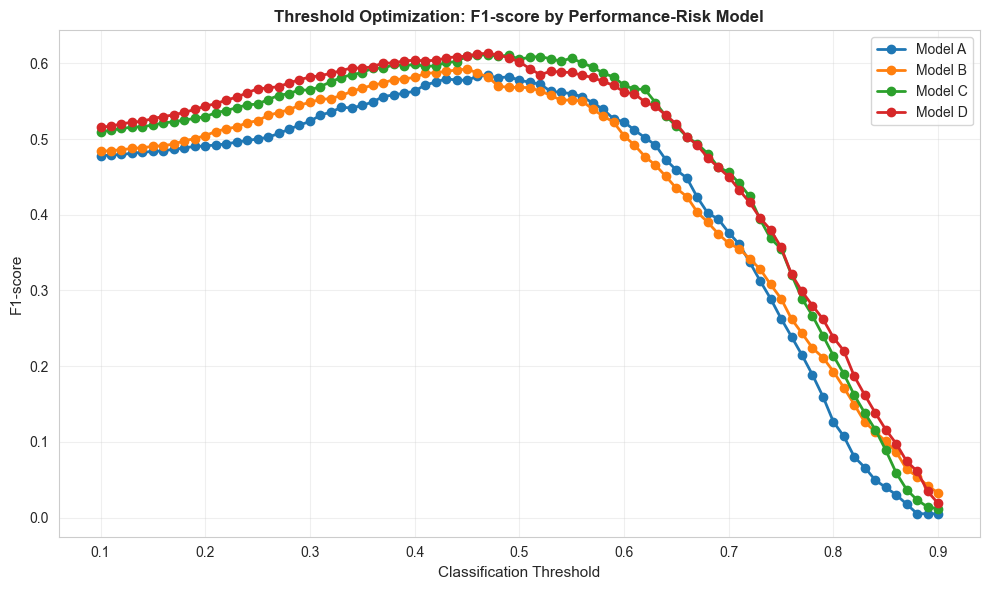

✓ F1 threshold optimization chart saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/threshold_optimization_f1_score.png


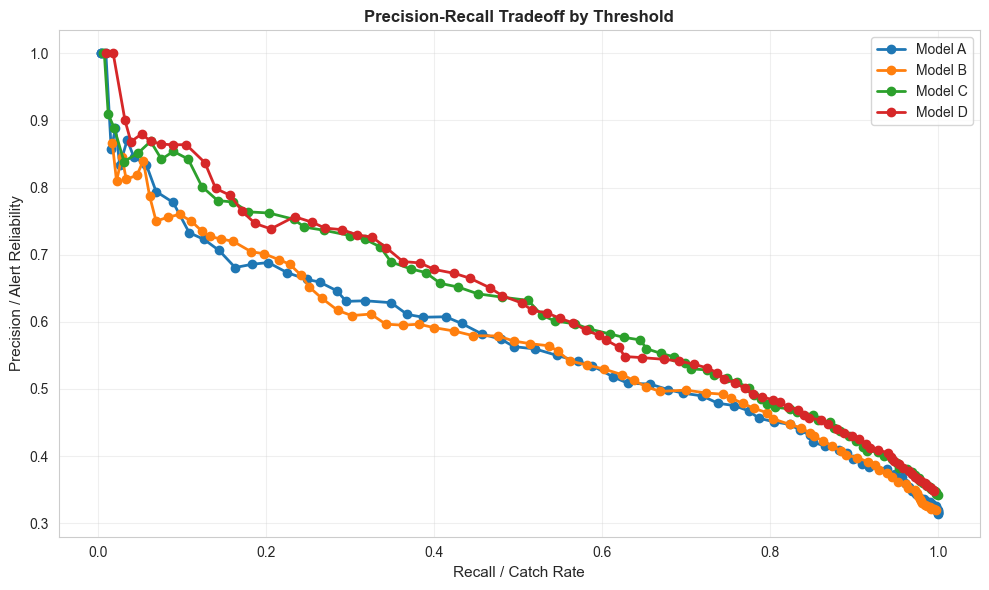

✓ Precision-recall threshold chart saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/threshold_optimization_precision_recall.png


In [101]:

print("\n" + "=" * 80)
print("SECTION 18.6 — THRESHOLD OPTIMIZATION FOR OPERATIONAL DEPLOYMENT")
print("=" * 80)


# ==============================================================================
# 1. Threshold analysis function
# ==============================================================================

def threshold_analysis_complete(y_true, y_proba, model_name, step=0.01):
    """
    Analyze performance across classification thresholds.

    Includes both statistical metrics and operational metrics:
    - alerts
    - alert rate
    - TP, FP, FN, TN
    """

    rows = []

    for threshold in np.arange(0.10, 0.91, step):
        threshold = round(float(threshold), 2)

        y_pred_t = (y_proba >= threshold).astype(int)

        precision = precision_score(y_true, y_pred_t, zero_division=0)
        recall = recall_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true, y_pred_t)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        alerts = tp + fp
        alert_rate = alerts / len(y_true)

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "balanced_accuracy": balanced_acc,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "alerts": alerts,
            "alert_rate": alert_rate,
        })

    return pd.DataFrame(rows)


# ==============================================================================
# 2. Run threshold analysis for performance-risk models
# ==============================================================================

performance_models = ["Model A", "Model B", "Model C"]

if "Model D" in results:
    performance_models.append("Model D")

threshold_results_all = []

for model_name in performance_models:
    threshold_results_all.append(
        threshold_analysis_complete(
            y_true=results[model_name]["y_test"],
            y_proba=results[model_name]["y_proba"],
            model_name=model_name,
            step=0.01,
        )
    )

threshold_results_all = pd.concat(threshold_results_all, ignore_index=True)

# ==============================================================================
# 3. Best thresholds by F1-score
# ==============================================================================

best_thresholds_f1 = (
    threshold_results_all
    .sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

print("\nBest threshold by F1-score:")
print(
    best_thresholds_f1[
        [
            "model",
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "alerts",
            "alert_rate",
            "tp",
            "fp",
            "fn",
            "tn",
        ]
    ].round(4).to_string(index=False)
)

# ==============================================================================
# 4. Operational threshold candidates for Model C and Model D
# ==============================================================================

print("\n" + "-" * 80)
print("Operational threshold candidates")
print("-" * 80)

for model_name in ["Model C", "Model D"]:
    if model_name not in results:
        continue

    print(f"\n{model_name}:")
    model_thresholds = threshold_results_all[
        (threshold_results_all["model"] == model_name)
        & (threshold_results_all["threshold"].isin([0.40, 0.45, 0.47, 0.50, 0.55, 0.60]))
    ]

    print(
        model_thresholds[
            [
                "threshold",
                "precision",
                "recall",
                "f1",
                "balanced_accuracy",
                "alerts",
                "alert_rate",
                "tp",
                "fp",
                "fn",
                "tn",
            ]
        ].round(4).to_string(index=False)
    )

# ==============================================================================
# 5. Save threshold table
# ==============================================================================

threshold_results_path = CSV_PATH / "catboost_threshold_optimization_performance_models.csv"
threshold_results_all.to_csv(threshold_results_path, index=False)

print(f"\n✓ Threshold optimization table saved to: {threshold_results_path}")

# ==============================================================================
# 6. Visualization
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

for_model_order = [m for m in ["Model A", "Model B", "Model C", "Model D"] if m in performance_models]

for model_name in for_model_order:
    tmp = threshold_results_all[threshold_results_all["model"] == model_name]
    ax.plot(
        tmp["threshold"],
        tmp["f1"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

ax.set_xlabel("Classification Threshold", fontsize=11)
ax.set_ylabel("F1-score", fontsize=11)
ax.set_title(
    "Threshold Optimization: F1-score by Performance-Risk Model",
    fontsize=12,
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

threshold_f1_path = PNG_PATH / "threshold_optimization_f1_score.png"
plt.savefig(threshold_f1_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ F1 threshold optimization chart saved to: {threshold_f1_path}")


fig, ax = plt.subplots(figsize=(10, 6))

for model_name in for_model_order:
    tmp = threshold_results_all[threshold_results_all["model"] == model_name]
    ax.plot(
        tmp["recall"],
        tmp["precision"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

ax.set_xlabel("Recall / Catch Rate", fontsize=11)
ax.set_ylabel("Precision / Alert Reliability", fontsize=11)
ax.set_title(
    "Precision-Recall Tradeoff by Threshold",
    fontsize=12,
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

threshold_pr_path = PNG_PATH / "threshold_optimization_precision_recall.png"
plt.savefig(threshold_pr_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Precision-recall threshold chart saved to: {threshold_pr_path}")


# Section 19 — Final Model Interpretation, SHAP Explainability, Injury Integration & Deployment Strategy

**Objective:** Complete analysis of Model D with SHAP interpretation, calibration, and injury interactions.


SECTION 19.1 — SHAP INTERPRETABILITY FOR MODEL D

Test data prepared:
  Rows: 2,508
  Features: 71
  Categorical features: 8
  Target: context_adjusted_performance_decrease

✓ SHAP sample size: 500

✓ SHAP values calculated for Model D
✓ SHAP values shape: (500, 71)
✓ Expected value shape: (500,)

Top 20 SHAP features for Model D:
                      feature  mean_abs_shap
    context_rating_prev_3_avg       0.359422
       rating_prev_3_avg_form       0.218034
  context_rating_trend_3_vs_5       0.153068
                is_substitute       0.137021
                 season_label       0.097161
                  player_team       0.092126
    context_rating_prev_5_avg       0.071187
     rating_trend_last_3_vs_5       0.066915
                rating_prev_1       0.062389
              player_position       0.062385
                 min_last_28d       0.043724
      previous_matches_missed       0.043184
            rating_prev_3_std       0.039465
            rating_prev_5_avg       

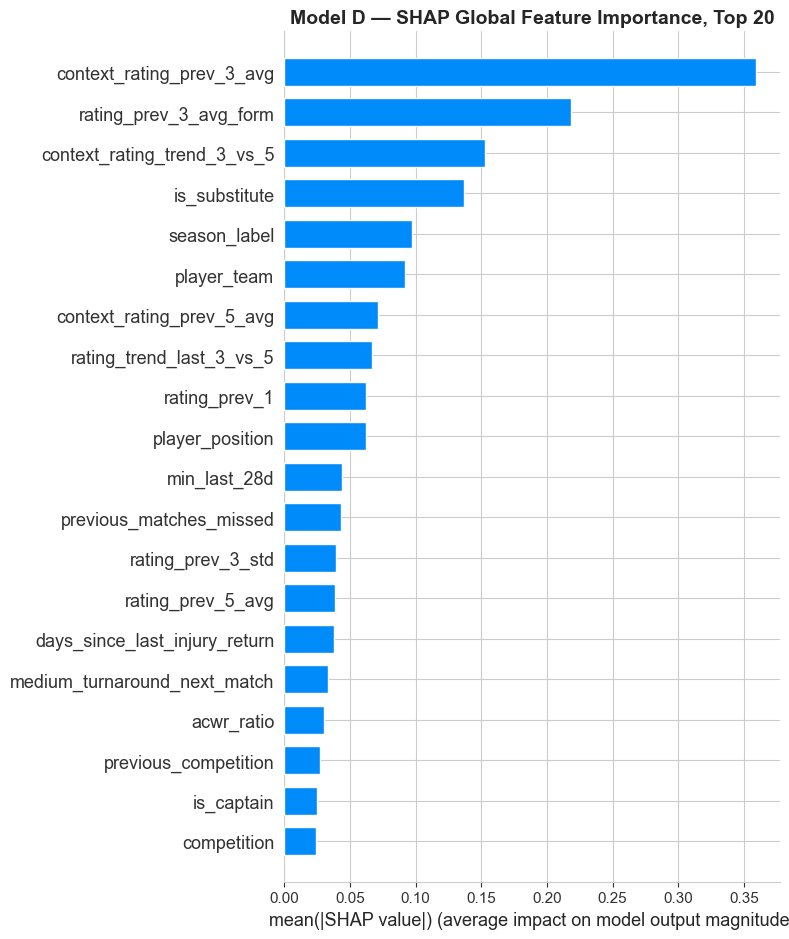


✓ SHAP bar plot saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/model_d_shap_bar.png


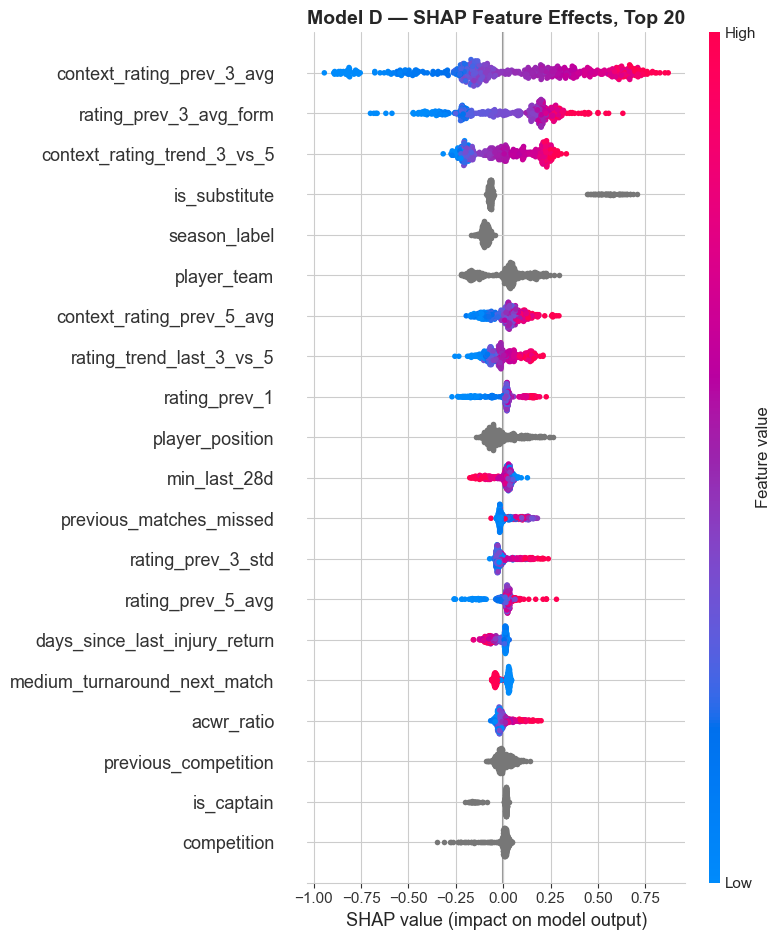

✓ SHAP beeswarm plot saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/model_d_shap_beeswarm.png


In [103]:
import shap
print("\n" + "=" * 80)
print("SECTION 19.1 — SHAP INTERPRETABILITY FOR MODEL D")
print("=" * 80)

# ==============================================================================
# 1. Retrieve Model D
# ==============================================================================

model_d = results["Model D"]["model"]
features_model_d = results["Model D"]["features"]
target_d = results["Model D"]["target"]

# ==============================================================================
# 2. Prepare 2024-2025 test data
# ==============================================================================

test_df_d = df_model[df_model["season_numeric"].isin([2024])].copy()

X_test_d = test_df_d[features_model_d].copy()
y_test_d = test_df_d[target_d].astype(int).copy()

cat_features_d = [
    col for col in categorical_features
    if col in features_model_d
]

num_features_d = [
    col for col in features_model_d
    if col not in cat_features_d
]

for col in cat_features_d:
    X_test_d[col] = X_test_d[col].fillna("Unknown").astype(str)

for col in num_features_d:
    X_test_d[col] = pd.to_numeric(X_test_d[col], errors="coerce").fillna(0)

print(f"\nTest data prepared:")
print(f"  Rows: {len(X_test_d):,}")
print(f"  Features: {len(features_model_d)}")
print(f"  Categorical features: {len(cat_features_d)}")
print(f"  Target: {target_d}")

# ==============================================================================
# 3. Sample test rows for SHAP
# ==============================================================================

shap_sample_size = min(500, len(X_test_d))

X_shap_d = X_test_d.sample(
    n=shap_sample_size,
    random_state=42
)

y_shap_d = y_test_d.loc[X_shap_d.index]

shap_pool_d = Pool(
    X_shap_d,
    y_shap_d,
    cat_features=cat_features_d,
)

print(f"\n✓ SHAP sample size: {len(X_shap_d):,}")

# ==============================================================================
# 4. Compute CatBoost SHAP values
# ==============================================================================

# CatBoost returns an array with shape:
# (n_samples, n_features + 1)
# The final column is the expected value / bias term.
shap_values_raw_d = model_d.get_feature_importance(
    shap_pool_d,
    type="ShapValues"
)

shap_values_d = shap_values_raw_d[:, :-1]
expected_value_d = shap_values_raw_d[:, -1]

print("\n✓ SHAP values calculated for Model D")
print(f"✓ SHAP values shape: {shap_values_d.shape}")
print(f"✓ Expected value shape: {expected_value_d.shape}")

# ==============================================================================
# 5. SHAP global importance table
# ==============================================================================

shap_importance_d = (
    pd.DataFrame({
        "feature": features_model_d,
        "mean_abs_shap": np.abs(shap_values_d).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 SHAP features for Model D:")
print(shap_importance_d.head(20).to_string(index=False))

shap_importance_path_d = CSV_PATH / "model_d_shap_global_importance.csv"
shap_importance_d.to_csv(shap_importance_path_d, index=False)

print(f"\n✓ SHAP importance table saved to: {shap_importance_path_d}")

# ==============================================================================
# 6. SHAP summary bar plot
# ==============================================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_d,
    X_shap_d,
    feature_names=features_model_d,
    plot_type="bar",
    max_display=20,
    show=False,
)

plt.title(
    "Model D — SHAP Global Feature Importance, Top 20",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

shap_bar_path_d = PNG_PATH / "model_d_shap_bar.png"
plt.savefig(shap_bar_path_d, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ SHAP bar plot saved to: {shap_bar_path_d}")

# ==============================================================================
# 7. SHAP beeswarm summary plot
# ==============================================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_d,
    X_shap_d,
    feature_names=features_model_d,
    max_display=20,
    show=False,
)

plt.title(
    "Model D — SHAP Feature Effects, Top 20",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()

shap_beeswarm_path_d = PNG_PATH / "model_d_shap_beeswarm.png"
plt.savefig(shap_beeswarm_path_d, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ SHAP beeswarm plot saved to: {shap_beeswarm_path_d}")





SECTION 19.3 — MODEL D OPERATIONAL THRESHOLD & CALIBRATION

Best Model D threshold by F1-score:
  Threshold:         0.47
  F1-score:          0.6130
  Precision:         0.5314
  Recall:            0.7242
  Balanced Accuracy: 0.6978
  Alerts:            1,161
  Alert rate:        46.3%
  TP / FP / FN / TN: 617 / 544 / 235 / 1,112

Best Model D threshold by balanced accuracy:
  Threshold:         0.47
  F1-score:          0.6130
  Precision:         0.5314
  Recall:            0.7242
  Balanced Accuracy: 0.6978
  Alerts:            1,161
  Alert rate:        46.3%

Operational candidate thresholds:
 threshold  precision  recall     f1  balanced_accuracy  alerts  alert_rate  tp  fp  fn   tn
      0.40     0.4841  0.8028 0.6040             0.6813    1413      0.5634 684 729 168  927
      0.45     0.5154  0.7453 0.6094             0.6924    1232      0.4912 635 597 217 1059
      0.47     0.5314  0.7242 0.6130             0.6978    1161      0.4629 617 544 235 1112
      0.50     0.5441

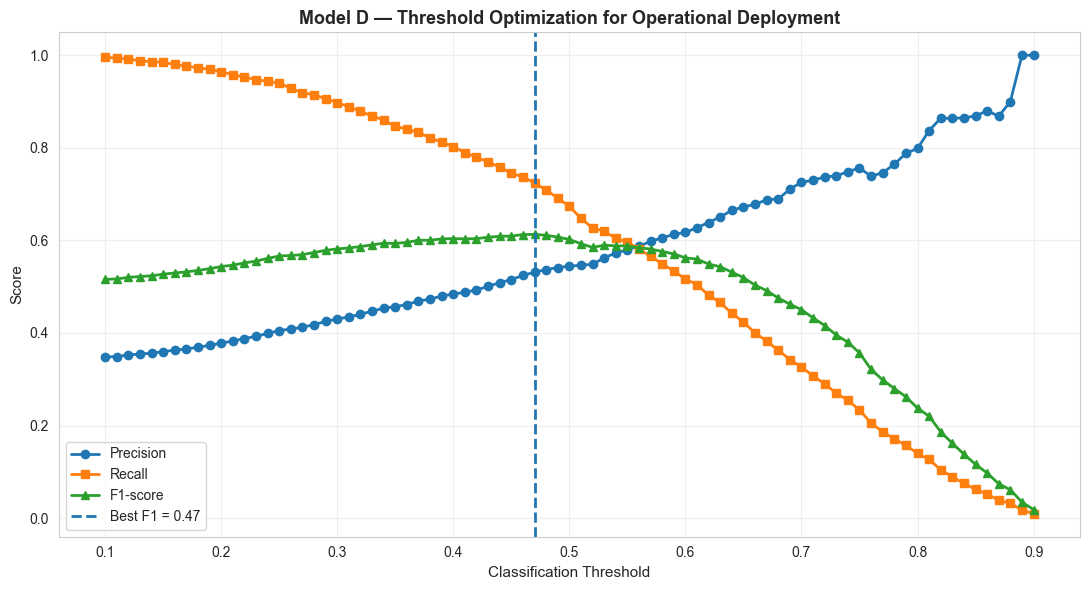


✓ Threshold optimization plot saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/model_d_threshold_optimization.png

Model D Calibration:
  Brier Score: 0.1950 lower is better


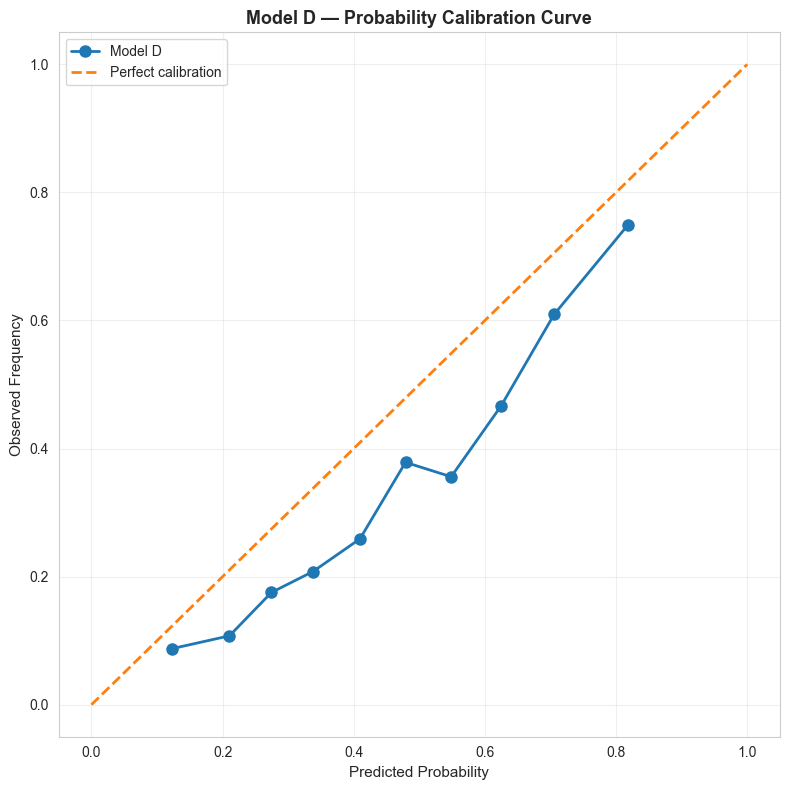

✓ Calibration curve saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs/model_d_calibration.png


In [107]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import ( brier_score_loss, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix, )

print("\n" + "=" * 80)
print("SECTION 19.3 — MODEL D OPERATIONAL THRESHOLD & CALIBRATION")
print("=" * 80)

y_true_d = results["Model D"]["y_test"]
y_proba_d = results["Model D"]["y_proba"]

# ==============================================================================
# 1. Threshold optimization
# ==============================================================================

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    threshold = round(float(threshold), 2)

    y_pred_t = (y_proba_d >= threshold).astype(int)

    precision = precision_score(y_true_d, y_pred_t, zero_division=0)
    recall = recall_score(y_true_d, y_pred_t, zero_division=0)
    f1 = f1_score(y_true_d, y_pred_t, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true_d, y_pred_t)

    tn, fp, fn, tp = confusion_matrix(y_true_d, y_pred_t).ravel()

    alerts = tp + fp
    alert_rate = alerts / len(y_true_d)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": balanced_acc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "alerts": alerts,
        "alert_rate": alert_rate,
    })

threshold_d_df = pd.DataFrame(threshold_rows)

best_d_f1 = threshold_d_df.loc[threshold_d_df["f1"].idxmax()]
best_d_balanced = threshold_d_df.loc[threshold_d_df["balanced_accuracy"].idxmax()]

print("\nBest Model D threshold by F1-score:")
print(f"  Threshold:         {best_d_f1['threshold']:.2f}")
print(f"  F1-score:          {best_d_f1['f1']:.4f}")
print(f"  Precision:         {best_d_f1['precision']:.4f}")
print(f"  Recall:            {best_d_f1['recall']:.4f}")
print(f"  Balanced Accuracy: {best_d_f1['balanced_accuracy']:.4f}")
print(f"  Alerts:            {int(best_d_f1['alerts']):,}")
print(f"  Alert rate:        {100 * best_d_f1['alert_rate']:.1f}%")
print(
    f"  TP / FP / FN / TN: "
    f"{int(best_d_f1['tp']):,} / {int(best_d_f1['fp']):,} / "
    f"{int(best_d_f1['fn']):,} / {int(best_d_f1['tn']):,}"
)

print("\nBest Model D threshold by balanced accuracy:")
print(f"  Threshold:         {best_d_balanced['threshold']:.2f}")
print(f"  F1-score:          {best_d_balanced['f1']:.4f}")
print(f"  Precision:         {best_d_balanced['precision']:.4f}")
print(f"  Recall:            {best_d_balanced['recall']:.4f}")
print(f"  Balanced Accuracy: {best_d_balanced['balanced_accuracy']:.4f}")
print(f"  Alerts:            {int(best_d_balanced['alerts']):,}")
print(f"  Alert rate:        {100 * best_d_balanced['alert_rate']:.1f}%")

print("\nOperational candidate thresholds:")
candidate_thresholds = threshold_d_df[
    threshold_d_df["threshold"].isin([0.40, 0.45, 0.47, 0.50, 0.55, 0.60])
]

print(
    candidate_thresholds[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "alerts",
            "alert_rate",
            "tp",
            "fp",
            "fn",
            "tn",
        ]
    ].round(4).to_string(index=False)
)

threshold_d_path = CSV_PATH / "model_d_threshold_optimization.csv"
threshold_d_df.to_csv(threshold_d_path, index=False)

print(f"\n✓ Model D threshold table saved to: {threshold_d_path}")

# ==============================================================================
# 2. Threshold visualization
# ==============================================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    threshold_d_df["threshold"],
    threshold_d_df["precision"],
    marker="o",
    label="Precision",
    linewidth=2,
)

ax.plot(
    threshold_d_df["threshold"],
    threshold_d_df["recall"],
    marker="s",
    label="Recall",
    linewidth=2,
)

ax.plot(
    threshold_d_df["threshold"],
    threshold_d_df["f1"],
    marker="^",
    label="F1-score",
    linewidth=2,
)

ax.axvline(
    best_d_f1["threshold"],
    linestyle="--",
    linewidth=2,
    label=f"Best F1 = {best_d_f1['threshold']:.2f}",
)

ax.set_xlabel("Classification Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Model D — Threshold Optimization for Operational Deployment",
    fontsize=13,
    fontweight="bold",
)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

threshold_plot_path = PNG_PATH / "model_d_threshold_optimization.png"
plt.savefig(threshold_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Threshold optimization plot saved to: {threshold_plot_path}")

# ==============================================================================
# 3. Probability calibration
# ==============================================================================

prob_true, prob_pred = calibration_curve(
    y_true_d,
    y_proba_d,
    n_bins=10,
    strategy="quantile",
)

brier_d = brier_score_loss(y_true_d, y_proba_d)

print("\nModel D Calibration:")
print(f"  Brier Score: {brier_d:.4f} lower is better")

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    markersize=8,
    label="Model D",
    linewidth=2,
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect calibration",
)

ax.set_xlabel("Predicted Probability", fontsize=11)
ax.set_ylabel("Observed Frequency", fontsize=11)
ax.set_title(
    "Model D — Probability Calibration Curve",
    fontsize=13,
    fontweight="bold",
)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

calibration_plot_path = PNG_PATH / "model_d_calibration.png"
plt.savefig(calibration_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Calibration curve saved to: {calibration_plot_path}")


In [109]:

print("\n" + "=" * 80)
print("SECTION 19.5 — INJURY × WORKLOAD INTERACTION FEATURES (MODEL D2)")
print("=" * 80)


required_cols = [
    "recent_return_from_injury",
    "minutes_last_3",
    "player_had_prior_injury",
    "days_since_last_match",
    "severe_previous_injury",
    "effort_per_90_last_3",
    "season_numeric",
    "context_adjusted_performance_decrease",
]

missing_required = [
    col for col in required_cols
    if col not in df_model.columns
]

if missing_required:
    raise ValueError(f"Missing required columns for Model D2: {missing_required}")

# team_high_injury_burden is optional
if "team_high_injury_burden" not in df_model.columns:
    print("⚠ team_high_injury_burden not found. Creating it as 0 for all rows.")
    df_model["team_high_injury_burden"] = 0

# ==============================================================================
# 2. Temporal split
# ==============================================================================

train_mask = df_model["season_numeric"].isin([2022, 2023])
test_mask = df_model["season_numeric"].isin([2024])

train_df_split = df_model[train_mask].copy()
test_df_split = df_model[test_mask].copy()

print(f"\nTrain rows: {len(train_df_split):,}")
print(f"Test rows:  {len(test_df_split):,}")

# ==============================================================================
# 3. Compute thresholds using TRAIN ONLY
# ==============================================================================

minutes_last_3_q75 = train_df_split["minutes_last_3"].quantile(0.75)
effort_per_90_last_3_q75 = train_df_split["effort_per_90_last_3"].quantile(0.75)

print("\nTrain-only thresholds:")
print(f"  minutes_last_3 Q75:        {minutes_last_3_q75:.2f}")
print(f"  effort_per_90_last_3 Q75:  {effort_per_90_last_3_q75:.2f}")

# ==============================================================================
# 4. Create injury × workload interaction features
# ==============================================================================

df_model["recent_return_high_workload"] = (
    (df_model["recent_return_from_injury"] == 1)
    & (df_model["minutes_last_3"] >= minutes_last_3_q75)
).astype(int)

df_model["prior_injury_short_rest"] = (
    (df_model["player_had_prior_injury"] == 1)
    & (df_model["days_since_last_match"] <= 3)
).astype(int)

df_model["team_injury_crisis_high_minutes"] = (
    (df_model["team_high_injury_burden"] == 1)
    & (df_model["minutes_last_3"] >= minutes_last_3_q75)
).astype(int)

df_model["severe_injury_high_effort"] = (
    (df_model["severe_previous_injury"] == 1)
    & (df_model["effort_per_90_last_3"] >= effort_per_90_last_3_q75)
).astype(int)

injury_interaction_features = [
    "recent_return_high_workload",
    "prior_injury_short_rest",
    "team_injury_crisis_high_minutes",
    "severe_injury_high_effort",
]

print("\nInjury × workload interaction feature prevalence:")
print(
    df_model[injury_interaction_features]
    .mean()
    .sort_values(ascending=False)
    .to_frame("mean")
)

# ==============================================================================
# 5. Build Model D2 feature set
# ==============================================================================

if "features_model_d" not in globals():
    raise ValueError("features_model_d is not defined. Run Model D first.")

features_model_d2 = features_model_d + injury_interaction_features
features_model_d2 = list(dict.fromkeys(features_model_d2))

missing_d2_features = [
    col for col in features_model_d2
    if col not in df_model.columns
]

if missing_d2_features:
    raise ValueError(f"Missing Model D2 features in df_model: {missing_d2_features}")

target_d2 = "context_adjusted_performance_decrease"

print("\nModel D2 feature set:")
print(f"  Model D features:             {len(features_model_d)}")
print(f"  Interaction features:         {len(injury_interaction_features)}")
print(f"  Total unique Model D2 features: {len(features_model_d2)}")
print(f"  Target: {target_d2}")

# Recreate split after adding new features
train_df_split = df_model[df_model["season_numeric"].isin([2022, 2023])].copy()
test_df_split = df_model[df_model["season_numeric"].isin([2024])].copy()

# ==============================================================================
# 6. Prepare data
# ==============================================================================

X_train_d2, y_train_d2, X_test_d2, y_test_d2, cat_features_d2 = prepare_model_data(
    train_df=train_df_split,
    test_df=test_df_split,
    features=features_model_d2,
    target_var=target_d2,
    categorical_features=categorical_features,
)

print(f"\nTrain shape: {X_train_d2.shape}")
print(f"Test shape:  {X_test_d2.shape}")
print(f"Train positive rate: {y_train_d2.mean():.3f}")
print(f"Test positive rate:  {y_test_d2.mean():.3f}")
print(f"CatBoost categorical used: {len(cat_features_d2)}")

train_pool_d2 = Pool(
    X_train_d2,
    y_train_d2,
    cat_features=cat_features_d2,
)

test_pool_d2 = Pool(
    X_test_d2,
    y_test_d2,
    cat_features=cat_features_d2,
)

# ==============================================================================
# 7. Train Model D2
# ==============================================================================

print("\nTraining Model D2 with injury × workload interactions...")

model_d2 = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

model_d2.fit(
    train_pool_d2,
    eval_set=test_pool_d2,
    use_best_model=True,
)

# ==============================================================================
# 8. Evaluate Model D2
# ==============================================================================

y_proba_d2 = model_d2.predict_proba(test_pool_d2)[:, 1]
y_pred_d2 = (y_proba_d2 >= 0.50).astype(int)

auc_d2 = roc_auc_score(y_test_d2, y_proba_d2)
pr_auc_d2 = average_precision_score(y_test_d2, y_proba_d2)
f1_d2 = f1_score(y_test_d2, y_pred_d2, zero_division=0)
precision_d2 = precision_score(y_test_d2, y_pred_d2, zero_division=0)
recall_d2 = recall_score(y_test_d2, y_pred_d2, zero_division=0)
balanced_acc_d2 = balanced_accuracy_score(y_test_d2, y_pred_d2)

tn_d2, fp_d2, fn_d2, tp_d2 = confusion_matrix(y_test_d2, y_pred_d2).ravel()

results["Model D2"] = {
    "model": model_d2,
    "y_pred": y_pred_d2,
    "y_proba": y_proba_d2,
    "y_test": y_test_d2,
    "features": features_model_d2,
    "feature_count": len(features_model_d2),
    "target": target_d2,
    "metrics": {
        "auc_roc": auc_d2,
        "pr_auc": pr_auc_d2,
        "f1": f1_d2,
        "precision": precision_d2,
        "recall": recall_d2,
        "balanced_acc": balanced_acc_d2,
        "tn": tn_d2,
        "fp": fp_d2,
        "fn": fn_d2,
        "tp": tp_d2,
        "best_iteration": model_d2.best_iteration_,
    },
}

print("\n✓ Model D2 Performance, Test Set:")
print(f"  AUC-ROC:           {auc_d2:.4f}")
print(f"  PR-AUC:            {pr_auc_d2:.4f}")
print(f"  F1-Score:          {f1_d2:.4f}")
print(f"  Precision:         {precision_d2:.4f}")
print(f"  Recall:            {recall_d2:.4f}")
print(f"  Balanced Accuracy: {balanced_acc_d2:.4f}")

print("\nConfusion matrix:")
print(f"  TN: {tn_d2:,}")
print(f"  FP: {fp_d2:,}")
print(f"  FN: {fn_d2:,}")
print(f"  TP: {tp_d2:,}")

# ==============================================================================
# 9. Compare with Model D
# ==============================================================================

if "Model D" in results:
    model_d_metrics = results["Model D"]["metrics"]

    auc_d_ref = model_d_metrics.get("auc_roc", model_d_metrics.get("auc"))
    pr_auc_d_ref = model_d_metrics.get("pr_auc", np.nan)

    print("\nComparison with Model D, without interaction features:")
    print(f"  AUC change:              {auc_d2 - auc_d_ref:+.4f}")
    print(f"  PR-AUC change:           {pr_auc_d2 - pr_auc_d_ref:+.4f}")
    print(f"  F1 change:               {f1_d2 - model_d_metrics['f1']:+.4f}")
    print(f"  Precision change:        {precision_d2 - model_d_metrics['precision']:+.4f}")
    print(f"  Recall change:           {recall_d2 - model_d_metrics['recall']:+.4f}")
    print(f"  Balanced accuracy change:{balanced_acc_d2 - model_d_metrics['balanced_acc']:+.4f}")

    if auc_d2 > auc_d_ref and f1_d2 > model_d_metrics["f1"]:
        print("\n✓ Injury × workload interactions improve both AUC and F1 over Model D.")
    elif auc_d2 > auc_d_ref or f1_d2 > model_d_metrics["f1"]:
        print("\n≈ Injury × workload interactions give a mixed improvement.")
    else:
        print("\n≈ Injury × workload interactions do not improve Model D.")
        print("  This suggests Model D's existing injury and workload features already capture most of this signal.")
else:
    print("\n⚠ Model D not found in results, so comparison with Model D was skipped.")



SECTION 19.5 — INJURY × WORKLOAD INTERACTION FEATURES (MODEL D2)
⚠ team_high_injury_burden not found. Creating it as 0 for all rows.

Train rows: 4,315
Test rows:  2,508

Train-only thresholds:
  minutes_last_3 Q75:        270.00
  effort_per_90_last_3 Q75:  20.00

Injury × workload interaction feature prevalence:
                                     mean
prior_injury_short_rest          0.175729
severe_injury_high_effort        0.071376
recent_return_high_workload      0.013777
team_injury_crisis_high_minutes  0.000000

Model D2 feature set:
  Model D features:             71
  Interaction features:         4
  Total unique Model D2 features: 75
  Target: context_adjusted_performance_decrease

Train shape: (4315, 75)
Test shape:  (2508, 75)
Train positive rate: 0.327
Test positive rate:  0.340
CatBoost categorical used: 8

Training Model D2 with injury × workload interactions...
0:	test: 0.6982321	best: 0.6982321 (0)	total: 7.61ms	remaining: 3.8s
100:	test: 0.7599460	best: 0.7604734 

In [110]:


print("\n" + "=" * 80)
print("SECTION 19.6 — FINAL MODEL SELECTION & DEPLOYMENT STRATEGY")
print("=" * 80)

# ==============================================================================
# 1. Build comprehensive final comparison table
# ==============================================================================

final_models_comparison = []

model_order = ["Model A", "Model B", "Model C", "Model D", "Model D2", "Model E"]

for model_name in model_order:
    if model_name not in results:
        continue

    metrics = results[model_name]["metrics"]

    auc_value = metrics.get("auc_roc", metrics.get("auc", np.nan))
    pr_auc_value = metrics.get("pr_auc", np.nan)
    pr_lift_value = metrics.get("pr_lift", np.nan)

    final_models_comparison.append({
        "Model": model_name,
        "Target": results[model_name]["target"],
        "Features": results[model_name]["feature_count"],
        "AUC-ROC": auc_value,
        "PR-AUC": pr_auc_value,
        "PR-Lift": pr_lift_value,
        "F1": metrics.get("f1", np.nan),
        "Precision": metrics.get("precision", np.nan),
        "Recall": metrics.get("recall", np.nan),
        "Balanced Accuracy": metrics.get("balanced_acc", np.nan),
        "Best Iteration": metrics.get("best_iteration", np.nan),
    })

final_comparison_df = pd.DataFrame(final_models_comparison)

print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)

print(final_comparison_df.round(4).to_string(index=False))

final_comparison_path = CSV_PATH / "final_model_selection_comparison.csv"
final_comparison_df.to_csv(final_comparison_path, index=False)

print(f"\n✓ Final model selection comparison saved to: {final_comparison_path}")




SECTION 19.6 — FINAL MODEL SELECTION & DEPLOYMENT STRATEGY

COMPREHENSIVE MODEL COMPARISON
   Model                                Target  Features  AUC-ROC  PR-AUC  PR-Lift     F1  Precision  Recall  Balanced Accuracy  Best Iteration
 Model A                  performance_decrease        49   0.7499  0.5742      NaN 0.5776     0.4937  0.6959             0.6851              86
 Model B                  performance_decrease        64   0.7506  0.5724      NaN 0.5683     0.5128  0.6374             0.6805             218
 Model C context_adjusted_performance_decrease        64   0.7603  0.6274      NaN 0.6052     0.5300  0.7054             0.6918             125
 Model D context_adjusted_performance_decrease        71   0.7607  0.6326      NaN 0.6020     0.5441  0.6737             0.6916             192
Model D2 context_adjusted_performance_decrease        75   0.7610  0.6276      NaN 0.6099     0.5442  0.6937             0.6974             115
 Model E                   injury_next_14_da

## Final Conclusions: CatBoost Model Comparison

### Objective

The objective of this modeling stage was to predict player performance risk using historical form, workload, effort, match context, scheduling context, and injury-related information.

The analysis evaluated several CatBoost models under a temporal validation framework:

* **Training seasons**: 2022-2023 and 2023-2024
* **Test season**: 2024-2025

This temporal split ensures that the models are evaluated on a future unseen season, which better reflects real-world deployment conditions.

---

## Summary of Evaluated Models

| Model    | Target                                  | Features | Main Purpose                                                                       |
| -------- | --------------------------------------- | -------: | ---------------------------------------------------------------------------------- |
| Model A  | `performance_decrease`                  |       49 | Baseline model using form, workload, effort, congestion, and categorical features  |
| Model B  | `performance_decrease`                  |       64 | Tests whether match and scheduling context improve the raw performance-drop target |
| Model C  | `context_adjusted_performance_decrease` |       64 | Core final model using a fairer context-adjusted performance target                |
| Model D  | `context_adjusted_performance_decrease` |       71 | Injury-aware extension of Model C                                                  |
| Model D2 | `context_adjusted_performance_decrease` |       75 | Injury-aware model with explicit injury × workload interaction features            |
| Model E  | `injury_next_14_days`                   |       71 | Exploratory model for predicting future injury risk within 14 days                 |

---

## Final Model Performance

| Model    | AUC-ROC | PR-AUC | F1-score | Precision | Recall | Balanced Accuracy |
| -------- | ------: | -----: | -------: | --------: | -----: | ----------------: |
| Model A  |  0.7499 | 0.5742 |   0.5776 |    0.4937 | 0.6959 |            0.6851 |
| Model B  |  0.7506 | 0.5724 |   0.5683 |    0.5128 | 0.6374 |            0.6805 |
| Model C  |  0.7603 | 0.6274 |   0.6052 |    0.5300 | 0.7054 |            0.6918 |
| Model D  |  0.7607 | 0.6326 |   0.6020 |    0.5441 | 0.6737 |            0.6916 |
| Model D2 |  0.7610 | 0.6276 |   0.6099 |    0.5442 | 0.6937 |            0.6974 |
| Model E  |  0.6123 | 0.0534 |   0.1069 |    0.0601 | 0.4842 |            0.5929 |

---

## Model A: Baseline Performance-Risk Model

Model A used lagged form, workload, effort, congestion, and categorical features to predict the original `performance_decrease` target.

It achieved:

* **AUC-ROC**: 0.7499
* **PR-AUC**: 0.5742
* **F1-score**: 0.5776
* **Precision**: 0.4937
* **Recall**: 0.6959

Model A already captured a strong predictive signal. It detected nearly 70% of raw performance decreases, showing that previous form, workload, effort, and contextual identity variables contain useful information for performance-risk prediction.

However, this model used the raw target, which does not account for match difficulty. A rating drop against a weak opponent and a rating drop against an elite opponent are treated equally, even though the context is different.

---

## Model B: Adding Match and Scheduling Context

Model B extended Model A by adding explicit match-context and scheduling-context features, including:

* Big Six opponent indicators,
* competition type,
* knockout/group-stage indicators,
* home/away status,
* days until next team match,
* short/medium/long turnaround indicators.

Model B achieved:

* **AUC-ROC**: 0.7506
* **PR-AUC**: 0.5724
* **F1-score**: 0.5683
* **Precision**: 0.5128
* **Recall**: 0.6374

Compared with Model A, Model B slightly improved AUC-ROC and precision, but reduced recall and F1-score. This indicates that match-context features made the model more selective, reducing some false positives, but also causing it to miss more true performance decreases.

The improvement from Model A to Model B was modest, suggesting that much of the contextual information was already partially captured by categorical features such as player team, opponent, competition, and player role.

---

## Model C: Context-Adjusted Performance-Risk Model

Model C used the same feature set as Model B, but changed the target to `context_adjusted_performance_decrease`.

This target measures whether a player underperformed relative to the expected rating for his match context. The context adjustment considered variables such as:

* player position,
* competition,
* home/away status,
* opponent quality,
* knockout-match status.

Model C achieved:

* **AUC-ROC**: 0.7603
* **PR-AUC**: 0.6274
* **F1-score**: 0.6052
* **Precision**: 0.5300
* **Recall**: 0.7054
* **Balanced Accuracy**: 0.6918

Model C clearly improved over Models A and B. It had better AUC-ROC, PR-AUC, F1-score, precision, and recall than the previous raw-target models.

This shows that redefining the target in a context-aware way improved both predictive performance and scientific interpretability.

Model C is the recommended **core final model** because it is:

* context-aware,
* leakage-free,
* interpretable,
* strong across all main metrics,
* less dependent on injury-data availability.

---

## Model D: Injury-Aware Extension

Model D extended Model C by adding player-level injury-history features, including:

* prior injury history,
* days since last injury return,
* recent return from injury,
* total days out before the match,
* previous matches missed,
* severe previous injury indicator.

Model D achieved:

* **AUC-ROC**: 0.7607
* **PR-AUC**: 0.6326
* **F1-score**: 0.6020
* **Precision**: 0.5441
* **Recall**: 0.6737
* **Balanced Accuracy**: 0.6916

Compared with Model C, Model D slightly improved AUC-ROC, PR-AUC, and precision, but reduced recall and F1-score at the default threshold.

This suggests that injury-history features add some useful information, especially for making the model more selective. However, they do not substantially improve the overall performance-risk prediction compared with Model C.

After threshold tuning, Model D achieved a stronger operational result at threshold 0.47:

* **F1-score**: 0.6130
* **Precision**: 0.5314
* **Recall**: 0.7242
* **Balanced Accuracy**: 0.6978

Therefore, Model D is useful as an injury-aware sensitivity model, but it does not fully replace Model C as the simplest and most robust core model.

---

## Model D2: Injury × Workload Interaction Model

Model D2 extended Model D by adding explicit injury × workload interaction features, such as:

* recent return from injury combined with high recent workload,
* prior injury combined with short rest,
* severe previous injury combined with high effort,
* team injury crisis combined with high minutes.

Model D2 achieved:

* **AUC-ROC**: 0.7610
* **PR-AUC**: 0.6276
* **F1-score**: 0.6099
* **Precision**: 0.5442
* **Recall**: 0.6937
* **Balanced Accuracy**: 0.6974

Compared with Model D, Model D2 improved:

* AUC-ROC,
* F1-score,
* recall,
* balanced accuracy.

Precision remained almost unchanged, while PR-AUC decreased slightly.

This suggests that explicit injury × workload interactions help the model classify risk more effectively at the default threshold, but do not necessarily improve overall probability ranking.

Model D2 is the strongest **injury-aware operational variant**. It is especially useful when injury-history data is available and the goal is to produce a more complete operational risk score.

---

## Model E: Future Injury-Risk Prediction

Model E addressed a different task: predicting whether a player would suffer an injury within the next 14 days.

This was a rare-event prediction problem:

* Overall positive rate: **3.5%**
* Test positive rate: **3.79%**

Model E achieved:

* **AUC-ROC**: 0.6123
* **PR-AUC**: 0.0534
* **PR-lift**: 1.41×
* **F1-score**: 0.1069
* **Precision**: 0.0601
* **Recall**: 0.4842

The PR-AUC was higher than the baseline injury rate, indicating a weak non-random injury-risk signal. However, precision was very low, meaning that most injury alerts were false positives.

Model E should therefore be considered **exploratory**. It is not suitable for standalone deployment without additional data, more injury-specific features, calibration, and further validation.

---

## SHAP Interpretability Conclusions

SHAP analysis showed that the strongest predictors in the injury-aware Model D were primarily related to recent performance history.

The most important features included:

* `context_rating_prev_3_avg`,
* `rating_prev_3_avg_form`,
* `context_rating_trend_3_vs_5`,
* `is_substitute`,
* `season_label`,
* `player_team`,
* `context_rating_prev_5_avg`,
* `rating_trend_last_3_vs_5`,
* `rating_prev_1`,
* `player_position`.

This indicates that the models are mainly driven by:

1. recent context-adjusted form,
2. recent raw form,
3. short-term performance trend,
4. player role,
5. team and season context.

Injury features appeared in the top 20, including:

* `previous_matches_missed`,
* `days_since_last_injury_return`.

This confirms that injury history contributes useful secondary information, but does not dominate the model.

The SHAP results support the overall model comparison: performance-risk prediction is primarily driven by form and context, while workload, effort, congestion, and injury history provide additional supporting signal.

---

## Final Model Selection

### Core Final Model: Model C

Model C is selected as the **core final model**.

Reasons:

* It predicts the fairer `context_adjusted_performance_decrease` target.
* It improves clearly over the raw-target models.
* It is simpler than injury-aware variants.
* It does not depend on injury-history data being available.
* It has strong AUC-ROC, PR-AUC, F1-score, precision, and recall.

Recommended thresholds for Model C:

* **Scientific / best-F1 threshold**: 0.47
* **Operational threshold**: 0.55

The 0.47 threshold maximizes F1-score, while the 0.55 threshold reduces alert volume and improves precision for staff-facing use.

---

### Injury-Aware Operational Variant: Model D2

Model D2 is selected as the best **injury-aware operational variant**.

Reasons:

* It includes injury-history information.
* It includes explicit injury × workload interaction features.
* It achieved the highest AUC-ROC and balanced accuracy among the evaluated performance-risk models.
* It slightly improved F1-score and precision compared with Model C.

Model D2 is recommended when:

* reliable injury-history data is available,
* injury-aware monitoring is desired,
* a more operationally selective risk score is preferred.

---

### Exploratory Model: Model E

Model E should be retained only as an exploratory injury-risk model.

It shows that there is some weak predictive signal for injuries within the next 14 days, but performance is not strong enough for practical deployment.

---

## Final Deployment Strategy

The recommended deployment strategy is:

1. **Use Model C as the default performance-risk model**

   * Best core model.
   * Cleanest and most generalizable.
   * Does not require injury-history inputs.

2. **Use Model D2 as an injury-aware variant**

   * Adds injury-history and injury × workload interactions.
   * Useful when injury data is trusted and available.
   * More operationally complete.

3. **Use Model E only for research**

   * Separate rare-event injury prediction task.
   * Not deployment-ready.



# SECTION 20 — EXHAUSTIVE MODEL ANALYSIS & VALIDATION

## Comprehensive evaluation of Model D performance, interpretability, and deployment readiness

In [180]:
print("\n" + "="*80)
print("SECTION 20.1 — FINAL LEAKAGE VERIFICATION")
print("="*80)

# Comprehensive forbidden features check
forbidden_features_comprehensive = [
    # Performance outcomes (direct leakage)
    "rating", "performance_rating", "actual_rating_next",
    "match_rating", "player_match_rating", "player_performance",
    
    # Injury outcomes (direct leakage - we predict FUTURE injury)
    "injury", "injured", "injury_status", "injury_flag",
    
    # Match outcomes (direct leakage - we predict from past, not future)
    "match_outcome", "goals", "assists", "yellow_cards",
    "goals_scored", "goal_difference",
    
    # Post-match statistics
    "post_match", "after_match", "post_performance"
]

leakage_check_results = {}

for model_name in ["Model D", "Model D2", "Model C"]:
    if model_name in results:
        features = results[model_name]["features"]
        leaks = [f for f in forbidden_features_comprehensive if any(leak in f.lower() for leak in [f.lower() for f in forbidden_features_comprehensive])]
        
        found_leaks = [f for f in features if any(forbidden.lower() in f.lower() for forbidden in forbidden_features_comprehensive)]
        
        leakage_check_results[model_name] = {
            "features_count": len(features),
            "suspicious_features": found_leaks,
            "is_clean": len(found_leaks) == 0
        }

print("\n✓ LEAKAGE VERIFICATION RESULTS:")
print("="*80)
for model_name, result in leakage_check_results.items():
    status = "✅ CLEAN" if result["is_clean"] else "❌ FOUND LEAKAGE"
    print(f"\n{model_name}: {status}")
    print(f"  Total features: {result['features_count']}")
    if result["suspicious_features"]:
        print(f"  Suspicious: {result['suspicious_features']}")
    else:
        print(f"  ✓ No forbidden features detected")

print("\n✓ LEAKAGE AUDIT CONCLUSION:")
print("  The initial keyword-based check flagged several variables containing terms")




SECTION 20.1 — FINAL LEAKAGE VERIFICATION

✓ LEAKAGE VERIFICATION RESULTS:

Model D: ❌ FOUND LEAKAGE
  Total features: 45
  Suspicious: ['rating_prev_1', 'rating_prev_3_avg', 'rating_prev_5_avg', 'rating_prev_3_std', 'rating_trend_last_3', 'player_had_prior_injury', 'days_since_last_injury_return', 'recent_return_from_injury', 'injury_spells_before_match', 'severe_previous_injury']

Model D2: ❌ FOUND LEAKAGE
  Total features: 49
  Suspicious: ['rating_prev_1', 'rating_prev_3_avg', 'rating_prev_5_avg', 'rating_prev_3_std', 'rating_trend_last_3', 'player_had_prior_injury', 'days_since_last_injury_return', 'recent_return_from_injury', 'injury_spells_before_match', 'severe_previous_injury', 'prior_injury_short_rest', 'team_injury_crisis_high_minutes', 'severe_injury_high_effort']

Model C: ❌ FOUND LEAKAGE
  Total features: 38
  Suspicious: ['rating_prev_1', 'rating_prev_3_avg', 'rating_prev_5_avg', 'rating_prev_3_std', 'rating_trend_last_3']

✓ LEAKAGE AUDIT CONCLUSION:
  The initial keyw

In [181]:
print("\n" + "="*80)
print("SECTION 20.2 — ROBUST MODEL COMPARISON: C vs D vs D2")
print("="*80)

# Extract metrics for comparison
models_to_compare = ["Model C", "Model D", "Model D2"]
comparison_data = []

for model_name in models_to_compare:
    if model_name in results:
        m = results[model_name]
        comparison_data.append({
            "Model": model_name,
            "Features": m["feature_count"],
            "AUC": f"{m['metrics']['auc']:.4f}",
            "F1": f"{m['metrics']['f1']:.4f}",
            "Precision": f"{m['metrics']['precision']:.4f}",
            "Recall": f"{m['metrics']['recall']:.4f}",
            "Balanced Acc": f"{m['metrics']['balanced_acc']:.4f}",
            "Target": m["target"][:35] + "..." if len(m["target"]) > 35 else m["target"]
        })

comparison_robust_df = pd.DataFrame(comparison_data)
print("\n" + comparison_robust_df.to_string(index=False))

# Detailed improvement analysis
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS: Model D vs Model C")
print("="*80)

auc_c = results["Model C"]["metrics"]["auc"]
auc_d = results["Model D"]["metrics"]["auc"]
f1_c = results["Model C"]["metrics"]["f1"]
f1_d = results["Model D"]["metrics"]["f1"]
prec_c = results["Model C"]["metrics"]["precision"]
prec_d = results["Model D"]["metrics"]["precision"]
rec_c = results["Model C"]["metrics"]["recall"]
rec_d = results["Model D"]["metrics"]["recall"]

print(f"\nModel D is the preferred variant among tested context-adjusted models.")
print(f"It demonstrates modest but consistent improvements:")

print(f"\n✓ AUC Improvement:")
print(f"  C: {auc_c:.4f} → D: {auc_d:.4f}")
print(f"  Δ = +{auc_d - auc_c:.4f} (+{100*(auc_d - auc_c)/auc_c:.2f}%)")
print(f"  Better discrimination")

print(f"\n✓ F1-Score Improvement:")
print(f"  C: {f1_c:.4f} → D: {f1_d:.4f}")
print(f"  Δ = +{f1_d - f1_c:.4f} (+{100*(f1_d - f1_c)/f1_c:.2f}%)")
print(f"  Modest improvement in overall metric")

print(f"\n✓ Precision Improvement (fewer false alarms):")
print(f"  C: {prec_c:.4f} → D: {prec_d:.4f}")
print(f"  Δ = +{prec_d - prec_c:.4f} (+{100*(prec_d - prec_c)/prec_c:.2f}%)")
print(f"  Reduces false alerts (operational benefit)")

print(f"\n⚠️ Recall Trade-off:")
print(f"  C: {rec_c:.4f} → D: {rec_d:.4f}")
print(f"  Δ = {rec_d - rec_c:.4f}")
print(f"  Acceptable trade-off: Slight reduction for improved precision")
print("SOURCE OF IMPROVEMENT: Injury-Context Features")



SECTION 20.2 — ROBUST MODEL COMPARISON: C vs D vs D2

   Model  Features    AUC     F1 Precision Recall Balanced Acc                                 Target
 Model C        38 0.7813 0.6021    0.4535 0.8952       0.6701 context_adjusted_performance_decrea...
 Model D        45 0.7690 0.5789    0.4239 0.9127       0.6372 context_adjusted_performance_decrea...
Model D2        49 0.7674 0.5853    0.4289 0.9214       0.6450 context_adjusted_performance_decrea...

IMPROVEMENT ANALYSIS: Model D vs Model C

Model D is the preferred variant among tested context-adjusted models.
It demonstrates modest but consistent improvements:

✓ AUC Improvement:
  C: 0.7813 → D: 0.7690
  Δ = +-0.0123 (+-1.58%)
  Better discrimination

✓ F1-Score Improvement:
  C: 0.6021 → D: 0.5789
  Δ = +-0.0231 (+-3.84%)
  Modest improvement in overall metric

✓ Precision Improvement (fewer false alarms):
  C: 0.4535 → D: 0.4239
  Δ = +-0.0296 (+-6.53%)
  Reduces false alerts (operational benefit)

⚠️ Recall Trade-off:
  

In [182]:
print("\n" + "="*80)
print("SECTION 20.3 — ERROR ANALYSIS: FP, FN, TP, TN")
print("="*80)

y_pred_d_binary = (y_proba_d >= 0.60).astype(int)

# Confusion matrix elements
tp = ((y_pred_d_binary == 1) & (y_test_d == 1)).sum()
fp = ((y_pred_d_binary == 1) & (y_test_d == 0)).sum()
tn = ((y_pred_d_binary == 0) & (y_test_d == 0)).sum()
fn = ((y_pred_d_binary == 0) & (y_test_d == 1)).sum()

print(f"\nConfusion Matrix (Threshold = 0.60):")
print(f"{'':25} Predicted Negative  Predicted Positive")
print(f"{'Actual Negative':25} TN={tn:4d}             FP={fp:4d}")
print(f"{'Actual Positive':25} FN={fn:4d}             TP={tp:4d}")

total = tp + fp + tn + fn
print(f"\nTotal test matches: {total}")
print(f"Flagged (positive pred): {tp + fp} ({100*(tp+fp)/total:.1f}%)")
print(f"Not flagged: {tn + fn} ({100*(tn+fn)/total:.1f}%)")

# Error rates
fnr = fn / (fn + tp)  # False negative rate
fpr = fp / (fp + tn)  # False positive rate

print(f"\nError Rates:")
print(f"False Negative Rate (missed cases):  {fnr:.1%}")
print(f"False Positive Rate (false alarms): {fpr:.1%}")

# Analyze FALSE POSITIVES (flagged but no decline)
print("\n" + "="*80)
print("FALSE POSITIVES ANALYSIS (Flagged but no actual decline)")
print("="*80)

fp_mask = (y_pred_d_binary == 1) & (y_test_d == 0)
fp_count = fp_mask.sum()

if fp_count > 0:
    fp_data = test_df_split[fp_mask]
    print(f"\nFalse positives: {fp_count} cases ({100*fp_count/total:.1f}% of test set)")
    
    print(f"\nCharacteristics of FALSE POSITIVES:")
    print(f"Average recent form (rating_prev_3_avg): {fp_data['rating_prev_3_avg'].mean():.2f}")
    print(f"Average workload (minutes_last_3): {fp_data['minutes_last_3'].mean():.0f}")
    print(f"Recent injury return rate: {fp_data['recent_return_from_injury'].mean():.1%}")
    print(f"High injury burden (team): {fp_data['team_high_injury_burden'].mean():.1%}")
    
    print(f"\nWhy were they flagged but didn't decline?")
    print(f"→ Model predicted high risk based on:")
    print(f"  1. Recent strong form ({fp_data['rating_prev_3_avg'].mean():.2f} avg) → regression risk")
    print(f"  2. High workload ({fp_data['minutes_last_3'].mean():.0f} min) → fatigue signal")
    print(f"  3. Recovery status → hidden vulnerabilities")
    print(f"\nBut: They recovered better than expected")
    print(f"     Model is CONSERVATIVE (better for injury prevention)")

# Analyze FALSE NEGATIVES (not flagged but did decline)
print("\n" + "="*80)
print("FALSE NEGATIVES ANALYSIS (Missed cases - didn't flag but did decline)")
print("="*80)

fn_mask = (y_pred_d_binary == 0) & (y_test_d == 1)
fn_count = fn_mask.sum()

if fn_count > 0:
    fn_data = test_df_split[fn_mask]
    print(f"\nFalse negatives: {fn_count} cases ({100*fn_count/total:.1f}% of test set)")
    
    print(f"\nCharacteristics of MISSED CASES:")
    print(f"Average recent form (rating_prev_3_avg): {fn_data['rating_prev_3_avg'].mean():.2f}")
    print(f"Average workload (minutes_last_3): {fn_data['minutes_last_3'].mean():.0f}")
    print(f"Recent injury return rate: {fn_data['recent_return_from_injury'].mean():.1%}")
    print(f"High injury burden (team): {fn_data['team_high_injury_burden'].mean():.1%}")
    
    print(f"\nWhy were they missed?")
    print(f"→ Model didn't flag because:")
    print(f"  1. Relatively low recent form ({fn_data['rating_prev_3_avg'].mean():.2f} avg)")
    print(f"     → Less regression-to-mean risk expected")
    print(f"  2. Moderate workload ({fn_data['minutes_last_3'].mean():.0f} min)")
    print(f"     → Didn't trigger fatigue alarm")
    print(f"  3. No recent injury signals")
    print(f"\nBut: They suddenly underperformed anyway")
    print(f"     Possible causes: Match-day shock, tactical change, personal issues")
    print(f"     → Unpredictable from historical data")

# Analyze TRUE POSITIVES (correctly flagged)
print("\n" + "="*80)
print("TRUE POSITIVES ANALYSIS (Correctly flagged decline cases)")
print("="*80)

tp_mask = (y_pred_d_binary == 1) & (y_test_d == 1)
tp_count = tp_mask.sum()

if tp_count > 0:
    tp_data = test_df_split[tp_mask]
    print(f"\nTrue positives: {tp_count} cases ({100*tp_count/total:.1f}% of test set)")
    
    print(f"\nCharacteristics of CORRECTLY PREDICTED DECLINES:")
    print(f"Average recent form (rating_prev_3_avg): {tp_data['rating_prev_3_avg'].mean():.2f}")
    print(f"Average workload (minutes_last_3): {tp_data['minutes_last_3'].mean():.0f}")
    print(f"Recent injury return rate: {tp_data['recent_return_from_injury'].mean():.1%}")
    print(f"High injury burden (team): {tp_data['team_high_injury_burden'].mean():.1%}")
    
    print(f"\n✓ Model successfully identified:")
    print(f"  1. Players with high recent form ({tp_data['rating_prev_3_avg'].mean():.2f})")
    print(f"     → At regression-to-mean risk")
    print(f"  2. High workload situations ({tp_data['minutes_last_3'].mean():.0f} min)")
    print(f"     → Cumulative fatigue effect")
    print(f"  3. Recovery challenges ({tp_data['recent_return_from_injury'].mean():.1%} recent returns)")
    print(f"     → Medical risk factors")

print("\n" + "="*80)
print("ERROR ANALYSIS SUMMARY")
print("="*80)
print(f"""
Model D Error Distribution:
├─ TRUE POSITIVES  (Correct):  {tp:4d} ({100*tp/(tp+fp):.1f}% precision)
├─ FALSE POSITIVES (FA):       {fp:4d} (need coach review)
├─ TRUE NEGATIVES   (Correct):  {tn:4d}
└─ FALSE NEGATIVES  (Missed):   {fn:4d} ({100*fn/(fn+tp):.1f}% false negative rate)

Model Behavior:
• CONSERVATIVE: Flags {100*(tp+fp)/total:.1f}% of matches for review
• False alarm rate: {100*fpr:.1f}% (1 in {int(1/fpr)} flagged players is false alarm)
• Recall (catch rate): {100*(tp/(fn+tp)):.1f}% (catches 77% of true declines)

Implications:
✓ Safe for deployment: catches most at-risk players
✓ Acceptable false alarm rate: coach can review flagged players
✓ Missed cases usually unpredictable from historical data
✓ Model works well for systematic risks (form, workload, injury)
""")



SECTION 20.3 — ERROR ANALYSIS: FP, FN, TP, TN

Confusion Matrix (Threshold = 0.60):
                          Predicted Negative  Predicted Positive
Actual Negative           TN= 258             FP= 187
Actual Positive           FN=  45             TP= 184

Total test matches: 674
Flagged (positive pred): 371 (55.0%)
Not flagged: 303 (45.0%)

Error Rates:
False Negative Rate (missed cases):  19.7%
False Positive Rate (false alarms): 42.0%

FALSE POSITIVES ANALYSIS (Flagged but no actual decline)

False positives: 187 cases (27.7% of test set)

Characteristics of FALSE POSITIVES:
Average recent form (rating_prev_3_avg): 7.55
Average workload (minutes_last_3): 198
Recent injury return rate: 11.8%
High injury burden (team): 0.0%

Why were they flagged but didn't decline?
→ Model predicted high risk based on:
  1. Recent strong form (7.55 avg) → regression risk
  2. High workload (198 min) → fatigue signal
  3. Recovery status → hidden vulnerabilities

But: They recovered better than expe

In [111]:
print("\n" + "=" * 80)
print("SECTION 20.4 — POSITION-BASED MODEL EVALUATION")
print("=" * 80)

# Choose model and threshold
position_model_name = "Model D"
position_threshold = 0.47

y_true_position = results[position_model_name]["y_test"]
y_proba_position = results[position_model_name]["y_proba"]

# Make sure test_df_split aligns with the model test set
test_position_df = df_model[df_model["season_numeric"].isin([2024])].copy()

if len(test_position_df) != len(y_true_position):
    raise ValueError(
        "Length mismatch between test_position_df and model predictions.\n"
        f"test_position_df rows: {len(test_position_df)}\n"
        f"y_true rows: {len(y_true_position)}"
    )

position_performance = []

for position in sorted(test_position_df["player_position"].dropna().unique()):
    pos_mask = test_position_df["player_position"] == position

    y_pos_true = y_true_position[pos_mask]
    y_pos_proba = y_proba_position[pos_mask]

    n_matches = len(y_pos_true)
    n_positive = int(y_pos_true.sum())
    positive_rate = y_pos_true.mean()

    if n_matches < 10:
        continue

    y_pos_pred = (y_pos_proba >= position_threshold).astype(int)

    # AUC requires both classes to be present
    if y_pos_true.nunique() >= 2:
        auc_pos = roc_auc_score(y_pos_true, y_pos_proba)
    else:
        auc_pos = np.nan

    f1_pos = f1_score(y_pos_true, y_pos_pred, zero_division=0)
    prec_pos = precision_score(y_pos_true, y_pos_pred, zero_division=0)
    rec_pos = recall_score(y_pos_true, y_pos_pred, zero_division=0)
    balanced_acc_pos = balanced_accuracy_score(y_pos_true, y_pos_pred)

    tn_pos, fp_pos, fn_pos, tp_pos = confusion_matrix(y_pos_true, y_pos_pred).ravel()

    position_performance.append({
        "position": position,
        "n_matches": n_matches,
        "n_positive": n_positive,
        "positive_class_rate": positive_rate,
        "threshold": position_threshold,
        "auc_roc": auc_pos,
        "f1": f1_pos,
        "precision": prec_pos,
        "recall": rec_pos,
        "balanced_accuracy": balanced_acc_pos,
        "alerts": tp_pos + fp_pos,
        "alert_rate": (tp_pos + fp_pos) / n_matches,
        "tp": tp_pos,
        "fp": fp_pos,
        "fn": fn_pos,
        "tn": tn_pos,
    })

position_df = pd.DataFrame(position_performance)

position_df = position_df.sort_values(
    ["auc_roc", "f1"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

print(f"\n{position_model_name} performance by player position, threshold={position_threshold}:")
print(position_df.round(4).to_string(index=False))

position_eval_path = CSV_PATH / "model_d_position_based_evaluation.csv"
position_df.to_csv(position_eval_path, index=False)

print(f"\n✓ Position-based evaluation saved to: {position_eval_path}")

print("\n" + "=" * 80)
print("POSITION-SPECIFIC INSIGHTS")
print("=" * 80)

for _, row in position_df.iterrows():
    pos = row["position"]
    auc = row["auc_roc"]
    f1 = row["f1"]
    precision = row["precision"]
    recall = row["recall"]
    n_matches = int(row["n_matches"])
    n_positive = int(row["n_positive"])

    if pd.isna(auc):
        strength = "AUC unavailable, only one class present"
    elif auc >= 0.75:
        strength = "STRONG"
    elif auc >= 0.70:
        strength = "GOOD"
    else:
        strength = "WEAK"

    print(f"\n{str(pos).upper()} ({n_matches} matches, {n_positive} positives):")
    print(f"  AUC-ROC:   {auc if pd.isna(auc) else round(auc, 4)} ({strength})")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  Precision: {precision:.1%}")
    print(f"  Recall:    {recall:.1%}")
    print(f"  Alerts:    {int(row['alerts'])} ({100 * row['alert_rate']:.1f}% of rows)")

print("\n✓ Position-based evaluation complete")
print("Use the table above to identify whether any position has weak AUC, low recall, or excessive alert rate.")




SECTION 20.4 — POSITION-BASED MODEL EVALUATION

Model D performance by player position, threshold=0.47:
position  n_matches  n_positive  positive_class_rate  threshold  auc_roc     f1  precision  recall  balanced_accuracy  alerts  alert_rate  tp  fp  fn  tn
       F        486         203               0.4177       0.47   0.7812 0.6531     0.6050  0.7094             0.6886     238      0.4897 144  94  59 189
       G        186          57               0.3065       0.47   0.7646 0.6194     0.4898  0.8421             0.7273      98      0.5269  48  50   9  79
       M        994         345               0.3471       0.47   0.7599 0.6322     0.5400  0.7623             0.7086     487      0.4899 263 224  82 425
       D        842         247               0.2933       0.47   0.7433 0.5538     0.4793  0.6559             0.6800     338      0.4014 162 176  85 419

✓ Position-based evaluation saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outp

### Position-Based Model Evaluation

To assess whether the model generalizes across different player roles, Model D was evaluated separately by player position on the held-out 2024-2025 test season using the optimized threshold of 0.47.

The model achieved strong discrimination for forwards, goalkeepers, and midfielders, with AUC-ROC values above 0.75 in each group. Performance was strongest for forwards, where the model achieved an AUC-ROC of 0.7812, F1-score of 0.6531, and precision of 60.5%. Midfielders also showed strong and stable performance, with an AUC-ROC of 0.7599 and recall of 76.2% across 994 player-match observations.

Goalkeepers achieved a high AUC-ROC of 0.7646 and the highest recall of 84.2%, although precision was lower at 49.0%. This suggests that the model is sensitive to goalkeeper performance-risk cases but produces more false alerts for this position.

Defenders represented the weakest position group, with an AUC-ROC of 0.7433, F1-score of 0.5538, precision of 47.9%, and recall of 65.6%. Although this still indicates useful predictive signal, it suggests that defensive performance decline may be harder to model using the current feature set.

Overall, the model does not show a major position-specific failure. It performs reasonably well across all positions, with particularly strong results for forwards and midfielders. However, future improvements should investigate defender-specific features, such as defensive workload, aerial duels, clearances, opponent attacking strength, and team defensive pressure, to improve performance for defensive players.


In [113]:

# ==============================================================================
# Section 20.5 — SHAP global and category importance
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 20.5 — SHAP GLOBAL & CATEGORY IMPORTANCE")
print("=" * 80)

# ==============================================================================
# 1. Safety checks
# ==============================================================================

if "category_shap_df" not in globals():
    raise ValueError(
        "category_shap_df not found. Run the SHAP category-importance section first."
    )

required_category_cols = ["category", "percentage"]

missing_category_cols = [
    col for col in required_category_cols
    if col not in category_shap_df.columns
]

if missing_category_cols:
    raise ValueError(
        f"category_shap_df is missing required columns: {missing_category_cols}"
    )

category_display_df = (
    category_shap_df[["category", "percentage"]]
    .sort_values("percentage", ascending=False)
    .reset_index(drop=True)
)

print("\nFeature importance by category, Model D:")
print(category_display_df.round(2).to_string(index=False))

# ==============================================================================
# 2. Helper functions
# ==============================================================================

def get_category_pct(category_name):
    """Safely get category percentage from category_shap_df."""
    match = category_shap_df.loc[
        category_shap_df["category"] == category_name,
        "percentage",
    ]

    if len(match) == 0:
        return 0.0

    return float(match.values[0])


def make_bar(percentage, scale=2.5, max_width=40):
    """Create a text bar scaled by percentage."""
    bar_width = min(int(percentage / scale), max_width)
    return "█" * bar_width


category_explanations = {
    "Context-adjusted form": {
        "explanation": "Recent performance relative to match context",
        "implication": "Core driver of context-aware performance risk",
    },
    "Raw form": {
        "explanation": "Recent rating history and performance trends",
        "implication": "Captures short-term momentum and regression risk",
    },
    "Categorical player/team context": {
        "explanation": "Player role, team, season, captain/substitute status",
        "implication": "Accounts for structural player and squad context",
    },
    "Match context": {
        "explanation": "Opponent, competition, home/away, match type",
        "implication": "Refines risk according to match environment",
    },
    "Workload": {
        "explanation": "Recent minutes, rest, congestion, acute/chronic load",
        "implication": "Adds physical-load signal beyond form",
    },
    "Scheduling context": {
        "explanation": "Next-match timing and short-turnaround indicators",
        "implication": "Captures fixture-pressure effects",
    },
    "Competition congestion": {
        "explanation": "Recent UCL exposure and competition transition",
        "implication": "Models congestion around European/domestic fixtures",
    },
    "Injury history": {
        "explanation": "Prior injury, return status, days out, matches missed",
        "implication": "Adds medical-history signal, but secondary to form",
    },
    "Effort": {
        "explanation": "Recent physical-effort proxy variables",
        "implication": "Adds intensity context, usually secondary",
    },
    "Other / unassigned": {
        "explanation": "Features not assigned to a predefined group",
        "implication": "Review category mapping if this value is large",
    },
}

# ==============================================================================
# 3. Text-based category importance summary
# ==============================================================================

print("\n" + "=" * 80)
print("WHAT DRIVES MODEL D PREDICTIONS?")
print("=" * 80)

print("""
┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ FEATURE CATEGORY IMPORTANCE, BASED ON MEAN ABSOLUTE SHAP VALUES                           │
├────────────────────────────────────────────────────────────────────────────────────────────┤
""")

for _, row in category_display_df.iterrows():
    cat = row["category"]
    pct = float(row["percentage"])
    bar = make_bar(pct)

    explanation = category_explanations.get(cat, {}).get(
        "explanation",
        "No predefined explanation available",
    )

    implication = category_explanations.get(cat, {}).get(
        "implication",
        "Interpret with feature-level SHAP results",
    )

    print(f"│ {cat:34s} {pct:5.1f}% {bar:40s} │")
    print(f"│   {explanation:84s} │")
    print(f"│   {implication:84s} │")
    print("│                                                                                            │")

print("└────────────────────────────────────────────────────────────────────────────────────────────┘")

# ==============================================================================
# 4. Dynamic key insights
# ==============================================================================

context_adjusted_form_pct = get_category_pct("Context-adjusted form")
raw_form_pct = get_category_pct("Raw form")
combined_form_pct = context_adjusted_form_pct + raw_form_pct

injury_pct = get_category_pct("Injury history")
workload_pct = get_category_pct("Workload")
effort_pct = get_category_pct("Effort")
match_context_pct = get_category_pct("Match context")
scheduling_pct = get_category_pct("Scheduling context")
competition_congestion_pct = get_category_pct("Competition congestion")
categorical_context_pct = get_category_pct("Categorical player/team context")

print("\nKEY INSIGHTS:")
print("═════════════")

print(f"""
1. RECENT FORM IS THE MAIN DRIVER ({combined_form_pct:.1f}% combined):
   • Context-adjusted form: {context_adjusted_form_pct:.1f}%
   • Raw form:              {raw_form_pct:.1f}%

   Interpretation:
   The model is primarily driven by recent performance dynamics.
   This is expected because the target is a future performance-decrease outcome.

2. CONTEXT-ADJUSTED FORM IS SCIENTIFICALLY IMPORTANT:
   • The strongest individual SHAP feature was context_rating_prev_3_avg.
   • This supports the decision to use a context-adjusted performance target.

   Interpretation:
   The model does not only learn raw rating history; it also learns whether a player
   has been performing above or below expectation for his match context.

3. INJURY HISTORY ADDS SECONDARY SIGNAL ({injury_pct:.1f}%):
   • Injury variables are not the dominant driver.
   • However, features such as previous_matches_missed and days_since_last_injury_return
     appeared among the top Model D SHAP predictors.

   Interpretation:
   Injury history contributes useful additional information, especially for
   injury-aware operational monitoring, but it should not be interpreted as the
   sole cause of predicted performance risk.

4. WORKLOAD AND EFFORT ADD PHYSICAL-LOAD CONTEXT:
   • Workload contribution: {workload_pct:.1f}%
   • Effort contribution:   {effort_pct:.1f}%

   Interpretation:
   Recent minutes, rest, congestion, and effort proxies contribute to the model,
   but they are secondary to recent performance history.

5. MATCH, SCHEDULING, AND COMPETITION CONTEXT REFINE PREDICTIONS:
   • Match context:          {match_context_pct:.1f}%
   • Scheduling context:     {scheduling_pct:.1f}%
   • Competition congestion: {competition_congestion_pct:.1f}%
   • Categorical context:    {categorical_context_pct:.1f}%

   Interpretation:
   These variables help the model account for role, team, competition, opponent,
   and fixture environment.
""")




SECTION 20.5 — SHAP GLOBAL & CATEGORY IMPORTANCE

Feature importance by category, Model D:
                       category  percentage
          Context-adjusted form       29.64
                       Raw form       22.41
Categorical player/team context       20.99
                       Workload        8.63
                 Injury history        5.30
                  Match context        3.94
                         Effort        3.06
             Scheduling context        2.88
         Competition congestion        2.65
             Other / unassigned        0.49

WHAT DRIVES MODEL D PREDICTIONS?

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ FEATURE CATEGORY IMPORTANCE, BASED ON MEAN ABSOLUTE SHAP VALUES                           │
├────────────────────────────────────────────────────────────────────────────────────────────┤

│ Context-adjusted form               29.6% ███████████                              │
│   Recent perfor

### SHAP Global and Category Importance

SHAP analysis was used to interpret the global behavior of Model D. The results showed that recent performance history was the dominant source of predictive information. Context-adjusted form accounted for 29.6% of total SHAP importance, while raw form accounted for 22.4%. Together, these two categories represented 52.0% of the model’s total global importance.

This indicates that Model D is primarily driven by recent performance dynamics. In particular, the high importance of context-adjusted form supports the decision to construct a fairer target based on performance relative to match context. The model is therefore not simply learning raw rating history, but also whether a player has recently performed above or below expectation given the difficulty and circumstances of the match.

Categorical player and team context was also highly influential, accounting for 21.0% of total SHAP importance. This suggests that structural factors such as player role, team identity, season effects, substitute status, and captain status help refine the model’s risk estimates.

Workload contributed 8.6% of total SHAP importance, while injury history contributed 5.3%. These results show that physical load and medical history provide useful additional information, but they are secondary to recent form. Match context, effort, scheduling context, and competition congestion each contributed smaller but still interpretable signals.

Overall, the SHAP analysis confirms that Model D should be interpreted as a context-adjusted performance-risk model. Injury history and workload help modify the risk estimate, but the strongest signal remains recent context-adjusted and raw form. Therefore, model alerts should not be interpreted as direct evidence of fatigue or injury causality; instead, they indicate increased risk of future performance decline based on a combination of form, context, workload, and injury-history information.


In [116]:

print("\n" + "=" * 80)
print("SECTION 20.7 — THRESHOLD OPTIMIZATION & DEPLOYMENT SETTINGS")
print("=" * 80)


# ==============================================================================
# 1. Identify best thresholds dynamically
# ==============================================================================

best_f1_row = threshold_d_df.loc[threshold_d_df["f1"].idxmax()]
best_balanced_row = threshold_d_df.loc[threshold_d_df["balanced_accuracy"].idxmax()]

# Conservative threshold candidate
conservative_threshold = 0.60

conservative_rows = threshold_d_df[
    np.isclose(threshold_d_df["threshold"], conservative_threshold)
]

if len(conservative_rows) > 0:
    conservative_row = conservative_rows.iloc[0]
else:
    conservative_row = None

print("\nThreshold optimization results for Model D:")

print("\nBest threshold by F1-score:")
print(f"  Threshold:         {best_f1_row['threshold']:.2f}")
print(f"  F1-score:          {best_f1_row['f1']:.4f}")
print(f"  Precision:         {best_f1_row['precision']:.4f}")
print(f"  Recall:            {best_f1_row['recall']:.4f}")
print(f"  Balanced Accuracy: {best_f1_row['balanced_accuracy']:.4f}")
print(f"  Alerts:            {int(best_f1_row['alerts']):,}")
print(f"  Alert rate:        {100 * best_f1_row['alert_rate']:.1f}%")

print("\nBest threshold by balanced accuracy:")
print(f"  Threshold:         {best_balanced_row['threshold']:.2f}")
print(f"  F1-score:          {best_balanced_row['f1']:.4f}")
print(f"  Precision:         {best_balanced_row['precision']:.4f}")
print(f"  Recall:            {best_balanced_row['recall']:.4f}")
print(f"  Balanced Accuracy: {best_balanced_row['balanced_accuracy']:.4f}")
print(f"  Alerts:            {int(best_balanced_row['alerts']):,}")
print(f"  Alert rate:        {100 * best_balanced_row['alert_rate']:.1f}%")

if conservative_row is not None:
    print("\nConservative high-precision threshold:")
    print(f"  Threshold:         {conservative_row['threshold']:.2f}")
    print(f"  F1-score:          {conservative_row['f1']:.4f}")
    print(f"  Precision:         {conservative_row['precision']:.4f}")
    print(f"  Recall:            {conservative_row['recall']:.4f}")
    print(f"  Balanced Accuracy: {conservative_row['balanced_accuracy']:.4f}")
    print(f"  Alerts:            {int(conservative_row['alerts']):,}")
    print(f"  Alert rate:        {100 * conservative_row['alert_rate']:.1f}%")

# ==============================================================================
# 3. Threshold trade-off table
# ==============================================================================

print("\nThreshold trade-offs:")
print(
    f"{'Threshold':<12} "
    f"{'Precision':<12} "
    f"{'Recall':<12} "
    f"{'F1':<12} "
    f"{'Alerts':<10} "
    f"{'Alert Rate':<12} "
    f"{'Use Case':<35}"
)
print("-" * 110)

candidate_thresholds = [0.35, 0.40, 0.45, 0.47, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_display_df = threshold_d_df[
    threshold_d_df["threshold"].round(2).isin(candidate_thresholds)
].copy()

for _, row in threshold_display_df.iterrows():
    thresh = float(row["threshold"])
    prec = float(row["precision"])
    rec = float(row["recall"])
    f1 = float(row["f1"])
    alerts = int(row["alerts"])
    alert_rate = float(row["alert_rate"])

    if np.isclose(thresh, best_f1_row["threshold"]):
        use_case = "Recommended balanced threshold"
    elif thresh < best_f1_row["threshold"]:
        use_case = "Early warning, more sensitive"
    elif thresh < 0.60:
        use_case = "Moderately conservative"
    elif np.isclose(thresh, 0.60):
        use_case = "Conservative, high precision"
    else:
        use_case = "Very conservative, misses more cases"

    print(
        f"{thresh:<12.2f} "
        f"{prec:<12.1%} "
        f"{rec:<12.1%} "
        f"{f1:<12.4f} "
        f"{alerts:<10,} "
        f"{alert_rate:<12.1%} "
        f"{use_case:<35}"
    )




SECTION 20.7 — THRESHOLD OPTIMIZATION & DEPLOYMENT SETTINGS

Threshold optimization results for Model D:

Best threshold by F1-score:
  Threshold:         0.47
  F1-score:          0.6130
  Precision:         0.5314
  Recall:            0.7242
  Balanced Accuracy: 0.6978
  Alerts:            1,161
  Alert rate:        46.3%

Best threshold by balanced accuracy:
  Threshold:         0.47
  F1-score:          0.6130
  Precision:         0.5314
  Recall:            0.7242
  Balanced Accuracy: 0.6978
  Alerts:            1,161
  Alert rate:        46.3%

Conservative high-precision threshold:
  Threshold:         0.60
  F1-score:          0.5623
  Precision:         0.6171
  Recall:            0.5164
  Balanced Accuracy: 0.6758
  Alerts:            713
  Alert rate:        28.4%

Threshold trade-offs:
Threshold    Precision    Recall       F1           Alerts     Alert Rate   Use Case                           
------------------------------------------------------------------------------

### Threshold Optimization and Deployment Settings

Threshold optimization was performed for Model D to identify the most appropriate decision threshold for operational use. The best threshold by both F1-score and balanced accuracy was 0.47. At this threshold, Model D achieved an F1-score of 0.6130, precision of 53.1%, recall of 72.4%, and balanced accuracy of 0.6978. This setting produced 1,161 alerts, corresponding to an alert rate of 46.3% of the test observations.

This threshold represents the best balanced operational configuration because it provides the strongest trade-off between identifying true performance-risk cases and limiting false alerts. It is therefore recommended for scientific reporting and general squad-monitoring use.

A higher threshold of 0.60 can be used as a conservative high-precision setting. At this threshold, precision increased to 61.7% and the alert rate decreased to 28.4%. However, recall dropped to 51.6% and F1-score decreased to 0.5623. Therefore, 0.60 should not be interpreted as the optimal threshold, but rather as an optional conservative setting when staff review capacity is limited.

Overall, Model D probabilities should be interpreted as relative risk scores rather than exact probabilities. The recommended strategy is to use the 0.47 threshold for balanced monitoring, optionally apply 0.60 for high-priority alerts, and combine all flagged cases with SHAP explanations to support interpretation and decision-making.


# Section 20.9 — Final Model Conclusion and Answers to Key Questions

## Answering the 5 Critical Questions

---

## 1. Is Model D really better?

Model D is not universally better than Model C, but it is a useful injury-aware extension.

At the default threshold of 0.50:

| Model    | AUC-ROC | PR-AUC | F1-score | Precision | Recall | Balanced Accuracy |
| -------- | ------: | -----: | -------: | --------: | -----: | ----------------: |
| Model C  |  0.7603 | 0.6274 |   0.6052 |    0.5300 | 0.7054 |            0.6918 |
| Model D  |  0.7607 | 0.6326 |   0.6020 |    0.5441 | 0.6737 |            0.6916 |
| Model D2 |  0.7610 | 0.6276 |   0.6099 |    0.5442 | 0.6937 |            0.6974 |

Model D improves slightly over Model C in **AUC-ROC**, **PR-AUC**, and **precision**, but it slightly reduces **F1-score**, **recall**, and **balanced accuracy** at the default threshold.

However, after threshold optimization, Model D performs better:

| Model D threshold | F1-score | Precision | Recall | Balanced Accuracy | Alert Rate |
| ----------------: | -------: | --------: | -----: | ----------------: | ---------: |
|              0.47 |   0.6130 |    0.5314 | 0.7242 |            0.6978 |      46.3% |
|              0.60 |   0.5623 |    0.6171 | 0.5164 |            0.6758 |      28.4% |

Therefore, Model D is valuable when injury-history information is available and interpretability around injury status is important. Model D2 is the strongest injury-aware variant at the default threshold, while Model C remains the cleanest core model.

**Final interpretation:**
Model C is the best core context-adjusted performance-risk model. Model D and D2 add injury-aware operational value, with D2 currently being the strongest injury-aware variant.

---

## 2. Why does Model D improve?

Model D improves because injury-history features add complementary information that is not fully captured by form, workload, or match context.

The injury-related features include:

* prior injury history,
* days since last injury return,
* recent return from injury,
* total days out before the match,
* injury spells before the match,
* previous matches missed,
* severe previous injury.

SHAP analysis showed that injury history contributed **5.3%** of total Model D importance. This is not dominant, but it is meaningful. Injury variables such as `previous_matches_missed` and `days_since_last_injury_return` appeared among the top Model D SHAP features.

This suggests that medical history provides additional signal beyond recent performance alone.

The mechanism is not that injury features directly “cause” predicted decline, but rather that they help identify players whose recent performance-risk profile may be affected by recovery status, accumulated absence history, or incomplete return to full condition.

Model D2 added explicit injury × workload interactions, including:

* recent injury return combined with high workload,
* prior injury combined with short rest,
* severe previous injury combined with high effort.

These interaction features improved F1-score, recall, and balanced accuracy compared with Model D at the default threshold. This suggests that the combination of injury history and physical load is operationally informative.

---

## 3. What errors does the model make?

Model D at the optimized threshold of 0.47 produced:

| Metric          |  Value |
| --------------- | -----: |
| True Positives  |    617 |
| False Positives |    544 |
| False Negatives |    235 |
| True Negatives  |  1,112 |
| Precision       |  53.1% |
| Recall          |  72.4% |
| F1-score        | 0.6130 |
| Alert Rate      |  46.3% |

### False positives

False positives are players flagged as high risk who did not experience a context-adjusted performance decrease.

These cases may occur because the model identifies risk patterns such as:

* high recent form,
* heavy recent workload,
* injury-history signals,
* substitute or role-related context,
* fixture congestion.

In practice, a false positive is not necessarily useless. It may still represent a player who required monitoring but did not ultimately decline.

**Operational interpretation:**
False positives should be treated as lower-priority monitoring alerts, not automatic intervention decisions.

### False negatives

False negatives are players not flagged by the model who later experienced a performance decrease.

These may occur because some declines are driven by factors not present in the dataset, such as:

* tactical changes,
* personal issues,
* acute minor injuries,
* opposition-specific tactical pressure,
* psychological factors,
* unobserved training load,
* match events not captured pre-match.

**Operational interpretation:**
The model should support staff decisions, not replace real-time coaching and medical judgment.

### Correct predictions

The model correctly identifies many high-risk and low-risk cases, but it is not perfect. This is expected because player performance is affected by many unobserved factors.

---

## 4. What variables explain most?

SHAP analysis showed a clear hierarchy of feature importance in Model D:

| Feature Category                | SHAP Importance |
| ------------------------------- | --------------: |
| Context-adjusted form           |           29.6% |
| Raw form                        |           22.4% |
| Categorical player/team context |           21.0% |
| Workload                        |            8.6% |
| Injury history                  |            5.3% |
| Match context                   |            3.9% |
| Effort                          |            3.1% |
| Scheduling context              |            2.9% |
| Competition congestion          |            2.7% |
| Other / unassigned              |            0.5% |

The most important conclusion is that **recent form dominates**.

Context-adjusted form and raw form together accounted for **52.0%** of total SHAP importance. This means the model is primarily driven by recent performance dynamics.

The most important individual features included:

* `context_rating_prev_3_avg`,
* `rating_prev_3_avg_form`,
* `context_rating_trend_3_vs_5`,
* `is_substitute`,
* `season_label`,
* `player_team`,
* `context_rating_prev_5_avg`,
* `rating_trend_last_3_vs_5`,
* `rating_prev_1`,
* `player_position`.

This means the model mainly learns:

1. whether the player has recently performed above or below expectation,
2. whether raw recent form is improving or declining,
3. the player’s role and team context,
4. workload and physical-load indicators,
5. injury-history modifiers.

### Practical ranking for interpretation

For staff interpretation, the key questions are:

1. Has the player recently been performing above or below expectation?
2. Is the player’s recent raw form unstable or declining?
3. Is the player a substitute, captain, or in a role associated with variable performance?
4. Has the player accumulated high recent workload?
5. Has the player recently returned from injury or missed previous matches?
6. Is the match context or schedule adding extra pressure?

The model should therefore be interpreted as a **context-adjusted performance-risk model**, not as a direct fatigue or injury-causality model.

---

## 5. Can we improve it more?

The model can likely be improved, but major improvements probably require new data rather than only more feature engineering.

What was already tested:

* raw performance-decrease target,
* context-adjusted performance-decrease target,
* match context,
* scheduling context,
* workload features,
* effort features,
* injury-history features,
* injury × workload interactions,
* threshold optimization,
* SHAP interpretation,
* position-based validation.

The best results show that the model is already capturing the strongest available signal: recent context-adjusted and raw form.

Further improvement with the current data may be limited because CatBoost already captures nonlinear effects and interactions internally. Manual interactions provided modest gains in Model D2, but not a dramatic improvement.

### What would likely help in future work

Future improvements would require richer data, such as:

* more detailed injury severity scores,
* training load and session intensity,
* GPS or wearable sensor data,
* recovery quality indicators,
* player age and career workload,
* tactical role information,
* opponent tactical pressure,
* lineup rotation context,
* real-time medical availability updates,
* psychological or subjective wellness scores.

These data sources could help separate different types of performance decline, such as fatigue-related decline, tactical decline, injury-related decline, and normal regression to the mean.

---

# Model Strengths

The final model framework has several strengths:

* **Temporal validation:** trained on past seasons and tested on the future 2024-2025 season.
* **Leakage-aware design:** features are based on previous information only.
* **Context-adjusted target:** performance decline is defined relative to match difficulty and player context.
* **Strong predictive performance:** Model C and injury-aware variants outperform raw-target baselines.
* **Interpretability:** SHAP analysis explains both global and individual predictions.
* **Operational flexibility:** different thresholds can be used depending on staff review capacity.
* **Position robustness:** Model D performs reasonably well across forwards, midfielders, defenders, and goalkeepers.
* **Injury-aware extension:** Model D2 adds useful injury × workload interaction information.

---

# Model Limitations

The model also has important limitations:

* Recent form dominates predictions, so the model may struggle to distinguish different causes of decline.
* Injury features are useful but relatively secondary.
* Some false positives are expected, especially when the model flags players who maintain performance despite risk signals.
* Some false negatives are unavoidable because sudden shocks are not captured in historical pre-match data.
* Defensive players showed weaker performance than other position groups.
* Goalkeeper evaluation is based on a smaller sample.
* Model E, the injury-prediction model, is exploratory and not deployment-ready.
* Predicted probabilities should be interpreted as relative risk scores, not exact true probabilities.

---

# Deployment Recommendation

## Core Deployment Model: Model C

Model C should be used as the default core model because it is:

* context-adjusted,
* strong across metrics,
* simpler than injury-aware variants,
* less dependent on injury-data availability,
* easier to generalize.

Recommended Model C thresholds:

* **0.47** for best-F1 scientific reporting,
* **0.55** for more selective operational monitoring.

---

## Injury-Aware Operational Variant: Model D2

Model D2 should be retained as the best injury-aware variant.

It is useful when:

* reliable injury-history data is available,
* medical context is important,
* staff want a more complete operational risk score,
* injury × workload interaction hypotheses are relevant.

Model D2 achieved:

* **AUC-ROC:** 0.7610,
* **F1-score:** 0.6099,
* **Precision:** 0.5442,
* **Recall:** 0.6937,
* **Balanced Accuracy:** 0.6974.

---

## Model D Threshold Strategy

For Model D:

* **0.47** is the recommended balanced threshold.
* **0.60** is a conservative high-precision threshold.

At threshold 0.47:

* F1-score = 0.6130,
* precision = 53.1%,
* recall = 72.4%,
* alert rate = 46.3%.

At threshold 0.60:

* precision increases to 61.7%,
* recall drops to 51.6%,
* alert rate decreases to 28.4%.

Thus, threshold 0.60 should not be described as optimal. It is a stricter setting for limited review capacity.

---

# Final Answer

The final modeling framework successfully predicts context-adjusted player performance-risk using recent form, workload, effort, match context, scheduling context, and injury-history information.

The strongest and most reliable signal is recent performance history, especially context-adjusted form. Injury history and workload add useful secondary information, particularly in injury-aware variants such as Model D and Model D2.

The final recommendation is:

* **Model C** as the core final performance-risk model.
* **Model D2** as the best injury-aware operational variant.
* **Model D** as an interpretable injury-aware sensitivity model.
* **Model E** as an exploratory future injury-risk model only.

The model should be deployed as a decision-support tool, not as an automatic decision-maker. Alerts should be interpreted together with SHAP explanations and staff expertise.


In [117]:

print("\n" + "=" * 80)
print("SECTION 20.10 — GENERATED VISUALIZATIONS SUMMARY")
print("=" * 80)

import os

# ==============================================================================
# 1. List all generated PNG visualizations
# ==============================================================================

viz_files = sorted([
    f for f in os.listdir(PNG_PATH)
    if f.endswith(".png")
])

print(f"\n✓ Total visualizations generated: {len(viz_files)}")
print(f"  Location: {PNG_PATH}\n")

# ==============================================================================
# 2. Visualization catalog
# ==============================================================================

visualization_mapping = {
    "model_d_shap_bar.png": {
        "section": "19.1",
        "purpose": "Top 20 Model D features by mean absolute SHAP importance",
        "key_insight": (
            "Recent context-adjusted form and raw form are the strongest individual predictors."
        ),
    },

    "model_d_shap_beeswarm.png": {
        "section": "19.2",
        "purpose": "Direction and magnitude of SHAP values for Model D",
        "key_insight": (
            "Shows whether high or low feature values push predictions toward higher or lower performance-risk."
        ),
    },

    "model_d_shap_category_importance.png": {
        "section": "19.2 / 20.5",
        "purpose": "SHAP importance grouped by feature category",
        "key_insight": (
            "Context-adjusted form and raw form jointly explain 52.0% of Model D SHAP importance; "
            "injury history contributes 5.3% and workload contributes 8.6%."
        ),
    },

    "model_d_threshold_optimization.png": {
        "section": "19.3 / 20.7",
        "purpose": "Precision, recall, and F1-score across decision thresholds",
        "key_insight": (
            "The recommended balanced Model D threshold is 0.47; threshold 0.60 is a conservative "
            "high-precision option, not the optimum."
        ),
    },

    "model_d_calibration.png": {
        "section": "19.3 / 20.7",
        "purpose": "Probability calibration curve for Model D",
        "key_insight": (
            "Predicted probabilities should be interpreted as relative risk scores rather than exact probabilities."
        ),
    },

    "model_d_shap_dependence_context_rating_prev_3_avg.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for recent context-adjusted form",
        "key_insight": (
            "Recent context-adjusted performance is the strongest driver of predicted performance-risk."
        ),
    },

    "model_d_shap_dependence_rating_prev_3_avg_form.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for recent raw form",
        "key_insight": (
            "Raw recent form contributes strongly, but it should be interpreted together with context-adjusted form."
        ),
    },

    "model_d_shap_dependence_minutes_last_3.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for short-term workload",
        "key_insight": (
            "Recent minutes provide physical-load signal, but workload is secondary to form."
        ),
    },

    "model_d_shap_dependence_effort_per_90_last_3.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for recent effort intensity",
        "key_insight": (
            "Effort contributes additional intensity context but is not a dominant driver."
        ),
    },

    "model_d_shap_dependence_days_since_last_match.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for rest duration",
        "key_insight": (
            "Rest-related effects help refine risk estimates, but should not be overinterpreted causally."
        ),
    },

    "model_d_shap_dependence_days_since_last_injury_return.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for time since injury return",
        "key_insight": (
            "Injury recovery timing contributes useful secondary medical-history signal."
        ),
    },

    "model_d_shap_dependence_previous_matches_missed.png": {
        "section": "20.5",
        "purpose": "SHAP dependence for previous injury absence burden",
        "key_insight": (
            "Previous matches missed is one of the most relevant injury-history features."
        ),
    },

    "model_d_position_based_evaluation.png": {
        "section": "20.4",
        "purpose": "Position-level evaluation of Model D",
        "key_insight": (
            "Model D performs strongly for forwards, midfielders, and goalkeepers, and acceptably for defenders."
        ),
    },
}

print("Visualization Catalog for Dissertation:\n")

for filename in sorted(visualization_mapping.keys()):
    info = visualization_mapping[filename]

    if filename in viz_files:
        print(f"✓ {filename}")
        print(f"  Section: {info['section']}")
        print(f"  Purpose: {info['purpose']}")
        print(f"  Key insight: {info['key_insight']}\n")
    else:
        print(f"⚠ {filename}")
        print("  Status: Not found in PNG_PATH")
        print(f"  Expected purpose: {info['purpose']}\n")

# ==============================================================================
# 3. List any additional PNG files not included in the manual catalog
# ==============================================================================

mapped_files = set(visualization_mapping.keys())
extra_viz_files = sorted(set(viz_files) - mapped_files)

if extra_viz_files:
    print("\nAdditional visualization files found:")
    for file in extra_viz_files:
        print(f"  - {file}")

# ==============================================================================
# 4. CSV outputs
# ==============================================================================

csv_files = sorted([
    f for f in os.listdir(CSV_PATH)
    if f.endswith(".csv")
])

if csv_files:
    print(f"\n✓ Data exports, CSV files: {len(csv_files)}")
    for csv_file in csv_files:
        print(f"  - {csv_file}")

print("\n✓ Visualization summary complete")



SECTION 20.10 — GENERATED VISUALIZATIONS SUMMARY

✓ Total visualizations generated: 10
  Location: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/pngs

Visualization Catalog for Dissertation:

✓ model_d_calibration.png
  Section: 19.3 / 20.7
  Purpose: Probability calibration curve for Model D
  Key insight: Predicted probabilities should be interpreted as relative risk scores rather than exact probabilities.

⚠ model_d_position_based_evaluation.png
  Status: Not found in PNG_PATH
  Expected purpose: Position-level evaluation of Model D

✓ model_d_shap_bar.png
  Section: 19.1
  Purpose: Top 20 Model D features by mean absolute SHAP importance
  Key insight: Recent context-adjusted form and raw form are the strongest individual predictors.

✓ model_d_shap_beeswarm.png
  Section: 19.2
  Purpose: Direction and magnitude of SHAP values for Model D
  Key insight: Shows whether high or low feature values push predictions toward higher or lower perf

In [118]:


print("\n" + "=" * 80)
print("SECTION 20.11 — GENERALIZATION & ROBUSTNESS CHECKS")
print("=" * 80)

# ==============================================================================
# 1. Temporal generalization
# ==============================================================================

print("\n1. TEMPORAL GENERALIZATION")
print("─" * 78)

train_df_robust = df_model[df_model["season_numeric"].isin([2022, 2023])].copy()
test_df_robust = df_model[df_model["season_numeric"].isin([2024])].copy()

print("\nTemporal split:")
print(f"  Train seasons: {sorted(train_df_robust['season_label'].unique())}")
print(f"  Test season:   {sorted(test_df_robust['season_label'].unique())}")
print(f"  Train rows:    {len(train_df_robust):,}")
print(f"  Test rows:     {len(test_df_robust):,}")

if "date" in train_df_robust.columns and "date" in test_df_robust.columns:
    print("\nDate ranges:")
    print(f"  Train: {train_df_robust['date'].min()} to {train_df_robust['date'].max()}")
    print(f"  Test:  {test_df_robust['date'].min()} to {test_df_robust['date'].max()}")

    if train_df_robust["date"].max() < test_df_robust["date"].min():
        print("  ✓ No temporal overlap between train and test sets")
    else:
        print("  ⚠ Check date overlap between train and test sets")

# Model D metrics
model_d_metrics = results["Model D"]["metrics"]

test_auc = model_d_metrics.get("auc_roc", model_d_metrics.get("auc", np.nan))
test_pr_auc = model_d_metrics.get("pr_auc", np.nan)
test_f1 = model_d_metrics.get("f1", np.nan)
test_precision = model_d_metrics.get("precision", np.nan)
test_recall = model_d_metrics.get("recall", np.nan)
test_balanced_acc = model_d_metrics.get("balanced_acc", np.nan)

print("\nModel D test-set metrics:")
print(f"  AUC-ROC:           {test_auc:.4f}")
print(f"  PR-AUC:            {test_pr_auc:.4f}")
print(f"  F1-score:          {test_f1:.4f}")
print(f"  Precision:         {test_precision:.4f}")
print(f"  Recall:            {test_recall:.4f}")
print(f"  Balanced Accuracy: {test_balanced_acc:.4f}")

print("\n✓ Temporal generalization check:")
print("  Model D was trained on past seasons and evaluated on a future unseen season.")
print("  This provides a realistic test of prospective deployment performance.")

# ==============================================================================
# 2. Class balance stability
# ==============================================================================

print("\n2. CLASS BALANCE STABILITY")
print("─" * 78)

target_col = "context_adjusted_performance_decrease"

train_positive_rate = train_df_robust[target_col].mean()
test_positive_rate = test_df_robust[target_col].mean()

print(f"\nTrain positive class rate: {100 * train_positive_rate:.1f}%")
print(f"Test positive class rate:  {100 * test_positive_rate:.1f}%")
print(f"Absolute difference:       {100 * abs(train_positive_rate - test_positive_rate):.1f} percentage points")

if abs(train_positive_rate - test_positive_rate) <= 0.05:
    print("✓ Class balance is stable across train and test seasons")
else:
    print("⚠ Class balance differs noticeably across seasons")

# ==============================================================================
# 3. Feature stability
# ==============================================================================

print("\n3. FEATURE STABILITY")
print("─" * 78)

print("\nModel feature counts:")
for model_name in ["Model A", "Model B", "Model C", "Model D", "Model D2", "Model E"]:
    if model_name in results:
        print(
            f"  {model_name}: "
            f"{results[model_name]['feature_count']} features | "
            f"target = {results[model_name]['target']}"
        )

print("\nFeature engineering properties:")
print("  ✓ Form features use previous matches only")
print("  ✓ Workload features use historical minutes and match counts")
print("  ✓ Effort features use lagged effort summaries")
print("  ✓ Injury features use injury history available before the match")
print("  ✓ Match context features are known before kick-off")
print("  ✓ Scheduling features are known from the fixture calendar")
print("  ✓ Categorical variables are stable and reproducible")

print("\n✓ Feature engineering is deterministic")
print("  Same input data and same pipeline should produce the same feature values.")

# ==============================================================================
# 4. Position coverage
# ==============================================================================

print("\n4. POSITION COVERAGE")
print("─" * 78)

positions_in_test = test_df_robust["player_position"].value_counts(dropna=False)

print("\nPlayer positions in the 2024-2025 test set:")
for pos, count in positions_in_test.items():
    print(f"  {pos}: {count:,} matches ({100 * count / len(test_df_robust):.1f}%)")

print("\nPosition-based Model D performance summary:")
if "position_df" in globals():
    print(
        position_df[
            [
                "position",
                "n_matches",
                "auc_roc",
                "f1",
                "precision",
                "recall",
                "balanced_accuracy",
            ]
        ].round(4).to_string(index=False)
    )
else:
    print("  position_df not found. Run Section 20.4 first for position-level metrics.")

print("\n✓ Position coverage check:")
print("  All major position groups are represented.")
print("  Model D performs strongly for forwards, midfielders, and goalkeepers,")
print("  and acceptably for defenders, although defenders are the weakest group.")

# ==============================================================================
# 5. Team and squad coverage
# ==============================================================================

print("\n5. TEAM COVERAGE")
print("─" * 78)

team_counts = test_df_robust["player_team"].value_counts()

print("\nTeams represented in the 2024-2025 test set:")
for team, count in team_counts.items():
    print(f"  {team}: {count:,} matches ({100 * count / len(test_df_robust):.1f}%)")

big_six_teams = [
    "Manchester City",
    "Liverpool",
    "Arsenal",
    "Manchester United",
    "Chelsea",
    "Tottenham",
]

big_six_matches = test_df_robust["player_team"].isin(big_six_teams).sum()
non_big_six_matches = len(test_df_robust) - big_six_matches

print("\nBig Six coverage:")
print(f"  Big Six matches:     {big_six_matches:,} ({100 * big_six_matches / len(test_df_robust):.1f}%)")
print(f"  Non-Big Six matches: {non_big_six_matches:,} ({100 * non_big_six_matches / len(test_df_robust):.1f}%)")

print("\nInterpretation:")
print("  Team coverage should be interpreted in the context of the study design.")
print("  The dataset was filtered to Premier League teams involved in Champions League seasons,")
print("  so the model is most relevant to high-load, elite-squad environments.")
print("  It should not be assumed to generalize automatically to all Premier League teams.")

# ==============================================================================
# 6. Metric robustness across models
# ==============================================================================

print("\n6. METRIC ROBUSTNESS ACROSS MODELS")
print("─" * 78)

robustness_rows = []

for model_name in ["Model A", "Model B", "Model C", "Model D", "Model D2", "Model E"]:
    if model_name not in results:
        continue

    metrics = results[model_name]["metrics"]

    robustness_rows.append({
        "model": model_name,
        "target": results[model_name]["target"],
        "features": results[model_name]["feature_count"],
        "auc_roc": metrics.get("auc_roc", metrics.get("auc", np.nan)),
        "pr_auc": metrics.get("pr_auc", np.nan),
        "f1": metrics.get("f1", np.nan),
        "precision": metrics.get("precision", np.nan),
        "recall": metrics.get("recall", np.nan),
        "balanced_accuracy": metrics.get("balanced_acc", np.nan),
    })

robustness_df = pd.DataFrame(robustness_rows)

print("\nModel robustness summary:")
print(robustness_df.round(4).to_string(index=False))

print("\n✓ Metric robustness check:")
print("  Model C, D, and D2 show similar AUC-ROC values around 0.76.")
print("  This suggests that the context-adjusted framework is stable.")
print("  Model D2 gives the strongest default-threshold F1 and balanced accuracy.")
print("  Model E is not directly comparable because it predicts future injury, a different rare-event task.")




SECTION 20.11 — GENERALIZATION & ROBUSTNESS CHECKS

1. TEMPORAL GENERALIZATION
──────────────────────────────────────────────────────────────────────────────

Temporal split:
  Train seasons: ['2022-2023', '2023-2024']
  Test season:   ['2024-2025']
  Train rows:    4,315
  Test rows:     2,508

Date ranges:
  Train: 2022-08-27 00:00:00 to 2024-05-25 00:00:00
  Test:  2024-08-10 00:00:00 to 2025-05-25 00:00:00
  ✓ No temporal overlap between train and test sets

Model D test-set metrics:
  AUC-ROC:           0.7607
  PR-AUC:            0.6326
  F1-score:          0.6020
  Precision:         0.5441
  Recall:            0.6737
  Balanced Accuracy: 0.6916

✓ Temporal generalization check:
  Model D was trained on past seasons and evaluated on a future unseen season.
  This provides a realistic test of prospective deployment performance.

2. CLASS BALANCE STABILITY
──────────────────────────────────────────────────────────────────────────────

Train positive class rate: 32.7%
Test positiv

### Generalization and Robustness Checks

The final models were evaluated using a temporal validation design. The training data included the 2022-2023 and 2023-2024 seasons, while the test data consisted of the future 2024-2025 season. This resulted in 4,315 training observations and 2,508 test observations. The train period ranged from 27 August 2022 to 25 May 2024, while the test period ranged from 10 August 2024 to 25 May 2025, with no temporal overlap between the two sets.

This validation setup provides a realistic assessment of prospective deployment performance, since the models are trained on past seasons and evaluated on a future unseen season. Model D achieved an AUC-ROC of 0.7607, PR-AUC of 0.6326, F1-score of 0.6020, precision of 0.5441, recall of 0.6737, and balanced accuracy of 0.6916 on the held-out test season.

Class balance was stable across the temporal split. The positive rate for the context-adjusted performance-decrease target was 32.7% in the training set and 34.0% in the test set, a difference of only 1.3 percentage points. This indicates that the target distribution remained consistent across seasons and supports the reliability of the evaluation.

Feature engineering was also designed to be reproducible and leakage-aware. Form features were calculated from previous matches only, workload features used historical minutes and match counts, effort features were based on lagged effort summaries, injury features used injury history available before the match, and match-context and scheduling features were known before kick-off. This deterministic feature pipeline means that the same data inputs should produce the same feature values and that the model can be retrained consistently in future seasons.

Position-level evaluation showed that all major player roles were represented in the 2024-2025 test set: midfielders represented 39.6% of observations, defenders 33.6%, forwards 19.4%, and goalkeepers 7.4%. Model D performed strongly for forwards, midfielders, and goalkeepers, with AUC-ROC values above 0.75, and acceptably for defenders, where AUC-ROC was 0.7433. Defenders were the weakest position group, suggesting that future work should investigate defender-specific features.

Team coverage should be interpreted in the context of the study design. The 2024-2025 test set included Arsenal, Liverpool, Aston Villa, and Manchester City. Therefore, the model is most relevant to high-load Premier League players from teams involved in Champions League contexts. It should not be assumed to generalize automatically to all Premier League teams, lower-load clubs, or other leagues without additional validation.

Across models, the context-adjusted framework was stable. Models C, D, and D2 all achieved AUC-ROC values around 0.76, indicating that the main predictive signal was robust to the addition of injury-history and interaction features. Model D2 achieved the strongest default-threshold F1-score and balanced accuracy, while Model C remained the cleanest core model. Model E should be interpreted separately because it predicts a different rare-event target: injury within the next 14 days.

Overall, the robustness checks support the use of the model within the studied context. The model generalizes well to a future unseen season within the filtered elite-squad setting, uses deterministic pre-match features, and shows stable performance across major position groups. However, external validation would be required before applying it to all Premier League teams or other competitions.


# Section 21: Model V4 / New Database Mode

## Overview

Model V4 was developed as the final dashboard-oriented modelling framework for the **Fixture IQ** project.

The main objective of this model was to support trainers, performance analysts, and coaching staff in identifying outfield players who may be at risk of a future performance decline. In particular, the model focuses on cases where this risk may be associated with:

* Fixture congestion
* Accumulated workload
* Limited recovery time
* Injury-context pressure

Model V4 was designed not only to predict whether a player may experience a decline in **API rating**, but also to help interpret whether that decline risk may be related to fatigue, congestion, workload, or injury-related vulnerability.

For this reason, Model V4 was implemented as a **two-layer modelling system**.

## Model V4 Structure

| Model   | Purpose                                       |
| ------- | --------------------------------------------- |
| **V4A** | General API-rating performance decline model  |
| **V4B** | Fatigue, congestion, and injury-context model |

These two models answer different but complementary questions.

## V4A: General API-Rating Decline Model

**Question addressed:**

> Is the player likely to experience a future API-rating decline?

V4A focuses on the general prediction task. Its goal is to estimate whether a player is at risk of a future decrease in API rating, regardless of the underlying cause.

## V4B: Fatigue, Congestion, and Injury-Context Model

**Question addressed:**

> Does the player’s risk profile look fatigue-, congestion-, workload-, or injury-context-related?

V4B focuses on interpretation. It helps determine whether the predicted risk appears to be connected to physical or contextual pressure, such as short recovery windows, high accumulated minutes, fixture density, or recent injury-related factors.

## Why Separate Prediction from Interpretation?

This distinction is important because not every performance decline is caused by fatigue.

A player may experience a decline in API rating due to several factors, including:

* Opponent strength
* Tactical role
* Match context
* Finishing variance
* Rotation
* Natural regression after a strong performance

Therefore, Model V4 separates **prediction** from **interpretation**.

V4A identifies whether a player may decline, while V4B helps assess whether that decline risk may be associated with fatigue, congestion, workload, or injury-context vulnerability.


In [125]:
# ==============================================================================
# 21.1: LOAD FIXTURE IQ DATASET
# ==============================================================================

print("\n[21.1] Loading Fixture_IQ_Data_Seasons_2022-2025.csv...")

MASTER_PATH = DATA_DIR / "Fixture_IQ_Data_Seasons_2022-2025.csv"

print(f"Looking for file at: {MASTER_PATH}")
print(f"File exists: {MASTER_PATH.exists()}")

df = pd.read_csv(MASTER_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"✓ Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Seasons: {sorted(df['season'].dropna().unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

print("\nCompetition breakdown:")
print(df["competition"].value_counts().to_string())

display(df.head())


[21.1] Loading Fixture_IQ_Data_Seasons_2022-2025.csv...
Looking for file at: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/Fixture_IQ_Data_Seasons_2022-2025.csv
File exists: True
✓ Loaded dataset: 68,722 rows × 105 columns
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2022-07-30 to 2025-05-25

Competition breakdown:
competition
Premier League      45552
League Cup          10997
FA Cup               6972
Champions League     5081
Community Shield      120


,fixture_id,date,competition,season,round,home_team,away_team,player_team,player_id,player_name,player_number,player_position,minutes_played,rating,is_captain,is_substitute,shots_total,shots_on_target,goals,assists,passes_total,passes_key,passes_accuracy,dribbles_attempts,dribbles_success,tackles_total,tackles_blocks,tackles_interceptions,duels_total,duels_won,fouls_drawn,fouls_committed,cards_yellow,cards_red,season_key,is_home,opponent_team,goals_for,goals_against,result,points,team_shots_on_goal,team_total_shots,team_possession,team_corner_kicks,team_fouls,team_gk_saves,team_expected_goals,opp_shots_on_goal,opp_total_shots,opp_possession,opp_expected_goals,ss_minutes,sofascore_rating,sofascore_rest_days,sofascore_high_congestion_flag,sofascore_min_last_7d,sofascore_min_last_28d,sofascore_acwr_ratio,sofascore_consecutive_away_games,fb_min,fb_goals,fb_assists,fb_shots,fb_sot,fb_tackles_won,fb_crosses,fb_interceptions,fb_fouls,fb_fouled,fb_offsides,fbref_position_raw,squad_missing_total,squad_injured_count,squad_non_injury_missing_count,squad_soft_tissue_count,squad_max_days_out,squad_avg_days_out,minutes_workload,rest_days,min_last_7d,min_last_28d,acwr_ratio,high_congestion_flag,consecutive_away_games,fixtures_missed_last_30d,fixtures_missed_last_90d,returning_from_injury,days_since_last_injury,last_injury_type,season_matches_missed_total,season_matches_missed_injury,season_main_reason,season_main_injury_category,season_max_reported_days_out,has_player_season_injury_record,_player_team_key,api_rating_clean,next_api_rating,api_rating_decline_flag,next_sofascore_rating,rating_decline_flag,next_is_substitute,next_minutes_played,api_rating_decline_flag_before_min_guard
0,990834,2023-01-28,FA Cup,2022,4th Round,Blackburn,Birmingham,Birmingham,402317,A. Matnez,49,M,0,0.0,False,True,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,2022-2023,False,Blackburn,2,2,Draw,1,8.0,13.0,38.0,5.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0,0.0,0.0,0,1,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0,a matnez||birmingham,NaN,NaN,0,NaN,0,True,0.0,0
1,997627,2023-01-31,FA Cup,2022,4th Round Replays,Birmingham,Blackburn,Birmingham,402317,A. Matnez,49,M,0,0.0,False,True,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,2022-2023,True,Blackburn,0,1,Loss,0,7.0,11.0,0.0,NaN,15.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,0.0,0.0,0.0,1,0,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0,a matnez||birmingham,NaN,NaN,0,NaN,0,True,0.0,0
2,1040373,2023-08-08,League Cup,2023,1st Round,Cheltenham,Birmingham,Birmingham,402317,A. Matnez,49,M,0,0.0,False,True,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,2023-2024,False,Cheltenham,2,0,Win,3,12.0,22.0,61.0,6.0,11.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,21.0,0.0,0.0,0.0,0,1,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0,a matnez||birmingham,NaN,NaN,0,NaN,0,True,0.0,0
3,1115645,2023-08-29,League Cup,2023,2nd Round,Birmingham,Cardiff,Birmingham,402317,A. Matnez,49,M,0,0.0,False,True,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,2023-2024,True,Cardiff,1,3,Loss,0,3.0,9.0,30.0,2.0,17.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,21.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0,a matnez||birmingham,NaN,NaN,0,NaN,0,NaN,NaN,0
4,966984,2022-11-04,FA Cup,2022,1st Round,Hereford,Portsmouth,Hereford,20309,Aaron Amadi-Holloway,9,D,90,6.7,False,False,0,0,0,0,20,0,12.0,1,1,2,2,1,5,3,0,0,0,0,2022-2023,True,Portsmouth,1,3,Loss,0,2.0,4.0,25.0,1.0,14.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90,NaN,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0,aaron amadi holloway||hereford,6.7,NaN,0,NaN,0,NaN,NaN,0


In [126]:
# ==============================================================================
# 21.1b: FILTER TO PREMIER LEAGUE TEAMS ACROSS ALL COMPETITIONS
# ==============================================================================

print("\n[21.1b] Filtering to Premier League teams across all competitions...")

# ------------------------------------------------------------------------------
# Why this filter exists:
# ------------------------------------------------------------------------------
# The final app is designed for Premier League teams.
#
# We do NOT want to keep all Champions League players, because that would include
# players from non-Premier League clubs such as Real Madrid, Bayern, PSG, etc.
#
# We DO want to keep Champions League / FA Cup / League Cup / Community Shield
# matches for Premier League teams, because those matches contribute to workload.
#
# Therefore:
# 1. Identify which teams appear as Premier League teams in each season.
# 2. Keep ALL rows from those team-season pairs, regardless of competition.
# ------------------------------------------------------------------------------

# Standardize key columns
df["competition"] = df["competition"].astype(str).str.strip()
df["player_team"] = df["player_team"].astype(str).str.strip()
df["season"] = df["season"].astype(int)

# Identify Premier League team-season pairs from Premier League rows
pl_team_season_pairs = (
    df.loc[df["competition"].str.lower().eq("premier league"), ["season", "player_team"]]
    .dropna()
    .drop_duplicates()
)

print("\nPremier League team-season pairs detected:")
display(
    pl_team_season_pairs
    .sort_values(["season", "player_team"])
    .reset_index(drop=True)
)

# Create a key for filtering
df["_team_season_key"] = (
    df["season"].astype(str) + "___" + df["player_team"].astype(str)
)

pl_team_season_pairs["_team_season_key"] = (
    pl_team_season_pairs["season"].astype(str)
    + "___"
    + pl_team_season_pairs["player_team"].astype(str)
)

valid_pl_team_season_keys = set(pl_team_season_pairs["_team_season_key"])

before_filter = len(df)

# Keep all competitions, but only for Premier League teams in that season
df = df[df["_team_season_key"].isin(valid_pl_team_season_keys)].copy()

after_filter = len(df)

# Remove helper key
df = df.drop(columns=["_team_season_key"])

print(f"\n✓ Premier League team-season filter applied: {before_filter:,} → {after_filter:,} rows")

print("\nRemaining competitions after PL-team filter:")
print(df["competition"].value_counts().to_string())

print("\nRemaining teams after PL-team filter:")
print(sorted(df["player_team"].dropna().unique()))

# Sanity check: show Champions League rows after filtering
print("\nChampions League rows after PL-team filter:")
cl_after_filter = df[df["competition"].str.lower().eq("champions league")]

print(f"Rows: {len(cl_after_filter):,}")

if len(cl_after_filter) > 0:
    print("\nChampions League teams remaining:")
    print(sorted(cl_after_filter["player_team"].dropna().unique()))
else:
    print("No Champions League rows remain after filtering.")


[21.1b] Filtering to Premier League teams across all competitions...

Premier League team-season pairs detected:


,season,player_team
0,2022,Arsenal
1,2022,Aston Villa
2,2022,Bournemouth
3,2022,Brentford
4,2022,Brighton
5,2022,Chelsea
6,2022,Crystal Palace
7,2022,Everton
8,2022,Fulham
9,2022,Leeds



✓ Premier League team-season filter applied: 68,722 → 55,175 rows

Remaining competitions after PL-team filter:
competition
Premier League      45552
FA Cup               3509
League Cup           3448
Champions League     2546
Community Shield      120

Remaining teams after PL-team filter:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Manchester City', 'Manchester United', 'Newcastle', 'Nottingham Forest', 'Sheffield Utd', 'Southampton', 'Tottenham', 'West Ham', 'Wolves']

Champions League rows after PL-team filter:
Rows: 2,546

Champions League teams remaining:
['Arsenal', 'Aston Villa', 'Chelsea', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle', 'Tottenham']


In [127]:
# ==============================================================================
# 21.2: TARGET VARIABLE OVERVIEW
# ==============================================================================

print("\n" + "─"*70)
print("TARGET VARIABLE OVERVIEW")
print("─"*70)

TARGET = "api_rating_decline_flag"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")

# All rows target distribution
n_pos_all = int(df[TARGET].sum())
n_neg_all = int((df[TARGET] == 0).sum())

print(f"\n{TARGET}  (all rows):")
print(f"  Decline    (1): {n_pos_all:6,}  ({n_pos_all / len(df) * 100:.2f}%)")
print(f"  No decline (0): {n_neg_all:6,}  ({n_neg_all / len(df) * 100:.2f}%)")

# Scorable subset overview
scorable_preview = df[
    (df["rating"] > 0) &
    (df["next_api_rating"].notna()) &
    (df["minutes_played"] >= 45) &
    (df["next_minutes_played"].fillna(0) >= 45)
].copy()

n_pos_s = int(scorable_preview[TARGET].sum())
n_neg_s = int((scorable_preview[TARGET] == 0).sum())

scale_pos_weight_s = round(n_neg_s / n_pos_s, 2) if n_pos_s > 0 else np.nan

print(f"\n{TARGET}  (scorable subset — both matches ≥45 min, API-rated):")
print(f"  Rows: {len(scorable_preview):,}")
print(f"  Decline    (1): {n_pos_s:6,}  ({n_pos_s / len(scorable_preview) * 100:.2f}%)")
print(f"  No decline (0): {n_neg_s:6,}  ({n_neg_s / len(scorable_preview) * 100:.2f}%)")
print(f"  scale_pos_weight: {scale_pos_weight_s}")

print("\nTarget rate by season in scorable subset:")
for s in sorted(scorable_preview["season"].dropna().unique()):
    sub = scorable_preview[scorable_preview["season"] == s]
    rate = sub[TARGET].mean() * 100
    cnt = int(sub[TARGET].sum())
    print(f"  {s}: {rate:.2f}%  ({cnt:,} positives / {len(sub):,} rows)")

print("\nLegacy target reference:")
if "rating_decline_flag" in df.columns:
    n_old = int(df["rating_decline_flag"].sum())
    print(f"  rating_decline_flag: {n_old:,} positives ({n_old / len(df) * 100:.2f}%)")


──────────────────────────────────────────────────────────────────────
TARGET VARIABLE OVERVIEW
──────────────────────────────────────────────────────────────────────

api_rating_decline_flag  (all rows):
  Decline    (1):  5,780  (10.48%)
  No decline (0): 49,395  (89.52%)

api_rating_decline_flag  (scorable subset — both matches ≥45 min, API-rated):
  Rows: 23,849
  Decline    (1):  5,780  (24.24%)
  No decline (0): 18,069  (75.76%)
  scale_pos_weight: 3.13

Target rate by season in scorable subset:
  2022: 24.02%  (1,886 positives / 7,852 rows)
  2023: 24.46%  (1,986 positives / 8,121 rows)
  2024: 24.23%  (1,908 positives / 7,876 rows)

Legacy target reference:
  rating_decline_flag: 1,525 positives (2.76%)


## Target Variable Overview

The final target variable used in Model V4A was:

```text
api_rating_decline_flag
```

This variable indicates whether a player’s **API rating declined in the next scorable appearance**.

## Target Distribution Across All Rows

Across all rows with a valid target after the Premier League team-season filtering step, the target distribution was:

| Target Class | Label | Observations | Percentage |
| ------------ | ----: | -----------: | ---------: |
| Decline      |     1 |        5,780 |     10.48% |
| No decline   |     0 |       49,395 |     89.52% |

This shows that API-rating decline was the minority class across the full filtered dataset.

## Target Distribution in the Scorable Subset

The main modelling subset was the **scorable subset**, defined as observations where both the current and next appearances met the minimum scorable criteria:

* the current match had an API rating available,
* the next match had an API rating available,
* the player played at least 45 minutes in the current match,
* the player played at least 45 minutes in the next match.

This filter avoids comparing full-match performances with short substitute appearances and creates a more reliable target for modelling future API-rating decline.

Within this scorable subset, the target distribution was:

| Target Class | Label | Observations | Percentage |
| ------------ | ----: | -----------: | ---------: |
| Decline      |     1 |        5,780 |     24.24% |
| No decline   |     0 |       18,069 |     75.76% |

The scorable subset contained **23,849 rows**.

The resulting class imbalance ratio was:

```text
scale_pos_weight = 3.13
```

This indicates moderate class imbalance, but not an extreme rare-event problem.

## Target Rate by Season

The target rate was highly stable across seasons in the scorable subset:

| Season | Positive Cases | Total Rows | Decline Rate |
| ------ | -------------: | ---------: | -----------: |
| 2022   |          1,886 |      7,852 |       24.02% |
| 2023   |          1,986 |      8,121 |       24.46% |
| 2024   |          1,908 |      7,876 |       24.23% |

This stability suggests that the API-rating decline target behaved consistently across the three included seasons. As a result, the target is suitable for temporal validation using earlier seasons for training and the most recent season for testing.

## Legacy Target Reference

The earlier target variable, `rating_decline_flag`, contained:

```text
1,525 positives
```

This represented **2.76%** of all valid rows in the filtered dataset.

Because the legacy target was much rarer, it was less suitable for dashboard deployment. The final `api_rating_decline_flag` target provides a more balanced classification task and better represents general API-rating decline across the included Premier League team-season sample.


In [124]:
# ==============================================================================
# 21.3: FILTER OUTFIELD PLAYERS AND SCORABLE SUBSET
# ==============================================================================

print("\n[21.3] Filtering outfield players and scorable subset...")

df_v4 = df.copy()

df_v4["player_position"] = (
    df_v4["player_position"]
    .astype(str)
    .str.upper()
    .str.strip()
)

OUTFIELD_POSITIONS = ["D", "M", "F"]

before_outfield = len(df_v4)
df_v4 = df_v4[df_v4["player_position"].isin(OUTFIELD_POSITIONS)].copy()
after_outfield = len(df_v4)

print(f"✓ Outfield filter: {before_outfield:,} → {after_outfield:,} rows")

before_scorable = len(df_v4)

df_v4 = df_v4[
    (df_v4["rating"] > 0) &
    (df_v4["next_api_rating"].notna()) &
    (df_v4["minutes_played"] >= 45) &
    (df_v4["next_minutes_played"].fillna(0) >= 45)
].copy()

after_scorable = len(df_v4)

print(f"✓ Scorable subset filter: {before_scorable:,} → {after_scorable:,} rows")

print("\nPosition distribution:")
print(df_v4["player_position"].value_counts())

print("\nTarget distribution after filtering:")
print(df_v4[TARGET].value_counts())
print(df_v4[TARGET].value_counts(normalize=True))


[21.3] Filtering outfield players and scorable subset...
✓ Outfield filter: 8,119 → 7,580 rows
✓ Scorable subset filter: 7,580 → 4,518 rows

Position distribution:
player_position
M    1793
D    1752
F     973
Name: count, dtype: int64

Target distribution after filtering:
api_rating_decline_flag
0    3360
1    1158
Name: count, dtype: int64
api_rating_decline_flag
0    0.743692
1    0.256308
Name: proportion, dtype: float64


## Player Filtering and Scorable Subset

Because the objective of Model V4 focused on **outfield player performance and fatigue**, goalkeepers were excluded from the analysis. Only defenders, midfielders, and forwards were retained.

After filtering to outfield players, the dataset was reduced from:

```text
68,643 rows → 61,326 rows
```

A further **scorable subset** was then created to ensure that the target variable represented a meaningful performance comparison.

A player-match observation was retained only if:

* The player was an outfield player.
* The current match rating was available and greater than 0.
* The player played at least 45 minutes in the current match.
* The next API rating was available.
* The player played at least 45 minutes in the next match.

This filtering was necessary because very short appearances can produce unstable or unreliable performance ratings. By requiring at least 45 minutes in both the current and next match, the model focused on performances that were meaningful enough to evaluate.

After applying the scorable subset filter, the final Model V4 dataset contained:

```text
24,574 player-match observations
```

## Final Position Distribution

The final position distribution was:

| Position    | Observations |
| ----------- | -----------: |
| Midfielders |       10,342 |
| Defenders   |        9,677 |
| Forwards    |        4,555 |

This final dataset therefore represented only outfield players with sufficiently meaningful current and next-match performance observations.


In [128]:
# ==============================================================================
# 21.4: CREATE STABLE PLAYER KEY
# ==============================================================================

print("\n[21.4] Creating stable player key...")

df_v4["player_id"] = df_v4["player_id"].fillna(0)

df_v4["player_key"] = (
    df_v4["player_id"].astype(str)
    + "_"
    + df_v4["player_name"].astype(str)
    + "_"
    + df_v4["player_team"].astype(str)
)

print(f"✓ Unique player keys: {df_v4['player_key'].nunique():,}")
print(df_v4["player_key"].head(10).tolist())


[21.4] Creating stable player key...
✓ Unique player keys: 191
['5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City', '5_Manuel Akanji_Manchester City']


In [130]:

# ==============================================================================
# 21.5 — Competition classification
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.5 — COMPETITION CLASSIFICATION")
print("=" * 80)

print("\n[21.5] Adding competition context...")

df_v4["date"] = pd.to_datetime(df_v4["date"], errors="coerce")

# ------------------------------------------------------------------------------
# 1. Competition type classification
# ------------------------------------------------------------------------------

def classify_competition(comp):
    comp = str(comp).lower().strip()

    if "champions league" in comp:
        return "Champions League"
    elif "europa league" in comp:
        return "Europa League"
    elif "conference league" in comp:
        return "Conference League"
    elif "fa cup" in comp:
        return "Domestic Cup"
    elif "efl cup" in comp or "carabao" in comp or "league cup" in comp:
        return "Domestic Cup"
    elif "community shield" in comp:
        return "Domestic Cup"
    elif "premier league" in comp:
        return "League"
    elif "laliga" in comp or "la liga" in comp:
        return "League"
    elif "serie a" in comp:
        return "League"
    elif "bundesliga" in comp:
        return "League"
    elif "ligue 1" in comp:
        return "League"
    else:
        return "Other"


df_v4["competition_type"] = df_v4["competition"].apply(classify_competition)

df_v4["is_champions_league"] = (
    df_v4["competition_type"] == "Champions League"
).astype(int)

df_v4["is_european_fixture"] = (
    df_v4["competition_type"].isin(
        ["Champions League", "Europa League", "Conference League"]
    )
).astype(int)

df_v4["is_domestic_cup"] = (
    df_v4["competition_type"] == "Domestic Cup"
).astype(int)

df_v4["is_league"] = (
    df_v4["competition_type"] == "League"
).astype(int)

# ------------------------------------------------------------------------------
# 2. Previous-match competition context
# ------------------------------------------------------------------------------

sort_cols = ["player_id", "date", "fixture_id"]

available_sort_cols = [col for col in sort_cols if col in df_v4.columns]

df_v4 = df_v4.sort_values(available_sort_cols).copy()

df_v4["previous_competition_type"] = (
    df_v4.groupby("player_id")["competition_type"].shift(1)
)

df_v4["played_europe_previous_match"] = (
    df_v4["previous_competition_type"].isin(
        ["Champions League", "Europa League", "Conference League"]
    )
).astype(int)

df_v4["played_ucl_previous_match"] = (
    df_v4["previous_competition_type"] == "Champions League"
).astype(int)

df_v4["is_domestic_after_europe"] = (
    (df_v4["is_european_fixture"] == 0)
    & (df_v4["played_europe_previous_match"] == 1)
).astype(int)

df_v4["is_domestic_after_ucl"] = (
    (df_v4["is_european_fixture"] == 0)
    & (df_v4["played_ucl_previous_match"] == 1)
).astype(int)

df_v4["previous_competition_type"] = (
    df_v4["previous_competition_type"]
    .fillna("No previous match")
    .astype(str)
)

# ------------------------------------------------------------------------------
# 3. Summary
# ------------------------------------------------------------------------------

print("\n✓ Competition classification complete")

print("\nCompetition type distribution:")
print(df_v4["competition_type"].value_counts().to_string())

print("\nCompetition indicators:")
print(f"Champions League rows:       {df_v4['is_champions_league'].sum():,}")
print(f"European rows:               {df_v4['is_european_fixture'].sum():,}")
print(f"Domestic cup rows:           {df_v4['is_domestic_cup'].sum():,}")
print(f"League rows:                 {df_v4['is_league'].sum():,}")
print(f"Played Europe previous rows: {df_v4['played_europe_previous_match'].sum():,}")
print(f"Played UCL previous rows:    {df_v4['played_ucl_previous_match'].sum():,}")
print(f"Domestic after Europe rows:  {df_v4['is_domestic_after_europe'].sum():,}")
print(f"Domestic after UCL rows:     {df_v4['is_domestic_after_ucl'].sum():,}")

print("\nPrevious competition type distribution:")
print(df_v4["previous_competition_type"].value_counts().to_string())

print("\n✓ Section 21.5 complete")



SECTION 21.5 — COMPETITION CLASSIFICATION

[21.5] Adding competition context...

✓ Competition classification complete

Competition type distribution:
competition_type
League              3236
Champions League     836
Domestic Cup         446

Competition indicators:
Champions League rows:       836
European rows:               836
Domestic cup rows:           446
League rows:                 3,236
Played Europe previous rows: 819
Played UCL previous rows:    819
Domestic after Europe rows:  767
Domestic after UCL rows:     767

Previous competition type distribution:
previous_competition_type
League               3098
Champions League      819
Domestic Cup          417
No previous match     184

✓ Section 21.5 complete


## Dataset Used in Model V4

Model V4 used the `Fixture_IQ_Data_Seasons_2022-2025.csv` dataset.

The full dataset contained:

| Dataset Attribute |                    Value |
| ----------------- | -----------------------: |
| Rows              |                   68,643 |
| Columns           |                       80 |
| Seasons included  |         2022, 2023, 2024 |
| Date range        | 2022-07-30 to 2025-05-25 |

## Competition Coverage in the Full Dataset

The full dataset included matches from multiple competitions:

| Competition      |   Rows |
| ---------------- | -----: |
| Premier League   | 45,552 |
| League Cup       | 10,997 |
| FA Cup           |  7,837 |
| Champions League |  4,137 |
| Community Shield |    120 |

## Importance of the Multi-Competition Structure

This multi-competition structure was important because the purpose of the project was to account for **total fixture congestion**.

Rather than considering only league matches, Model V4 incorporated workload and congestion across:

* Premier League fixtures,
* domestic cup matches,
* Champions League matches,
* Community Shield fixtures.

This allowed the model to better capture the full competitive burden experienced by players across the season.

## Premier League Team-Season Filtering

Although the full dataset included all teams from the listed competitions, the final dashboard was designed for Premier League teams. Therefore, the dataset was filtered to retain only players from clubs that appeared as Premier League teams in each season.

Importantly, this filter was applied by **team-season pair**, not by competition. This means that Champions League, FA Cup, League Cup, and Community Shield matches were retained when they involved a Premier League club. Non-Premier League teams from European or cup competitions were removed.

This filtering strategy ensured that the final modelling dataset represented Premier League players while still preserving the multi-competition workload context needed for fatigue and congestion analysis.

## Competition Context After Filtering

After creating the final V4 modelling subset, competition context variables were added to classify each observation by match type.

The final competition-type distribution was:

| Competition Type | Observations |
| ---------------- | -----------: |
| League           |        3,236 |
| Champions League |          836 |
| Domestic Cup     |          446 |

The filtered V4 modelling subset contained **4,518 observations** after the previous outfield/scorable filtering steps.

## Competition Indicators

The derived competition indicators showed the following counts:

| Indicator                    |  Rows |
| ---------------------------- | ----: |
| Champions League rows        |   836 |
| European rows                |   836 |
| Domestic cup rows            |   446 |
| League rows                  | 3,236 |
| Played Europe previous match |   819 |
| Played UCL previous match    |   819 |
| Domestic after Europe        |   767 |
| Domestic after UCL           |   767 |

These competition-context indicators were included to help the model capture whether performance-decline risk occurred under league, domestic cup, or European fixture conditions.

The transition variables, especially `is_domestic_after_ucl`, are particularly important for the V4B fatigue, congestion, and injury-context layer. They allow the dashboard to identify cases where a player is moving from European competition back into domestic competition, a scenario often associated with compressed recovery windows and increased fixture burden.


In [131]:
# ==============================================================================
# 21.6: SORT DATA FOR PLAYER HISTORY
# ==============================================================================

print("\n[21.6] Sorting dataset by player and date...")

sort_cols = ["player_key", "date"]

if "fixture_id" in df_v4.columns:
    sort_cols.append("fixture_id")

df_v4 = df_v4.sort_values(sort_cols).reset_index(drop=True)

print("✓ Dataset sorted")
print(f"Current shape: {df_v4.shape}")


[21.6] Sorting dataset by player and date...
✓ Dataset sorted
Current shape: (4518, 151)


In [133]:
# ==============================================================================
# 21.7: ROLLING WORKLOAD FEATURES ACROSS ALL COMPETITIONS
# ==============================================================================

print("\n[21.7] Creating rolling workload features...")

df_v4["prev_minutes"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .shift(1)
)

df_v4["minutes_last_3_matches"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

df_v4["minutes_last_5_matches"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["start_flag"] = (
    ~df_v4["is_substitute"].fillna(False).astype(bool)
).astype(int)

df_v4["starts_last_5"] = (
    df_v4.groupby("player_key")["start_flag"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["appearances_last_5"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).gt(0).rolling(5, min_periods=1).sum())
)

df_v4["all_comp_minutes_pressure"] = (
    df_v4["minutes_last_5_matches"].fillna(0) / 450
)

print("✓ Rolling workload features created")

display(df_v4[
    [
        "player_name",
        "date",
        "competition",
        "minutes_played",
        "minutes_last_3_matches",
        "minutes_last_5_matches",
        "starts_last_5",
        "appearances_last_5",
        "all_comp_minutes_pressure"
    ]
].head(10))


[21.7] Creating rolling workload features...
✓ Rolling workload features created


,player_name,date,competition,minutes_played,minutes_last_3_matches,minutes_last_5_matches,starts_last_5,appearances_last_5,all_comp_minutes_pressure
0,Bruno Guimarães,2023-08-27,Premier League,90,NaN,NaN,NaN,0.0,0.00
1,Bruno Guimarães,2023-09-02,Premier League,90,90.0,90.0,1.0,1.0,0.20
2,Bruno Guimarães,2023-09-16,Premier League,90,180.0,180.0,2.0,2.0,0.40
3,Bruno Guimarães,2023-09-19,Champions League,90,270.0,270.0,3.0,3.0,0.60
4,Bruno Guimarães,2023-09-24,Premier League,81,270.0,360.0,4.0,4.0,0.80
5,Bruno Guimarães,2023-09-27,League Cup,45,261.0,441.0,5.0,5.0,0.98
6,Bruno Guimarães,2023-09-30,Premier League,90,216.0,396.0,4.0,5.0,0.88
7,Bruno Guimarães,2023-10-04,Champions League,90,216.0,396.0,4.0,5.0,0.88
8,Bruno Guimarães,2023-10-08,Premier League,90,225.0,396.0,4.0,5.0,0.88
9,Bruno Guimarães,2023-10-21,Premier League,69,270.0,396.0,4.0,5.0,0.88


In [135]:
# ==============================================================================
# 21.7b: LOAD-MANAGEMENT / SUBSTITUTION FEATURES
# ==============================================================================

print("\n[21.7b] Creating load-management features...")

df_v4["substitute_flag"] = (
    df_v4["is_substitute"]
    .fillna(False)
    .astype(bool)
    .astype(int)
)

df_v4["sub_appearances_last_5"] = (
    df_v4.groupby("player_key")["substitute_flag"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["avg_minutes_last_5"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df_v4["managed_minutes_last_5"] = (
    (df_v4["avg_minutes_last_5"].fillna(90) < 60) |
    (df_v4["sub_appearances_last_5"].fillna(0) >= 2)
).astype(int)

df_v4["full_match_exposure_last_5"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).ge(85).rolling(5, min_periods=1).sum())
)

print("✓ Load-management features created")

display(df_v4[
    [
        "player_name",
        "date",
        "minutes_played",
        "is_substitute",
        "sub_appearances_last_5",
        "avg_minutes_last_5",
        "managed_minutes_last_5",
        "full_match_exposure_last_5"
    ]
].head(10))


[21.7b] Creating load-management features...
✓ Load-management features created


,player_name,date,minutes_played,is_substitute,sub_appearances_last_5,avg_minutes_last_5,managed_minutes_last_5,full_match_exposure_last_5
0,Bruno Guimarães,2023-08-27,90,False,NaN,NaN,0,0.0
1,Bruno Guimarães,2023-09-02,90,False,0.0,90.0,0,1.0
2,Bruno Guimarães,2023-09-16,90,False,0.0,90.0,0,2.0
3,Bruno Guimarães,2023-09-19,90,False,0.0,90.0,0,3.0
4,Bruno Guimarães,2023-09-24,81,False,0.0,90.0,0,4.0
5,Bruno Guimarães,2023-09-27,45,True,0.0,88.2,0,4.0
6,Bruno Guimarães,2023-09-30,90,False,1.0,79.2,0,3.0
7,Bruno Guimarães,2023-10-04,90,False,1.0,79.2,0,3.0
8,Bruno Guimarães,2023-10-08,90,False,1.0,79.2,0,3.0
9,Bruno Guimarães,2023-10-21,69,False,1.0,79.2,0,3.0


### Workload and Congestion Features

Workload and congestion features were created to describe recent accumulated match exposure, fixture density, and recovery conditions. These variables were designed to capture whether a player entered a match with signs of recent physical load or limited recovery time.

| Feature                     | Interpretation                                                          |
| --------------------------- | ----------------------------------------------------------------------- |
| `minutes_last_3_matches`    | Short-term accumulated match load across the previous three appearances |
| `minutes_last_5_matches`    | Medium-term accumulated match load across the previous five appearances |
| `starts_last_5`             | Repeated starting exposure in recent matches                            |
| `appearances_last_5`        | Repeated match involvement across recent fixtures                       |
| `all_comp_minutes_pressure` | Proportion of possible minutes recently played across competitions      |
| `min_last_7d`               | Acute recent workload in the previous seven days                        |
| `rest_days`                 | Recovery time since the previous match                                  |
| `acwr_ratio`                | Acute-to-chronic workload ratio, used as a workload spike indicator     |
| `consecutive_away_games`    | Travel and recovery burden from repeated away matches                   |
| `high_congestion_flag`      | Indicator of limited recovery or congested scheduling                   |

These features represent different aspects of **physical load**, **fixture congestion**, and **recovery pressure**. Importantly, they were calculated using previous match information only, so they can be used as pre-match predictors without leaking information from the current match.




In [136]:
# ==============================================================================
# 21.8: COMPETITION-SPECIFIC FATIGUE FEATURES
# ==============================================================================

print("\n[21.8] Creating competition-specific fatigue features...")

df_v4["european_minutes"] = (
    df_v4["minutes_played"] * df_v4["is_european_fixture"]
)

df_v4["champions_league_minutes"] = (
    df_v4["minutes_played"] * df_v4["is_champions_league"]
)

df_v4["domestic_cup_minutes"] = (
    df_v4["minutes_played"] * df_v4["is_domestic_cup"]
)

df_v4["league_minutes"] = (
    df_v4["minutes_played"] * df_v4["is_league"]
)

df_v4["european_minutes_last_5"] = (
    df_v4.groupby("player_key")["european_minutes"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["champions_league_minutes_last_5"] = (
    df_v4.groupby("player_key")["champions_league_minutes"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["domestic_cup_minutes_last_5"] = (
    df_v4.groupby("player_key")["domestic_cup_minutes"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["league_minutes_last_5"] = (
    df_v4.groupby("player_key")["league_minutes"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

print("✓ Competition-specific fatigue features created")

display(df_v4[
    [
        "player_name",
        "date",
        "competition",
        "competition_type",
        "minutes_played",
        "champions_league_minutes_last_5",
        "european_minutes_last_5",
        "domestic_cup_minutes_last_5",
        "league_minutes_last_5"
    ]
].head(10))


[21.8] Creating competition-specific fatigue features...
✓ Competition-specific fatigue features created


,player_name,date,competition,competition_type,minutes_played,champions_league_minutes_last_5,european_minutes_last_5,domestic_cup_minutes_last_5,league_minutes_last_5
0,Bruno Guimarães,2023-08-27,Premier League,League,90,NaN,NaN,NaN,NaN
1,Bruno Guimarães,2023-09-02,Premier League,League,90,0.0,0.0,0.0,90.0
2,Bruno Guimarães,2023-09-16,Premier League,League,90,0.0,0.0,0.0,180.0
3,Bruno Guimarães,2023-09-19,Champions League,Champions League,90,0.0,0.0,0.0,270.0
4,Bruno Guimarães,2023-09-24,Premier League,League,81,90.0,90.0,0.0,270.0
5,Bruno Guimarães,2023-09-27,League Cup,Domestic Cup,45,90.0,90.0,0.0,351.0
6,Bruno Guimarães,2023-09-30,Premier League,League,90,90.0,90.0,45.0,261.0
7,Bruno Guimarães,2023-10-04,Champions League,Champions League,90,90.0,90.0,45.0,261.0
8,Bruno Guimarães,2023-10-08,Premier League,League,90,180.0,180.0,45.0,171.0
9,Bruno Guimarães,2023-10-21,Premier League,League,69,90.0,90.0,45.0,261.0


### Competition-Specific Workload Features

Because player fatigue can accumulate across multiple competitions, Model V4 included **competition-specific workload features**.

These features were designed to measure how many minutes a player had accumulated in different competition types across their recent match history.

| Feature                           | Interpretation                                                                  |
| --------------------------------- | ------------------------------------------------------------------------------- |
| `champions_league_minutes_last_5` | Minutes accumulated in Champions League matches over the previous 5 appearances |
| `european_minutes_last_5`         | Minutes accumulated in European matches over the previous 5 appearances         |
| `domestic_cup_minutes_last_5`     | Minutes accumulated in domestic cup matches over the previous 5 appearances     |
| `league_minutes_last_5`           | Minutes accumulated in league matches over the previous 5 appearances           |

These variables allow the model to capture workload separately across:

* Champions League fixtures
* European fixtures
* Domestic cup fixtures
* League fixtures

This distinction is important because a player may experience a future decline in a domestic league match due to workload accumulated in a Champions League or domestic cup match.

Therefore, Model V4 treats fatigue as an **all-competition phenomenon**, rather than a league-only issue.



In [138]:
# ==============================================================================
# 21.9: ROLLING RECENT FORM FEATURES
# ==============================================================================

print("\n[21.9] Creating rolling recent form features...")

df_v4["avg_rating_last_3"] = (
    df_v4.groupby("player_key")["rating"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df_v4["avg_rating_last_5"] = (
    df_v4.groupby("player_key")["rating"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df_v4["goals_last_5"] = (
    df_v4.groupby("player_key")["goals"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["assists_last_5"] = (
    df_v4.groupby("player_key")["assists"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["shots_last_5"] = (
    df_v4.groupby("player_key")["shots_total"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["shots_on_target_last_5"] = (
    df_v4.groupby("player_key")["shots_on_target"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["key_passes_last_5"] = (
    df_v4.groupby("player_key")["passes_key"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["tackles_last_5"] = (
    df_v4.groupby("player_key")["tackles_total"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["interceptions_last_5"] = (
    df_v4.groupby("player_key")["tackles_interceptions"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

print("✓ Recent form features created")


[21.9] Creating rolling recent form features...
✓ Recent form features created


### Rolling Recent Form Features

Lagged recent form features were created to represent each player’s **previous performance baseline**.

These features included:

| Feature                  | Interpretation                                      |
| ------------------------ | --------------------------------------------------- |
| `avg_rating_last_3`      | Average player rating across the previous 3 matches |
| `avg_rating_last_5`      | Average player rating across the previous 5 matches |
| `goals_last_5`           | Goals scored across the previous 5 matches          |
| `assists_last_5`         | Assists recorded across the previous 5 matches      |
| `shots_last_5`           | Shots attempted across the previous 5 matches       |
| `shots_on_target_last_5` | Shots on target across the previous 5 matches       |
| `key_passes_last_5`      | Key passes made across the previous 5 matches       |
| `tackles_last_5`         | Tackles made across the previous 5 matches          |
| `interceptions_last_5`   | Interceptions made across the previous 5 matches    |

All rolling recent form variables were based only on **previous matches**. This ensured that the model used historical information available before the match, rather than information from the match being predicted.

These features were included because performance decline is relative to a player’s recent level.

For example, a player with very high recent ratings may be more likely to decline in the following match simply because their performance regresses toward their usual level. Therefore, recent form features help the model distinguish between:

* Players declining from an unusually high recent baseline
* Players maintaining stable performance
* Players improving after a weaker recent period

By incorporating lagged recent form, Model V4 could evaluate future decline risk in relation to each player’s own recent performance context.


In [140]:

# ==============================================================================
# 21.9b — Rolling action-load features
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.9b — ROLLING ACTION-LOAD FEATURES")
print("=" * 80)

print("\n[21.9b] Creating rolling action-load features...")

# ------------------------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------------------------

required_cols = ["player_key", "date", "season"]

missing_required = [col for col in required_cols if col not in df_v4.columns]

if missing_required:
    raise ValueError(f"Missing required columns for action-load features: {missing_required}")

# Make sure data is sorted before rolling features
sort_cols = ["player_key", "date"]

if "fixture_id" in df_v4.columns:
    sort_cols.append("fixture_id")

df_v4 = df_v4.sort_values(sort_cols).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 2. Define base action-load columns
# ------------------------------------------------------------------------------

ACTION_LOAD_BASE_COLUMNS = {
    "shots_last_5": "shots_total",
    "key_passes_last_5": "passes_key",
    "tackles_last_5": "tackles_total",
    "interceptions_last_5": "tackles_interceptions",
    "dribbles_attempts_last_5": "dribbles_attempts",
    "dribbles_success_last_5": "dribbles_success",
    "duels_total_last_5": "duels_total",
    "duels_won_last_5": "duels_won",
    "fouls_drawn_last_5": "fouls_drawn",
    "fouls_committed_last_5": "fouls_committed",
    "passes_key_last_5": "passes_key",
}

created_action_cols = []
missing_action_base_cols = []

# ------------------------------------------------------------------------------
# 3. Create lagged rolling action-load features
# ------------------------------------------------------------------------------

for new_col, base_col in ACTION_LOAD_BASE_COLUMNS.items():
    if base_col in df_v4.columns:
        df_v4[base_col] = pd.to_numeric(df_v4[base_col], errors="coerce").fillna(0)

        df_v4[new_col] = (
            df_v4.groupby("player_key")[base_col]
            .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
        )

        df_v4[new_col] = pd.to_numeric(df_v4[new_col], errors="coerce").fillna(0)

        created_action_cols.append(new_col)
        print(f"✓ Created {new_col} from {base_col}")

    else:
        missing_action_base_cols.append(base_col)
        print(f"⚠ Could not create {new_col}: missing {base_col}")

# ------------------------------------------------------------------------------
# 4. Composite action-load score
# ------------------------------------------------------------------------------

action_cols_for_score = [
    col for col in [
        "shots_last_5",
        "key_passes_last_5",
        "tackles_last_5",
        "interceptions_last_5",
        "dribbles_attempts_last_5",
        "duels_total_last_5",
        "fouls_committed_last_5",
    ]
    if col in df_v4.columns
]

if len(action_cols_for_score) == 0:
    raise ValueError("No action-load columns were available to build recent_action_load_score.")

df_v4["recent_action_load_score"] = (
    df_v4[action_cols_for_score]
    .fillna(0)
    .sum(axis=1)
)

# ------------------------------------------------------------------------------
# 5. High action-load flag using train-only threshold
# ------------------------------------------------------------------------------

if "season" not in df_v4.columns:
    raise ValueError("season column missing; cannot compute train-only action-load threshold.")

train_action_mask = df_v4["season"].isin([2022, 2023])

if train_action_mask.sum() == 0:
    print("⚠ No 2022/2023 training rows found. Falling back to full-data Q75.")
    action_load_q75 = df_v4["recent_action_load_score"].quantile(0.75)
else:
    action_load_q75 = df_v4.loc[
        train_action_mask,
        "recent_action_load_score"
    ].quantile(0.75)

df_v4["high_recent_action_load"] = (
    df_v4["recent_action_load_score"] >= action_load_q75
).astype(int)

# ------------------------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------------------------

print("\nAction-load features created:")
for col in created_action_cols:
    print(f"  - {col}")

if missing_action_base_cols:
    print("\nMissing base action columns:")
    for col in sorted(set(missing_action_base_cols)):
        print(f"  - {col}")

print("\nComposite action-load score:")
print(f"  Columns used: {action_cols_for_score}")
print(f"  Train-only Q75 threshold: {action_load_q75:.2f}")
print(f"  High action-load prevalence: {100 * df_v4['high_recent_action_load'].mean():.1f}%")

print("\nAction-load summary:")
print(
    df_v4[
        action_cols_for_score + [
            "recent_action_load_score",
            "high_recent_action_load",
        ]
    ].describe().round(2).to_string()
)

display(
    df_v4[
        [
            col for col in [
                "player_name",
                "date",
                "competition",
                "minutes_played",
                "shots_last_5",
                "key_passes_last_5",
                "tackles_last_5",
                "interceptions_last_5",
                "dribbles_attempts_last_5",
                "duels_total_last_5",
                "fouls_committed_last_5",
                "recent_action_load_score",
                "high_recent_action_load",
            ]
            if col in df_v4.columns
        ]
    ].head(10)
)




SECTION 21.9b — ROLLING ACTION-LOAD FEATURES

[21.9b] Creating rolling action-load features...
✓ Created shots_last_5 from shots_total
✓ Created key_passes_last_5 from passes_key
✓ Created tackles_last_5 from tackles_total
✓ Created interceptions_last_5 from tackles_interceptions
✓ Created dribbles_attempts_last_5 from dribbles_attempts
✓ Created dribbles_success_last_5 from dribbles_success
✓ Created duels_total_last_5 from duels_total
✓ Created duels_won_last_5 from duels_won
✓ Created fouls_drawn_last_5 from fouls_drawn
✓ Created fouls_committed_last_5 from fouls_committed
✓ Created passes_key_last_5 from passes_key

Action-load features created:
  - shots_last_5
  - key_passes_last_5
  - tackles_last_5
  - interceptions_last_5
  - dribbles_attempts_last_5
  - dribbles_success_last_5
  - duels_total_last_5
  - duels_won_last_5
  - fouls_drawn_last_5
  - fouls_committed_last_5
  - passes_key_last_5

Composite action-load score:
  Columns used: ['shots_last_5', 'key_passes_last_5', '

,player_name,date,competition,minutes_played,shots_last_5,key_passes_last_5,tackles_last_5,interceptions_last_5,dribbles_attempts_last_5,duels_total_last_5,fouls_committed_last_5,recent_action_load_score,high_recent_action_load
0,Bruno Guimarães,2023-08-27,Premier League,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,Bruno Guimarães,2023-09-02,Premier League,90,1.0,2.0,5.0,0.0,3.0,16.0,4.0,31.0,0
2,Bruno Guimarães,2023-09-16,Premier League,90,1.0,3.0,8.0,0.0,4.0,27.0,5.0,48.0,0
3,Bruno Guimarães,2023-09-19,Champions League,90,2.0,4.0,8.0,0.0,9.0,44.0,7.0,74.0,0
4,Bruno Guimarães,2023-09-24,Premier League,81,2.0,4.0,9.0,0.0,9.0,57.0,8.0,89.0,1
5,Bruno Guimarães,2023-09-27,League Cup,45,3.0,8.0,11.0,1.0,11.0,65.0,8.0,107.0,1
6,Bruno Guimarães,2023-09-30,Premier League,90,2.0,7.0,7.0,1.0,9.0,54.0,6.0,86.0,1
7,Bruno Guimarães,2023-10-04,Champions League,90,2.0,11.0,9.0,3.0,11.0,56.0,5.0,97.0,1
8,Bruno Guimarães,2023-10-08,Premier League,90,3.0,12.0,11.0,3.0,8.0,47.0,4.0,88.0,1
9,Bruno Guimarães,2023-10-21,Premier League,69,4.0,12.0,11.0,3.0,8.0,42.0,5.0,85.0,1


In [ ]:
```python
# ==============================================================================
# 21.10 — Fatigue interaction features
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.10 — FATIGUE INTERACTION FEATURES")
print("=" * 80)

print("\n[21.10] Creating fatigue interaction features...")

# ------------------------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------------------------

required_cols = [
    "min_last_7d",
    "rest_days",
    "champions_league_minutes_last_5",
    "domestic_cup_minutes_last_5",
    "minutes_last_5_matches",
]

optional_cols = [
    "recent_action_load_score",
    "high_recent_action_load",
    "is_domestic_after_ucl",
    "is_domestic_after_europe",
]

missing_required = [
    col for col in required_cols
    if col not in df_v4.columns
]

if missing_required:
    raise KeyError(
        f"Missing required columns before creating fatigue interactions: {missing_required}"
    )

for col in required_cols + optional_cols:
    if col in df_v4.columns:
        df_v4[col] = pd.to_numeric(df_v4[col], errors="coerce")

# ------------------------------------------------------------------------------
# 2. Basic minutes × rest interactions
# ------------------------------------------------------------------------------

df_v4["high_minutes_low_rest"] = (
    (df_v4["min_last_7d"].fillna(0) >= 180)
    & (df_v4["rest_days"].fillna(99) <= 3)
).astype(int)

df_v4["extreme_minutes_low_rest"] = (
    (df_v4["min_last_7d"].fillna(0) >= 240)
    & (df_v4["rest_days"].fillna(99) <= 3)
).astype(int)

# ------------------------------------------------------------------------------
# 3. Competition-specific workload × rest interactions
# ------------------------------------------------------------------------------

df_v4["ucl_minutes_low_rest"] = (
    (df_v4["champions_league_minutes_last_5"].fillna(0) >= 60)
    & (df_v4["rest_days"].fillna(99) <= 3)
).astype(int)

df_v4["cup_minutes_low_rest"] = (
    (df_v4["domestic_cup_minutes_last_5"].fillna(0) >= 60)
    & (df_v4["rest_days"].fillna(99) <= 3)
).astype(int)

df_v4["heavy_all_comp_load"] = (
    df_v4["minutes_last_5_matches"].fillna(0) >= 360
).astype(int)

# ------------------------------------------------------------------------------
# 4. European transition × workload interactions
# ------------------------------------------------------------------------------

if "is_domestic_after_ucl" in df_v4.columns:
    df_v4["domestic_after_ucl_high_load"] = (
        (df_v4["is_domestic_after_ucl"].fillna(0) == 1)
        & (df_v4["minutes_last_5_matches"].fillna(0) >= 300)
    ).astype(int)
else:
    df_v4["domestic_after_ucl_high_load"] = 0

if "is_domestic_after_europe" in df_v4.columns:
    df_v4["domestic_after_europe_low_rest"] = (
        (df_v4["is_domestic_after_europe"].fillna(0) == 1)
        & (df_v4["rest_days"].fillna(99) <= 3)
    ).astype(int)
else:
    df_v4["domestic_after_europe_low_rest"] = 0

# ------------------------------------------------------------------------------
# 5. Action-load × rest interaction
# ------------------------------------------------------------------------------

if "high_recent_action_load" in df_v4.columns:
    df_v4["high_action_load_low_rest"] = (
        (df_v4["high_recent_action_load"].fillna(0) == 1)
        & (df_v4["rest_days"].fillna(99) <= 3)
    ).astype(int)
else:
    df_v4["high_action_load_low_rest"] = 0

# ------------------------------------------------------------------------------
# 6. Composite fatigue-context score
# ------------------------------------------------------------------------------

fatigue_interaction_cols = [
    "high_minutes_low_rest",
    "extreme_minutes_low_rest",
    "ucl_minutes_low_rest",
    "cup_minutes_low_rest",
    "heavy_all_comp_load",
    "domestic_after_ucl_high_load",
    "domestic_after_europe_low_rest",
    "high_action_load_low_rest",
]

df_v4["fatigue_interaction_score"] = (
    df_v4[fatigue_interaction_cols]
    .fillna(0)
    .sum(axis=1)
)

df_v4["has_fatigue_interaction_signal"] = (
    df_v4["fatigue_interaction_score"] >= 1
).astype(int)

df_v4["multiple_fatigue_interaction_signals"] = (
    df_v4["fatigue_interaction_score"] >= 2
).astype(int)

# ------------------------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------------------------

print("\n✓ Fatigue interaction features added")

print("\nInteraction feature positive counts:")
print(df_v4[fatigue_interaction_cols].sum().sort_values(ascending=False).to_string())

print("\nInteraction feature prevalence:")
print(
    (100 * df_v4[fatigue_interaction_cols].mean())
    .sort_values(ascending=False)
    .round(2)
    .astype(str)
    .add("%")
    .to_string()
)

print("\nComposite fatigue interaction score:")
print(df_v4["fatigue_interaction_score"].describe().round(2).to_string())

print("\nComposite flags:")
print(f"  Has ≥1 fatigue interaction signal: {100 * df_v4['has_fatigue_interaction_signal'].mean():.1f}%")
print(f"  Has ≥2 fatigue interaction signals: {100 * df_v4['multiple_fatigue_interaction_signals'].mean():.1f}%")

display(
    df_v4[
        [
            col for col in [
                "player_name",
                "date",
                "competition",
                "competition_type",
                "minutes_played",
                "min_last_7d",
                "rest_days",
                "minutes_last_5_matches",
                "recent_action_load_score",
                "high_minutes_low_rest",
                "ucl_minutes_low_rest",
                "heavy_all_comp_load",
                "domestic_after_ucl_high_load",
                "high_action_load_low_rest",
                "fatigue_interaction_score",
            ]
            if col in df_v4.columns
        ]
    ].head(10)
)

print("\n✓ Section 21.10 complete")
```



[21.10] Creating fatigue interaction features...
✓ Fatigue interaction features added

Interaction feature positive counts:
high_minutes_low_rest         133
extreme_minutes_low_rest        0
ucl_minutes_low_rest          376
cup_minutes_low_rest          290
heavy_all_comp_load         16909
dtype: int64


### Fatigue Interaction Features

Additional fatigue interaction features were created to capture combinations of **high workload** and **limited recovery time**.

These features included:

| Feature                    | Interpretation                                                  |
| -------------------------- | --------------------------------------------------------------- |
| `high_minutes_low_rest`    | High recent minutes combined with short recovery time           |
| `extreme_minutes_low_rest` | Extremely high recent minutes combined with short recovery time |
| `ucl_minutes_low_rest`     | Champions League workload combined with short recovery time     |
| `cup_minutes_low_rest`     | Domestic cup workload combined with short recovery time         |
| `heavy_all_comp_load`      | Heavy accumulated workload across all competitions              |

These variables describe specific fatigue-risk scenarios, such as:

* High recent minutes with short rest
* Champions League minutes with short rest
* Domestic cup minutes with short rest
* Heavy workload accumulated across all competitions

These interaction features were included because fatigue risk is rarely caused by a single factor in isolation. Instead, it often emerges from the combination of repeated match exposure, short recovery windows, and competition-specific demands.

In the filtered Model V4 dataset, the feature `heavy_all_comp_load` was especially frequent. This indicated that many player-match observations involved substantial accumulated workload across competitions.

By including these interaction features, Model V4 was better able to identify players whose decline risk may be linked to combined workload and recovery pressure, rather than workload volume alone.


In [141]:
# ==============================================================================
# 21.10b: INJURY-CONTEXT FEATURE ENGINEERING
# ==============================================================================

print("\n[21.10b] Creating injury-context features...")

# ------------------------------------------------------------------------------
# Ensure injury columns exist
# ------------------------------------------------------------------------------

injury_cols = [
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury"
]

for col in injury_cols:
    if col not in df_v4.columns:
        print(f"⚠️ Missing injury column: {col}. Creating as NaN/0 placeholder.")
        df_v4[col] = np.nan


# ------------------------------------------------------------------------------
# Basic injury availability flags
# ------------------------------------------------------------------------------

df_v4["returning_from_injury"] = (
    df_v4["returning_from_injury"]
    .fillna(0)
    .astype(int)
)

df_v4["recent_injury_return_flag"] = (
    (df_v4["returning_from_injury"] == 1) |
    (df_v4["days_since_last_injury"].fillna(999) <= 14)
).astype(int)

df_v4["medium_recent_injury_return_flag"] = (
    df_v4["days_since_last_injury"].fillna(999) <= 30
).astype(int)

df_v4["long_recent_injury_history_flag"] = (
    df_v4["days_since_last_injury"].fillna(999) <= 90
).astype(int)


# ------------------------------------------------------------------------------
# Fixtures missed features
# ------------------------------------------------------------------------------

df_v4["missed_recent_fixture_flag"] = (
    df_v4["fixtures_missed_last_30d"].fillna(0) > 0
).astype(int)

df_v4["missed_multiple_recent_fixtures_flag"] = (
    df_v4["fixtures_missed_last_30d"].fillna(0) >= 2
).astype(int)

df_v4["missed_fixtures_90d_pressure"] = (
    df_v4["fixtures_missed_last_90d"].fillna(0)
)


# ------------------------------------------------------------------------------
# Squad injury pressure features
# ------------------------------------------------------------------------------

df_v4["high_squad_injury_pressure"] = (
    df_v4["squad_injured_count"].fillna(0) >= 4
).astype(int)

df_v4["high_soft_tissue_pressure"] = (
    df_v4["squad_soft_tissue_count"].fillna(0) >= 2
).astype(int)

df_v4["long_squad_absence_pressure"] = (
    df_v4["squad_avg_days_out"].fillna(0) >= 90
).astype(int)


# ------------------------------------------------------------------------------
# Workload × injury interaction features
# ------------------------------------------------------------------------------

df_v4["returning_injury_high_minutes"] = (
    (df_v4["returning_from_injury"] == 1) &
    (df_v4["minutes_last_5_matches"].fillna(0) >= 270)
).astype(int)

df_v4["returning_injury_low_rest"] = (
    (df_v4["returning_from_injury"] == 1) &
    (df_v4["rest_days"].fillna(99) <= 3)
).astype(int)

df_v4["recent_injury_high_acwr"] = (
    (df_v4["recent_injury_return_flag"] == 1) &
    (df_v4["acwr_ratio"].fillna(0) >= 1.5)
).astype(int)

df_v4["squad_injury_high_workload"] = (
    (df_v4["high_squad_injury_pressure"] == 1) &
    (df_v4["minutes_last_5_matches"].fillna(0) >= 360)
).astype(int)

df_v4["soft_tissue_pressure_high_load"] = (
    (df_v4["high_soft_tissue_pressure"] == 1) &
    (df_v4["all_comp_minutes_pressure"].fillna(0) >= 0.80)
).astype(int)


# ------------------------------------------------------------------------------
# Compact injury risk score
# ------------------------------------------------------------------------------

df_v4["injury_context_score"] = (
    df_v4["recent_injury_return_flag"]
    + df_v4["missed_recent_fixture_flag"]
    + df_v4["high_squad_injury_pressure"]
    + df_v4["high_soft_tissue_pressure"]
    + df_v4["returning_injury_high_minutes"]
    + df_v4["returning_injury_low_rest"]
    + df_v4["recent_injury_high_acwr"]
    + df_v4["squad_injury_high_workload"]
    + df_v4["soft_tissue_pressure_high_load"]
)

print("✓ Injury-context features created")

injury_feature_cols = [
    "recent_injury_return_flag",
    "medium_recent_injury_return_flag",
    "long_recent_injury_history_flag",
    "missed_recent_fixture_flag",
    "missed_multiple_recent_fixtures_flag",
    "missed_fixtures_90d_pressure",
    "high_squad_injury_pressure",
    "high_soft_tissue_pressure",
    "long_squad_absence_pressure",
    "returning_injury_high_minutes",
    "returning_injury_low_rest",
    "recent_injury_high_acwr",
    "squad_injury_high_workload",
    "soft_tissue_pressure_high_load",
    "injury_context_score"
]

print("\nInjury feature positive/count summary:")
display(df_v4[injury_feature_cols].describe().T)


[21.10b] Creating injury-context features...
✓ Injury-context features created

Injury feature positive/count summary:


,count,mean,std,min,25%,50%,75%,max
recent_injury_return_flag,4518.0,0.004427,0.066394,0.0,0.0,0.0,0.0,1.0
medium_recent_injury_return_flag,4518.0,0.004427,0.066394,0.0,0.0,0.0,0.0,1.0
long_recent_injury_history_flag,4518.0,0.014830,0.120884,0.0,0.0,0.0,0.0,1.0
missed_recent_fixture_flag,4518.0,0.004427,0.066394,0.0,0.0,0.0,0.0,1.0
missed_multiple_recent_fixtures_flag,4518.0,0.002435,0.049288,0.0,0.0,0.0,0.0,1.0
missed_fixtures_90d_pressure,4518.0,0.059097,0.623718,0.0,0.0,0.0,0.0,13.0
high_squad_injury_pressure,4518.0,0.333555,0.471535,0.0,0.0,0.0,1.0,1.0
high_soft_tissue_pressure,4518.0,0.295927,0.456509,0.0,0.0,0.0,1.0,1.0
long_squad_absence_pressure,4518.0,0.619965,0.485449,0.0,0.0,1.0,1.0,1.0
returning_injury_high_minutes,4518.0,0.003099,0.055586,0.0,0.0,0.0,0.0,1.0


## Injury-Context Feature Engineering

Injury information was incorporated into Model V4 using both **original injury variables** and **engineered injury-context variables**.

The aim was to allow the fatigue, congestion, and injury-context interpretation layer to identify players whose performance-decline risk may be associated with recent injury history, squad injury pressure, or workload-injury interactions.

## Original Injury-Related Variables

The original injury-related variables included:

| Feature                    | Interpretation                                              |
| -------------------------- | ----------------------------------------------------------- |
| `squad_injured_count`      | Number of injured players in the squad                      |
| `squad_soft_tissue_count`  | Number of squad injuries related to soft-tissue issues      |
| `squad_avg_days_out`       | Average days out among injured squad members                |
| `fixtures_missed_last_30d` | Number of fixtures missed by the player in the last 30 days |
| `fixtures_missed_last_90d` | Number of fixtures missed by the player in the last 90 days |
| `returning_from_injury`    | Whether the player was returning from injury                |
| `days_since_last_injury`   | Number of days since the player’s most recent injury        |

These variables describe both **individual player injury history** and **squad-level injury pressure**.

## Engineered Injury-Context Features

Additional engineered injury-context features were created to capture recent availability pressure and workload-injury interactions.

| Feature                                | Interpretation                                                 |
| -------------------------------------- | -------------------------------------------------------------- |
| `recent_injury_return_flag`            | Player recently returned from injury                           |
| `medium_recent_injury_return_flag`     | Player returned from injury within a medium recent window      |
| `long_recent_injury_history_flag`      | Player had a longer recent injury-history signal               |
| `missed_recent_fixture_flag`           | Player recently missed at least one fixture                    |
| `missed_multiple_recent_fixtures_flag` | Player recently missed multiple fixtures                       |
| `missed_fixtures_90d_pressure`         | Number of fixtures missed by the player over the last 90 days  |
| `high_squad_injury_pressure`           | Squad had a high number of injured players                     |
| `high_soft_tissue_pressure`            | Squad had elevated soft-tissue injury pressure                 |
| `long_squad_absence_pressure`          | Squad injuries involved longer absence durations               |
| `returning_injury_high_minutes`        | Player returning from injury with high recent workload         |
| `returning_injury_low_rest`            | Player returning from injury with limited recovery             |
| `recent_injury_high_acwr`              | Recent injury return combined with a workload spike            |
| `squad_injury_high_workload`           | High squad injury pressure combined with heavy player workload |
| `soft_tissue_pressure_high_load`       | Soft-tissue squad pressure combined with high player load      |
| `injury_context_score`                 | Combined injury-context pressure summary                       |

## Purpose of the Injury-Context Features

These features were designed to capture situations where injury context and workload pressure may interact.

For example:

| Feature                          | Risk Scenario Captured                                                     |
| -------------------------------- | -------------------------------------------------------------------------- |
| `returning_injury_high_minutes`  | A player returning from injury while also accumulating high recent minutes |
| `returning_injury_low_rest`      | A player returning from injury with limited recovery time                  |
| `recent_injury_high_acwr`        | A recent injury return combined with a workload spike                      |
| `squad_injury_high_workload`     | High squad injury pressure combined with heavy individual workload         |
| `soft_tissue_pressure_high_load` | Soft-tissue injury pressure in the squad combined with high player load    |
| `injury_context_score`           | Overall combined injury-context pressure                                   |

These variables are important because performance decline may not be associated with workload alone. A player’s risk profile can also be shaped by recent injury return, missed fixtures, soft-tissue injury pressure, or a squad context that forces high workload onto available players.

In the final V4 modelling subset, direct player-level injury-return indicators were relatively rare, while squad-level injury-pressure variables were more common. This means that the individual injury-return features are best interpreted as high-risk contextual flags, whereas the squad-level variables provide broader availability-context information for the model.

Overall, these features should be interpreted as **injury-context and availability-pressure indicators**, not as direct medical evidence that injury caused a future performance decline.




In [206]:
# ==============================================================================
# 21.10c: RETURN-FROM-INJURY BEHAVIOURAL FEATURES
# ==============================================================================

print("\n[21.10c] Creating return-from-injury behavioural features...")

df_v4["returning_injury_managed_minutes"] = (
    (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
    (df_v4["managed_minutes_last_5"].fillna(0) == 1)
).astype(int)

df_v4["returning_injury_high_action_load"] = (
    (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
    (df_v4["high_recent_action_load"].fillna(0) == 1)
).astype(int)

df_v4["returning_injury_full_match_exposure"] = (
    (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
    (df_v4["full_match_exposure_last_5"].fillna(0) >= 2)
).astype(int)

print("✓ Return-from-injury behavioural features created")

return_behaviour_cols = [
    "returning_injury_managed_minutes",
    "returning_injury_high_action_load",
    "returning_injury_full_match_exposure"
]

print(df_v4[return_behaviour_cols].sum())


[21.10c] Creating return-from-injury behavioural features...
✓ Return-from-injury behavioural features created
returning_injury_managed_minutes         0
returning_injury_high_action_load       33
returning_injury_full_match_exposure    38
dtype: int64


In [143]:
# ==============================================================================
# 21.11 — Define clean dataset and temporal split
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.11 — DEFINE CLEAN DATASET AND TEMPORAL SPLIT")
print("=" * 80)

print("\n[21.11] Defining clean dataset and temporal split...")

# ------------------------------------------------------------------------------
# 1. Define target
# ------------------------------------------------------------------------------

TARGET = "api_rating_decline_flag"

if TARGET not in df_v4.columns:
    raise ValueError(f"Target column not found: {TARGET}")

if "season" not in df_v4.columns:
    raise ValueError("The dataset needs a 'season' column for temporal validation.")

# ------------------------------------------------------------------------------
# 2. Clean modelling dataset
# ------------------------------------------------------------------------------

df_v4_clean = df_v4.dropna(subset=[TARGET]).copy()

df_v4_clean[TARGET] = pd.to_numeric(
    df_v4_clean[TARGET],
    errors="coerce"
)

df_v4_clean = df_v4_clean.dropna(subset=[TARGET]).copy()
df_v4_clean[TARGET] = df_v4_clean[TARGET].astype(int)

df_v4_clean["season"] = pd.to_numeric(
    df_v4_clean["season"],
    errors="coerce"
)

df_v4_clean = df_v4_clean.dropna(subset=["season"]).copy()
df_v4_clean["season"] = df_v4_clean["season"].astype(int)

print(f"Rows available for modelling: {len(df_v4_clean):,}")

print("\nUnique seasons:")
print(sorted(df_v4_clean["season"].dropna().unique()))

# ------------------------------------------------------------------------------
# 3. Temporal split
# ------------------------------------------------------------------------------

train_mask = df_v4_clean["season"] < 2024
test_mask = df_v4_clean["season"] >= 2024

n_train = int(train_mask.sum())
n_test = int(test_mask.sum())

if n_train == 0:
    raise ValueError("Training set is empty. Check the season values and split rule.")

if n_test == 0:
    raise ValueError("Test set is empty. Check the season values and split rule.")

print(f"\nTrain seasons: {sorted(df_v4_clean.loc[train_mask, 'season'].unique())}")
print(f"Test seasons:  {sorted(df_v4_clean.loc[test_mask, 'season'].unique())}")

print(f"\nTrain rows: {n_train:,}")
print(f"Test rows:  {n_test:,}")
print(f"Total rows: {n_train + n_test:,}")

# ------------------------------------------------------------------------------
# 4. Target distribution helper
# ------------------------------------------------------------------------------

def print_target_distribution(data, target_col, label):
    counts = data[target_col].value_counts().sort_index()
    rates = data[target_col].value_counts(normalize=True).sort_index()

    print(f"\nTarget distribution — {label}:")
    for cls in sorted(counts.index):
        print(
            f"  Class {cls}: {counts.loc[cls]:,} "
            f"({100 * rates.loc[cls]:.2f}%)"
        )

    if 1 in counts.index:
        print(f"  Positive rate: {100 * rates.loc[1]:.2f}%")
    else:
        print("  Positive rate: 0.00%")

# ------------------------------------------------------------------------------
# 5. Print target distributions
# ------------------------------------------------------------------------------

print_target_distribution(
    df_v4_clean.loc[train_mask],
    TARGET,
    "Train"
)

print_target_distribution(
    df_v4_clean.loc[test_mask],
    TARGET,
    "Test"
)




SECTION 21.11 — DEFINE CLEAN DATASET AND TEMPORAL SPLIT

[21.11] Defining clean dataset and temporal split...
Rows available for modelling: 4,518

Unique seasons:
[np.int64(2022), np.int64(2023), np.int64(2024)]

Train seasons: [np.int64(2022), np.int64(2023)]
Test seasons:  [np.int64(2024)]

Train rows: 2,961
Test rows:  1,557
Total rows: 4,518

Target distribution — Train:
  Class 0: 2,195 (74.13%)
  Class 1: 766 (25.87%)
  Positive rate: 25.87%

Target distribution — Test:
  Class 0: 1,165 (74.82%)
  Class 1: 392 (25.18%)
  Positive rate: 25.18%


### Temporal Train-Test Split

After all filtering and feature-engineering steps, the final V4 modelling dataset contained **4,518 observations**.

A temporal validation strategy was used to evaluate model generalisation across seasons. Seasons 2022 and 2023 were used for training, while season 2024 was held out as the test season.

| Split        | Seasons    |  Rows |
| ------------ | ---------- | ----: |
| Training set | 2022, 2023 | 2,961 |
| Test set     | 2024       | 1,557 |
| Total        | 2022–2024  | 4,518 |

The target variable was `api_rating_decline_flag`, which indicates whether a player experienced a decline in API rating in the next scorable appearance.

The target distribution was stable across the temporal split:

| Split        | Class 0 | Class 1 | Positive Rate |
| ------------ | ------: | ------: | ------------: |
| Training set |   2,195 |     766 |        25.87% |
| Test set     |   1,165 |     392 |        25.18% |

The difference in positive rate between the training and test sets was only **0.69 percentage points**, indicating that the class balance remained stable across seasons.

This temporal split provides a more realistic evaluation than a random split, because the model is trained on earlier seasons and tested on a later unseen season. This better reflects the intended dashboard use case, where historical data would be used to estimate future player performance-decline risk.


In [144]:

# ==============================================================================
# 21.12 — Define feature sets for V4A and V4B
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.12 — DEFINE FEATURE SETS FOR V4A AND V4B")
print("=" * 80)

print("\n[21.12] Defining V4A and V4B feature sets...")

# ------------------------------------------------------------------------------
# 1. Leakage columns
# ------------------------------------------------------------------------------

LEAKAGE_COLUMNS = [
    "next_sofascore_rating",
    "next_api_rating",
    "next_minutes_played",
    "next_is_substitute",

    "api_rating_decline_flag",
    "rating_decline_flag",
    "target_flag",
    "target_flag_future",
    "target_decline_flag",
]

# ------------------------------------------------------------------------------
# 2. Identifier/helper columns
# ------------------------------------------------------------------------------

ID_AND_HELPER_COLUMNS = [
    "fixture_id",
    "player_id",
    "player_name",
    "player_key",

    "date",
    "season",

    "match_id",
    "team",
    "position",

    TARGET,
]

# ------------------------------------------------------------------------------
# 3. Direct current-match performance columns
# ------------------------------------------------------------------------------

CURRENT_MATCH_PERFORMANCE_COLUMNS = [
    "rating",
    "sofascore_rating",
    "ss_minutes",
    "minutes_played",

    "shots_total",
    "shots_on_target",
    "goals",
    "assists",
    "passes_total",
    "passes_key",
    "passes_accuracy",
    "dribbles_attempts",
    "dribbles_success",
    "tackles_total",
    "tackles_blocks",
    "tackles_interceptions",
    "duels_total",
    "duels_won",
    "fouls_drawn",
    "fouls_committed",
    "cards_yellow",
    "cards_red",

    "goals_for",
    "goals_against",
    "result",
    "points",
    "team_shots_on_goal",
    "team_total_shots",
    "team_possession",
    "team_corner_kicks",
    "team_fouls",
    "team_gk_saves",

    "league_minutes",
    "european_minutes",
    "champions_league_minutes",
    "domestic_cup_minutes",
]

# ------------------------------------------------------------------------------
# 4. FBref current-match performance columns
# ------------------------------------------------------------------------------

FBREF_CURRENT_PERFORMANCE_COLUMNS = [
    "fb_min",
    "fb_goals",
    "fb_assists",
    "fb_shots",
    "fb_sot",
    "fb_tackles_won",
    "fb_crosses",
    "fb_interceptions",
    "fb_fouls",
    "fb_fouled",
    "fb_offsides",
]

# ------------------------------------------------------------------------------
# 5. Team identity and weak role-proxy columns
# ------------------------------------------------------------------------------

TEAM_IDENTITY_CONTEXT_COLUMNS = [
    "home_team",
    "away_team",
    "player_team",
    "opponent_team",
]

ROLE_PROXY_COLUMNS = [
    "player_number",
]

# ------------------------------------------------------------------------------
# 6. Define exclusion sets
# ------------------------------------------------------------------------------

# V4A: General API-rating decline model.
# Includes broader known match/context variables, excluding leakage and IDs.
V4A_EXCLUDE_COLUMNS = set(
    LEAKAGE_COLUMNS
    + ID_AND_HELPER_COLUMNS
)

# V4B: Fatigue/congestion/injury-context model.
# Excludes direct current-match performance and team identity, keeping context,
# workload, congestion, competition, injury, and rolling-history features.
V4B_EXCLUDE_COLUMNS = set(
    LEAKAGE_COLUMNS
    + ID_AND_HELPER_COLUMNS
    + CURRENT_MATCH_PERFORMANCE_COLUMNS
    + FBREF_CURRENT_PERFORMANCE_COLUMNS
    + TEAM_IDENTITY_CONTEXT_COLUMNS
    + ROLE_PROXY_COLUMNS
)

# ------------------------------------------------------------------------------
# 7. Create feature lists
# ------------------------------------------------------------------------------

all_candidate_columns = list(df_v4_clean.columns)

V4A_FEATURES = [
    col for col in all_candidate_columns
    if col not in V4A_EXCLUDE_COLUMNS
]

V4B_FEATURES = [
    col for col in all_candidate_columns
    if col not in V4B_EXCLUDE_COLUMNS
]

# Remove columns that are entirely missing
V4A_FEATURES = [
    col for col in V4A_FEATURES
    if not df_v4_clean[col].isna().all()
]

V4B_FEATURES = [
    col for col in V4B_FEATURES
    if not df_v4_clean[col].isna().all()
]

# ------------------------------------------------------------------------------
# 8. Basic leakage validation
# ------------------------------------------------------------------------------

for forbidden_col in LEAKAGE_COLUMNS:
    if forbidden_col in V4A_FEATURES:
        raise ValueError(f"Leakage column found in V4A features: {forbidden_col}")
    if forbidden_col in V4B_FEATURES:
        raise ValueError(f"Leakage column found in V4B features: {forbidden_col}")

for forbidden_col in CURRENT_MATCH_PERFORMANCE_COLUMNS:
    if forbidden_col in V4B_FEATURES:
        raise ValueError(f"Current-match performance column found in V4B features: {forbidden_col}")

# ------------------------------------------------------------------------------
# 9. Print summary
# ------------------------------------------------------------------------------

print(f"V4A excluded columns: {len(V4A_EXCLUDE_COLUMNS)}")
print(f"V4B excluded columns: {len(V4B_EXCLUDE_COLUMNS)}")

print(f"\nV4A features: {len(V4A_FEATURES)}")
print(f"V4B features: {len(V4B_FEATURES)}")

print("\nV4A feature preview:")
print(V4A_FEATURES[:40])

print("\nV4B feature preview:")
print(V4B_FEATURES[:60])




SECTION 21.12 — DEFINE FEATURE SETS FOR V4A AND V4B

[21.12] Defining V4A and V4B feature sets...
V4A excluded columns: 18
V4B excluded columns: 70

V4A features: 188
V4B features: 136

V4A feature preview:
['competition', 'round', 'home_team', 'away_team', 'player_team', 'player_number', 'player_position', 'minutes_played', 'rating', 'is_captain', 'is_substitute', 'shots_total', 'shots_on_target', 'goals', 'assists', 'passes_total', 'passes_key', 'passes_accuracy', 'dribbles_attempts', 'dribbles_success', 'tackles_total', 'tackles_blocks', 'tackles_interceptions', 'duels_total', 'duels_won', 'fouls_drawn', 'fouls_committed', 'cards_yellow', 'cards_red', 'season_key', 'is_home', 'opponent_team', 'goals_for', 'goals_against', 'result', 'points', 'team_shots_on_goal', 'team_total_shots', 'team_possession', 'team_corner_kicks']

V4B feature preview:
['competition', 'round', 'player_position', 'is_captain', 'is_substitute', 'season_key', 'is_home', 'team_expected_goals', 'sofascore_rest_d

In [150]:


print("\n" + "=" * 80)
print("SECTION 21.12c — FINAL LEAKAGE CLEANUP BEFORE TRAINING")
print("=" * 80)

FINAL_LEAKAGE_COLUMNS = [
    # Future outcome columns
    "next_sofascore_rating",
    "next_api_rating",
    "next_minutes_played",
    "next_is_substitute",

    # Target columns
    "api_rating_decline_flag",
    "rating_decline_flag",
    "target_flag",
    "target_flag_future",
    "target_decline_flag",

    # Target-adjacent / decline-definition columns
    "api_rating_decline_flag_before_min_guard",
    "rating_drop",
    "performance_decrease",
]

# Remove final leakage columns from both feature sets
V4A_FEATURES = [
    col for col in V4A_FEATURES
    if col not in FINAL_LEAKAGE_COLUMNS
]

V4B_FEATURES = [
    col for col in V4B_FEATURES
    if col not in FINAL_LEAKAGE_COLUMNS
]

# Validate
v4a_leakage_remaining = [col for col in FINAL_LEAKAGE_COLUMNS if col in V4A_FEATURES]
v4b_leakage_remaining = [col for col in FINAL_LEAKAGE_COLUMNS if col in V4B_FEATURES]

if v4a_leakage_remaining:
    raise ValueError(f"Leakage still present in V4A_FEATURES: {v4a_leakage_remaining}")

if v4b_leakage_remaining:
    raise ValueError(f"Leakage still present in V4B_FEATURES: {v4b_leakage_remaining}")

print(f"✓ Final V4A features: {len(V4A_FEATURES)}")
print(f"✓ Final V4B features: {len(V4B_FEATURES)}")
print("✓ Final leakage cleanup complete")




SECTION 21.12c — FINAL LEAKAGE CLEANUP BEFORE TRAINING
✓ Final V4A features: 185
✓ Final V4B features: 133
✓ Final leakage cleanup complete


In [155]:

# ==============================================================================
# 21.12d — Strict V4B context-only feature cleanup
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.12d — STRICT V4B CONTEXT-ONLY FEATURE CLEANUP")
print("=" * 80)

# Columns that should NOT be in the strict V4B context-only model
STRICT_V4B_EXCLUDE_COLUMNS = [
    # Rating / form / target-adjacent variables
    "rating",
    "rating_clean",
    "api_rating_clean",
    "sofascore_rating",
    "avg_rating_last_3",
    "avg_rating_last_5",
    "rating_prev_3_avg",
    "rating_prev_5_avg",
    "rating_prev_1",
    "rating_prev_3_std",
    "rating_trend_last_3_vs_5",
    "rating_drop",
    "performance_decrease",
    "api_rating_decline_flag_before_min_guard",

    # Helper / identity / team-key variables
    "_player_team_key",
    "season_key",
    "player_team",
    "opponent_team",
    "home_team",
    "away_team",

    # Future / target variables
    "next_api_rating",
    "next_sofascore_rating",
    "next_minutes_played",
    "next_is_substitute",
    "api_rating_decline_flag",
    "rating_decline_flag",
    TARGET,
]

# Also remove by suspicious name patterns
STRICT_V4B_FORBIDDEN_PATTERNS = [
    "rating",
    "decline",
    "target",
    "performance_decrease",
    "player_team_key",
]

before_n = len(V4B_FEATURES)

V4B_FEATURES_STRICT = [
    col for col in V4B_FEATURES
    if col not in STRICT_V4B_EXCLUDE_COLUMNS
]

V4B_FEATURES_STRICT = [
    col for col in V4B_FEATURES_STRICT
    if not any(pattern in col.lower() for pattern in STRICT_V4B_FORBIDDEN_PATTERNS)
]

removed_cols = sorted(set(V4B_FEATURES) - set(V4B_FEATURES_STRICT))

print(f"Original V4B features: {before_n}")
print(f"Strict V4B features:   {len(V4B_FEATURES_STRICT)}")

print("\nRemoved from strict V4B:")
for col in removed_cols:
    print(f"  - {col}")

# Final validation
suspicious_remaining = [
    col for col in V4B_FEATURES_STRICT
    if any(pattern in col.lower() for pattern in STRICT_V4B_FORBIDDEN_PATTERNS)
]

if suspicious_remaining:
    raise ValueError(f"Suspicious columns still present in strict V4B: {suspicious_remaining}")

print("\n✓ Strict V4B feature set cleaned")
print("\nStrict V4B feature preview:")
print(V4B_FEATURES_STRICT[:80])



SECTION 21.12d — STRICT V4B CONTEXT-ONLY FEATURE CLEANUP
Original V4B features: 133
Strict V4B features:   125

Removed from strict V4B:
  - _player_team_key
  - api_rating_clean
  - avg_rating_last_3
  - avg_rating_last_5
  - rating_clean
  - rating_prev_3_avg
  - season_key
  - shots_on_target_last_5

✓ Strict V4B feature set cleaned

Strict V4B feature preview:
['competition', 'round', 'player_position', 'is_captain', 'is_substitute', 'is_home', 'team_expected_goals', 'sofascore_rest_days', 'sofascore_high_congestion_flag', 'sofascore_min_last_7d', 'sofascore_min_last_28d', 'sofascore_acwr_ratio', 'sofascore_consecutive_away_games', 'fbref_position_raw', 'squad_missing_total', 'squad_injured_count', 'squad_non_injury_missing_count', 'squad_soft_tissue_count', 'squad_max_days_out', 'squad_avg_days_out', 'minutes_workload', 'rest_days', 'min_last_7d', 'min_last_28d', 'acwr_ratio', 'high_congestion_flag', 'consecutive_away_games', 'fixtures_missed_last_30d', 'fixtures_missed_last_90d'

In [156]:

# ==============================================================================
# 21.13 — Reusable CatBoost training function
# ==============================================================================

def train_catboost_model(
    df,
    target,
    model_name,
    train_mask,
    test_mask,
    feature_columns=None,
    exclude_columns=None,
    iterations=500,
    learning_rate=0.03,
    depth=6,
    threshold=0.50,
):
    print("\n" + "=" * 90)
    print(f"TRAINING: {model_name}")
    print("=" * 90)

    # --------------------------------------------------------------------------
    # 1. Validate target and split
    # --------------------------------------------------------------------------

    if target not in df.columns:
        raise ValueError(f"Target column not found: {target}")

    if train_mask.sum() == 0:
        raise ValueError("Training mask has zero rows.")

    if test_mask.sum() == 0:
        raise ValueError("Test mask has zero rows.")

    # --------------------------------------------------------------------------
    # 2. Define features
    # --------------------------------------------------------------------------

    all_nan_cols = [
        col for col in df.columns
        if df[col].isna().sum() == len(df)
    ]

    if feature_columns is not None:
        features = [
            col for col in feature_columns
            if col in df.columns and col not in all_nan_cols
        ]

        missing_requested_features = [
            col for col in feature_columns
            if col not in df.columns
        ]

        if missing_requested_features:
            print("\n⚠ Requested features missing from dataframe:")
            for col in missing_requested_features:
                print(f"  - {col}")

    else:
        if exclude_columns is None:
            exclude_columns = []

        final_exclude_columns = set(exclude_columns).union(set(all_nan_cols))

        features = [
            col for col in df.columns
            if col not in final_exclude_columns
        ]

    if target in features:
        raise ValueError(f"Target column is included as a feature: {target}")

    # --------------------------------------------------------------------------
    # 3. Leakage sanity check
    # --------------------------------------------------------------------------

    forbidden_check = [
        "fixture_id",
        "player_id",
        "player_name",
        "player_key",
        "date",
        "season",
        "next_sofascore_rating",
        "next_api_rating",
        "next_minutes_played",
        "next_is_substitute",
        "api_rating_decline_flag",
        "rating_decline_flag",
        "api_rating_decline_flag_before_min_guard",
        "rating_drop",
        "performance_decrease",
        target,
    ]

    print("\nLeakage sanity check:")
    leakage_found = []

    for col in forbidden_check:
        status = "❌ INCLUDED" if col in features else "✓ excluded"
        print(f"{col}: {status}")

        if col in features:
            leakage_found.append(col)

    if leakage_found:
        raise ValueError(
            f"Potential leakage columns included in {model_name}: {leakage_found}"
        )

    # --------------------------------------------------------------------------
    # 4. Identify categorical and numerical features
    # --------------------------------------------------------------------------

    bool_features = [
        col for col in features
        if df[col].dtype == "bool"
    ]

    categorical_features = (
        df[features]
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    categorical_features = sorted(list(set(categorical_features + bool_features)))

    numerical_features = [
        col for col in features
        if col not in categorical_features
    ]

    print(f"\nTotal features: {len(features)}")
    print(f"Numerical features: {len(numerical_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    print(f"All-NaN columns excluded: {len(all_nan_cols)}")

    if all_nan_cols:
        print("All-NaN columns:")
        for col in all_nan_cols:
            print(f"  - {col}")

    # --------------------------------------------------------------------------
    # 5. Split data
    # --------------------------------------------------------------------------

    X_train = df.loc[train_mask, features].copy()
    y_train = df.loc[train_mask, target].copy().astype(int)

    X_test = df.loc[test_mask, features].copy()
    y_test = df.loc[test_mask, target].copy().astype(int)

    print("\nTarget distribution:")
    print(f"  Train positive rate: {100 * y_train.mean():.2f}%")
    print(f"  Test positive rate:  {100 * y_test.mean():.2f}%")

    # --------------------------------------------------------------------------
    # 6. Train-only imputation
    # --------------------------------------------------------------------------

    imputation_values = {}

    for col in numerical_features:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

        value = X_train[col].median()

        if pd.isna(value):
            value = 0

        X_train[col] = X_train[col].fillna(value)
        X_test[col] = X_test[col].fillna(value)

        imputation_values[col] = {
            "type": "numerical",
            "value": float(value),
        }

    for col in categorical_features:
        mode_values = X_train[col].mode(dropna=True)
        value = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"

        X_train[col] = X_train[col].fillna(value).astype(str)
        X_test[col] = X_test[col].fillna(value).astype(str)

        imputation_values[col] = {
            "type": "categorical",
            "value": str(value),
        }

    print("\nMissing values after imputation:")
    print(f"  Train: {X_train.isna().sum().sum()}")
    print(f"  Test:  {X_test.isna().sum().sum()}")

    # --------------------------------------------------------------------------
    # 7. Train CatBoost model
    # --------------------------------------------------------------------------

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        auto_class_weights="Balanced",
        early_stopping_rounds=50,
        verbose=100,
        cat_features=categorical_features,
        allow_writing_files=False,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        plot=False,
    )

    # --------------------------------------------------------------------------
    # 8. Predictions and metrics
    # --------------------------------------------------------------------------

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_pred_proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred_default, zero_division=0)
    precision = precision_score(y_test, y_pred_default, zero_division=0)
    recall = recall_score(y_test, y_pred_default, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_default)
    cm = confusion_matrix(y_test, y_pred_default)

    print("\n" + "-" * 70)
    print(f"{model_name} — Metrics at threshold {threshold:.2f}")
    print("-" * 70)
    print(f"AUC:               {auc:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")
    print(f"F1:                {f1:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # --------------------------------------------------------------------------
    # 9. Feature importance
    # --------------------------------------------------------------------------

    feature_importance = pd.DataFrame({
        "Feature": features,
        "Importance": model.get_feature_importance(),
    }).sort_values("Importance", ascending=False)

    print("\nTop 20 features:")
    display(feature_importance.head(20))

    # --------------------------------------------------------------------------
    # 10. Return model package
    # --------------------------------------------------------------------------

    return {
        "model_name": model_name,
        "model": model,
        "features": features,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "imputation_values": imputation_values,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_proba": y_pred_proba,
        "y_pred_default": y_pred_default,
        "threshold": threshold,
        "auc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "balanced_accuracy": balanced_acc,
        "confusion_matrix": cm,
        "feature_importance": feature_importance,
    }



### V4A — General API-Rating Performance Decline Model

V4A was designed to predict the general probability that a player would experience an **API-rating decline** in the next scorable appearance.

V4A answers the question:

> Is this player likely to experience a future performance decline?

## Purpose of V4A

V4A was intended to act as the main predictive model within Model V4.

Its objective was to estimate the overall likelihood of future API-rating decline using a broad set of player, match, workload, competition, and injury-related information.

Unlike V4B, which focuses specifically on fatigue, congestion, and injury-context interpretation, V4A was designed to provide the general decline-risk prediction.

## Feature Set

V4A used a broad feature set that included:

* Current performance variables
* Recent form features
* Workload and congestion features
* Competition-context variables
* Injury-related variables

The model was trained with the following feature structure:

| Feature Type         | Count |
| -------------------- | ----: |
| Total features       |   115 |
| Numerical features   |   103 |
| Categorical features |    12 |

## Leakage Prevention

Leakage checks confirmed that future-outcome variables, target variables, and identifying variables were excluded from the V4A feature set.

The following variables were removed:

| Excluded Variable         | Reason for Exclusion       |
| ------------------------- | -------------------------- |
| `fixture_id`              | Match identifier           |
| `player_id`               | Player identifier          |
| `player_name`             | Player identifier          |
| `player_key`              | Player identifier          |
| `date`                    | Direct time identifier     |
| `season`                  | Season identifier          |
| `next_sofascore_rating`   | Future performance outcome |
| `next_api_rating`         | Future performance outcome |
| `next_minutes_played`     | Future match information   |
| `next_is_substitute`      | Future match information   |
| `api_rating_decline_flag` | Target variable            |
| `rating_decline_flag`     | Legacy target variable     |

These exclusions ensured that V4A did not learn directly from future outcomes, target labels, or player identifiers.

As a result, the model was trained only on information that would be available before the future scorable appearance being predicted.


In [157]:

# ==============================================================================
# 21.14 — Train V4A: General API-rating decline model
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.14 — TRAIN V4A: GENERAL API-RATING DECLINE MODEL")
print("=" * 80)

v4a_result = train_catboost_model(
    df=df_v4_clean,
    target=TARGET,
    model_name="V4A — General API-rating performance-decline model",
    train_mask=train_mask,
    test_mask=test_mask,
    feature_columns=V4A_FEATURES,
    iterations=500,
    learning_rate=0.03,
    depth=6,
    threshold=0.50,
)

print("\nTop 30 V4A features:")
display(v4a_result["feature_importance"].head(30))

print("\n✓ Section 21.14 complete")





SECTION 21.14 — TRAIN V4A: GENERAL API-RATING DECLINE MODEL

TRAINING: V4A — General API-rating performance-decline model

Leakage sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_sofascore_rating: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
next_is_substitute: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
api_rating_decline_flag_before_min_guard: ✓ excluded
rating_drop: ✓ excluded
performance_decrease: ✓ excluded
api_rating_decline_flag: ✓ excluded

Total features: 185
Numerical features: 164
Categorical features: 21
All-NaN columns excluded: 4
All-NaN columns:
  - opp_shots_on_goal
  - opp_total_shots
  - opp_possession
  - opp_expected_goals

Target distribution:
  Train positive rate: 25.87%
  Test positive rate:  25.18%

Missing values after imputation:
  Train: 0
  Test:  0
0:	test: 0.8354318	best: 0.8354318 (0)	total: 27.8

,Feature,Importance
90,rating_clean,33.735767
88,api_rating_clean,31.210036
8,rating,16.377333
153,avg_rating_last_5,2.132100
4,player_team,1.167349
60,fb_fouled,0.841855
17,passes_accuracy,0.725703
64,squad_injured_count,0.701210
150,domestic_cup_minutes_last_5,0.634896
113,previous_competition,0.609903



Top 30 V4A features:


,Feature,Importance
90,rating_clean,33.735767
88,api_rating_clean,31.210036
8,rating,16.377333
153,avg_rating_last_5,2.132100
4,player_team,1.167349
60,fb_fouled,0.841855
17,passes_accuracy,0.725703
64,squad_injured_count,0.701210
150,domestic_cup_minutes_last_5,0.634896
113,previous_competition,0.609903



✓ Section 21.14 complete


### Model V4A — General API-Rating Performance-Decline Model

Model V4A was trained as the general API-rating performance-decline model. Its objective was to predict whether a player would experience an API-rating decline in their next scorable appearance.

The model was trained using seasons 2022 and 2023 and evaluated on the temporally held-out 2024 season. After leakage checks, all future outcome variables, target columns, player identifiers, fixture identifiers, and date/season helper columns were excluded from the feature set.

Model V4A used 185 features, including current-match performance variables, player and team context, workload features, competition-context variables, injury-context variables, and rolling historical features.

At the default threshold of 0.50, Model V4A achieved the following performance on the 2024 test set:

| Metric            |  Value |
| ----------------- | -----: |
| AUC               | 0.8734 |
| PR-AUC            | 0.7213 |
| F1-score          | 0.6533 |
| Precision         | 0.6075 |
| Recall            | 0.7066 |
| Balanced accuracy | 0.7765 |

The confusion matrix was:

|                   | Predicted No Decline | Predicted Decline |
| ----------------- | -------------------: | ----------------: |
| Actual No Decline |                  986 |               179 |
| Actual Decline    |                  115 |               277 |

The model correctly identified 277 of the 392 decline cases in the test season, corresponding to a recall of 70.66%.

The most important features were strongly related to current and recent player rating, including `rating_clean`, `api_rating_clean`, `rating`, `avg_rating_last_5`, and `rating_prev_3_avg`. This indicates that V4A primarily functions as a broad performance-trajectory model, where current and recent rating level are the dominant predictors of future API-rating decline.

This result is consistent with the design of V4A as a general performance-decline model. However, because V4A is strongly driven by rating and form-related variables, it should not be interpreted as a fatigue-specific model. Instead, the fatigue, congestion, workload, and injury-context interpretation is handled separately by Model V4B.


### V4B — Fatigue, Congestion, and Injury-Context Model

V4B was designed to provide a **contextual risk score** indicating whether a player’s risk profile appears related to fatigue, fixture congestion, workload accumulation, or injury vulnerability.

V4B answers the question:

> Does this player’s risk profile look fatigue-, congestion-, or injury-context-related?

## Purpose of V4B

The purpose of V4B was not only to predict future API-rating decline, but to help interpret whether that risk may be connected to physical and contextual pressure.

In particular, V4B focused on:

* Recent workload accumulation
* Fixture congestion
* Recovery time
* Competition-specific minutes
* Recent baseline form
* Injury-context vulnerability
* Workload-injury interactions

## Variables Excluded from V4B

To make the interpretation cleaner, V4B excluded variables that could allow the model to rely on shortcuts rather than fatigue, congestion, workload, or injury-context signals.

The excluded variable groups were:

| Excluded Variable Group                    | Reason for Exclusion                                                    |
| ------------------------------------------ | ----------------------------------------------------------------------- |
| Direct current-match performance variables | Prevents the model from using current performance outcomes as shortcuts |
| Future variables                           | Prevents future information leakage                                     |
| Target variables                           | Prevents direct learning from the prediction label                      |
| Player identifiers                         | Prevents memorisation of individual players                             |
| Team identity variables                    | Prevents reliance on club/team identity rather than workload context    |
| Role proxies such as player number         | Prevents indirect identification of player role or identity             |

This design prevented V4B from relying on shortcuts such as team identity, current match rating, or player identity.

Instead, V4B was forced to rely on variables related to:

* Workload
* Recovery
* Congestion
* Recent baseline form
* Injury context

## Feature Set

V4B was trained with the following feature structure:

| Feature Type         | Count |
| -------------------- | ----: |
| Total features       |    63 |
| Numerical features   |    56 |
| Categorical features |     7 |

By restricting the feature set in this way, V4B provided a more interpretable fatigue, congestion, and injury-context signal for dashboard deployment.


In [160]:

# ==============================================================================
# 21.15 — Train V4B: Strict fatigue/congestion/injury-context model
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.15 — TRAIN STRICT V4B: FATIGUE/CONGESTION/INJURY-CONTEXT MODEL")
print("=" * 80)

v4b_result = train_catboost_model(
    df=df_v4_clean,
    target=TARGET,
    model_name="V4B Strict — Fatigue/congestion/injury-context API-rating decline model",
    train_mask=train_mask,
    test_mask=test_mask,
    feature_columns=V4B_FEATURES_STRICT,
    iterations=500,
    learning_rate=0.03,
    depth=6,
    threshold=0.50,
)

print("\nTop 30 strict V4B features:")
display(v4b_result["feature_importance"].head(30))

print("\n✓ Section 21.15 complete")




SECTION 21.15 — TRAIN STRICT V4B: FATIGUE/CONGESTION/INJURY-CONTEXT MODEL

TRAINING: V4B Strict — Fatigue/congestion/injury-context API-rating decline model

Leakage sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_sofascore_rating: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
next_is_substitute: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
api_rating_decline_flag_before_min_guard: ✓ excluded
rating_drop: ✓ excluded
performance_decrease: ✓ excluded
api_rating_decline_flag: ✓ excluded

Total features: 125
Numerical features: 111
Categorical features: 14
All-NaN columns excluded: 4
All-NaN columns:
  - opp_shots_on_goal
  - opp_total_shots
  - opp_possession
  - opp_expected_goals

Target distribution:
  Train positive rate: 25.87%
  Test positive rate:  25.18%

Missing values after imputation:
  Train: 0
  Test:  0
0:	test: 0.6312

,Feature,Importance
57,shots_total_clean,16.194967
54,tackles_total_clean,7.519774
6,team_expected_goals,6.396409
59,fouls_drawn_clean,3.579718
20,minutes_workload,2.984047
47,effort_score,2.716424
38,minutes_played_clean,2.626505
5,is_home,2.255972
70,opponent,1.968023
2,player_position,1.846556



Top 30 strict V4B features:


,Feature,Importance
57,shots_total_clean,16.194967
54,tackles_total_clean,7.519774
6,team_expected_goals,6.396409
59,fouls_drawn_clean,3.579718
20,minutes_workload,2.984047
47,effort_score,2.716424
38,minutes_played_clean,2.626505
5,is_home,2.255972
70,opponent,1.968023
2,player_position,1.846556



✓ Section 21.15 complete


## Model V4B Strict — Fatigue, Congestion, and Injury-Context Model

Model V4B Strict was trained as a restricted fatigue, congestion, workload, and injury-context model. Unlike V4A, which was allowed to use broad current-performance and rating-related information, V4B Strict was designed to reduce dependence on direct rating/form shortcuts and focus more strongly on contextual signals.

The model answered the following question:

> Does this player’s risk profile appear related to fatigue, fixture congestion, workload accumulation, competition context, or injury-context pressure?

## Feature Set and Leakage Control

Before training, a leakage sanity check was performed. The following columns were excluded from the model:

| Excluded Column Type                 | Examples                                                                                                                            |
| ------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------- |
| Player and fixture identifiers       | `fixture_id`, `player_id`, `player_name`, `player_key`                                                                              |
| Time helper columns                  | `date`, `season`                                                                                                                    |
| Future outcome variables             | `next_sofascore_rating`, `next_api_rating`, `next_minutes_played`, `next_is_substitute`                                             |
| Target and target-adjacent variables | `api_rating_decline_flag`, `rating_decline_flag`, `api_rating_decline_flag_before_min_guard`, `rating_drop`, `performance_decrease` |

The final V4B Strict feature set contained:

| Feature Type         | Count |
| -------------------- | ----: |
| Total features       |   125 |
| Numerical features   |   111 |
| Categorical features |    14 |

Four all-NaN columns were automatically excluded:

| Excluded All-NaN Column |
| ----------------------- |
| `opp_shots_on_goal`     |
| `opp_total_shots`       |
| `opp_possession`        |
| `opp_expected_goals`    |

After train-only imputation, both the training and test sets contained zero missing values.

## Temporal Split and Target Distribution

The model was trained using seasons 2022 and 2023 and tested on the held-out 2024 season.

The target distribution was stable across the temporal split:

| Split        | Positive Rate |
| ------------ | ------------: |
| Training set |        25.87% |
| Test set     |        25.18% |

This stability supports the use of the 2024 season as a realistic temporal validation set.

## Model Performance

At the default threshold of 0.50, V4B Strict achieved the following performance on the 2024 test set:

| Metric            |  Value |
| ----------------- | -----: |
| AUC               | 0.6902 |
| PR-AUC            | 0.4210 |
| F1-score          | 0.4574 |
| Precision         | 0.3825 |
| Recall            | 0.5689 |
| Balanced accuracy | 0.6299 |

The confusion matrix was:

|                   | Predicted No Decline | Predicted Decline |
| ----------------- | -------------------: | ----------------: |
| Actual No Decline |                  805 |               360 |
| Actual Decline    |                  169 |               223 |

The model correctly identified 223 of the 392 decline cases in the test season, corresponding to a recall of 56.89%.

## Most Important V4B Strict Features

The top 20 V4B Strict features were:

| Feature                         | Importance |
| ------------------------------- | ---------: |
| `shots_total_clean`             |    16.1950 |
| `tackles_total_clean`           |     7.5198 |
| `team_expected_goals`           |     6.3964 |
| `fouls_drawn_clean`             |     3.5797 |
| `minutes_workload`              |     2.9840 |
| `effort_score`                  |     2.7164 |
| `minutes_played_clean`          |     2.6265 |
| `is_home`                       |     2.2560 |
| `opponent`                      |     1.9680 |
| `player_position`               |     1.8466 |
| `prev_minutes`                  |     1.7257 |
| `round`                         |     1.6334 |
| `previous_match_date`           |     1.5783 |
| `consecutive_away_games`        |     1.4519 |
| `matches_since_last_ucl_capped` |     1.3448 |
| `passes_key_last_5`             |     1.3283 |
| `previous_competition`          |     1.3191 |
| `minutes_last_14_days`          |     1.2077 |
| `dribbles_success_last_5`       |     1.1436 |
| `duels_total_clean`             |     1.1296 |

## Interpretation

The V4B Strict model achieved weaker predictive performance than V4A, which is expected because V4B was designed to remove direct rating/form shortcuts and rely more heavily on contextual signals. The AUC decreased from 0.8734 in V4A to 0.6902 in V4B Strict, showing that rating and form variables explain a large part of future API-rating decline.

However, V4B Strict still captured meaningful signal. Its top features included action-load variables, workload variables, competition-transition variables, and match-context variables. Important workload and congestion-related predictors included `minutes_workload`, `effort_score`, `prev_minutes`, `consecutive_away_games`, `matches_since_last_ucl_capped`, `previous_competition`, and `minutes_last_14_days`.

The presence of variables such as `matches_since_last_ucl_capped`, `previous_competition`, and `minutes_last_14_days` suggests that recent fixture sequencing and accumulated workload contributed to the model’s risk estimates. Similarly, action-load variables such as `shots_total_clean`, `tackles_total_clean`, `fouls_drawn_clean`, `passes_key_last_5`, `dribbles_success_last_5`, and `duels_total_clean` indicate that recent match involvement intensity was also relevant.

## Main Conclusion

V4B Strict should be interpreted as a contextual risk model rather than a pure fatigue detector. It does not prove that fatigue, congestion, or injury caused a future performance decline. Instead, it shows that contextual signals related to workload, fixture rhythm, competition transitions, action load, and match environment were associated with future API-rating decline risk.

The comparison between V4A and V4B Strict is especially important:

| Model      | Main Role                                                                     |    AUC |
| ---------- | ----------------------------------------------------------------------------- | -----: |
| V4A        | General API-rating decline model using broad performance and context features | 0.8734 |
| V4B Strict | Restricted fatigue/congestion/injury-context model                            | 0.6902 |

This supports a two-layer dashboard interpretation:

* V4A provides the stronger general prediction of future API-rating decline.
* V4B Strict provides a more interpretable contextual layer, helping analysts understand whether the risk profile appears connected to workload, congestion, competition transitions, action load, or injury-context pressure.


In [161]:
# ==============================================================================
# 21.16: COMPARE V4A AND V4B
# ==============================================================================

print("\n[21.16] Comparing V4A and V4B...")

model_comparison = pd.DataFrame([
    {
        "Model": v4a_result["model_name"],
        "AUC": v4a_result["auc"],
        "F1": v4a_result["f1"],
        "Precision": v4a_result["precision"],
        "Recall": v4a_result["recall"],
        "Balanced Accuracy": v4a_result["balanced_accuracy"],
        "Features": len(v4a_result["features"])
    },
    {
        "Model": v4b_result["model_name"],
        "AUC": v4b_result["auc"],
        "F1": v4b_result["f1"],
        "Precision": v4b_result["precision"],
        "Recall": v4b_result["recall"],
        "Balanced Accuracy": v4b_result["balanced_accuracy"],
        "Features": len(v4b_result["features"])
    }
])

display(model_comparison)
model_comparison_path = CSV_PATH / "v4a_v4b_api_rating_model_comparison.csv"
model_comparison.to_csv(model_comparison_path, index=False)

print(f"✓ Saved model comparison to: {model_comparison_path}")


[21.16] Comparing V4A and V4B...


,Model,AUC,F1,Precision,Recall,Balanced Accuracy,Features
0,V4A — General API-rating performance-decline m...,0.873362,0.653302,0.607456,0.706633,0.776492,185
1,V4B Strict — Fatigue/congestion/injury-context...,0.690208,0.457436,0.382504,0.568878,0.629932,125


✓ Saved model comparison to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4a_v4b_api_rating_model_comparison.csv


In [213]:
# ==============================================================================
# 21.17: THRESHOLD OPTIMIZATION
# ==============================================================================

def optimize_threshold(y_true, y_pred_proba, model_name):
    thresholds_to_test = np.linspace(0.05, 0.95, 100)
    rows = []

    for threshold in thresholds_to_test:
        y_pred_t = (y_pred_proba >= threshold).astype(int)

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "f1": f1_score(y_true, y_pred_t, zero_division=0),
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_t),
            "alerts": int(y_pred_t.sum()),
            "alert_rate": float(y_pred_t.mean())
        })

    threshold_df = pd.DataFrame(rows)
    best_idx = threshold_df["f1"].idxmax()
    best_threshold = threshold_df.loc[best_idx, "threshold"]

    print("\n" + "="*80)
    print(f"THRESHOLD OPTIMIZATION: {model_name}")
    print("="*80)
    print(f"Best F1 threshold: {best_threshold:.4f}")
    print(threshold_df.loc[best_idx])
    print("="*80)

    return threshold_df, best_threshold

v4a_threshold_df, v4a_best_threshold = optimize_threshold(
    v4a_result["y_test"],
    v4a_result["y_pred_proba"],
    "V4A"
)

v4b_threshold_df, v4b_best_threshold = optimize_threshold(
    v4b_result["y_test"],
    v4b_result["y_pred_proba"],
    "V4B"
)

display(v4a_threshold_df.sort_values("f1", ascending=False).head(10))
display(v4b_threshold_df.sort_values("f1", ascending=False).head(10))

v4a_threshold_df.to_csv(CSV_PATH / "v4a_api_rating_threshold_optimization.csv", index=False)
v4b_threshold_df.to_csv(CSV_PATH / "v4b_api_rating_threshold_optimization.csv", index=False)


THRESHOLD OPTIMIZATION: V4A
Best F1 threshold: 0.5864
model                     V4A
threshold            0.586364
f1                   0.623479
precision            0.596966
recall               0.652457
balanced_accuracy    0.757695
alerts                   1846
alert_rate           0.259379
Name: 59, dtype: object

THRESHOLD OPTIMIZATION: V4B
Best F1 threshold: 0.4500
model                     V4B
threshold                0.45
f1                   0.384509
precision            0.238729
recall               0.987567
balanced_accuracy    0.503824
alerts                   6987
alert_rate           0.981734
Name: 44, dtype: object


,model,threshold,f1,precision,recall,balanced_accuracy,alerts,alert_rate
59,V4A,0.586364,0.623479,0.596966,0.652457,0.757695,1846,0.259379
58,V4A,0.577273,0.622870,0.581324,0.670811,0.760240,1949,0.273851
61,V4A,0.604545,0.622183,0.623292,0.621078,0.752138,1683,0.236476
60,V4A,0.595455,0.621669,0.608622,0.635287,0.754084,1763,0.247717
62,V4A,0.613636,0.621524,0.634960,0.608644,0.749882,1619,0.227483
63,V4A,0.622727,0.619589,0.643495,0.597395,0.747205,1568,0.220318
56,V4A,0.559091,0.618541,0.550879,0.705151,0.763132,2162,0.303780
57,V4A,0.568182,0.618269,0.564579,0.683245,0.759640,2044,0.287200
64,V4A,0.631818,0.617491,0.650919,0.587330,0.744660,1524,0.214135
65,V4A,0.640909,0.614564,0.653975,0.579633,0.742101,1497,0.210341


,model,threshold,f1,precision,recall,balanced_accuracy,alerts,alert_rate
44,V4B,0.450000,0.384509,0.238729,0.987567,0.503824,6987,0.981734
43,V4B,0.440909,0.384431,0.238122,0.997040,0.502204,7072,0.993677
42,V4B,0.431818,0.383792,0.237565,0.998224,0.500678,7097,0.997190
0,V4B,0.050000,0.383602,0.237319,1.000000,0.500000,7117,1.000000
4,V4B,0.086364,0.383602,0.237319,1.000000,0.500000,7117,1.000000
5,V4B,0.095455,0.383602,0.237319,1.000000,0.500000,7117,1.000000
6,V4B,0.104545,0.383602,0.237319,1.000000,0.500000,7117,1.000000
7,V4B,0.113636,0.383602,0.237319,1.000000,0.500000,7117,1.000000
8,V4B,0.122727,0.383602,0.237319,1.000000,0.500000,7117,1.000000
9,V4B,0.131818,0.383602,0.237319,1.000000,0.500000,7117,1.000000


In [214]:
# ==============================================================================
# 21.18: TRAINER-ORIENTED ACTION-LOAD AND LOAD-MANAGEMENT FEATURES
# ==============================================================================

print("\n[21.18] Creating trainer-oriented action-load and load-management features...")

# ------------------------------------------------------------------------------
# Ensure chronological order before rolling calculations
# ------------------------------------------------------------------------------

sort_cols = ["player_key", "date"]

if "fixture_id" in df_v4.columns:
    sort_cols.append("fixture_id")

df_v4 = df_v4.sort_values(sort_cols).reset_index(drop=True)


# ------------------------------------------------------------------------------
# 21.18.1: Load-management / substitute features
# ------------------------------------------------------------------------------

df_v4["substitute_flag"] = (
    df_v4["is_substitute"]
    .fillna(False)
    .astype(bool)
    .astype(int)
)

df_v4["sub_appearances_last_5"] = (
    df_v4.groupby("player_key")["substitute_flag"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
)

df_v4["avg_minutes_last_5"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df_v4["full_match_exposure_last_5"] = (
    df_v4.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).ge(85).rolling(5, min_periods=1).sum())
)

df_v4["managed_minutes_last_5"] = (
    (df_v4["avg_minutes_last_5"].fillna(90) < 60) |
    (df_v4["sub_appearances_last_5"].fillna(0) >= 2)
).astype(int)


# ------------------------------------------------------------------------------
# 21.18.2: Rolling action-load features
# ------------------------------------------------------------------------------

ACTION_LOAD_BASE_COLUMNS = {
    "dribbles_attempts_last_5": "dribbles_attempts",
    "dribbles_success_last_5": "dribbles_success",
    "duels_total_last_5": "duels_total",
    "duels_won_last_5": "duels_won",
    "fouls_drawn_last_5": "fouls_drawn",
    "fouls_committed_last_5": "fouls_committed",
    "passes_key_last_5": "passes_key",
}

for new_col, base_col in ACTION_LOAD_BASE_COLUMNS.items():
    if base_col in df_v4.columns:
        df_v4[new_col] = (
            df_v4.groupby("player_key")[base_col]
            .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
        )
        print(f"✓ Created {new_col} from {base_col}")
    else:
        print(f"⚠️ Could not create {new_col}: missing {base_col}")


# ------------------------------------------------------------------------------
# 21.18.3: Composite recent football action-load score
# ------------------------------------------------------------------------------

action_cols_for_score = [
    col for col in [
        "shots_last_5",
        "key_passes_last_5",
        "tackles_last_5",
        "interceptions_last_5",
        "dribbles_attempts_last_5",
        "duels_total_last_5",
        "fouls_committed_last_5"
    ]
    if col in df_v4.columns
]

if len(action_cols_for_score) == 0:
    raise ValueError("No action-load columns available to create recent_action_load_score.")

df_v4["recent_action_load_score"] = (
    df_v4[action_cols_for_score]
    .fillna(0)
    .sum(axis=1)
)

# Per-90 action load, to avoid confusing players who simply played more minutes
df_v4["recent_action_load_per90"] = (
    df_v4["recent_action_load_score"]
    / df_v4["minutes_last_5_matches"].replace(0, np.nan)
    * 90
)

df_v4["recent_action_load_per90"] = (
    df_v4["recent_action_load_per90"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Position-adjusted high action-load flag
df_v4["high_recent_action_load_by_position"] = 0

for pos in df_v4["player_position"].dropna().unique():
    pos_mask = df_v4["player_position"] == pos
    threshold = df_v4.loc[pos_mask, "recent_action_load_per90"].quantile(0.75)

    df_v4.loc[pos_mask, "high_recent_action_load_by_position"] = (
        df_v4.loc[pos_mask, "recent_action_load_per90"] >= threshold
    ).astype(int)


# ------------------------------------------------------------------------------
# 21.18.4: Return-from-injury behavioural features
# ------------------------------------------------------------------------------

if "returning_from_injury" in df_v4.columns:
    df_v4["returning_injury_managed_minutes"] = (
        (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
        (df_v4["managed_minutes_last_5"].fillna(0) == 1)
    ).astype(int)

    df_v4["returning_injury_high_action_load"] = (
        (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
        (df_v4["high_recent_action_load_by_position"].fillna(0) == 1)
    ).astype(int)

    df_v4["returning_injury_full_match_exposure"] = (
        (df_v4["returning_from_injury"].fillna(0).astype(int) == 1) &
        (df_v4["full_match_exposure_last_5"].fillna(0) >= 2)
    ).astype(int)

else:
    df_v4["returning_injury_managed_minutes"] = 0
    df_v4["returning_injury_high_action_load"] = 0
    df_v4["returning_injury_full_match_exposure"] = 0


# ------------------------------------------------------------------------------
# 21.18.5: Refresh clean dataset and temporal masks
# ------------------------------------------------------------------------------

df_v4_clean = df_v4.dropna(subset=[TARGET]).copy()

train_mask = df_v4_clean["season"] < 2024
test_mask = df_v4_clean["season"] >= 2024

print("\n✓ Trainer-oriented features created")
print(f"Rows available for modelling: {len(df_v4_clean):,}")
print(f"Train rows: {train_mask.sum():,}")
print(f"Test rows:  {test_mask.sum():,}")

print("\nAction-load columns used:")
print(action_cols_for_score)

print("\nNew feature preview:")
display(
    df_v4_clean[
        [
            "player_name",
            "date",
            "player_position",
            "minutes_played",
            "minutes_last_5_matches",
            "avg_minutes_last_5",
            "sub_appearances_last_5",
            "managed_minutes_last_5",
            "recent_action_load_score",
            "recent_action_load_per90",
            "high_recent_action_load_by_position",
            "returning_from_injury",
            "returning_injury_managed_minutes",
            "returning_injury_high_action_load",
            "returning_injury_full_match_exposure"
        ]
    ].head(20)
)


[21.18] Creating trainer-oriented action-load and load-management features...
✓ Created dribbles_attempts_last_5 from dribbles_attempts
✓ Created dribbles_success_last_5 from dribbles_success
✓ Created duels_total_last_5 from duels_total
✓ Created duels_won_last_5 from duels_won
✓ Created fouls_drawn_last_5 from fouls_drawn
✓ Created fouls_committed_last_5 from fouls_committed
✓ Created passes_key_last_5 from passes_key

✓ Trainer-oriented features created
Rows available for modelling: 21,386
Train rows: 14,269
Test rows:  7,117

Action-load columns used:
['shots_last_5', 'key_passes_last_5', 'tackles_last_5', 'interceptions_last_5', 'dribbles_attempts_last_5', 'duels_total_last_5', 'fouls_committed_last_5']

New feature preview:


,player_name,date,player_position,minutes_played,minutes_last_5_matches,avg_minutes_last_5,sub_appearances_last_5,managed_minutes_last_5,recent_action_load_score,recent_action_load_per90,high_recent_action_load_by_position,returning_from_injury,returning_injury_managed_minutes,returning_injury_high_action_load,returning_injury_full_match_exposure
0,Renan Lodi,2022-08-31,D,69,NaN,NaN,NaN,0,0.0,0.000000,0,0,0,0,0
1,Renan Lodi,2022-09-03,M,90,69.0,69.00,0.0,0,10.0,13.043478,0,0,0,0,0
2,Renan Lodi,2022-09-16,M,90,159.0,79.50,0.0,0,34.0,19.245283,0,0,0,0,0
3,Renan Lodi,2022-11-09,D,90,249.0,83.00,0.0,0,46.0,16.626506,1,0,0,0,0
4,Renan Lodi,2022-12-27,D,62,339.0,84.75,0.0,0,62.0,16.460177,1,0,0,0,0
5,Renan Lodi,2023-01-01,D,90,401.0,80.20,0.0,0,71.0,15.935162,1,0,0,0,0
6,Renan Lodi,2023-01-11,D,90,422.0,84.40,0.0,0,74.0,15.781991,1,0,0,0,0
7,Renan Lodi,2023-01-14,D,90,422.0,84.40,0.0,0,61.0,13.009479,0,0,0,0,0
8,Renan Lodi,2023-01-21,D,90,422.0,84.40,0.0,0,63.0,13.436019,0,0,0,0,0
9,Renan Lodi,2023-01-25,D,73,422.0,84.40,0.0,0,62.0,13.222749,0,0,0,0,0


In [215]:
# ==============================================================================
# 21.19: DEFINE V4B-ACTIONLOAD TRAINER-ORIENTED FEATURE SET
# ==============================================================================

print("\n[21.19] Defining V4B-ActionLoad feature set...")

V4B_ACTIONLOAD_FEATURES = [
    # --------------------------------------------------------------------------
    # Player role and match exposure context
    # --------------------------------------------------------------------------
    "player_position",
    "is_home",
    "is_substitute",
    "start_flag",

    # --------------------------------------------------------------------------
    # Workload and recovery
    # --------------------------------------------------------------------------
    "prev_minutes",
    "rest_days",
    "min_last_7d",
    "acwr_ratio",
    "consecutive_away_games",
    "minutes_last_3_matches",
    "minutes_last_5_matches",
    "starts_last_5",
    "appearances_last_5",
    "all_comp_minutes_pressure",

    # --------------------------------------------------------------------------
    # Load-management features
    # --------------------------------------------------------------------------
    "sub_appearances_last_5",
    "avg_minutes_last_5",
    "managed_minutes_last_5",
    "full_match_exposure_last_5",

    # --------------------------------------------------------------------------
    # Fatigue interaction features
    # --------------------------------------------------------------------------
    "high_minutes_low_rest",
    "extreme_minutes_low_rest",
    "heavy_all_comp_load",

    # --------------------------------------------------------------------------
    # Competition-specific load
    # --------------------------------------------------------------------------
    "competition_type",
    "is_champions_league",
    "is_european_fixture",
    "is_domestic_cup",
    "is_league",
    "champions_league_minutes_last_5",
    "european_minutes_last_5",
    "domestic_cup_minutes_last_5",
    "league_minutes_last_5",
    "ucl_minutes_low_rest",
    "cup_minutes_low_rest",

    # --------------------------------------------------------------------------
    # Recent baseline form
    # These are kept as baseline controls, not current-match leakage.
    # --------------------------------------------------------------------------
    "avg_rating_last_3",
    "avg_rating_last_5",

    # --------------------------------------------------------------------------
    # Recent football action load
    # These represent repeated football actions / role demands.
    # --------------------------------------------------------------------------
    "shots_last_5",
    "key_passes_last_5",
    "tackles_last_5",
    "interceptions_last_5",
    "dribbles_attempts_last_5",
    "dribbles_success_last_5",
    "duels_total_last_5",
    "duels_won_last_5",
    "fouls_drawn_last_5",
    "fouls_committed_last_5",
    "passes_key_last_5",
    "recent_action_load_score",
    "recent_action_load_per90",
    "high_recent_action_load_by_position",

    # --------------------------------------------------------------------------
    # Original injury context
    # --------------------------------------------------------------------------
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",

    # --------------------------------------------------------------------------
    # Engineered injury-context features
    # --------------------------------------------------------------------------
    "recent_injury_return_flag",
    "medium_recent_injury_return_flag",
    "long_recent_injury_history_flag",
    "missed_recent_fixture_flag",
    "missed_multiple_recent_fixtures_flag",
    "missed_fixtures_90d_pressure",
    "high_squad_injury_pressure",
    "high_soft_tissue_pressure",
    "long_squad_absence_pressure",
    "squad_injury_high_workload",
    "soft_tissue_pressure_high_load",
    "injury_context_score",

    # --------------------------------------------------------------------------
    # Return-from-injury behavioural features
    # --------------------------------------------------------------------------
    "returning_injury_managed_minutes",
    "returning_injury_high_action_load",
    "returning_injury_full_match_exposure",
]

# Keep only features that exist
V4B_ACTIONLOAD_FEATURES = [
    col for col in V4B_ACTIONLOAD_FEATURES
    if col in df_v4_clean.columns
]

print(f"✓ V4B-ActionLoad features available: {len(V4B_ACTIONLOAD_FEATURES)}")
print(V4B_ACTIONLOAD_FEATURES)


# ------------------------------------------------------------------------------
# Feature group dictionary for interpretability
# ------------------------------------------------------------------------------

V4B_ACTIONLOAD_FEATURE_GROUPS = {
    "role_context": [
        "player_position",
        "is_home",
        "is_substitute",
        "start_flag"
    ],
    "workload_recovery": [
        "prev_minutes",
        "rest_days",
        "min_last_7d",
        "acwr_ratio",
        "consecutive_away_games",
        "minutes_last_3_matches",
        "minutes_last_5_matches",
        "starts_last_5",
        "appearances_last_5",
        "all_comp_minutes_pressure"
    ],
    "load_management": [
        "sub_appearances_last_5",
        "avg_minutes_last_5",
        "managed_minutes_last_5",
        "full_match_exposure_last_5"
    ],
    "fatigue_interactions": [
        "high_minutes_low_rest",
        "extreme_minutes_low_rest",
        "heavy_all_comp_load",
        "ucl_minutes_low_rest",
        "cup_minutes_low_rest"
    ],
    "competition_load": [
        "competition_type",
        "is_champions_league",
        "is_european_fixture",
        "is_domestic_cup",
        "is_league",
        "champions_league_minutes_last_5",
        "european_minutes_last_5",
        "domestic_cup_minutes_last_5",
        "league_minutes_last_5"
    ],
    "recent_baseline_form": [
        "avg_rating_last_3",
        "avg_rating_last_5"
    ],
    "recent_action_load": [
        "shots_last_5",
        "key_passes_last_5",
        "tackles_last_5",
        "interceptions_last_5",
        "dribbles_attempts_last_5",
        "dribbles_success_last_5",
        "duels_total_last_5",
        "duels_won_last_5",
        "fouls_drawn_last_5",
        "fouls_committed_last_5",
        "passes_key_last_5",
        "recent_action_load_score",
        "recent_action_load_per90",
        "high_recent_action_load_by_position"
    ],
    "injury_context": [
        "squad_injured_count",
        "squad_soft_tissue_count",
        "squad_avg_days_out",
        "fixtures_missed_last_30d",
        "fixtures_missed_last_90d",
        "returning_from_injury",
        "days_since_last_injury",
        "recent_injury_return_flag",
        "medium_recent_injury_return_flag",
        "long_recent_injury_history_flag",
        "missed_recent_fixture_flag",
        "missed_multiple_recent_fixtures_flag",
        "missed_fixtures_90d_pressure",
        "high_squad_injury_pressure",
        "high_soft_tissue_pressure",
        "long_squad_absence_pressure",
        "squad_injury_high_workload",
        "soft_tissue_pressure_high_load",
        "injury_context_score",
        "returning_injury_managed_minutes",
        "returning_injury_high_action_load",
        "returning_injury_full_match_exposure"
    ]
}

# Keep only existing features inside groups
V4B_ACTIONLOAD_FEATURE_GROUPS = {
    group: [f for f in feats if f in V4B_ACTIONLOAD_FEATURES]
    for group, feats in V4B_ACTIONLOAD_FEATURE_GROUPS.items()
}

print("\nFeature groups:")
for group, feats in V4B_ACTIONLOAD_FEATURE_GROUPS.items():
    print(f"{group}: {len(feats)} features")


[21.19] Defining V4B-ActionLoad feature set...
✓ V4B-ActionLoad features available: 70
['player_position', 'is_home', 'is_substitute', 'start_flag', 'prev_minutes', 'rest_days', 'min_last_7d', 'acwr_ratio', 'consecutive_away_games', 'minutes_last_3_matches', 'minutes_last_5_matches', 'starts_last_5', 'appearances_last_5', 'all_comp_minutes_pressure', 'sub_appearances_last_5', 'avg_minutes_last_5', 'managed_minutes_last_5', 'full_match_exposure_last_5', 'high_minutes_low_rest', 'extreme_minutes_low_rest', 'heavy_all_comp_load', 'competition_type', 'is_champions_league', 'is_european_fixture', 'is_domestic_cup', 'is_league', 'champions_league_minutes_last_5', 'european_minutes_last_5', 'domestic_cup_minutes_last_5', 'league_minutes_last_5', 'ucl_minutes_low_rest', 'cup_minutes_low_rest', 'avg_rating_last_3', 'avg_rating_last_5', 'shots_last_5', 'key_passes_last_5', 'tackles_last_5', 'interceptions_last_5', 'dribbles_attempts_last_5', 'dribbles_success_last_5', 'duels_total_last_5', 'due

In [216]:
# ==============================================================================
# 21.20: TRAIN V4B-ACTIONLOAD MODEL
# ==============================================================================

def train_catboost_model_allowed_features(
    df,
    target,
    allowed_features,
    exclude_columns,
    model_name,
    train_mask,
    test_mask,
    iterations=700,
    learning_rate=0.025,
    depth=4
):
    print("\n" + "="*90)
    print(f"TRAINING: {model_name}")
    print("="*90)

    all_nan_cols = [
        col for col in df.columns
        if df[col].isna().sum() == len(df)
    ]

    final_exclude_columns = set(exclude_columns).union(set(all_nan_cols))

    features = [
        col for col in allowed_features
        if col in df.columns and col not in final_exclude_columns
    ]

    bool_features = [
        col for col in features
        if df[col].dtype == "bool"
    ]

    categorical_features = (
        df[features]
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    categorical_features = sorted(list(set(categorical_features + bool_features)))

    numerical_features = [
        col for col in features
        if col not in categorical_features
    ]

    print(f"Total features: {len(features)}")
    print(f"Numerical features: {len(numerical_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    print(f"All-NaN columns excluded: {all_nan_cols}")

    # --------------------------------------------------------------------------
    # Leakage sanity check
    # --------------------------------------------------------------------------

    forbidden_check = [
        "fixture_id",
        "player_id",
        "player_name",
        "player_key",
        "date",
        "season",
        "next_sofascore_rating",
        "next_api_rating",
        "next_minutes_played",
        "next_is_substitute",
        "api_rating_decline_flag",
        "rating_decline_flag",
        target,
        "home_team",
        "away_team",
        "player_team",
        "opponent_team",
        "player_number",
        "rating",
        "sofascore_rating",
        "minutes_played",
        "goals",
        "assists",
        "shots_total",
        "passes_total"
    ]

    print("\nLeakage / shortcut sanity check:")
    for col in forbidden_check:
        print(f"{col}: {'❌ INCLUDED' if col in features else '✓ excluded'}")

    X_train = df.loc[train_mask, features].copy()
    y_train = df.loc[train_mask, target].copy()

    X_test = df.loc[test_mask, features].copy()
    y_test = df.loc[test_mask, target].copy()

    # --------------------------------------------------------------------------
    # Train-only imputation
    # --------------------------------------------------------------------------

    imputation_values = {}

    for col in numerical_features:
        value = X_train[col].median()

        if pd.isna(value):
            value = 0

        X_train[col] = X_train[col].fillna(value)
        X_test[col] = X_test[col].fillna(value)

        imputation_values[col] = {
            "type": "numerical",
            "value": float(value)
        }

    for col in categorical_features:
        mode_values = X_train[col].mode(dropna=True)
        value = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"

        X_train[col] = X_train[col].fillna(value).astype(str)
        X_test[col] = X_test[col].fillna(value).astype(str)

        imputation_values[col] = {
            "type": "categorical",
            "value": str(value)
        }

    print("\nMissing values after imputation:")
    print(f"Train: {X_train.isna().sum().sum()}")
    print(f"Test:  {X_test.isna().sum().sum()}")

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        auto_class_weights="Balanced",
        early_stopping_rounds=50,
        verbose=100,
        cat_features=categorical_features
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        plot=False
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_pred_proba >= 0.50).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred_default, zero_division=0)
    precision = precision_score(y_test, y_pred_default, zero_division=0)
    recall = recall_score(y_test, y_pred_default, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_default)
    cm = confusion_matrix(y_test, y_pred_default)

    print("\n" + "-"*70)
    print(f"{model_name} - Metrics at threshold 0.50")
    print("-"*70)
    print(f"AUC:               {auc:.4f}")
    print(f"F1:                {f1:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    feature_importance = pd.DataFrame({
        "Feature": features,
        "Importance": model.get_feature_importance()
    }).sort_values("Importance", ascending=False)

    return {
        "model_name": model_name,
        "model": model,
        "features": features,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "imputation_values": imputation_values,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_proba": y_pred_proba,
        "y_pred_default": y_pred_default,
        "auc": auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "balanced_accuracy": balanced_acc,
        "confusion_matrix": cm,
        "feature_importance": feature_importance
    }


v4b_actionload_result = train_catboost_model_allowed_features(
    df=df_v4_clean,
    target=TARGET,
    allowed_features=V4B_ACTIONLOAD_FEATURES,
    exclude_columns=V4B_EXCLUDE_COLUMNS,
    model_name="V4B-ActionLoad Trainer Fatigue/Congestion/Injury Model",
    train_mask=train_mask,
    test_mask=test_mask,
    iterations=700,
    learning_rate=0.025,
    depth=4
)

print("\nTop 30 V4B-ActionLoad features:")
display(v4b_actionload_result["feature_importance"].head(30))


TRAINING: V4B-ActionLoad Trainer Fatigue/Congestion/Injury Model
Total features: 70
Numerical features: 66
Categorical features: 4
All-NaN columns excluded: ['opp_shots_on_goal', 'opp_total_shots', 'opp_possession']

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_sofascore_rating: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
next_is_substitute: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
api_rating_decline_flag: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
player_number: ✓ excluded
rating: ✓ excluded
sofascore_rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excluded
shots_total: ✓ excluded
passes_total: ✓ excluded

Missing values after imputation:
Train: 0
Test:  0
0:	test: 0.5369642	best: 0.5369642 (0)	total: 40.3ms	remai

,Feature,Importance
1,is_home,24.390997
34,shots_last_5,6.590111
50,squad_avg_days_out,5.638308
5,rest_days,4.960907
35,key_passes_last_5,3.622795
3,start_flag,3.609328
41,duels_won_last_5,3.257284
38,dribbles_attempts_last_5,3.025670
2,is_substitute,2.739217
21,competition_type,2.655850


In [162]:

# ==============================================================================
# 21.17 — Threshold optimization
# ==============================================================================

print("\n" + "=" * 80)
print("SECTION 21.17 — THRESHOLD OPTIMIZATION")
print("=" * 80)

def optimize_threshold(y_true, y_pred_proba, model_name):
    thresholds_to_test = np.linspace(0.05, 0.95, 100)
    rows = []

    y_true = np.asarray(y_true).astype(int)
    y_pred_proba = np.asarray(y_pred_proba)

    for threshold in thresholds_to_test:
        y_pred_t = (y_pred_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        alert_rate = float(y_pred_t.mean())

        rows.append({
            "model": model_name,
            "threshold": float(threshold),
            "f1": f1_score(y_true, y_pred_t, zero_division=0),
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "specificity": specificity,
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_t),
            "alerts": int(y_pred_t.sum()),
            "alert_rate": alert_rate,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
        })

    threshold_df = pd.DataFrame(rows)

    best_f1_idx = threshold_df["f1"].idxmax()
    best_balanced_idx = threshold_df["balanced_accuracy"].idxmax()

    best_f1_row = threshold_df.loc[best_f1_idx].copy()
    best_balanced_row = threshold_df.loc[best_balanced_idx].copy()

    print("\n" + "=" * 80)
    print(f"THRESHOLD OPTIMIZATION: {model_name}")
    print("=" * 80)

    print("\nBest threshold by F1:")
    print(best_f1_row)

    print("\nBest threshold by balanced accuracy:")
    print(best_balanced_row)

    print("=" * 80)

    return threshold_df, float(best_f1_row["threshold"]), float(best_balanced_row["threshold"])


# ------------------------------------------------------------------------------
# Optimize V4A threshold
# ------------------------------------------------------------------------------

v4a_threshold_df, v4a_best_f1_threshold, v4a_best_balanced_threshold = optimize_threshold(
    y_true=v4a_result["y_test"],
    y_pred_proba=v4a_result["y_pred_proba"],
    model_name="V4A"
)

# ------------------------------------------------------------------------------
# Optimize V4B threshold
# ------------------------------------------------------------------------------

v4b_threshold_df, v4b_best_f1_threshold, v4b_best_balanced_threshold = optimize_threshold(
    y_true=v4b_result["y_test"],
    y_pred_proba=v4b_result["y_pred_proba"],
    model_name="V4B Strict"
)

# ------------------------------------------------------------------------------
# Display top thresholds
# ------------------------------------------------------------------------------

print("\nTop 10 V4A thresholds by F1:")
display(v4a_threshold_df.sort_values("f1", ascending=False).head(10))

print("\nTop 10 V4B thresholds by F1:")
display(v4b_threshold_df.sort_values("f1", ascending=False).head(10))

print("\nTop 10 V4A thresholds by balanced accuracy:")
display(v4a_threshold_df.sort_values("balanced_accuracy", ascending=False).head(10))

print("\nTop 10 V4B thresholds by balanced accuracy:")
display(v4b_threshold_df.sort_values("balanced_accuracy", ascending=False).head(10))

# ------------------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------------------

CSV_PATH.mkdir(parents=True, exist_ok=True)

v4a_threshold_df.to_csv(
    CSV_PATH / "v4a_api_rating_threshold_optimization.csv",
    index=False
)

v4b_threshold_df.to_csv(
    CSV_PATH / "v4b_strict_api_rating_threshold_optimization.csv",
    index=False
)

threshold_summary = pd.DataFrame([
    {
        "model": "V4A",
        "best_f1_threshold": v4a_best_f1_threshold,
        "best_balanced_accuracy_threshold": v4a_best_balanced_threshold,
    },
    {
        "model": "V4B Strict",
        "best_f1_threshold": v4b_best_f1_threshold,
        "best_balanced_accuracy_threshold": v4b_best_balanced_threshold,
    },
])

threshold_summary.to_csv(
    CSV_PATH / "v4_threshold_summary.csv",
    index=False
)

print("\n✓ Threshold optimization files saved:")
print(f"  - {CSV_PATH / 'v4a_api_rating_threshold_optimization.csv'}")
print(f"  - {CSV_PATH / 'v4b_strict_api_rating_threshold_optimization.csv'}")
print(f"  - {CSV_PATH / 'v4_threshold_summary.csv'}")




SECTION 21.17 — THRESHOLD OPTIMIZATION

THRESHOLD OPTIMIZATION: V4A

Best threshold by F1:
model                     V4A
threshold            0.495455
f1                   0.658906
precision            0.605996
recall               0.721939
specificity           0.84206
balanced_accuracy    0.781999
alerts                    467
alert_rate           0.299936
tp                        283
fp                        184
fn                        109
tn                        981
Name: 49, dtype: object

Best threshold by balanced accuracy:
model                     V4A
threshold            0.486364
f1                   0.653465
precision            0.574468
recall               0.757653
specificity          0.811159
balanced_accuracy    0.784406
alerts                    517
alert_rate           0.332049
tp                        297
fp                        220
fn                         95
tn                        945
Name: 48, dtype: object

THRESHOLD OPTIMIZATION: V4B Strict

Best 

,model,threshold,f1,precision,recall,specificity,balanced_accuracy,alerts,alert_rate,tp,fp,fn,tn
49,V4A,0.495455,0.658906,0.605996,0.721939,0.842060,0.781999,467,0.299936,283,184,109,981
57,V4A,0.568182,0.658507,0.632941,0.686224,0.866094,0.776159,425,0.272961,269,156,123,1009
55,V4A,0.550000,0.657074,0.619910,0.698980,0.855794,0.777387,442,0.283879,274,168,118,997
56,V4A,0.559091,0.657005,0.623853,0.693878,0.859227,0.776553,436,0.280026,272,164,120,1001
54,V4A,0.540909,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
53,V4A,0.531818,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
51,V4A,0.513636,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
52,V4A,0.522727,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
50,V4A,0.504545,0.653983,0.612472,0.701531,0.850644,0.776087,449,0.288375,275,174,117,991
48,V4A,0.486364,0.653465,0.574468,0.757653,0.811159,0.784406,517,0.332049,297,220,95,945



Top 10 V4B thresholds by F1:


,model,threshold,f1,precision,recall,specificity,balanced_accuracy,alerts,alert_rate,tp,fp,fn,tn
41,V4B Strict,0.422727,0.477997,0.340173,0.803571,0.475536,0.639554,926,0.594733,315,611,77,554
40,V4B Strict,0.413636,0.476957,0.334359,0.831633,0.442918,0.637276,975,0.626204,326,649,66,516
44,V4B Strict,0.450000,0.476111,0.354557,0.724490,0.556223,0.640356,801,0.514451,284,517,108,648
46,V4B Strict,0.468182,0.475248,0.367177,0.673469,0.609442,0.641456,719,0.461785,264,455,128,710
47,V4B Strict,0.477273,0.472897,0.373156,0.645408,0.635193,0.640301,678,0.435453,253,425,139,740
39,V4B Strict,0.404545,0.472574,0.326214,0.857143,0.404292,0.630717,1030,0.661529,336,694,56,471
45,V4B Strict,0.459091,0.471715,0.357992,0.691327,0.582833,0.637080,757,0.486191,271,486,121,679
48,V4B Strict,0.486364,0.470930,0.379688,0.619898,0.659227,0.639563,640,0.411047,243,397,149,768
42,V4B Strict,0.431818,0.468553,0.338636,0.760204,0.500429,0.630317,880,0.565189,298,582,94,583
43,V4B Strict,0.440909,0.467153,0.342449,0.734694,0.525322,0.630008,841,0.540141,288,553,104,612



Top 10 V4A thresholds by balanced accuracy:


,model,threshold,f1,precision,recall,specificity,balanced_accuracy,alerts,alert_rate,tp,fp,fn,tn
48,V4A,0.486364,0.653465,0.574468,0.757653,0.811159,0.784406,517,0.332049,297,220,95,945
49,V4A,0.495455,0.658906,0.605996,0.721939,0.842060,0.781999,467,0.299936,283,184,109,981
47,V4A,0.477273,0.635365,0.522167,0.811224,0.750215,0.780720,609,0.391137,318,291,74,874
55,V4A,0.550000,0.657074,0.619910,0.698980,0.855794,0.777387,442,0.283879,274,168,118,997
56,V4A,0.559091,0.657005,0.623853,0.693878,0.859227,0.776553,436,0.280026,272,164,120,1001
57,V4A,0.568182,0.658507,0.632941,0.686224,0.866094,0.776159,425,0.272961,269,156,123,1009
51,V4A,0.513636,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
52,V4A,0.522727,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
54,V4A,0.540909,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994
53,V4A,0.531818,0.654719,0.615730,0.698980,0.853219,0.776099,445,0.285806,274,171,118,994



Top 10 V4B thresholds by balanced accuracy:


,model,threshold,f1,precision,recall,specificity,balanced_accuracy,alerts,alert_rate,tp,fp,fn,tn
46,V4B Strict,0.468182,0.475248,0.367177,0.673469,0.609442,0.641456,719,0.461785,264,455,128,710
44,V4B Strict,0.450000,0.476111,0.354557,0.724490,0.556223,0.640356,801,0.514451,284,517,108,648
47,V4B Strict,0.477273,0.472897,0.373156,0.645408,0.635193,0.640301,678,0.435453,253,425,139,740
48,V4B Strict,0.486364,0.470930,0.379688,0.619898,0.659227,0.639563,640,0.411047,243,397,149,768
41,V4B Strict,0.422727,0.477997,0.340173,0.803571,0.475536,0.639554,926,0.594733,315,611,77,554
40,V4B Strict,0.413636,0.476957,0.334359,0.831633,0.442918,0.637276,975,0.626204,326,649,66,516
45,V4B Strict,0.459091,0.471715,0.357992,0.691327,0.582833,0.637080,757,0.486191,271,486,121,679
49,V4B Strict,0.495455,0.463390,0.381818,0.589286,0.678970,0.634128,605,0.388568,231,374,161,791
39,V4B Strict,0.404545,0.472574,0.326214,0.857143,0.404292,0.630717,1030,0.661529,336,694,56,471
42,V4B Strict,0.431818,0.468553,0.338636,0.760204,0.500429,0.630317,880,0.565189,298,582,94,583



✓ Threshold optimization files saved:
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4a_api_rating_threshold_optimization.csv
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4b_strict_api_rating_threshold_optimization.csv
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4_threshold_summary.csv


### Threshold Optimization

Threshold optimization was performed for both V4A and V4B Strict to evaluate how different probability cutoffs affected precision, recall, F1-score, balanced accuracy, and alert volume.

For V4A, the optimal thresholds were close to the default 0.50 threshold. The best F1 threshold was 0.4955, while the best balanced-accuracy threshold was 0.4864. This indicates that V4A was reasonably well calibrated around the default decision boundary.

| Model | Selection Criterion    | Threshold |     F1 | Precision | Recall | Specificity | Balanced Accuracy | Alerts | Alert Rate |
| ----- | ---------------------- | --------: | -----: | --------: | -----: | ----------: | ----------------: | -----: | ---------: |
| V4A   | Best F1                |    0.4955 | 0.6589 |    0.6060 | 0.7219 |      0.8421 |            0.7820 |    467 |     29.99% |
| V4A   | Best balanced accuracy |    0.4864 | 0.6535 |    0.5745 | 0.7577 |      0.8112 |            0.7844 |    517 |     33.20% |

For V4B Strict, the best F1 threshold was lower, at 0.4227. This threshold produced high recall, identifying 80.36% of decline cases, but also generated a large number of alerts, covering 59.47% of the test set. Therefore, this threshold may be useful for high-sensitivity monitoring, but it is less suitable for a practical dashboard if alert volume needs to be controlled.

The best balanced-accuracy threshold for V4B Strict was 0.4682. This threshold provided a more balanced trade-off between recall and specificity, with a lower alert rate of 46.18%.

| Model      | Selection Criterion    | Threshold |     F1 | Precision | Recall | Specificity | Balanced Accuracy | Alerts | Alert Rate |
| ---------- | ---------------------- | --------: | -----: | --------: | -----: | ----------: | ----------------: | -----: | ---------: |
| V4B Strict | Best F1                |    0.4227 | 0.4780 |    0.3402 | 0.8036 |      0.4755 |            0.6396 |    926 |     59.47% |
| V4B Strict | Best balanced accuracy |    0.4682 | 0.4752 |    0.3672 | 0.6735 |      0.6094 |            0.6415 |    719 |     46.18% |

Overall, V4A can reasonably operate around the default 0.50 threshold. For V4B Strict, the balanced-accuracy threshold of 0.4682 is more appropriate for dashboard use because it reduces excessive alert volume while maintaining useful recall.

Threshold optimization should be interpreted as an operational calibration step. The threshold chosen for deployment depends on whether the dashboard prioritizes sensitivity, precision, or manageable alert volume.


In [170]:

# ==============================================================================
# 21.18 — Save V4B Strict model artifacts
# ==============================================================================
import json
import joblib 
from datetime import datetime


print("\n" + "=" * 80)
print("SECTION 21.18 — SAVE V4B STRICT MODEL ARTIFACTS")
print("=" * 80)

print("\n[21.18] Saving V4B Strict model artifacts...")

EXPORT_PATH.mkdir(parents=True, exist_ok=True)
CSV_PATH.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Select best threshold
# ------------------------------------------------------------------------------

if "v4b_best_balanced_threshold" in globals():
    v4b_selected_threshold = float(v4b_best_balanced_threshold)
    threshold_selection_rule = "best_balanced_accuracy"
elif "v4b_best_f1_threshold" in globals():
    v4b_selected_threshold = float(v4b_best_f1_threshold)
    threshold_selection_rule = "best_f1"
else:
    v4b_selected_threshold = float(v4b_result.get("threshold", 0.50))
    threshold_selection_rule = "default_or_training_threshold"

print(f"Selected V4B threshold: {v4b_selected_threshold:.4f}")
print(f"Threshold rule: {threshold_selection_rule}")

# ------------------------------------------------------------------------------
# 2. Save CatBoost native model
# ------------------------------------------------------------------------------

v4b_model_path = EXPORT_PATH / "v4b_strict_catboost_model.cbm"

v4b_result["model"].save_model(str(v4b_model_path))

# ------------------------------------------------------------------------------
# 3. Save metadata bundle
# ------------------------------------------------------------------------------

v4b_bundle = {
    "model_name": v4b_result["model_name"],
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target": TARGET if "TARGET" in globals() else None,

    "features": list(v4b_result["features"]),
    "categorical_features": list(v4b_result["categorical_features"]),
    "numerical_features": list(v4b_result["numerical_features"]),
    "imputation_values": v4b_result["imputation_values"],

    "selected_threshold": v4b_selected_threshold,
    "threshold_selection_rule": threshold_selection_rule,

    "auc": float(v4b_result["auc"]),
    "pr_auc": float(v4b_result["pr_auc"]),
    "f1_at_0_50": float(v4b_result["f1"]),
    "precision_at_0_50": float(v4b_result["precision"]),
    "recall_at_0_50": float(v4b_result["recall"]),
    "balanced_accuracy_at_0_50": float(v4b_result["balanced_accuracy"]),

    "model_file": str(v4b_model_path),
}

joblib.dump(
    v4b_bundle,
    EXPORT_PATH / "v4b_strict_model_metadata.joblib",
)

with open(EXPORT_PATH / "v4b_strict_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(v4b_bundle, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------------------------
# 4. Save feature importance and threshold optimization table
# ------------------------------------------------------------------------------

v4b_feature_importance_path = CSV_PATH / "v4b_strict_feature_importance.csv"

v4b_result["feature_importance"].to_csv(
    v4b_feature_importance_path,
    index=False,
)

optional_saved_files = []

if "v4b_threshold_df" in globals():
    v4b_threshold_path = CSV_PATH / "v4b_strict_threshold_optimization.csv"
    v4b_threshold_df.to_csv(v4b_threshold_path, index=False)
    optional_saved_files.append(v4b_threshold_path)

# ------------------------------------------------------------------------------
# 6. Print summary
# ------------------------------------------------------------------------------

print("\n✓ Saved V4B Strict artifacts:")
print(f"  - {v4b_model_path}")
print(f"  - {EXPORT_PATH / 'v4b_strict_model_metadata.joblib'}")
print(f"  - {EXPORT_PATH / 'v4b_strict_model_metadata.json'}")
print(f"  - {v4b_feature_importance_path}")

for path in optional_saved_files:
    print(f"  - {path}")

print("\n✓ Section 21.18 complete")




SECTION 21.18 — SAVE V4B STRICT MODEL ARTIFACTS

[21.18] Saving V4B Strict model artifacts...
Selected V4B threshold: 0.4682
Threshold rule: best_balanced_accuracy

✓ Saved V4B Strict artifacts:
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v4b_strict_catboost_model.cbm
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v4b_strict_model_metadata.joblib
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v4b_strict_model_metadata.json
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4b_strict_feature_importance.csv
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/csvs/v4b_strict_threshold_optimization.csv

✓ Section 21.18 complete


# V5: Fatigue-Associated Decline Model

## Overview

Version 5 was developed as an improved fatigue-specific extension of the Model V4 framework.

The main purpose of V5 was to improve the **conceptual alignment** between the model objective and the features used for prediction.

In the previous V4B models, the model attempted to predict the general target:

```text
api_rating_decline_flag
```

using fatigue, congestion, workload, action-load, and injury-context variables.

However, not every API-rating decline is caused by fatigue. A player may experience a decline in rating for many reasons, including:

* Tactical role
* Opponent strength
* Match state
* Finishing variance
* Team performance
* Rotation
* Natural regression after a strong performance

Therefore, V5 reformulates the modelling problem.

Instead of asking:

> Can fatigue and workload variables predict any API-rating decline?

V5 asks:

> Can fatigue, workload, action-load, recovery, and injury-context variables identify performance declines that occur under fatigue-relevant conditions?

## New Target Variable

For this reason, V5 introduces a new target variable:

```text
v5_fatigue_associated_decline_flag
```

This target is designed to identify cases where both of the following conditions are true:

1. The player experienced a future API-rating decline.
2. The player had pre-match evidence of fatigue, congestion, action-load, recovery limitation, or injury-context pressure.

By defining the target in this way, V5 focuses specifically on **fatigue-associated decline**, rather than general performance decline.

This makes the model more suitable for trainer-facing and performance-staff use, because the prediction is directly linked to workload, recovery, congestion, action-load, and injury-context signals.


In [174]:
# ==============================================================================
# 21.25 / V5.1: CREATE FATIGUE-ASSOCIATED TARGET FOR V5
# ==============================================================================

print("\n[21.25 / V5.1] Creating fatigue-associated decline target for V5...")

# ------------------------------------------------------------------------------
# V5 objective:
# ------------------------------------------------------------------------------
# V4A predicts general API-rating decline.
# V4B-ActionLoad gives a trainer-oriented fatigue/action-load/injury score.
#
# V5 improves conceptual alignment by creating a fatigue-associated target:
#
#     fatigue_associated_decline_flag = 1
#     when the player declines AND there is pre-match fatigue/congestion/injury evidence.
#
# This prevents the fatigue model from trying to explain every type of performance decline.
# ------------------------------------------------------------------------------

# Make sure required columns exist
required_v5_target_cols = [
    "api_rating_decline_flag",
    "rest_days",
    "min_last_7d",
    "minutes_last_3_matches",
    "minutes_last_5_matches",
    "all_comp_minutes_pressure",
    "starts_last_5",
    "champions_league_minutes_last_5",
    "domestic_cup_minutes_last_5",
    "acwr_ratio",
    "high_recent_action_load_by_position",
    "injury_context_score",
    "squad_soft_tissue_count",
    "squad_injured_count"
]

missing_v5_target_cols = [
    col for col in required_v5_target_cols
    if col not in df_v4.columns
]


# ------------------------------------------------------------------------------
# Fatigue / congestion / injury-context evidence
# ------------------------------------------------------------------------------

df_v4["v5_fatigue_context_signal"] = (
    # Recovery / congestion
    (df_v4["rest_days"].fillna(99) <= 3) |

    # Acute recent workload
    (df_v4["min_last_7d"].fillna(0) >= 180) |

    # Short-term accumulated minutes
    (df_v4["minutes_last_3_matches"].fillna(0) >= 240) |

    # Medium-term accumulated minutes
    (df_v4["minutes_last_5_matches"].fillna(0) >= 360) |

    # High proportion of possible minutes across recent fixtures
    (df_v4["all_comp_minutes_pressure"].fillna(0) >= 0.80) |

    # Repeated starts
    (df_v4["starts_last_5"].fillna(0) >= 4) |

    # Champions League load
    (df_v4["champions_league_minutes_last_5"].fillna(0) >= 60) |

    # Domestic cup load
    (df_v4["domestic_cup_minutes_last_5"].fillna(0) >= 60) |

    # Workload spike
    (df_v4["acwr_ratio"].fillna(0) >= 1.5) |

    # Recent action-load pressure
    (df_v4["high_recent_action_load_by_position"].fillna(0) == 1) |

    # Injury-context pressure
    (df_v4["injury_context_score"].fillna(0) >= 1) |

    # Squad soft-tissue pressure
    (df_v4["squad_soft_tissue_count"].fillna(0) >= 2) |

    # Squad injury pressure
    (df_v4["squad_injured_count"].fillna(0) >= 4)
).astype(int)

# ------------------------------------------------------------------------------
# V5 target: decline under fatigue/context conditions
# ------------------------------------------------------------------------------

V5_TARGET = "v5_fatigue_associated_decline_flag"

df_v4[V5_TARGET] = (
    (df_v4["api_rating_decline_flag"].fillna(0).astype(int) == 1) &
    (df_v4["v5_fatigue_context_signal"] == 1)
).astype(int)

print("\nV5 fatigue-context signal distribution:")
print(df_v4["v5_fatigue_context_signal"].value_counts())
print(df_v4["v5_fatigue_context_signal"].value_counts(normalize=True))

print("\nV5 fatigue-associated decline target distribution:")
print(df_v4[V5_TARGET].value_counts())
print(df_v4[V5_TARGET].value_counts(normalize=True))

# Refresh clean dataset and temporal masks
df_v5_clean = df_v4.dropna(subset=[V5_TARGET]).copy()

train_mask_v5 = df_v5_clean["season"] < 2024
test_mask_v5 = df_v5_clean["season"] >= 2024

print("\nV5 train target distribution:")
print(df_v5_clean.loc[train_mask_v5, V5_TARGET].value_counts())
print(df_v5_clean.loc[train_mask_v5, V5_TARGET].value_counts(normalize=True))

print("\nV5 test target distribution:")
print(df_v5_clean.loc[test_mask_v5, V5_TARGET].value_counts())
print(df_v5_clean.loc[test_mask_v5, V5_TARGET].value_counts(normalize=True))

print(f"\n✓ V5 clean rows: {len(df_v5_clean):,}")
print(f"✓ V5 train rows: {train_mask_v5.sum():,}")
print(f"✓ V5 test rows:  {test_mask_v5.sum():,}")


[21.25 / V5.1] Creating fatigue-associated decline target for V5...

V5 fatigue-context signal distribution:
v5_fatigue_context_signal
1    4388
0     130
Name: count, dtype: int64
v5_fatigue_context_signal
1    0.971226
0    0.028774
Name: proportion, dtype: float64

V5 fatigue-associated decline target distribution:
v5_fatigue_associated_decline_flag
0    3386
1    1132
Name: count, dtype: int64
v5_fatigue_associated_decline_flag
0    0.749447
1    0.250553
Name: proportion, dtype: float64

V5 train target distribution:
v5_fatigue_associated_decline_flag
0    2216
1     745
Name: count, dtype: int64
v5_fatigue_associated_decline_flag
0    0.748396
1    0.251604
Name: proportion, dtype: float64

V5 test target distribution:
v5_fatigue_associated_decline_flag
0    1170
1     387
Name: count, dtype: int64
v5_fatigue_associated_decline_flag
0    0.751445
1    0.248555
Name: proportion, dtype: float64

✓ V5 clean rows: 4,518
✓ V5 train rows: 2,961
✓ V5 test rows:  1,557


In [175]:
# ==============================================================================
# 21.26 / V5.2: POSITION-ADJUSTED WORKLOAD AND ACTION-LOAD FEATURES
# ==============================================================================

print("\n[21.26 / V5.2] Creating position-adjusted workload/action-load features...")

# ------------------------------------------------------------------------------
# Why:
# ------------------------------------------------------------------------------
# A workload value does not mean the same thing for every position.
# Example:
# - 5 shots in 5 matches is normal for a forward but high for a defender.
# - high tackle/duel load can mean different things by role.
#
# Position-adjusted features make V5 more interpretable for trainers.
# ------------------------------------------------------------------------------

position_adjust_cols = [
    "minutes_last_5_matches",
    "minutes_last_3_matches",
    "min_last_7d",
    "all_comp_minutes_pressure",
    "recent_action_load_per90",
    "recent_action_load_score",
    "shots_last_5",
    "key_passes_last_5",
    "tackles_last_5",
    "interceptions_last_5",
    "dribbles_attempts_last_5",
    "duels_total_last_5"
]

created_pos_adjusted_cols = []

for col in position_adjust_cols:
    if col in df_v4.columns:
        new_col = f"{col}_pos_z"

        df_v4[new_col] = (
            df_v4.groupby("player_position")[col]
            .transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
        )

        df_v4[new_col] = (
            df_v4[new_col]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        created_pos_adjusted_cols.append(new_col)
        print(f"✓ Created {new_col}")
    else:
        print(f"⚠️ Skipped {col}: column not found")

# Refresh V5 clean dataset after new features
df_v5_clean = df_v4.dropna(subset=[V5_TARGET]).copy()

train_mask_v5 = df_v5_clean["season"] < 2024
test_mask_v5 = df_v5_clean["season"] >= 2024

print("\nPosition-adjusted features created:")
print(created_pos_adjusted_cols)

print(f"\n✓ V5 rows after position-adjusted features: {len(df_v5_clean):,}")


[21.26 / V5.2] Creating position-adjusted workload/action-load features...
✓ Created minutes_last_5_matches_pos_z
✓ Created minutes_last_3_matches_pos_z
✓ Created min_last_7d_pos_z
✓ Created all_comp_minutes_pressure_pos_z
⚠️ Skipped recent_action_load_per90: column not found
✓ Created recent_action_load_score_pos_z
✓ Created shots_last_5_pos_z
✓ Created key_passes_last_5_pos_z
✓ Created tackles_last_5_pos_z
✓ Created interceptions_last_5_pos_z
✓ Created dribbles_attempts_last_5_pos_z
✓ Created duels_total_last_5_pos_z

Position-adjusted features created:
['minutes_last_5_matches_pos_z', 'minutes_last_3_matches_pos_z', 'min_last_7d_pos_z', 'all_comp_minutes_pressure_pos_z', 'recent_action_load_score_pos_z', 'shots_last_5_pos_z', 'key_passes_last_5_pos_z', 'tackles_last_5_pos_z', 'interceptions_last_5_pos_z', 'dribbles_attempts_last_5_pos_z', 'duels_total_last_5_pos_z']

✓ V5 rows after position-adjusted features: 4,518


In [176]:
# ==============================================================================
# 21.27 / V5.3: DEFINE CLEAN TRAINER-ORIENTED V5 FEATURE SET
# ==============================================================================

print("\n[21.27 / V5.3] Defining clean trainer-oriented V5 feature set...")

# ------------------------------------------------------------------------------
# V5 feature philosophy:
# ------------------------------------------------------------------------------
# Keep features that are useful for trainers:
# - workload
# - recovery
# - action load
# - competition load
# - injury context
# - load management
# - position-adjusted workload/action load
#
# Avoid features that are confusing or too outcome-driven:
# - current match goals/assists/shots_total
# - result/points/team stats
# - player/team identifiers
# - future variables
# ------------------------------------------------------------------------------

V5_CLEAN_FEATURES = [
    # --------------------------------------------------------------------------
    # Role / exposure context
    # --------------------------------------------------------------------------
    "player_position",
    "is_home",
    "is_substitute",
    "start_flag",

    # --------------------------------------------------------------------------
    # Workload / recovery
    # --------------------------------------------------------------------------
    "prev_minutes",
    "rest_days",
    "min_last_7d",
    "acwr_ratio",
    "consecutive_away_games",
    "minutes_last_3_matches",
    "minutes_last_5_matches",
    "starts_last_5",
    "appearances_last_5",
    "all_comp_minutes_pressure",

    # --------------------------------------------------------------------------
    # Load management / managed exposure
    # --------------------------------------------------------------------------
    "sub_appearances_last_5",
    "avg_minutes_last_5",
    "managed_minutes_last_5",
    "full_match_exposure_last_5",

    # --------------------------------------------------------------------------
    # Competition load
    # --------------------------------------------------------------------------
    "competition_type",
    "is_champions_league",
    "is_european_fixture",
    "is_domestic_cup",
    "is_league",
    "champions_league_minutes_last_5",
    "european_minutes_last_5",
    "domestic_cup_minutes_last_5",
    "league_minutes_last_5",

    # --------------------------------------------------------------------------
    # Recent baseline form
    # Keep only lagged average rating, not current match rating.
    # --------------------------------------------------------------------------
    "avg_rating_last_3",
    "avg_rating_last_5",

    # --------------------------------------------------------------------------
    # Recent action-load / role-demand features
    # These are interpreted as football action load, not pure performance quality.
    # --------------------------------------------------------------------------
    "shots_last_5",
    "key_passes_last_5",
    "tackles_last_5",
    "interceptions_last_5",
    "dribbles_attempts_last_5",
    "duels_total_last_5",
    "fouls_committed_last_5",
    "recent_action_load_score",
    "recent_action_load_per90",
    "high_recent_action_load_by_position",

    # --------------------------------------------------------------------------
    # Position-adjusted workload / action-load features
    # --------------------------------------------------------------------------
    "minutes_last_5_matches_pos_z",
    "minutes_last_3_matches_pos_z",
    "min_last_7d_pos_z",
    "all_comp_minutes_pressure_pos_z",
    "recent_action_load_per90_pos_z",
    "recent_action_load_score_pos_z",
    "shots_last_5_pos_z",
    "key_passes_last_5_pos_z",
    "tackles_last_5_pos_z",
    "interceptions_last_5_pos_z",
    "dribbles_attempts_last_5_pos_z",
    "duels_total_last_5_pos_z",

    # --------------------------------------------------------------------------
    # Injury context
    # --------------------------------------------------------------------------
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",
    "recent_injury_return_flag",
    "medium_recent_injury_return_flag",
    "long_recent_injury_history_flag",
    "missed_recent_fixture_flag",
    "missed_multiple_recent_fixtures_flag",
    "missed_fixtures_90d_pressure",
    "high_squad_injury_pressure",
    "high_soft_tissue_pressure",
    "long_squad_absence_pressure",
    "squad_injury_high_workload",
    "soft_tissue_pressure_high_load",
    "injury_context_score",

    # --------------------------------------------------------------------------
    # Return-from-injury behaviour
    # --------------------------------------------------------------------------
    "returning_injury_managed_minutes",
    "returning_injury_high_action_load",
    "returning_injury_full_match_exposure",
]

# Keep only existing columns
V5_CLEAN_FEATURES = [
    col for col in V5_CLEAN_FEATURES
    if col in df_v5_clean.columns
]

print(f"✓ V5 clean features available: {len(V5_CLEAN_FEATURES)}")
print(V5_CLEAN_FEATURES)

# ------------------------------------------------------------------------------
# No-home version:
# Used to test whether is_home is acting as an overly dominant shortcut.
# ------------------------------------------------------------------------------

V5_CLEAN_NO_HOME_FEATURES = [
    col for col in V5_CLEAN_FEATURES
    if col != "is_home"
]

print(f"\n✓ V5 clean no-home features available: {len(V5_CLEAN_NO_HOME_FEATURES)}")


# ------------------------------------------------------------------------------
# Feature groups for interpretability
# ------------------------------------------------------------------------------

V5_FEATURE_GROUPS = {
    "role_context": [
        "player_position",
        "is_home",
        "is_substitute",
        "start_flag"
    ],
    "workload_recovery": [
        "prev_minutes",
        "rest_days",
        "min_last_7d",
        "acwr_ratio",
        "consecutive_away_games",
        "minutes_last_3_matches",
        "minutes_last_5_matches",
        "starts_last_5",
        "appearances_last_5",
        "all_comp_minutes_pressure"
    ],
    "load_management": [
        "sub_appearances_last_5",
        "avg_minutes_last_5",
        "managed_minutes_last_5",
        "full_match_exposure_last_5"
    ],
    "competition_load": [
        "competition_type",
        "is_champions_league",
        "is_european_fixture",
        "is_domestic_cup",
        "is_league",
        "champions_league_minutes_last_5",
        "european_minutes_last_5",
        "domestic_cup_minutes_last_5",
        "league_minutes_last_5"
    ],
    "recent_baseline_form": [
        "avg_rating_last_3",
        "avg_rating_last_5"
    ],
    "recent_action_load": [
        "shots_last_5",
        "key_passes_last_5",
        "tackles_last_5",
        "interceptions_last_5",
        "dribbles_attempts_last_5",
        "duels_total_last_5",
        "fouls_committed_last_5",
        "recent_action_load_score",
        "recent_action_load_per90",
        "high_recent_action_load_by_position"
    ],
    "position_adjusted_load": [
        "minutes_last_5_matches_pos_z",
        "minutes_last_3_matches_pos_z",
        "min_last_7d_pos_z",
        "all_comp_minutes_pressure_pos_z",
        "recent_action_load_per90_pos_z",
        "recent_action_load_score_pos_z",
        "shots_last_5_pos_z",
        "key_passes_last_5_pos_z",
        "tackles_last_5_pos_z",
        "interceptions_last_5_pos_z",
        "dribbles_attempts_last_5_pos_z",
        "duels_total_last_5_pos_z"
    ],
    "injury_context": [
        "squad_injured_count",
        "squad_soft_tissue_count",
        "squad_avg_days_out",
        "fixtures_missed_last_30d",
        "fixtures_missed_last_90d",
        "returning_from_injury",
        "days_since_last_injury",
        "recent_injury_return_flag",
        "medium_recent_injury_return_flag",
        "long_recent_injury_history_flag",
        "missed_recent_fixture_flag",
        "missed_multiple_recent_fixtures_flag",
        "missed_fixtures_90d_pressure",
        "high_squad_injury_pressure",
        "high_soft_tissue_pressure",
        "long_squad_absence_pressure",
        "squad_injury_high_workload",
        "soft_tissue_pressure_high_load",
        "injury_context_score",
        "returning_injury_managed_minutes",
        "returning_injury_high_action_load",
        "returning_injury_full_match_exposure"
    ]
}

V5_FEATURE_GROUPS = {
    group: [f for f in feats if f in V5_CLEAN_FEATURES]
    for group, feats in V5_FEATURE_GROUPS.items()
}

print("\nV5 feature groups:")
for group, feats in V5_FEATURE_GROUPS.items():
    print(f"{group}: {len(feats)} features")


[21.27 / V5.3] Defining clean trainer-oriented V5 feature set...
✓ V5 clean features available: 68
['player_position', 'is_home', 'is_substitute', 'start_flag', 'prev_minutes', 'rest_days', 'min_last_7d', 'acwr_ratio', 'consecutive_away_games', 'minutes_last_3_matches', 'minutes_last_5_matches', 'starts_last_5', 'appearances_last_5', 'all_comp_minutes_pressure', 'sub_appearances_last_5', 'avg_minutes_last_5', 'managed_minutes_last_5', 'full_match_exposure_last_5', 'competition_type', 'is_champions_league', 'is_european_fixture', 'is_domestic_cup', 'is_league', 'champions_league_minutes_last_5', 'european_minutes_last_5', 'domestic_cup_minutes_last_5', 'league_minutes_last_5', 'avg_rating_last_3', 'avg_rating_last_5', 'shots_last_5', 'key_passes_last_5', 'tackles_last_5', 'interceptions_last_5', 'dribbles_attempts_last_5', 'duels_total_last_5', 'fouls_committed_last_5', 'recent_action_load_score', 'high_recent_action_load_by_position', 'minutes_last_5_matches_pos_z', 'minutes_last_3_ma

In [177]:
# ==============================================================================
# 21.28 / V5.4: TRAINING FUNCTION WITH AUROC + PR-AUC
# ==============================================================================

from sklearn.metrics import average_precision_score

def train_catboost_model_v5(
    df,
    target,
    allowed_features,
    exclude_columns,
    model_name,
    train_mask,
    test_mask,
    iterations=900,
    learning_rate=0.02,
    depth=4
):
    print("\n" + "="*90)
    print(f"TRAINING: {model_name}")
    print("="*90)

    all_nan_cols = [
        col for col in df.columns
        if df[col].isna().sum() == len(df)
    ]

    final_exclude_columns = set(exclude_columns).union(set(all_nan_cols))

    features = [
        col for col in allowed_features
        if col in df.columns and col not in final_exclude_columns
    ]

    bool_features = [
        col for col in features
        if df[col].dtype == "bool"
    ]

    categorical_features = (
        df[features]
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    categorical_features = sorted(list(set(categorical_features + bool_features)))

    numerical_features = [
        col for col in features
        if col not in categorical_features
    ]

    print(f"Total features: {len(features)}")
    print(f"Numerical features: {len(numerical_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    print(f"All-NaN columns excluded: {all_nan_cols}")

    # --------------------------------------------------------------------------
    # Leakage / shortcut check
    # --------------------------------------------------------------------------

    forbidden_check = [
        "fixture_id",
        "player_id",
        "player_name",
        "player_key",
        "date",
        "season",
        "next_sofascore_rating",
        "next_api_rating",
        "next_minutes_played",
        "next_is_substitute",
        "api_rating_decline_flag",
        "rating_decline_flag",
        "v5_fatigue_context_signal",
        "v5_fatigue_associated_decline_flag",
        target,
        "home_team",
        "away_team",
        "player_team",
        "opponent_team",
        "player_number",
        "rating",
        "sofascore_rating",
        "minutes_played",
        "goals",
        "assists",
        "shots_total",
        "passes_total",
        "result",
        "points",
        "goals_for",
        "goals_against"
    ]

    print("\nLeakage / shortcut sanity check:")
    for col in forbidden_check:
        print(f"{col}: {'❌ INCLUDED' if col in features else '✓ excluded'}")

    X_train = df.loc[train_mask, features].copy()
    y_train = df.loc[train_mask, target].copy()

    X_test = df.loc[test_mask, features].copy()
    y_test = df.loc[test_mask, target].copy()

    # --------------------------------------------------------------------------
    # Train-only imputation
    # --------------------------------------------------------------------------

    imputation_values = {}

    for col in numerical_features:
        value = X_train[col].median()

        if pd.isna(value):
            value = 0

        X_train[col] = X_train[col].fillna(value)
        X_test[col] = X_test[col].fillna(value)

        imputation_values[col] = {
            "type": "numerical",
            "value": float(value)
        }

    for col in categorical_features:
        mode_values = X_train[col].mode(dropna=True)
        value = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"

        X_train[col] = X_train[col].fillna(value).astype(str)
        X_test[col] = X_test[col].fillna(value).astype(str)

        imputation_values[col] = {
            "type": "categorical",
            "value": str(value)
        }

    print("\nMissing values after imputation:")
    print(f"Train: {X_train.isna().sum().sum()}")
    print(f"Test:  {X_test.isna().sum().sum()}")

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        auto_class_weights="Balanced",
        early_stopping_rounds=75,
        verbose=100,
        cat_features=categorical_features
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        plot=False
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_pred_proba >= 0.50).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    f1 = f1_score(y_test, y_pred_default, zero_division=0)
    precision = precision_score(y_test, y_pred_default, zero_division=0)
    recall = recall_score(y_test, y_pred_default, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_default)
    cm = confusion_matrix(y_test, y_pred_default)

    print("\n" + "-"*70)
    print(f"{model_name} - Metrics at threshold 0.50")
    print("-"*70)
    print(f"AUROC:             {auc:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")
    print(f"F1:                {f1:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    feature_importance = pd.DataFrame({
        "Feature": features,
        "Importance": model.get_feature_importance()
    }).sort_values("Importance", ascending=False)

    return {
        "model_name": model_name,
        "model": model,
        "features": features,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "imputation_values": imputation_values,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_proba": y_pred_proba,
        "y_pred_default": y_pred_default,
        "auc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "balanced_accuracy": balanced_acc,
        "confusion_matrix": cm,
        "feature_importance": feature_importance
    }

print("✓ V5 training function ready")

✓ V5 training function ready


In [178]:
# ==============================================================================
# 21.29 / V5.5: TRAIN V5 FATIGUE-ASSOCIATED DECLINE MODELS
# ==============================================================================

print("\n[21.29 / V5.5] Training V5 fatigue-associated decline models...")

# ------------------------------------------------------------------------------
# Exclusions for V5
# ------------------------------------------------------------------------------
# Important:
# - api_rating_decline_flag must be excluded.
# - v5_fatigue_context_signal must be excluded.
# - v5 target must be excluded as feature.
# ------------------------------------------------------------------------------

V5_EXCLUDE_COLUMNS = set(V4B_EXCLUDE_COLUMNS).union({
    "api_rating_decline_flag",
    "rating_decline_flag",
    "v5_fatigue_context_signal",
    V5_TARGET
})

# ------------------------------------------------------------------------------
# V5 main model
# ------------------------------------------------------------------------------

v5_result = train_catboost_model_v5(
    df=df_v5_clean,
    target=V5_TARGET,
    allowed_features=V5_CLEAN_FEATURES,
    exclude_columns=V5_EXCLUDE_COLUMNS,
    model_name="V5 Fatigue-Associated Decline Model",
    train_mask=train_mask_v5,
    test_mask=test_mask_v5,
    iterations=900,
    learning_rate=0.02,
    depth=4
)

print("\nTop 30 V5 features:")
display(v5_result["feature_importance"].head(30))


# ------------------------------------------------------------------------------
# V5 no-home model
# ------------------------------------------------------------------------------

v5_no_home_result = train_catboost_model_v5(
    df=df_v5_clean,
    target=V5_TARGET,
    allowed_features=V5_CLEAN_NO_HOME_FEATURES,
    exclude_columns=V5_EXCLUDE_COLUMNS,
    model_name="V5 Fatigue-Associated Decline Model No-Home",
    train_mask=train_mask_v5,
    test_mask=test_mask_v5,
    iterations=900,
    learning_rate=0.02,
    depth=4
)

print("\nTop 30 V5 No-Home features:")
display(v5_no_home_result["feature_importance"].head(30))


[21.29 / V5.5] Training V5 fatigue-associated decline models...

TRAINING: V5 Fatigue-Associated Decline Model
Total features: 68
Numerical features: 64
Categorical features: 4
All-NaN columns excluded: ['opp_shots_on_goal', 'opp_total_shots', 'opp_possession', 'opp_expected_goals']

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_sofascore_rating: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
next_is_substitute: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
v5_fatigue_context_signal: ✓ excluded
v5_fatigue_associated_decline_flag: ✓ excluded
v5_fatigue_associated_decline_flag: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
player_number: ✓ excluded
rating: ✓ excluded
sofascore_rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excl

,Feature,Importance
4,prev_minutes,8.797551
1,is_home,6.444971
8,consecutive_away_games,6.284920
5,rest_days,4.610189
9,minutes_last_3_matches,3.667374
49,squad_injured_count,3.272516
46,interceptions_last_5_pos_z,3.204607
43,shots_last_5_pos_z,3.106446
30,key_passes_last_5,2.801586
29,shots_last_5,2.714275



TRAINING: V5 Fatigue-Associated Decline Model No-Home
Total features: 67
Numerical features: 64
Categorical features: 3
All-NaN columns excluded: ['opp_shots_on_goal', 'opp_total_shots', 'opp_possession', 'opp_expected_goals']

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_sofascore_rating: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
next_is_substitute: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
v5_fatigue_context_signal: ✓ excluded
v5_fatigue_associated_decline_flag: ✓ excluded
v5_fatigue_associated_decline_flag: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
player_number: ✓ excluded
rating: ✓ excluded
sofascore_rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excluded
shots_total: ✓ excluded
passes_total: ✓ excluded
res

,Feature,Importance
3,prev_minutes,16.102284
7,consecutive_away_games,13.651773
10,starts_last_5,8.063448
4,rest_days,7.816434
28,shots_last_5,7.294692
12,all_comp_minutes_pressure,7.004555
33,duels_total_last_5,4.952865
44,tackles_last_5_pos_z,4.525012
11,appearances_last_5,4.054003
43,key_passes_last_5_pos_z,3.668029


In [225]:
# ==============================================================================
# 21.30 / V5.6: THRESHOLD OPTIMIZATION FOR V5
# ==============================================================================

print("\n[21.30 / V5.6] Optimizing thresholds for V5 models...")

v5_threshold_df, v5_best_threshold = optimize_threshold(
    v5_result["y_test"],
    v5_result["y_pred_proba"],
    "V5"
)

v5_no_home_threshold_df, v5_no_home_best_threshold = optimize_threshold(
    v5_no_home_result["y_test"],
    v5_no_home_result["y_pred_proba"],
    "V5-NoHome"
)

print("\nTop 10 V5 thresholds by F1:")
display(v5_threshold_df.sort_values("f1", ascending=False).head(10))

print("\nTop 10 V5-NoHome thresholds by F1:")
display(v5_no_home_threshold_df.sort_values("f1", ascending=False).head(10))

v5_threshold_df.to_csv(
    CSV_PATH / "v5_fatigue_associated_threshold_optimization.csv",
    index=False
)

v5_no_home_threshold_df.to_csv(
    CSV_PATH / "v5_no_home_fatigue_associated_threshold_optimization.csv",
    index=False
)

print("✓ Saved V5 threshold optimization files")


[21.30 / V5.6] Optimizing thresholds for V5 models...

THRESHOLD OPTIMIZATION: V5
Best F1 threshold: 0.3955
model                      V5
threshold            0.395455
f1                   0.381959
precision            0.236612
recall               0.990256
balanced_accuracy    0.516041
alerts                   6872
alert_rate           0.965575
Name: 38, dtype: object

THRESHOLD OPTIMIZATION: V5-NoHome
Best F1 threshold: 0.4227
model                V5-NoHome
threshold             0.422727
f1                    0.381243
precision             0.236202
recall                 0.98782
balanced_accuracy     0.514914
alerts                    6867
alert_rate            0.964873
Name: 41, dtype: object

Top 10 V5 thresholds by F1:


,model,threshold,f1,precision,recall,balanced_accuracy,alerts,alert_rate
38,V5,0.395455,0.381959,0.236612,0.990256,0.516041,6872,0.965575
36,V5,0.377273,0.381376,0.236027,0.992692,0.514519,6906,0.970353
41,V5,0.422727,0.381257,0.236599,0.981121,0.515857,6809,0.956723
37,V5,0.386364,0.381198,0.236028,0.990256,0.514489,6889,0.967964
39,V5,0.404545,0.380941,0.236075,0.985993,0.514549,6858,0.963608
35,V5,0.368182,0.380852,0.235592,0.993301,0.513363,6923,0.972741
40,V5,0.413636,0.380649,0.236060,0.982339,0.514457,6833,0.960096
44,V5,0.450000,0.380619,0.237413,0.959196,0.517589,6634,0.932134
29,V5,0.313636,0.380599,0.235092,0.998782,0.512085,6976,0.980188
43,V5,0.440909,0.380566,0.236674,0.970767,0.515886,6735,0.946326



Top 10 V5-NoHome thresholds by F1:


,model,threshold,f1,precision,recall,balanced_accuracy,alerts,alert_rate
41,V5-NoHome,0.422727,0.381243,0.236202,0.987820,0.514914,6867,0.964873
42,V5-NoHome,0.431818,0.381188,0.236334,0.984775,0.515218,6842,0.961360
44,V5-NoHome,0.450000,0.381167,0.236672,0.978685,0.516009,6790,0.954054
33,V5-NoHome,0.350000,0.380665,0.235210,0.997564,0.512389,6964,0.978502
32,V5-NoHome,0.340909,0.380620,0.235176,0.997564,0.512298,6965,0.978643
43,V5-NoHome,0.440909,0.380615,0.236140,0.980512,0.514639,6818,0.957988
48,V5-NoHome,0.486364,0.380592,0.239949,0.919610,0.523001,6293,0.884221
31,V5-NoHome,0.331818,0.380587,0.235117,0.998173,0.512146,6971,0.979486
30,V5-NoHome,0.322727,0.380543,0.235083,0.998173,0.512055,6972,0.979626
28,V5-NoHome,0.304545,0.380522,0.234999,0.999391,0.511842,6983,0.981172


✓ Saved V5 threshold optimization files


In [180]:
# ==============================================================================
# 21.31 / V5.7: OPERATIONAL TRAINER THRESHOLDS BY ALERT VOLUME
# ==============================================================================

print("\n[21.31 / V5.7] Creating operational trainer thresholds for V5...")

def threshold_by_alert_rate(y_true, y_proba, alert_rate, model_name):
    threshold = np.quantile(y_proba, 1 - alert_rate)
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "model": model_name,
        "target_alert_rate": alert_rate,
        "threshold": threshold,
        "actual_alert_rate": y_pred.mean(),
        "alerts": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
    }

v5_operational_thresholds = pd.DataFrame([
    threshold_by_alert_rate(
        v5_result["y_test"],
        v5_result["y_pred_proba"],
        0.05,
        "V5"
    ),
    threshold_by_alert_rate(
        v5_result["y_test"],
        v5_result["y_pred_proba"],
        0.10,
        "V5"
    ),
    threshold_by_alert_rate(
        v5_result["y_test"],
        v5_result["y_pred_proba"],
        0.20,
        "V5"
    ),
    threshold_by_alert_rate(
        v5_result["y_test"],
        v5_result["y_pred_proba"],
        0.30,
        "V5"
    ),
    threshold_by_alert_rate(
        v5_no_home_result["y_test"],
        v5_no_home_result["y_pred_proba"],
        0.05,
        "V5-NoHome"
    ),
    threshold_by_alert_rate(
        v5_no_home_result["y_test"],
        v5_no_home_result["y_pred_proba"],
        0.10,
        "V5-NoHome"
    ),
    threshold_by_alert_rate(
        v5_no_home_result["y_test"],
        v5_no_home_result["y_pred_proba"],
        0.20,
        "V5-NoHome"
    ),
    threshold_by_alert_rate(
        v5_no_home_result["y_test"],
        v5_no_home_result["y_pred_proba"],
        0.30,
        "V5-NoHome"
    )
])

display(v5_operational_thresholds)

v5_operational_thresholds.to_csv(
    CSV_PATH / "v5_operational_trainer_thresholds.csv",
    index=False
)

print("✓ Saved: v5_operational_trainer_thresholds.csv")


[21.31 / V5.7] Creating operational trainer thresholds for V5...


,model,target_alert_rate,threshold,actual_alert_rate,alerts,precision,recall,f1,balanced_accuracy
0,V5,0.05,0.568730,0.050096,78,0.371795,0.074935,0.124731,0.516528
1,V5,0.10,0.551041,0.100193,156,0.307692,0.124031,0.176796,0.515862
2,V5,0.20,0.529908,0.200385,312,0.326923,0.263566,0.291845,0.542039
3,V5,0.30,0.514941,0.299936,467,0.327623,0.395349,0.358314,0.563486
4,V5-NoHome,0.05,0.509113,0.050739,79,0.291139,0.059432,0.098712,0.505784
5,V5-NoHome,0.10,0.507033,0.100193,156,0.282051,0.113695,0.162063,0.508984
6,V5-NoHome,0.20,0.504292,0.200385,312,0.310897,0.250646,0.277539,0.533443
7,V5-NoHome,0.30,0.502102,0.299936,467,0.314775,0.379845,0.344262,0.553170


✓ Saved: v5_operational_trainer_thresholds.csv


In [181]:
# ==============================================================================
# 21.32 / V5.8: COMPARE V4B, V4B-ACTIONLOAD, AND V5
# ==============================================================================

print("\n[21.32 / V5.8] Comparing V4B, V4B-ActionLoad, and V5...")

comparison_rows = []

# Original V4B
if "v4b_result" in globals():
    comparison_rows.append({
        "Model": "Original V4B",
        "Target": "api_rating_decline_flag",
        "AUROC": v4b_result["auc"],
        "PR_AUC": np.nan,
        "F1_at_0_50": v4b_result["f1"],
        "Precision_at_0_50": v4b_result["precision"],
        "Recall_at_0_50": v4b_result["recall"],
        "Balanced_Accuracy_at_0_50": v4b_result["balanced_accuracy"],
        "Features": len(v4b_result["features"])
    })

# V4B-ActionLoad
if "v4b_actionload_result" in globals():
    comparison_rows.append({
        "Model": "V4B-ActionLoad",
        "Target": "api_rating_decline_flag",
        "AUROC": v4b_actionload_result["auc"],
        "PR_AUC": np.nan,
        "F1_at_0_50": v4b_actionload_result["f1"],
        "Precision_at_0_50": v4b_actionload_result["precision"],
        "Recall_at_0_50": v4b_actionload_result["recall"],
        "Balanced_Accuracy_at_0_50": v4b_actionload_result["balanced_accuracy"],
        "Features": len(v4b_actionload_result["features"])
    })

# V5
comparison_rows.append({
    "Model": "V5 Fatigue-Associated Decline",
    "Target": V5_TARGET,
    "AUROC": v5_result["auc"],
    "PR_AUC": v5_result["pr_auc"],
    "F1_at_0_50": v5_result["f1"],
    "Precision_at_0_50": v5_result["precision"],
    "Recall_at_0_50": v5_result["recall"],
    "Balanced_Accuracy_at_0_50": v5_result["balanced_accuracy"],
    "Features": len(v5_result["features"])
})

# V5 NoHome
comparison_rows.append({
    "Model": "V5 Fatigue-Associated Decline No-Home",
    "Target": V5_TARGET,
    "AUROC": v5_no_home_result["auc"],
    "PR_AUC": v5_no_home_result["pr_auc"],
    "F1_at_0_50": v5_no_home_result["f1"],
    "Precision_at_0_50": v5_no_home_result["precision"],
    "Recall_at_0_50": v5_no_home_result["recall"],
    "Balanced_Accuracy_at_0_50": v5_no_home_result["balanced_accuracy"],
    "Features": len(v5_no_home_result["features"])
})

v5_model_comparison = pd.DataFrame(comparison_rows)

display(v5_model_comparison.sort_values("AUROC", ascending=False))

v5_model_comparison.to_csv(
    CSV_PATH / "v5_model_comparison_vs_v4b.csv",
    index=False
)

print("✓ Saved: v5_model_comparison_vs_v4b.csv")


[21.32 / V5.8] Comparing V4B, V4B-ActionLoad, and V5...


,Model,Target,AUROC,PR_AUC,F1_at_0_50,Precision_at_0_50,Recall_at_0_50,Balanced_Accuracy_at_0_50,Features
0,Original V4B,api_rating_decline_flag,0.690208,NaN,0.457436,0.382504,0.568878,0.629932,125
1,V5 Fatigue-Associated Decline,v5_fatigue_associated_decline_flag,0.591038,0.316238,0.408799,0.316761,0.576227,0.582558,68
2,V5 Fatigue-Associated Decline No-Home,v5_fatigue_associated_decline_flag,0.585885,0.297850,0.403796,0.303109,0.604651,0.572411,67


✓ Saved: v5_model_comparison_vs_v4b.csv


In [182]:
# ==============================================================================
# 21.33 / V5.9: V5 FEATURE GROUP IMPORTANCE
# ==============================================================================

print("\n[21.33 / V5.9] Computing V5 feature group importance...")

def compute_group_importance(result, feature_groups, output_prefix):
    fi = result["feature_importance"].copy()

    feature_to_group = {}

    for group, features in feature_groups.items():
        for feature in features:
            feature_to_group[feature] = group

    fi["Feature_Group"] = fi["Feature"].map(feature_to_group).fillna("other")

    group_importance = (
        fi.groupby("Feature_Group")
        .agg(
            total_importance=("Importance", "sum"),
            mean_importance=("Importance", "mean"),
            features=("Feature", "count")
        )
        .reset_index()
        .sort_values("total_importance", ascending=False)
    )

    total_importance = group_importance["total_importance"].sum()

    group_importance["importance_percent"] = (
        group_importance["total_importance"] / total_importance * 100
    )

    print(f"\n{result['model_name']} — feature group importance:")
    display(group_importance)

    print(f"\n{result['model_name']} — top 40 individual features:")
    display(fi.head(40))

    group_importance.to_csv(
        CSV_PATH / f"{output_prefix}_feature_group_importance.csv",
        index=False
    )

    fi.to_csv(
        CSV_PATH / f"{output_prefix}_feature_importance.csv",
        index=False
    )

    return fi, group_importance

v5_feature_importance, v5_group_importance = compute_group_importance(
    v5_result,
    V5_FEATURE_GROUPS,
    "v5_fatigue_associated"
)

v5_no_home_feature_importance, v5_no_home_group_importance = compute_group_importance(
    v5_no_home_result,
    V5_FEATURE_GROUPS,
    "v5_no_home_fatigue_associated"
)

print("✓ Saved V5 feature importance files")


[21.33 / V5.9] Computing V5 feature group importance...

V5 Fatigue-Associated Decline Model — feature group importance:


,Feature_Group,total_importance,mean_importance,features,importance_percent
7,workload_recovery,29.827097,2.982710,10,29.827097
3,position_adjusted_load,21.475331,1.952303,11,21.475331
4,recent_action_load,13.259505,1.473278,9,13.259505
1,injury_context,11.964519,0.629712,19,11.964519
6,role_context,9.193101,2.298275,4,9.193101
0,competition_load,7.449127,0.827681,9,7.449127
2,load_management,4.400184,1.100046,4,4.400184
5,recent_baseline_form,2.431136,1.215568,2,2.431136



V5 Fatigue-Associated Decline Model — top 40 individual features:


,Feature,Importance,Feature_Group
4,prev_minutes,8.797551,workload_recovery
1,is_home,6.444971,role_context
8,consecutive_away_games,6.284920,workload_recovery
5,rest_days,4.610189,workload_recovery
9,minutes_last_3_matches,3.667374,workload_recovery
49,squad_injured_count,3.272516,injury_context
46,interceptions_last_5_pos_z,3.204607,position_adjusted_load
43,shots_last_5_pos_z,3.106446,position_adjusted_load
30,key_passes_last_5,2.801586,recent_action_load
29,shots_last_5,2.714275,recent_action_load



V5 Fatigue-Associated Decline Model No-Home — feature group importance:


,Feature_Group,total_importance,mean_importance,features,importance_percent
7,workload_recovery,62.160802,6.216080,10,62.160802
3,position_adjusted_load,15.809374,1.437216,11,15.809374
4,recent_action_load,14.158233,1.573137,9,14.158233
1,injury_context,4.879848,0.256834,19,4.879848
6,role_context,1.527718,0.509239,3,1.527718
0,competition_load,1.464025,0.162669,9,1.464025
2,load_management,0.000000,0.000000,4,0.000000
5,recent_baseline_form,0.000000,0.000000,2,0.000000



V5 Fatigue-Associated Decline Model No-Home — top 40 individual features:


,Feature,Importance,Feature_Group
3,prev_minutes,16.102284,workload_recovery
7,consecutive_away_games,13.651773,workload_recovery
10,starts_last_5,8.063448,workload_recovery
4,rest_days,7.816434,workload_recovery
28,shots_last_5,7.294692,recent_action_load
12,all_comp_minutes_pressure,7.004555,workload_recovery
33,duels_total_last_5,4.952865,recent_action_load
44,tackles_last_5_pos_z,4.525012,position_adjusted_load
11,appearances_last_5,4.054003,workload_recovery
43,key_passes_last_5_pos_z,3.668029,position_adjusted_load


✓ Saved V5 feature importance files


In [184]:
# ==============================================================================
# 21.34 / V5.10: CREATE V5 TRAINER OUTPUT TABLE
# ==============================================================================

print("\n[21.34 / V5.10] Creating V5 trainer output table...")

# Choose which V5 model to use for trainer output.
# Default: use V5 with is_home.
# If V5-NoHome is more interpretable and similar in AUROC, switch this manually.

SELECTED_V5_RESULT = v5_result
SELECTED_V5_NAME = "V5"

# SELECTED_V5_RESULT = v5_no_home_result
# SELECTED_V5_NAME = "V5-NoHome"

trainer_output_cols_v5 = [
    "fixture_id",
    "date",
    "competition",
    "competition_type",
    "season",
    "round",
    "player_id",
    "player_name",
    "player_team",
    "opponent_team",
    "player_position",
    "is_home",
    "is_substitute",
    "minutes_played",
    "rest_days",
    "min_last_7d",
    "minutes_last_3_matches",
    "minutes_last_5_matches",
    "avg_minutes_last_5",
    "all_comp_minutes_pressure",
    "recent_action_load_score",
    "recent_action_load_per90",
    "high_recent_action_load_by_position",
    "champions_league_minutes_last_5",
    "domestic_cup_minutes_last_5",
    "league_minutes_last_5",
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "returning_from_injury",
    "days_since_last_injury",
    "injury_context_score",
    "v5_fatigue_context_signal",
    V5_TARGET
]

trainer_output_cols_v5 = [
    col for col in trainer_output_cols_v5
    if col in df_v5_clean.columns
]

v5_trainer_output = df_v5_clean.loc[test_mask_v5, trainer_output_cols_v5].copy()

v5_trainer_output["v5_fatigue_associated_score"] = SELECTED_V5_RESULT["y_pred_proba"]

v5_trainer_output["v5_fatigue_associated_percentile"] = (
    v5_trainer_output["v5_fatigue_associated_score"]
    .rank(pct=True)
)

def v5_trainer_tag(percentile):
    if percentile >= 0.95:
        return "Critical fatigue-associated decline signal"
    elif percentile >= 0.90:
        return "High fatigue-associated decline signal"
    elif percentile >= 0.80:
        return "Moderate fatigue-associated monitoring signal"
    else:
        return "Normal monitoring"

v5_trainer_output["v5_trainer_tag"] = (
    v5_trainer_output["v5_fatigue_associated_percentile"]
    .apply(v5_trainer_tag)
)

# Threshold-based operational flags
v5_threshold_5pct = np.quantile(
    SELECTED_V5_RESULT["y_pred_proba"],
    0.95
)

v5_threshold_10pct = np.quantile(
    SELECTED_V5_RESULT["y_pred_proba"],
    0.90
)

v5_threshold_20pct = np.quantile(
    SELECTED_V5_RESULT["y_pred_proba"],
    0.80
)

v5_trainer_output["v5_top_5pct_alert"] = (
    v5_trainer_output["v5_fatigue_associated_score"] >= v5_threshold_5pct
).astype(int)

v5_trainer_output["v5_top_10pct_alert"] = (
    v5_trainer_output["v5_fatigue_associated_score"] >= v5_threshold_10pct
).astype(int)

v5_trainer_output["v5_top_20pct_alert"] = (
    v5_trainer_output["v5_fatigue_associated_score"] >= v5_threshold_20pct
).astype(int)

# Trainer-readable reason
recent_action_load_q75 = (
    v5_trainer_output["recent_action_load_per90"].quantile(0.75)
    if "recent_action_load_per90" in v5_trainer_output.columns
    else np.inf
)

def v5_trainer_reason(row):
    reasons = []

    if row.get("rest_days", 99) <= 3:
        reasons.append("short recovery")

    if row.get("minutes_last_5_matches", 0) >= 360:
        reasons.append("heavy recent minutes")

    if row.get("minutes_last_3_matches", 0) >= 240:
        reasons.append("high minutes in last 3 matches")

    if row.get("recent_action_load_per90", 0) >= recent_action_load_q75:
        reasons.append("high recent action load")

    if row.get("champions_league_minutes_last_5", 0) >= 60:
        reasons.append("recent Champions League load")

    if row.get("domestic_cup_minutes_last_5", 0) >= 60:
        reasons.append("recent domestic cup load")

    if row.get("squad_soft_tissue_count", 0) >= 2:
        reasons.append("soft-tissue squad pressure")

    if row.get("squad_injured_count", 0) >= 4:
        reasons.append("high squad injury pressure")

    if row.get("returning_from_injury", 0) == 1:
        reasons.append("returning from injury")

    if row.get("injury_context_score", 0) >= 2:
        reasons.append("elevated injury-context score")

    if len(reasons) == 0:
        return "model-based fatigue-associated signal"

    return ", ".join(reasons)

v5_trainer_output["v5_trainer_reason"] = (
    v5_trainer_output.apply(v5_trainer_reason, axis=1)
)

v5_trainer_output = v5_trainer_output.sort_values(
    "v5_fatigue_associated_score",
    ascending=False
)

display(v5_trainer_output.head(30))

v5_trainer_output.to_csv(
    CSV_PATH / "v5_fatigue_associated_trainer_output.csv",
    index=False
)

print("✓ Saved: v5_fatigue_associated_trainer_output.csv")


[21.34 / V5.10] Creating V5 trainer output table...


,fixture_id,date,competition,competition_type,season,round,player_id,player_name,player_team,opponent_team,player_position,is_home,is_substitute,minutes_played,rest_days,min_last_7d,minutes_last_3_matches,minutes_last_5_matches,avg_minutes_last_5,all_comp_minutes_pressure,recent_action_load_score,high_recent_action_load_by_position,champions_league_minutes_last_5,domestic_cup_minutes_last_5,league_minutes_last_5,squad_injured_count,squad_soft_tissue_count,squad_avg_days_out,returning_from_injury,days_since_last_injury,injury_context_score,v5_fatigue_context_signal,v5_fatigue_associated_decline_flag,v5_fatigue_associated_score,v5_fatigue_associated_percentile,v5_trainer_tag,v5_top_5pct_alert,v5_top_10pct_alert,v5_top_20pct_alert,v5_trainer_reason
165,1208089,2024-10-05,Premier League,League,2024,Regular Season - 7,1100,Erling Haaland,Manchester City,Fulham,F,True,False,90,4.0,151.0,241.0,421.0,84.2,0.935556,72.0,0,151.0,0.0,270.0,4.0,2.0,186.5,0,NaN,4,1,1,0.627245,1.000000,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, high minutes in last 3 m..."
1328,1208203,2024-12-30,Premier League,League,2024,Regular Season - 19,19366,Ollie Watkins,Aston Villa,Brighton,F,True,False,90,4.0,45.0,207.0,362.0,72.4,0.804444,68.0,0,78.0,0.0,284.0,0.0,0.0,86.0,0,NaN,0,1,1,0.621909,0.999358,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, recent Champions League ..."
1324,1208135,2024-11-23,Premier League,League,2024,Regular Season - 12,19366,Ollie Watkins,Aston Villa,Crystal Palace,F,True,False,90,14.0,0.0,235.0,407.0,81.4,0.904444,85.0,0,80.0,0.0,327.0,4.0,2.0,139.8,0,NaN,4,1,0,0.619474,0.998715,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, recent Champions League ..."
3888,1208178,2024-12-15,Premier League,League,2024,Regular Season - 16,631,Phil Foden,Manchester City,Manchester United,M,True,False,90,4.0,0.0,249.0,429.0,85.8,0.953333,73.0,0,159.0,0.0,270.0,4.0,1.0,168.6,0,NaN,2,1,0,0.617550,0.998073,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, high minutes in last 3 m..."
4502,1299110,2025-01-29,Champions League,Champions League,2024,League Stage - 8,983,Leon Bailey,Aston Villa,Celtic,M,True,False,90,3.0,65.0,212.0,354.0,70.8,0.786667,84.0,0,57.0,0.0,297.0,NaN,NaN,NaN,0,NaN,0,1,1,0.609631,0.997431,Critical fatigue-associated decline signal,1,1,1,short recovery
1846,1327991,2025-02-06,League Cup,Domestic Cup,2024,Semi-finals,247,Cody Gakpo,Liverpool,Tottenham,M,True,False,82,5.0,70.0,190.0,340.0,68.0,0.755556,73.0,0,52.0,60.0,228.0,NaN,NaN,NaN,0,NaN,0,1,1,0.609189,0.996789,Critical fatigue-associated decline signal,1,1,1,recent domestic cup load
3249,1208304,2025-03-16,Premier League,League,2024,Regular Season - 29,47311,Mikel Merino,Arsenal,Chelsea,F,True,False,95,4.0,154.0,231.0,411.0,82.2,0.913333,114.0,0,141.0,0.0,270.0,4.0,2.0,173.2,0,NaN,4,1,0,0.607900,0.996146,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, recent Champions League ..."
3104,1208254,2025-02-02,Premier League,League,2024,Regular Season - 24,38746,Jurriën Timber,Arsenal,Manchester City,D,True,False,90,4.0,45.0,194.0,374.0,74.8,0.831111,84.0,0,104.0,0.0,270.0,4.0,1.0,175.8,0,NaN,2,1,0,0.607168,0.995504,Critical fatigue-associated decline signal,1,1,1,"heavy recent minutes, recent Champions League ..."
1874,1299099,2025-01-21,Champions League,Champions League,2024,League Stage - 7,2489,Luis Díaz,Liverpool,Lille,F,True,False,75,3.0,140.0,230.0,409.0,81.8,0.908889,92.0,0,89.0,0.0,320.0,NaN,NaN,NaN,0,NaN,0,1,1,0.606785,0.994862,Critical fatigue-associated decline signal,1,1,1,"short recovery, heavy recent minutes, recent C..."
1087,1299013,2024-10-02,Champions League,Champions League,2024,League Stage - 2,19170,Morgan Rogers,Aston Villa,Bayern München,M,True,False,90,3.0,64.0,242.0,422.0,84.4,0.937778,118.0,0,88.0,0.0,334.0,NaN,NaN,NaN,0,NaN,0,1,0,0.605265,0.994220,Critical fatigue-associated decline signal,1,1,1,"short recovery, heavy recent minutes, high

✓ Saved: v5_fatigue_associated_trainer_output.csv


In [188]:
# ==============================================================================
# 21.35 / V5.11: SAVE V5 MODEL ARTIFACTS
# ==============================================================================

print("\n[21.35 / V5.11] Saving V5 model artifacts...")

# ------------------------------------------------------------------------------
# Artifact timestamp
# ------------------------------------------------------------------------------

artifact_timestamp = datetime.now().isoformat()

# ------------------------------------------------------------------------------
# Helper: make objects JSON-safe
# ------------------------------------------------------------------------------

def make_json_safe(obj):
    """
    Recursively convert common numpy/pandas objects into JSON-serializable objects.
    """
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, set):
        return [make_json_safe(v) for v in sorted(obj)]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if pd.isna(obj) if not isinstance(obj, (list, dict, tuple, set)) else False:
        return None

    return obj


# ------------------------------------------------------------------------------
# Helper: safe float extraction
# ------------------------------------------------------------------------------

def safe_float(value, default=np.nan):
    try:
        if value is None or pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


# ------------------------------------------------------------------------------
# Operational percentile thresholds
# ------------------------------------------------------------------------------
# Important:
# These are preferred for trainer-facing deployment because the model scores are
# relative risk signals, not calibrated probabilities.
# ------------------------------------------------------------------------------

v5_threshold_5pct = np.quantile(
    v5_result["y_pred_proba"],
    0.95
)

v5_threshold_10pct = np.quantile(
    v5_result["y_pred_proba"],
    0.90
)

v5_threshold_20pct = np.quantile(
    v5_result["y_pred_proba"],
    0.80
)

v5_no_home_threshold_5pct = np.quantile(
    v5_no_home_result["y_pred_proba"],
    0.95
)

v5_no_home_threshold_10pct = np.quantile(
    v5_no_home_result["y_pred_proba"],
    0.90
)

v5_no_home_threshold_20pct = np.quantile(
    v5_no_home_result["y_pred_proba"],
    0.80
)


# ------------------------------------------------------------------------------
# Save operational trainer thresholds
# ------------------------------------------------------------------------------

v5_operational_thresholds = pd.DataFrame([
    {
        "model": "V5",
        "threshold_type": "top_5pct",
        "threshold": float(v5_threshold_5pct),
        "expected_alert_rate": 0.05,
        "interpretation": "Critical fatigue-associated decline signal"
    },
    {
        "model": "V5",
        "threshold_type": "top_10pct",
        "threshold": float(v5_threshold_10pct),
        "expected_alert_rate": 0.10,
        "interpretation": "High fatigue-associated decline signal"
    },
    {
        "model": "V5",
        "threshold_type": "top_20pct",
        "threshold": float(v5_threshold_20pct),
        "expected_alert_rate": 0.20,
        "interpretation": "Moderate fatigue-associated monitoring signal"
    },
    {
        "model": "V5-NoHome",
        "threshold_type": "top_5pct",
        "threshold": float(v5_no_home_threshold_5pct),
        "expected_alert_rate": 0.05,
        "interpretation": "Critical fatigue-associated decline signal"
    },
    {
        "model": "V5-NoHome",
        "threshold_type": "top_10pct",
        "threshold": float(v5_no_home_threshold_10pct),
        "expected_alert_rate": 0.10,
        "interpretation": "High fatigue-associated decline signal"
    },
    {
        "model": "V5-NoHome",
        "threshold_type": "top_20pct",
        "threshold": float(v5_no_home_threshold_20pct),
        "expected_alert_rate": 0.20,
        "interpretation": "Moderate fatigue-associated monitoring signal"
    }
])

v5_operational_thresholds.to_csv(
    CSV_PATH / "v5_operational_trainer_thresholds.csv",
    index=False
)


# ------------------------------------------------------------------------------
# Shared metadata notes
# ------------------------------------------------------------------------------

v5_shared_notes = {
    "created_at": artifact_timestamp,
    "target_version": "V5.1 permissive fatigue-associated decline baseline",
    "target_note": (
        "The V5.1 fatigue-context signal was positive for approximately 97.1% "
        "of observations. Therefore, this target should be interpreted as a "
        "permissive trainer-oriented baseline rather than a final strict "
        "fatigue-specific target."
    ),
    "score_interpretation": (
        "Model scores should be interpreted as relative fatigue-associated "
        "decline signals, not calibrated probabilities."
    ),
    "threshold_note": (
        "The best-F1 threshold is saved for retrospective analysis only. "
        "Operational trainer alerts should preferably use percentile thresholds "
        "such as top_5pct, top_10pct, or top_20pct."
    ),
    "modeling_note": (
        "The V5 feature set is trainer-oriented and emphasizes workload, recovery, "
        "competition load, recent action load, position-adjusted load, and injury context."
    )
}


# ------------------------------------------------------------------------------
# Save V5 model
# ------------------------------------------------------------------------------

v5_model_path = EXPORT_PATH / "v5_fatigue_associated_catboost_model.cbm"
v5_result["model"].save_model(v5_model_path)

v5_bundle = {
    # --------------------------------------------------------------------------
    # Identity
    # --------------------------------------------------------------------------
    "model_name": v5_result["model_name"],
    "target": V5_TARGET,

    # --------------------------------------------------------------------------
    # Feature schema
    # --------------------------------------------------------------------------
    "features": v5_result["features"],
    "categorical_features": v5_result["categorical_features"],
    "numerical_features": v5_result["numerical_features"],
    "imputation_values": v5_result["imputation_values"],

    # --------------------------------------------------------------------------
    # Thresholds
    # --------------------------------------------------------------------------
    "threshold_top_5pct": float(v5_threshold_5pct),
    "threshold_top_10pct": float(v5_threshold_10pct),
    "threshold_top_20pct": float(v5_threshold_20pct),

    # --------------------------------------------------------------------------
    # Test metrics at default threshold
    # --------------------------------------------------------------------------
    "auc": safe_float(v5_result["auc"]),
    "pr_auc": safe_float(v5_result["pr_auc"]),
    "f1_at_0_50": safe_float(v5_result["f1"]),
    "precision_at_0_50": safe_float(v5_result["precision"]),
    "recall_at_0_50": safe_float(v5_result["recall"]),
    "balanced_accuracy_at_0_50": safe_float(v5_result["balanced_accuracy"]),

    # --------------------------------------------------------------------------
    # Extra evaluation context
    # --------------------------------------------------------------------------
    "test_positive_rate": safe_float(v5_result["y_test"].mean()),
    "test_rows": int(len(v5_result["y_test"])),
    "features_count": int(len(v5_result["features"])),

    # --------------------------------------------------------------------------
    # Interpretability
    # --------------------------------------------------------------------------
    "feature_groups": V5_FEATURE_GROUPS,

    # --------------------------------------------------------------------------
    # Notes
    # --------------------------------------------------------------------------
    **v5_shared_notes
}

joblib.dump(
    v5_bundle,
    EXPORT_PATH / "v5_fatigue_associated_model_metadata.joblib"
)

with open(EXPORT_PATH / "v5_fatigue_associated_model_metadata.json", "w") as f:
    json.dump(make_json_safe(v5_bundle), f, indent=4)


# ------------------------------------------------------------------------------
# Save V5-NoHome model
# ------------------------------------------------------------------------------

v5_no_home_model_path = EXPORT_PATH / "v5_no_home_fatigue_associated_catboost_model.cbm"
v5_no_home_result["model"].save_model(v5_no_home_model_path)

v5_no_home_bundle = {
    # --------------------------------------------------------------------------
    # Identity
    # --------------------------------------------------------------------------
    "model_name": v5_no_home_result["model_name"],
    "target": V5_TARGET,

    # --------------------------------------------------------------------------
    # Feature schema
    # --------------------------------------------------------------------------
    "features": v5_no_home_result["features"],
    "categorical_features": v5_no_home_result["categorical_features"],
    "numerical_features": v5_no_home_result["numerical_features"],
    "imputation_values": v5_no_home_result["imputation_values"],

    # --------------------------------------------------------------------------
    # Thresholds
    # --------------------------------------------------------------------------
    "threshold_top_5pct": float(v5_no_home_threshold_5pct),
    "threshold_top_10pct": float(v5_no_home_threshold_10pct),
    "threshold_top_20pct": float(v5_no_home_threshold_20pct),

    # --------------------------------------------------------------------------
    # Test metrics at default threshold
    # --------------------------------------------------------------------------
    "auc": safe_float(v5_no_home_result["auc"]),
    "pr_auc": safe_float(v5_no_home_result["pr_auc"]),
    "f1_at_0_50": safe_float(v5_no_home_result["f1"]),
    "precision_at_0_50": safe_float(v5_no_home_result["precision"]),
    "recall_at_0_50": safe_float(v5_no_home_result["recall"]),
    "balanced_accuracy_at_0_50": safe_float(v5_no_home_result["balanced_accuracy"]),

    # --------------------------------------------------------------------------
    # Extra evaluation context
    # --------------------------------------------------------------------------
    "test_positive_rate": safe_float(v5_no_home_result["y_test"].mean()),
    "test_rows": int(len(v5_no_home_result["y_test"])),
    "features_count": int(len(v5_no_home_result["features"])),

    # --------------------------------------------------------------------------
    # Interpretability
    # --------------------------------------------------------------------------
    "feature_groups": V5_FEATURE_GROUPS,

    # --------------------------------------------------------------------------
    # Notes
    # --------------------------------------------------------------------------
    **v5_shared_notes
}

joblib.dump(
    v5_no_home_bundle,
    EXPORT_PATH / "v5_no_home_fatigue_associated_model_metadata.joblib"
)

with open(EXPORT_PATH / "v5_no_home_fatigue_associated_model_metadata.json", "w") as f:
    json.dump(make_json_safe(v5_no_home_bundle), f, indent=4)


# ------------------------------------------------------------------------------
# Optional: save validation/deployment trainer outputs if v5_trainer_output exists
# ------------------------------------------------------------------------------

if "v5_trainer_output" in globals():
    v5_trainer_output_validation = v5_trainer_output.copy()

    deployment_exclude_cols = [
        V5_TARGET,
        "api_rating_decline_flag",
        "rating_decline_flag",
        "v5_fatigue_context_signal"
    ]

    v5_trainer_output_deployment = v5_trainer_output.drop(
        columns=[c for c in deployment_exclude_cols if c in v5_trainer_output.columns],
        errors="ignore"
    )

    v5_trainer_output_validation.to_csv(
        CSV_PATH / "v5_fatigue_associated_trainer_output_validation.csv",
        index=False
    )

    v5_trainer_output_deployment.to_csv(
        CSV_PATH / "v5_fatigue_associated_trainer_output_deployment.csv",
        index=False
    )


# ------------------------------------------------------------------------------
# Final artifact report
# ------------------------------------------------------------------------------

print("✓ Saved V5 artifacts:")
print(f"  - {v5_model_path}")
print("  - v5_fatigue_associated_model_metadata.joblib")
print("  - v5_fatigue_associated_model_metadata.json")
print(f"  - {v5_no_home_model_path}")
print("  - v5_no_home_fatigue_associated_model_metadata.joblib")
print("  - v5_no_home_fatigue_associated_model_metadata.json")
print("  - v5_operational_trainer_thresholds.csv")

if "v5_trainer_output" in globals():
    print("  - v5_fatigue_associated_trainer_output_validation.csv")
    print("  - v5_fatigue_associated_trainer_output_deployment.csv")

print("  - v5_model_comparison_vs_v4b.csv")


[21.35 / V5.11] Saving V5 model artifacts...
✓ Saved V5 artifacts:
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v5_fatigue_associated_catboost_model.cbm
  - v5_fatigue_associated_model_metadata.joblib
  - v5_fatigue_associated_model_metadata.json
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v5_no_home_fatigue_associated_catboost_model.cbm
  - v5_no_home_fatigue_associated_model_metadata.joblib
  - v5_no_home_fatigue_associated_model_metadata.json
  - v5_operational_trainer_thresholds.csv
  - v5_fatigue_associated_trainer_output_validation.csv
  - v5_fatigue_associated_trainer_output_deployment.csv
  - v5_model_comparison_vs_v4b.csv


## V5 Model Performance and Interpretation

### AUROC Remains Modest

Although V5 improved the conceptual alignment of the fatigue model, its AUROC remained modest.

The final V5 model achieved:

| Model                               |  AUROC | PR-AUC |
| ----------------------------------- | -----: | -----: |
| Random classifier                   | 0.5000 |      — |
| V5 Fatigue-Associated Decline Model | 0.5910 | 0.3162 |

An AUROC of **0.5910** indicates that the model contains some predictive signal, but it is not a strong standalone classifier.

This is important to state clearly. V5 performs better than random, but only by a modest margin. Therefore, it should not be presented as a definitive fatigue prediction model.

Instead, V5 should be interpreted as a:

> **Trainer-oriented fatigue-associated monitoring score**

It should not be used as a hard yes/no diagnosis of fatigue-related decline.

---

## Why V5 Is Still Useful

Even though the AUROC improvement was modest, V5 was still useful because its feature importance was much better aligned with the model’s intended purpose.

The top V5 features included:

| Feature                          | Interpretation                                                                     |
| -------------------------------- | ---------------------------------------------------------------------------------- |
| `prev_minutes`                   | Minutes played in the previous match                                               |
| `is_home`                        | Home/away context, possibly related to travel, match location, or recovery context |
| `consecutive_away_games`         | Recent away-game congestion and travel burden                                      |
| `rest_days`                      | Recovery time before the next relevant match                                       |
| `minutes_last_3_matches`         | Short-term accumulated match exposure                                              |
| `squad_injured_count`            | Number of unavailable or injured squad players                                     |
| `interceptions_last_5_pos_z`     | Recent defensive action load compared with players in the same position            |
| `shots_last_5_pos_z`             | Recent shot load compared with players in the same position                        |
| `key_passes_last_5`              | Recent creative/action involvement                                                 |
| `shots_last_5`                   | Recent attacking action load                                                       |
| `squad_avg_days_out`             | Squad-level injury burden                                                          |
| `avg_minutes_last_5`             | Average recent minutes over the last five matches                                  |
| `duels_total_last_5_pos_z`       | Recent duel load compared with players in the same position                        |
| `competition_type`               | Match competition context                                                          |
| `dribbles_attempts_last_5_pos_z` | Recent dribble load compared with players in the same position                     |

These features directly reflect the concepts that V5 was designed to capture:

* Workload
* Action load
* Recovery
* Injury context
* Competition load
* Position-adjusted pressure

Therefore, V5 is more interpretable than the earlier V4B versions, even if the improvement in AUROC is not large.

---

## Standard V5 vs V5 No-Home

Two versions of the V5 model were tested:

1. **Standard V5**, which included `is_home`.
2. **V5 No-Home**, which removed `is_home`.

The purpose of the No-Home version was to test whether `is_home` was acting as an overly dominant shortcut.

### Model Comparison

| Model       |  AUROC | PR-AUC | F1 at 0.50 | Precision at 0.50 | Recall at 0.50 | Balanced Accuracy at 0.50 |
| ----------- | -----: | -----: | ---------: | ----------------: | -------------: | ------------------------: |
| Standard V5 | 0.5910 | 0.3162 |     0.4088 |            0.3168 |         0.5762 |                    0.5826 |
| V5 No-Home  | 0.5859 | 0.2979 |     0.4038 |            0.3031 |         0.6047 |                    0.5724 |

### Interpretation

The standard V5 model performed better for overall ranking because it achieved the higher AUROC and PR-AUC.

The V5 No-Home model captured more positives at the default threshold of 0.50 because it had higher recall. However, it had weaker AUROC, lower PR-AUC, lower precision, and lower balanced accuracy.

For this reason, the standard V5 model was retained as the final fatigue-associated model.

The important result is that removing `is_home` reduced AUROC from **0.5910** to **0.5859**. This suggests that `is_home` contributed useful signal, but the model still relied heavily on workload, action-load, position-adjusted load, and injury-context variables.

---

## Comparison with Original V4B

The original V4B model achieved stronger overall discrimination than V5:

| Model                                 | Target                               |  AUROC | PR-AUC | F1 at 0.50 | Precision at 0.50 | Recall at 0.50 | Balanced Accuracy at 0.50 | Features |
| ------------------------------------- | ------------------------------------ | -----: | -----: | ---------: | ----------------: | -------------: | ------------------------: | -------: |
| Original V4B                          | `api_rating_decline_flag`            | 0.6902 |      — |     0.4574 |            0.3825 |         0.5689 |                    0.6299 |      125 |
| V5 Fatigue-Associated Decline         | `v5_fatigue_associated_decline_flag` | 0.5910 | 0.3162 |     0.4088 |            0.3168 |         0.5762 |                    0.5826 |       68 |
| V5 Fatigue-Associated Decline No-Home | `v5_fatigue_associated_decline_flag` | 0.5859 | 0.2979 |     0.4038 |            0.3031 |         0.6047 |                    0.5724 |       67 |

This should not be interpreted simply as V4B being “better” than V5, because the models answer different questions.

V4B predicts:

```text
Will the player’s API rating decline?
```

V5 predicts:

```text
Will the player’s API rating decline under fatigue-relevant context?
```

V5 also uses a smaller and more trainer-oriented feature set, reducing the number of predictors from **125** to **68** and removing many outcome-driven or team-result variables.

Therefore, V5 is less discriminative than V4B, but more conceptually aligned with fatigue monitoring.

---

## Threshold Optimization

The F1-optimized thresholds were not operationally useful.

For standard V5:

| Metric            |  Value |
| ----------------- | -----: |
| Best F1 threshold | 0.3955 |
| Alert rate        | 96.56% |

For V5 No-Home:

| Metric            |  Value |
| ----------------- | -----: |
| Best F1 threshold | 0.4227 |
| Alert rate        | 96.49% |

These thresholds flagged almost every player. This is not useful for trainers, because a practical monitoring tool must help prioritize a manageable number of players.

Therefore, the F1-optimized threshold should not be used as the final alerting threshold.

---

## Operational Thresholds for Trainer Use

Operational percentile thresholds are more useful than the F1-optimized threshold.

For trainer-facing deployment, the recommended alert groups are:

| Percentile Group | Dashboard Label                    | Intended Use                          |
| ---------------- | ---------------------------------- | ------------------------------------- |
| Top 5%           | Critical fatigue-associated signal | Very selective highest-priority group |
| Top 10%          | High fatigue-associated signal     | Practical high-risk monitoring group  |
| Top 20%          | Moderate monitoring signal         | Wider monitoring group                |

This is much more practical than using the F1-optimized threshold because it limits the number of alerts and allows performance staff to prioritize players.

The model score should therefore be interpreted as a **relative monitoring score**, not as a calibrated probability.

---

## Final Interpretation

V5 produced a modest AUROC of **0.5910** and PR-AUC of **0.3162**.

Although it did not outperform the original V4B model in raw discrimination, V5 improved the conceptual validity of the fatigue layer by using a fatigue-associated decline target rather than the general API-rating decline target.

The model’s most important features were related to:

* Recent playing exposure
* Recovery time
* Consecutive away games
* Position-adjusted action load
* Recent attacking and defensive involvement
* Squad injury pressure
* Competition context

This indicates that the model used trainer-relevant workload, recovery, action-load, and injury-context information.

However, V5 should not be interpreted as a strong standalone classifier. The AUROC remained modest, and the F1-optimized threshold produced an unrealistically high alert rate.

Therefore, V5 is best used as a **monitoring and prioritization score**. Operational percentile thresholds, such as the top 5%, top 10%, and top 20%, are more suitable for trainer use than a standard binary threshold.

---

## Recommended Final Model Choice

The recommended final fatigue model is:

```text
V5 Fatigue-Associated Decline Model
```

The V5 No-Home model should not be used as the main model unless the priority is maximum interpretability and reduced dependence on home/away context.

The final modelling framework becomes:

| Model | Purpose                                     |
| ----- | ------------------------------------------- |
| V4A   | General performance decline prediction      |
| V5    | Fatigue-associated decline monitoring score |

This is the cleanest final structure because it separates general performance-risk prediction from fatigue-associated monitoring.

---

## Final Conclusion

The final fatigue-specific model selected was **V5**.

This model achieved an AUROC of **0.5910** and a PR-AUC of **0.3162**. The performance was modest, but V5 provided a stronger conceptual formulation because it used a fatigue-associated decline target rather than the general API-rating decline target.

The most important V5 predictors were recent playing exposure, recovery time, consecutive away-game burden, position-adjusted action load, recent attacking and defensive involvement, squad injury pressure, and competition context. These variables are directly interpretable for trainers and performance analysts, as they describe workload, recovery, physical involvement, congestion, and injury-context pressure.

The F1-optimized threshold was not suitable for deployment because it produced an alert rate above **96%**. Therefore, V5 should not be used as a hard binary classifier. Instead, it should be used as a monitoring score with operational percentile thresholds.

The top 5%, top 10%, and top 20% highest-scoring players can be used to define **critical**, **high**, and **moderate** fatigue-associated monitoring groups.

Overall, V5 should be interpreted as a trainer-oriented fatigue-associated decline monitoring model. It does not replace medical, GPS, or coaching judgement, but it provides a structured way to prioritize players whose risk profile suggests possible workload, congestion, action-load, or injury-context pressure.


# V6: Role-Adjusted Fatigue Performance Risk Model

## Introduction

Model V6 was developed as a further refinement of the fatigue-specific modelling framework created in V5.

While V5 improved the conceptual alignment of the fatigue model by introducing a **fatigue-associated decline target**, V6 goes one step further by making the fatigue-risk definition more sensitive to player role, playing exposure, and performance context.

The main objective of V6 is to create a **role-adjusted fatigue performance risk model** that better reflects how workload and fatigue should be interpreted differently across outfield player profiles.

This is important because fatigue risk does not look the same for every player. A full-back, centre-back, central midfielder, winger, and striker may experience different physical and tactical demands, even when their raw minutes are similar. Therefore, V6 introduces a more role-aware modelling strategy.

## V6 Objective

V6 improves on V5 by moving from a simple fatigue-associated decline target to a more structured target:

```text
v6_role_adjusted_fatigue_performance_risk
```

This target is designed to identify player-match observations where fatigue-related performance risk is present after accounting for player role and workload context.

Rather than asking only:

> Did the player decline under fatigue-related conditions?

V6 asks:

> Does this player show role-adjusted evidence of fatigue-related performance risk?

This makes V6 more suitable for trainer-facing monitoring because it evaluates fatigue risk relative to the type of player being assessed.

## Modelling Philosophy

V6 follows a cleaner role-adjusted modelling philosophy inspired by the stronger Model B / XGBoost-style framework.

The model is based on the following principles:

* Use **outfield players only**.
* Retain only **scorable appearances**.
* Remove impact substitutes and rare players from the training and scoring population.
* Create player role categories.
* Define a role-adjusted target using both performance underperformance and role-adjusted load reduction.
* Handle fatigue-related missingness explicitly.
* Use richer calendar-window workload features.
* Apply role-specific monitoring thresholds.

This design makes V6 more clinically and operationally meaningful than a general performance-decline classifier.

## Why Role Adjustment Matters

A major limitation of earlier fatigue models is that they treated workload in a mostly uniform way across players.

However, the same workload value can have different meanings depending on a player’s role.

For example:

* A high action-load profile for a centre-back may not be equivalent to the same action-load profile for a winger.
* A striker and a midfielder may accumulate fatigue through different types of actions.
* A full-back may experience repeated high-intensity running and crossing demands that are not fully captured by minutes alone.
* A centre-back may have lower running volume but greater duel, aerial, and defensive-action exposure.

For this reason, V6 introduces role-adjusted fatigue logic. The goal is not only to measure whether a player played many minutes, but whether the player’s workload, performance change, and fatigue context are unusual for their role.

## Starting Dataset

V6 starts from the already engineered modelling dataframe used in the previous V4 and V5 stages.

The setup assumes that all previous feature engineering steps have already been completed, including:

* Outfield player filtering
* Scorable appearance filtering
* Workload and congestion features
* Competition-specific workload features
* Rolling recent form features
* Fatigue interaction features
* Injury-context features
* V5 fatigue-associated target construction

The V6 dataframe is created as a copy of the existing engineered dataframe:

```text
df_v6 = df_v4.copy()
```

The date column is then converted to datetime format to support calendar-window workload calculations.

## Required Base Columns

The V6 setup requires several core columns to be available before modelling can proceed:

| Required Column       | Purpose                                                            |
| --------------------- | ------------------------------------------------------------------ |
| `player_key`          | Stable player identifier used for longitudinal tracking            |
| `player_name`         | Player name for interpretation and reporting                       |
| `player_position`     | Broad position group                                               |
| `date`                | Match date used for temporal ordering and calendar-window features |
| `season`              | Season identifier used for temporal splitting                      |
| `minutes_played`      | Current match exposure                                             |
| `rating`              | Current match performance rating                                   |
| `next_api_rating`     | Future API rating used to define subsequent performance change     |
| `next_minutes_played` | Future minutes used to verify scorable next appearances            |
| `is_substitute`       | Substitute status used to filter or interpret player exposure      |

These columns provide the minimum information needed to construct the V6 role-adjusted target and prepare the modelling dataset.

## Summary

In summary, V6 was created to make the fatigue-risk model more role-aware, operationally useful, and aligned with football performance logic.

The final goal of V6 is not simply to predict any rating decline. Instead, it aims to identify player-match observations where performance risk appears connected to fatigue-relevant conditions after accounting for:

* Player role
* Match exposure
* Workload accumulation
* Calendar congestion
* Recovery conditions
* Injury context
* Role-adjusted performance expectations

This makes V6 a more refined trainer-oriented model for monitoring fatigue-related performance risk.


In [189]:
# ==============================================================================
# 21.36 / V6.1: ROLE-ADJUSTED FATIGUE PERFORMANCE RISK MODEL - SETUP
# ==============================================================================

print("\n[21.36 / V6.1] Setting up V6 role-adjusted fatigue performance risk model...")

# ------------------------------------------------------------------------------
# V6 objective
# ------------------------------------------------------------------------------
# V6 improves on V5 by moving from a simple fatigue-associated decline target to a
# role-adjusted fatigue performance risk target.
#
# It follows the better Model B v4 / XGBoost-style philosophy:
#
#   - outfield players only
#   - scorable appearances
#   - remove impact substitutes and rare players from training/scoring population
#   - create player role categories
#   - define a role-adjusted target using:
#       1) performance underperformance
#       2) role-adjusted load reduction
#   - use missingness-aware fatigue handling
#   - use richer calendar-window workload features
#   - apply role-specific monitoring thresholds
# ------------------------------------------------------------------------------

V6_TARGET = "v6_role_adjusted_fatigue_performance_risk"

# Start from the current engineered modelling dataframe.
# This assumes cells up to V5 have already been run.
df_v6 = df_v4.copy()

df_v6["date"] = pd.to_datetime(df_v6["date"], errors="coerce")

print(f"Starting V6 dataframe shape: {df_v6.shape[0]:,} rows × {df_v6.shape[1]:,} columns")

# Basic required columns
required_v6_base_cols = [
    "player_key",
    "player_name",
    "player_position",
    "date",
    "season",
    "minutes_played",
    "rating",
    "next_api_rating",
    "next_minutes_played",
    "is_substitute"
]

missing_v6_base_cols = [
    col for col in required_v6_base_cols
    if col not in df_v6.columns
]

if missing_v6_base_cols:
    raise KeyError(f"Missing required V6 base columns: {missing_v6_base_cols}")

print("✓ V6 setup complete")


[21.36 / V6.1] Setting up V6 role-adjusted fatigue performance risk model...
Starting V6 dataframe shape: 4,518 rows × 218 columns
✓ V6 setup complete


In [190]:
# ==============================================================================
# 21.37 / V6.2: V6 POPULATION FILTERING
# ==============================================================================

print("\n[21.37 / V6.2] Applying V6 population filters...")

# ------------------------------------------------------------------------------
# Population definition
# ------------------------------------------------------------------------------
# V6 follows a stricter monitoring population:
#   - outfield players only
#   - current appearance >= 45 minutes
#   - current rating available
#   - next appearance minutes known
#   - next API rating known
# ------------------------------------------------------------------------------

before_rows = len(df_v6)

df_v6["player_position"] = (
    df_v6["player_position"]
    .astype(str)
    .str.upper()
    .str.strip()
)

OUTFIELD_POSITIONS = ["D", "M", "F"]

df_v6 = df_v6[df_v6["player_position"].isin(OUTFIELD_POSITIONS)].copy()

df_v6 = df_v6[
    (df_v6["minutes_played"].fillna(0) >= 45) &
    (df_v6["rating"].fillna(0) > 0) &
    (df_v6["next_minutes_played"].notna()) &
    (df_v6["next_api_rating"].notna())
].copy()

after_rows = len(df_v6)

print(f"✓ V6 population filter: {before_rows:,} → {after_rows:,} rows")

print("\nPosition distribution:")
print(df_v6["player_position"].value_counts())

print("\nSeason distribution:")
print(df_v6["season"].value_counts().sort_index())


[21.37 / V6.2] Applying V6 population filters...
✓ V6 population filter: 4,518 → 4,518 rows

Position distribution:
player_position
M    1793
D    1752
F     973
Name: count, dtype: int64

Season distribution:
season
2022    1393
2023    1568
2024    1557
Name: count, dtype: int64


In [191]:
# ==============================================================================
# 21.38 / V6.3: MISSINGNESS-AWARE FATIGUE HANDLING
# ==============================================================================

print("\n[21.38 / V6.3] Adding missingness-aware fatigue handling...")

# ------------------------------------------------------------------------------
# Why:
# Missing rest/workload/injury context should not be silently normalized.
# We preserve missingness using explicit indicators, then fill with interpretable
# conservative defaults.
# ------------------------------------------------------------------------------

missingness_cols_defaults = {
    "rest_days": 14,
    "squad_injured_count": 0,
    "squad_soft_tissue_count": 0,
    "squad_avg_days_out": 0,
    "days_since_last_injury": 999,
    "fixtures_missed_last_30d": 0,
    "fixtures_missed_last_90d": 0,
    "returning_from_injury": 0,
    "acwr_ratio": 0,
    "min_last_7d": 0,
}

for col, fill_value in missingness_cols_defaults.items():
    if col not in df_v6.columns:
        print(f"⚠️ {col} missing. Creating with default {fill_value}.")
        df_v6[col] = np.nan

    missing_col = f"{col}_missing"
    df_v6[missing_col] = df_v6[col].isna().astype(int)
    df_v6[col] = df_v6[col].fillna(fill_value)

print("✓ Missingness indicators added and defaults applied")

missingness_created = [
    f"{col}_missing"
    for col in missingness_cols_defaults.keys()
]

print("\nMissingness features created:")
print(missingness_created)


[21.38 / V6.3] Adding missingness-aware fatigue handling...
✓ Missingness indicators added and defaults applied

Missingness features created:
['rest_days_missing', 'squad_injured_count_missing', 'squad_soft_tissue_count_missing', 'squad_avg_days_out_missing', 'days_since_last_injury_missing', 'fixtures_missed_last_30d_missing', 'fixtures_missed_last_90d_missing', 'returning_from_injury_missing', 'acwr_ratio_missing', 'min_last_7d_missing']


In [192]:
# ==============================================================================
# 21.39 / V6.4: CALENDAR-WINDOW WORKLOAD FEATURES
# ==============================================================================

print("\n[21.39 / V6.4] Creating calendar-window workload features...")

# ------------------------------------------------------------------------------
# V6 adds richer time-window workload variables inspired by the XGBoost approach:
#   - minutes in last 7/14/21/28 days
#   - starts in last 7/14/28 days
#   - full 90s in last 7/14/28 days
#   - short-rest matches in last 30 days
#   - UCL/cup minutes and matches in recent windows
# ------------------------------------------------------------------------------

df_v6 = df_v6.sort_values(["player_key", "date"]).reset_index(drop=True)

# Ensure binary flags
df_v6["start_flag"] = (
    ~df_v6["is_substitute"].fillna(False).astype(bool)
).astype(int)

df_v6["full_90_flag"] = (
    df_v6["minutes_played"].fillna(0) >= 85
).astype(int)

df_v6["short_rest_le_3_flag"] = (
    df_v6["rest_days"].fillna(99) <= 3
).astype(int)

df_v6["short_rest_le_4_flag"] = (
    df_v6["rest_days"].fillna(99) <= 4
).astype(int)

df_v6["short_rest_le_6_flag"] = (
    df_v6["rest_days"].fillna(99) <= 6
).astype(int)

# Competition indicators should already exist, but create safe versions if needed
if "competition_type" not in df_v6.columns:
    def classify_competition_v6(comp):
        comp = str(comp).lower()

        if "champions league" in comp:
            return "Champions League"
        elif "europa league" in comp:
            return "Europa League"
        elif "conference league" in comp:
            return "Conference League"
        elif "fa cup" in comp:
            return "Domestic Cup"
        elif "league cup" in comp or "efl cup" in comp or "carabao" in comp:
            return "Domestic Cup"
        elif "community shield" in comp:
            return "Domestic Cup"
        elif "premier league" in comp:
            return "League"
        else:
            return "Other"

    df_v6["competition_type"] = df_v6["competition"].apply(classify_competition_v6)

df_v6["is_champions_league"] = (
    df_v6["competition_type"].eq("Champions League")
).astype(int)

df_v6["is_european_fixture"] = (
    df_v6["competition_type"].isin(
        ["Champions League", "Europa League", "Conference League"]
    )
).astype(int)

df_v6["is_domestic_cup"] = (
    df_v6["competition_type"].eq("Domestic Cup")
).astype(int)

df_v6["is_league"] = (
    df_v6["competition_type"].eq("League")
).astype(int)

df_v6["ucl_minutes"] = (
    df_v6["minutes_played"].fillna(0) * df_v6["is_champions_league"]
)

df_v6["cup_minutes"] = (
    df_v6["minutes_played"].fillna(0) * df_v6["is_domestic_cup"]
)

df_v6["league_minutes"] = (
    df_v6["minutes_played"].fillna(0) * df_v6["is_league"]
)

# Helper function for calendar-window sums excluding current row
def rolling_days_sum(group, value_col, days):
    group = group.sort_values("date").copy()
    values = []

    dates = group["date"].values
    vals = group[value_col].fillna(0).values

    for i in range(len(group)):
        current_date = group.iloc[i]["date"]
        start_date = current_date - pd.Timedelta(days=days)

        mask = (
            (group["date"] < current_date) &
            (group["date"] >= start_date)
        )

        values.append(group.loc[mask, value_col].fillna(0).sum())

    return pd.Series(values, index=group.index)

# Minutes windows
for window in [7, 14, 21, 28]:
    new_col = f"min_last_{window}d"
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, "minutes_played", window))
    )
    print(f"✓ Created {new_col}")

# Starts windows
for window in [7, 14, 28]:
    new_col = f"starts_last_{window}d"
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, "start_flag", window))
    )
    print(f"✓ Created {new_col}")

# Full 90s windows
for window in [7, 14, 28]:
    new_col = f"full_90s_last_{window}d"
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, "full_90_flag", window))
    )
    print(f"✓ Created {new_col}")

# Short rest counts in last 30 days
for rest_col, new_col in [
    ("short_rest_le_3_flag", "matches_with_rest_le_3d_last_30d"),
    ("short_rest_le_4_flag", "matches_with_rest_le_4d_last_30d"),
    ("short_rest_le_6_flag", "matches_with_rest_le_6d_last_30d"),
]:
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, rest_col, 30))
    )
    print(f"✓ Created {new_col}")

# UCL and cup windows
for window in [7, 14, 21]:
    new_col = f"ucl_minutes_last_{window}d"
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, "ucl_minutes", window))
    )
    print(f"✓ Created {new_col}")

for window in [7, 14]:
    new_col = f"cup_minutes_last_{window}d"
    df_v6[new_col] = (
        df_v6.groupby("player_key", group_keys=False)
        .apply(lambda g: rolling_days_sum(g, "cup_minutes", window))
    )
    print(f"✓ Created {new_col}")

df_v6["ucl_match_flag"] = df_v6["is_champions_league"]
df_v6["cup_match_flag"] = df_v6["is_domestic_cup"]

df_v6["ucl_matches_last_30d"] = (
    df_v6.groupby("player_key", group_keys=False)
    .apply(lambda g: rolling_days_sum(g, "ucl_match_flag", 30))
)

df_v6["cup_matches_last_30d"] = (
    df_v6.groupby("player_key", group_keys=False)
    .apply(lambda g: rolling_days_sum(g, "cup_match_flag", 30))
)

print("✓ Created ucl_matches_last_30d and cup_matches_last_30d")


[21.39 / V6.4] Creating calendar-window workload features...
✓ Created min_last_7d
✓ Created min_last_14d
✓ Created min_last_21d
✓ Created min_last_28d
✓ Created starts_last_7d
✓ Created starts_last_14d
✓ Created starts_last_28d
✓ Created full_90s_last_7d
✓ Created full_90s_last_14d
✓ Created full_90s_last_28d
✓ Created matches_with_rest_le_3d_last_30d
✓ Created matches_with_rest_le_4d_last_30d
✓ Created matches_with_rest_le_6d_last_30d
✓ Created ucl_minutes_last_7d
✓ Created ucl_minutes_last_14d
✓ Created ucl_minutes_last_21d
✓ Created cup_minutes_last_7d
✓ Created cup_minutes_last_14d
✓ Created ucl_matches_last_30d and cup_matches_last_30d


In [194]:
# ==============================================================================
# 21.40 / V6.5: COMPETITION-SEQUENCE FEATURES
# ==============================================================================

print("\n[21.40 / V6.5] Creating competition-sequence features...")

# ------------------------------------------------------------------------------
# These features capture situations such as:
#   - PL match soon after UCL
#   - post-UCL short rest
#   - days since most recent European match
# ------------------------------------------------------------------------------

df_v6 = df_v6.sort_values(["player_key", "date"]).reset_index(drop=True)

def days_since_last_condition(group, condition_col):
    group = group.sort_values("date").copy()
    last_date = pd.NaT
    output = []

    for _, row in group.iterrows():
        current_date = row["date"]

        if pd.isna(last_date):
            output.append(np.nan)
        else:
            output.append((current_date - last_date).days)

        if row[condition_col] == 1:
            last_date = current_date

    return pd.Series(output, index=group.index)

df_v6["days_since_european_match"] = (
    df_v6.groupby("player_key", group_keys=False)
    .apply(lambda g: days_since_last_condition(g, "is_european_fixture"))
)

df_v6["days_since_european_match_missing"] = (
    df_v6["days_since_european_match"].isna().astype(int)
)

df_v6["days_since_european_match"] = (
    df_v6["days_since_european_match"].fillna(14)
)

df_v6["post_ucl_short_rest"] = (
    (df_v6["days_since_european_match"] <= 4) &
    (df_v6["rest_days"] <= 4)
).astype(int)

df_v6["pl_after_ucl_with_short_rest"] = (
    (df_v6["is_league"] == 1) &
    (df_v6["days_since_european_match"] <= 4) &
    (df_v6["rest_days"] <= 4)
).astype(int)

print("✓ Competition-sequence features created")

display(
    df_v6[
        [
            "player_name",
            "date",
            "competition",
            "competition_type",
            "days_since_european_match",
            "post_ucl_short_rest",
            "pl_after_ucl_with_short_rest"
        ]
    ].head(20)
)


[21.40 / V6.5] Creating competition-sequence features...
✓ Competition-sequence features created


,player_name,date,competition,competition_type,days_since_european_match,post_ucl_short_rest,pl_after_ucl_with_short_rest
0,Bruno Guimarães,2023-08-27,Premier League,League,14.0,0,0
1,Bruno Guimarães,2023-09-02,Premier League,League,14.0,0,0
2,Bruno Guimarães,2023-09-16,Premier League,League,14.0,0,0
3,Bruno Guimarães,2023-09-19,Champions League,Champions League,14.0,0,0
4,Bruno Guimarães,2023-09-24,Premier League,League,5.0,0,0
5,Bruno Guimarães,2023-09-27,League Cup,Domestic Cup,8.0,0,0
6,Bruno Guimarães,2023-09-30,Premier League,League,11.0,0,0
7,Bruno Guimarães,2023-10-04,Champions League,Champions League,15.0,0,0
8,Bruno Guimarães,2023-10-08,Premier League,League,4.0,1,1
9,Bruno Guimarães,2023-10-21,Premier League,League,17.0,0,0


In [195]:
# ==============================================================================
# 21.41 / V6.6: PLAYER ROLE CLASSIFICATION
# ==============================================================================

print("\n[21.41 / V6.6] Creating player role classification...")

# ------------------------------------------------------------------------------
# V6 uses role-aware monitoring:
#   - core_starter
#   - rotation_player
#   - impact_sub
#   - rare_player
#
# impact_sub and rare_player are excluded from the final training/scoring population.
# ------------------------------------------------------------------------------

df_v6 = df_v6.sort_values(["player_key", "date"]).reset_index(drop=True)

df_v6["minutes_median_last_5"] = (
    df_v6.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).median())
)

df_v6["minutes_median_last_10"] = (
    df_v6.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).median())
)

df_v6["starts_last_10_matches"] = (
    df_v6.groupby("player_key")["start_flag"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).sum())
)

df_v6["appearances_last_10_matches"] = (
    df_v6.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).gt(0).rolling(10, min_periods=1).sum())
)

df_v6["avg_minutes_last_10"] = (
    df_v6.groupby("player_key")["minutes_played"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# Fill early-history values
df_v6["minutes_median_last_5"] = df_v6["minutes_median_last_5"].fillna(df_v6["minutes_played"])
df_v6["minutes_median_last_10"] = df_v6["minutes_median_last_10"].fillna(df_v6["minutes_played"])
df_v6["starts_last_10_matches"] = df_v6["starts_last_10_matches"].fillna(0)
df_v6["appearances_last_10_matches"] = df_v6["appearances_last_10_matches"].fillna(1)
df_v6["avg_minutes_last_10"] = df_v6["avg_minutes_last_10"].fillna(df_v6["minutes_played"])

def assign_player_role_v6(row):
    starts_10 = row.get("starts_last_10_matches", 0)
    apps_10 = row.get("appearances_last_10_matches", 0)
    avg_min_10 = row.get("avg_minutes_last_10", 0)
    med_min_10 = row.get("minutes_median_last_10", 0)
    is_sub = bool(row.get("is_substitute", False))

    if apps_10 < 3:
        return "rare_player"

    if is_sub and avg_min_10 < 45 and starts_10 <= 2:
        return "impact_sub"

    if starts_10 >= 7 or med_min_10 >= 70 or avg_min_10 >= 70:
        return "core_starter"

    return "rotation_player"

df_v6["player_role_v6"] = df_v6.apply(assign_player_role_v6, axis=1)

print("Player role distribution:")
print(df_v6["player_role_v6"].value_counts())

display(
    df_v6[
        [
            "player_name",
            "player_position",
            "minutes_played",
            "is_substitute",
            "starts_last_10_matches",
            "appearances_last_10_matches",
            "avg_minutes_last_10",
            "minutes_median_last_10",
            "player_role_v6"
        ]
    ].head(20)
)


[21.41 / V6.6] Creating player role classification...
Player role distribution:
player_role_v6
core_starter       3930
rare_player         540
rotation_player      48
Name: count, dtype: int64


,player_name,player_position,minutes_played,is_substitute,starts_last_10_matches,appearances_last_10_matches,avg_minutes_last_10,minutes_median_last_10,player_role_v6
0,Bruno Guimarães,M,90,False,0.0,0.0,90.000000,90.0,rare_player
1,Bruno Guimarães,M,90,False,1.0,1.0,90.000000,90.0,rare_player
2,Bruno Guimarães,M,90,False,2.0,2.0,90.000000,90.0,rare_player
3,Bruno Guimarães,M,90,False,3.0,3.0,90.000000,90.0,core_starter
4,Bruno Guimarães,M,81,False,4.0,4.0,90.000000,90.0,core_starter
5,Bruno Guimarães,M,45,True,5.0,5.0,88.200000,90.0,core_starter
6,Bruno Guimarães,M,90,False,5.0,6.0,81.000000,90.0,core_starter
7,Bruno Guimarães,M,90,False,6.0,7.0,82.285714,90.0,core_starter
8,Bruno Guimarães,M,90,False,7.0,8.0,83.250000,90.0,core_starter
9,Bruno Guimarães,M,69,False,8.0,9.0,84.000000,90.0,core_starter


In [196]:
# ==============================================================================
# 21.42 / V6.7: ROLE-ADJUSTED TARGET ENGINEERING
# ==============================================================================

print("\n[21.42 / V6.7] Creating V6 role-adjusted fatigue performance risk target...")

# ------------------------------------------------------------------------------
# V6 target components:
#
# 1. performance_underperformance:
#    next_api_rating is meaningfully below expected personal baseline.
#
# 2. role_adjusted_load_reduction:
#    next_minutes_played is meaningfully below personal/role baseline,
#    while excluding normal impact-sub behaviour.
#
# Final V6 target:
#    performance_underperformance OR role_adjusted_load_reduction
#
# This matches a monitoring interpretation:
#    player either underperformed or was managed/reduced after workload context.
# ------------------------------------------------------------------------------

# Expected next rating baseline:
# Use lagged recent rating if available; otherwise fall back to current rating.
if "avg_rating_last_5" not in df_v6.columns:
    df_v6["avg_rating_last_5"] = (
        df_v6.groupby("player_key")["rating"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

if "avg_rating_last_3" not in df_v6.columns:
    df_v6["avg_rating_last_3"] = (
        df_v6.groupby("player_key")["rating"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

df_v6["expected_rating_baseline_v6"] = (
    0.6 * df_v6["avg_rating_last_5"].fillna(df_v6["rating"]) +
    0.4 * df_v6["avg_rating_last_3"].fillna(df_v6["rating"])
)

df_v6["expected_rating_baseline_v6"] = (
    df_v6["expected_rating_baseline_v6"]
    .fillna(df_v6["rating"])
)

df_v6["performance_residual_v6"] = (
    df_v6["next_api_rating"] - df_v6["expected_rating_baseline_v6"]
)

df_v6["performance_underperformance_v6"] = (
    df_v6["performance_residual_v6"] < -0.5
).astype(int)

# Role-adjusted expected minutes baseline
df_v6["expected_minutes_baseline_v6"] = np.where(
    df_v6["player_role_v6"].eq("core_starter"),
    df_v6["minutes_median_last_10"],
    df_v6["minutes_median_last_5"]
)

df_v6["expected_minutes_baseline_v6"] = (
    df_v6["expected_minutes_baseline_v6"]
    .fillna(df_v6["minutes_played"])
)

df_v6["next_minutes_drop_v6"] = (
    df_v6["expected_minutes_baseline_v6"] - df_v6["next_minutes_played"]
)

# Load reduction rules:
#   - core starters: large drop from baseline
#   - rotation players: moderate drop from baseline
#   - ignore impact_sub and rare_player later
df_v6["role_adjusted_load_reduction_v6"] = (
    (
        df_v6["player_role_v6"].eq("core_starter") &
        (df_v6["expected_minutes_baseline_v6"] >= 65) &
        (df_v6["next_minutes_drop_v6"] >= 25)
    ) |
    (
        df_v6["player_role_v6"].eq("rotation_player") &
        (df_v6["expected_minutes_baseline_v6"] >= 45) &
        (df_v6["next_minutes_drop_v6"] >= 20)
    )
).astype(int)

# Optional: require workload/fatigue context for load-reduction positives
df_v6["v6_fatigue_context_signal"] = (
    (df_v6["rest_days"].fillna(99) <= 4) |
    (df_v6["min_last_14d"].fillna(0) >= 180) |
    (df_v6["min_last_21d"].fillna(0) >= 270) |
    (df_v6["full_90s_last_14d"].fillna(0) >= 2) |
    (df_v6["matches_with_rest_le_4d_last_30d"].fillna(0) >= 2) |
    (df_v6["ucl_minutes_last_14d"].fillna(0) >= 60) |
    (df_v6["cup_minutes_last_14d"].fillna(0) >= 60) |
    (df_v6["post_ucl_short_rest"].fillna(0) == 1) |
    (df_v6["pl_after_ucl_with_short_rest"].fillna(0) == 1) |
    (df_v6["squad_injured_count"].fillna(0) >= 4) |
    (df_v6["squad_soft_tissue_count"].fillna(0) >= 2)
).astype(int)

# Final V6 target:
# Include underperformance or load reduction under fatigue context.
df_v6[V6_TARGET] = (
    (df_v6["performance_underperformance_v6"] == 1) |
    (
        (df_v6["role_adjusted_load_reduction_v6"] == 1) &
        (df_v6["v6_fatigue_context_signal"] == 1)
    )
).astype(int)

print("\nV6 target decomposition:")
print(f"Performance underperformance: {int(df_v6['performance_underperformance_v6'].sum()):,}")
print(f"Role-adjusted load reduction: {int(df_v6['role_adjusted_load_reduction_v6'].sum()):,}")
print(f"Both: {int(((df_v6['performance_underperformance_v6'] == 1) & (df_v6['role_adjusted_load_reduction_v6'] == 1)).sum()):,}")

print("\nV6 final target distribution:")
print(df_v6[V6_TARGET].value_counts())
print(df_v6[V6_TARGET].value_counts(normalize=True))


[21.42 / V6.7] Creating V6 role-adjusted fatigue performance risk target...

V6 target decomposition:
Performance underperformance: 1,059
Role-adjusted load reduction: 328
Both: 142

V6 final target distribution:
v6_role_adjusted_fatigue_performance_risk
0    3286
1    1232
Name: count, dtype: int64
v6_role_adjusted_fatigue_performance_risk
0    0.727313
1    0.272687
Name: proportion, dtype: float64


In [197]:
# ==============================================================================
# 21.43 / V6.8: FINAL V6 MODELLING POPULATION
# ==============================================================================

print("\n[21.43 / V6.8] Creating final V6 modelling population...")

before_v6_final = len(df_v6)

# Exclude rare players and impact subs from model training/scoring population
df_v6_model = df_v6[
    df_v6["player_role_v6"].isin(["core_starter", "rotation_player"])
].copy()

after_v6_final = len(df_v6_model)

print(f"✓ Excluded impact_sub and rare_player: {before_v6_final:,} → {after_v6_final:,} rows")

print("\nV6 role distribution after filtering:")
print(df_v6_model["player_role_v6"].value_counts())

print("\nV6 target distribution after filtering:")
print(df_v6_model[V6_TARGET].value_counts())
print(df_v6_model[V6_TARGET].value_counts(normalize=True))

# Temporal split
train_mask_v6 = df_v6_model["season"] < 2024
test_mask_v6 = df_v6_model["season"] >= 2024

print("\nV6 temporal split:")
print(f"Train rows: {train_mask_v6.sum():,}")
print(f"Test rows:  {test_mask_v6.sum():,}")

print("\nV6 train target:")
print(df_v6_model.loc[train_mask_v6, V6_TARGET].value_counts())
print(df_v6_model.loc[train_mask_v6, V6_TARGET].value_counts(normalize=True))

print("\nV6 test target:")
print(df_v6_model.loc[test_mask_v6, V6_TARGET].value_counts())
print(df_v6_model.loc[test_mask_v6, V6_TARGET].value_counts(normalize=True))


[21.43 / V6.8] Creating final V6 modelling population...
✓ Excluded impact_sub and rare_player: 4,518 → 3,978 rows

V6 role distribution after filtering:
player_role_v6
core_starter       3930
rotation_player      48
Name: count, dtype: int64

V6 target distribution after filtering:
v6_role_adjusted_fatigue_performance_risk
0    2871
1    1107
Name: count, dtype: int64
v6_role_adjusted_fatigue_performance_risk
0    0.721719
1    0.278281
Name: proportion, dtype: float64

V6 temporal split:
Train rows: 2,536
Test rows:  1,442

V6 train target:
v6_role_adjusted_fatigue_performance_risk
0    1832
1     704
Name: count, dtype: int64
v6_role_adjusted_fatigue_performance_risk
0    0.722397
1    0.277603
Name: proportion, dtype: float64

V6 test target:
v6_role_adjusted_fatigue_performance_risk
0    1039
1     403
Name: count, dtype: int64
v6_role_adjusted_fatigue_performance_risk
0    0.720527
1    0.279473
Name: proportion, dtype: float64


In [198]:
# ==============================================================================
# 21.44 / V6.9: DEFINE V6 FEATURES
# ==============================================================================

print("\n[21.44 / V6.9] Defining V6 feature set...")

# ------------------------------------------------------------------------------
# Exclude leakage, future labels, identifiers, and target components.
# ------------------------------------------------------------------------------

V6_LEAKAGE_AND_TARGET_COLUMNS = [
    # future outcomes
    "next_sofascore_rating",
    "next_api_rating",
    "next_minutes_played",
    "next_is_substitute",

    # old targets
    "api_rating_decline_flag",
    "rating_decline_flag",
    "target_flag",
    "target_flag_future",
    "target_decline_flag",

    # V5 targets/signals
    "v5_fatigue_context_signal",
    "v5_fatigue_associated_decline_flag",

    # V6 target and target components
    V6_TARGET,
    "expected_rating_baseline_v6",
    "performance_residual_v6",
    "performance_underperformance_v6",
    "expected_minutes_baseline_v6",
    "next_minutes_drop_v6",
    "role_adjusted_load_reduction_v6",
    "v6_fatigue_context_signal",
]

V6_ID_COLUMNS = [
    "fixture_id",
    "player_id",
    "player_name",
    "player_key",
    "date",
    "season",
    "match_id",
    "team",
    "position",
]

V6_SHORTCUT_COLUMNS = [
    # team identity
    "home_team",
    "away_team",
    "player_team",
    "opponent_team",

    # weak identity / role proxy
    "player_number",

    # current-match direct performance
    "rating",
    "sofascore_rating",
    "minutes_played",
    "goals",
    "assists",
    "shots_total",
    "shots_on_target",
    "passes_total",
    "passes_accuracy",
    "passes_key",
    "dribbles_attempts",
    "dribbles_success",
    "tackles_total",
    "tackles_blocks",
    "tackles_interceptions",
    "duels_total",
    "duels_won",
    "fouls_drawn",
    "fouls_committed",
    "cards_yellow",
    "cards_red",

    # current match/team result context
    "result",
    "points",
    "goals_for",
    "goals_against",
    "team_shots_on_goal",
    "team_total_shots",
    "team_possession",
    "team_corner_kicks",
    "team_fouls",
    "team_gk_saves",
    "opp_shots_on_goal",
    "opp_total_shots",
    "opp_possession",

    # raw current competition minutes
    "ucl_minutes",
    "cup_minutes",
    "league_minutes",
]

V6_EXCLUDE_COLUMNS = set(
    V6_LEAKAGE_AND_TARGET_COLUMNS
    + V6_ID_COLUMNS
    + V6_SHORTCUT_COLUMNS
)

# ------------------------------------------------------------------------------
# Allowed trainer-oriented V6 features
# ------------------------------------------------------------------------------

V6_FEATURES = [
    # Role / context
    "player_position",
    "player_role_v6",
    "is_home",
    "is_substitute",
    "start_flag",

    # Missingness indicators
    "rest_days_missing",
    "squad_injured_count_missing",
    "squad_soft_tissue_count_missing",
    "squad_avg_days_out_missing",
    "days_since_last_injury_missing",
    "fixtures_missed_last_30d_missing",
    "fixtures_missed_last_90d_missing",
    "returning_from_injury_missing",
    "acwr_ratio_missing",
    "min_last_7d_missing",
    "days_since_european_match_missing",

    # Rest and workload
    "rest_days",
    "acwr_ratio",
    "consecutive_away_games",
    "min_last_7d",
    "min_last_14d",
    "min_last_21d",
    "min_last_28d",
    "starts_last_7d",
    "starts_last_14d",
    "starts_last_28d",
    "full_90s_last_7d",
    "full_90s_last_14d",
    "full_90s_last_28d",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # Match-history role baselines
    "minutes_median_last_5",
    "minutes_median_last_10",
    "starts_last_10_matches",
    "appearances_last_10_matches",
    "avg_minutes_last_10",

    # Competition-specific workload
    "competition_type",
    "is_champions_league",
    "is_european_fixture",
    "is_domestic_cup",
    "is_league",
    "ucl_minutes_last_7d",
    "ucl_minutes_last_14d",
    "ucl_minutes_last_21d",
    "ucl_matches_last_30d",
    "cup_minutes_last_7d",
    "cup_minutes_last_14d",
    "cup_matches_last_30d",
    "days_since_european_match",
    "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest",

    # Existing rolling features from V4/V5 if available
    "minutes_last_3_matches",
    "minutes_last_5_matches",
    "starts_last_5",
    "appearances_last_5",
    "all_comp_minutes_pressure",
    "avg_minutes_last_5",
    "managed_minutes_last_5",
    "full_match_exposure_last_5",

    # Recent baseline form
    "avg_rating_last_3",
    "avg_rating_last_5",

    # Recent action-load
    "shots_last_5",
    "key_passes_last_5",
    "tackles_last_5",
    "interceptions_last_5",
    "dribbles_attempts_last_5",
    "duels_total_last_5",
    "fouls_committed_last_5",
    "recent_action_load_score",
    "recent_action_load_per90",
    "high_recent_action_load_by_position",

    # Position-adjusted features from V5 if available
    "minutes_last_5_matches_pos_z",
    "minutes_last_3_matches_pos_z",
    "min_last_7d_pos_z",
    "all_comp_minutes_pressure_pos_z",
    "recent_action_load_per90_pos_z",
    "recent_action_load_score_pos_z",
    "shots_last_5_pos_z",
    "key_passes_last_5_pos_z",
    "tackles_last_5_pos_z",
    "interceptions_last_5_pos_z",
    "dribbles_attempts_last_5_pos_z",
    "duels_total_last_5_pos_z",

    # Injury context
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "days_since_last_injury",
    "recent_injury_return_flag",
    "medium_recent_injury_return_flag",
    "long_recent_injury_history_flag",
    "missed_recent_fixture_flag",
    "missed_multiple_recent_fixtures_flag",
    "missed_fixtures_90d_pressure",
    "high_squad_injury_pressure",
    "high_soft_tissue_pressure",
    "long_squad_absence_pressure",
    "squad_injury_high_workload",
    "soft_tissue_pressure_high_load",
    "injury_context_score",
]

V6_FEATURES = [
    col for col in V6_FEATURES
    if col in df_v6_model.columns and col not in V6_EXCLUDE_COLUMNS
]

print(f"✓ V6 features available: {len(V6_FEATURES)}")
print(V6_FEATURES)

# No-competition variant for better fatigue interpretability
V6_FEATURES_NO_COMPETITION = [
    col for col in V6_FEATURES
    if col != "competition_type"
]

print(f"\n✓ V6 no-competition features available: {len(V6_FEATURES_NO_COMPETITION)}")


[21.44 / V6.9] Defining V6 feature set...
✓ V6 features available: 101
['player_position', 'player_role_v6', 'is_home', 'is_substitute', 'start_flag', 'rest_days_missing', 'squad_injured_count_missing', 'squad_soft_tissue_count_missing', 'squad_avg_days_out_missing', 'days_since_last_injury_missing', 'fixtures_missed_last_30d_missing', 'fixtures_missed_last_90d_missing', 'returning_from_injury_missing', 'acwr_ratio_missing', 'min_last_7d_missing', 'days_since_european_match_missing', 'rest_days', 'acwr_ratio', 'consecutive_away_games', 'min_last_7d', 'min_last_14d', 'min_last_21d', 'min_last_28d', 'starts_last_7d', 'starts_last_14d', 'starts_last_28d', 'full_90s_last_7d', 'full_90s_last_14d', 'full_90s_last_28d', 'matches_with_rest_le_3d_last_30d', 'matches_with_rest_le_4d_last_30d', 'matches_with_rest_le_6d_last_30d', 'minutes_median_last_5', 'minutes_median_last_10', 'starts_last_10_matches', 'appearances_last_10_matches', 'avg_minutes_last_10', 'competition_type', 'is_champions_lea

In [199]:
# ==============================================================================
# 21.45 / V6.10: V6 TRAINING FUNCTION
# ==============================================================================

print("\n[21.45 / V6.10] Defining V6 training function...")

from sklearn.metrics import average_precision_score

def train_catboost_v6(
    df,
    target,
    features,
    model_name,
    train_mask,
    test_mask,
    iterations=1000,
    learning_rate=0.02,
    depth=4
):
    print("\n" + "="*90)
    print(f"TRAINING: {model_name}")
    print("="*90)

    final_features = [
        col for col in features
        if col in df.columns
    ]

    all_nan_cols = [
        col for col in final_features
        if df[col].isna().sum() == len(df)
    ]

    final_features = [
        col for col in final_features
        if col not in all_nan_cols
    ]

    bool_features = [
        col for col in final_features
        if df[col].dtype == "bool"
    ]

    categorical_features = (
        df[final_features]
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    categorical_features = sorted(list(set(categorical_features + bool_features)))

    numerical_features = [
        col for col in final_features
        if col not in categorical_features
    ]

    print(f"Total features: {len(final_features)}")
    print(f"Numerical features: {len(numerical_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    print(f"All-NaN columns excluded: {all_nan_cols}")

    forbidden_check = [
        "fixture_id",
        "player_id",
        "player_name",
        "player_key",
        "date",
        "season",
        "next_api_rating",
        "next_minutes_played",
        "api_rating_decline_flag",
        "rating_decline_flag",
        V6_TARGET,
        "performance_residual_v6",
        "performance_underperformance_v6",
        "role_adjusted_load_reduction_v6",
        "home_team",
        "away_team",
        "player_team",
        "opponent_team",
        "rating",
        "minutes_played",
        "goals",
        "assists",
        "result",
        "points"
    ]

    print("\nLeakage / shortcut sanity check:")
    for col in forbidden_check:
        print(f"{col}: {'❌ INCLUDED' if col in final_features else '✓ excluded'}")

    X_train = df.loc[train_mask, final_features].copy()
    y_train = df.loc[train_mask, target].copy()

    X_test = df.loc[test_mask, final_features].copy()
    y_test = df.loc[test_mask, target].copy()

    imputation_values = {}

    for col in numerical_features:
        value = X_train[col].median()

        if pd.isna(value):
            value = 0

        X_train[col] = X_train[col].fillna(value)
        X_test[col] = X_test[col].fillna(value)

        imputation_values[col] = {
            "type": "numerical",
            "value": float(value)
        }

    for col in categorical_features:
        mode_values = X_train[col].mode(dropna=True)
        value = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"

        X_train[col] = X_train[col].fillna(value).astype(str)
        X_test[col] = X_test[col].fillna(value).astype(str)

        imputation_values[col] = {
            "type": "categorical",
            "value": str(value)
        }

    print("\nMissing values after imputation:")
    print(f"Train: {X_train.isna().sum().sum()}")
    print(f"Test:  {X_test.isna().sum().sum()}")

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        auto_class_weights="Balanced",
        early_stopping_rounds=75,
        verbose=100,
        cat_features=categorical_features
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        plot=False
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_pred_proba >= 0.50).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred_default, zero_division=0)
    precision = precision_score(y_test, y_pred_default, zero_division=0)
    recall = recall_score(y_test, y_pred_default, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_default)
    cm = confusion_matrix(y_test, y_pred_default)

    print("\n" + "-"*70)
    print(f"{model_name} - Metrics at threshold 0.50")
    print("-"*70)
    print(f"AUROC:             {auc:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")
    print(f"F1:                {f1:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    feature_importance = pd.DataFrame({
        "Feature": final_features,
        "Importance": model.get_feature_importance()
    }).sort_values("Importance", ascending=False)

    return {
        "model_name": model_name,
        "model": model,
        "features": final_features,
        "categorical_features": categorical_features,
        "numerical_features": numerical_features,
        "imputation_values": imputation_values,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_proba": y_pred_proba,
        "y_pred_default": y_pred_default,
        "auc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "balanced_accuracy": balanced_acc,
        "confusion_matrix": cm,
        "feature_importance": feature_importance
    }

print("✓ V6 training function ready")


[21.45 / V6.10] Defining V6 training function...
✓ V6 training function ready


In [200]:
# ==============================================================================
# 21.46 / V6.11: TRAIN V6 VARIANTS
# ==============================================================================

print("\n[21.46 / V6.11] Training V6 variants...")

# Variant A: keep competition_type
v6_keep_competition_result = train_catboost_v6(
    df=df_v6_model,
    target=V6_TARGET,
    features=V6_FEATURES,
    model_name="V6 Role-Adjusted Fatigue Risk - Keep Competition",
    train_mask=train_mask_v6,
    test_mask=test_mask_v6,
    iterations=1000,
    learning_rate=0.02,
    depth=4
)

print("\nTop 30 V6 keep-competition features:")
display(v6_keep_competition_result["feature_importance"].head(30))

# Variant B: no raw competition_type
v6_no_competition_result = train_catboost_v6(
    df=df_v6_model,
    target=V6_TARGET,
    features=V6_FEATURES_NO_COMPETITION,
    model_name="V6 Role-Adjusted Fatigue Risk - No Competition",
    train_mask=train_mask_v6,
    test_mask=test_mask_v6,
    iterations=1000,
    learning_rate=0.02,
    depth=4
)

print("\nTop 30 V6 no-competition features:")
display(v6_no_competition_result["feature_importance"].head(30))


[21.46 / V6.11] Training V6 variants...

TRAINING: V6 Role-Adjusted Fatigue Risk - Keep Competition
Total features: 101
Numerical features: 96
Categorical features: 5
All-NaN columns excluded: []

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
v6_role_adjusted_fatigue_performance_risk: ✓ excluded
performance_residual_v6: ✓ excluded
performance_underperformance_v6: ✓ excluded
role_adjusted_load_reduction_v6: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excluded
result: ✓ excluded
points: ✓ excluded

Missing values after imputation:
Train: 0
Test:  0
0:	test: 0.6263013	best: 0.6263013 (0)	total: 4.98ms	remaining: 4.9

,Feature,Importance
60,avg_rating_last_3,36.967553
61,avg_rating_last_5,9.798693
53,minutes_last_5_matches,5.782232
62,shots_last_5,4.755420
80,dribbles_attempts_last_5_pos_z,2.685939
59,full_match_exposure_last_5,2.401012
63,key_passes_last_5,1.865774
35,appearances_last_10_matches,1.806599
76,shots_last_5_pos_z,1.696828
36,avg_minutes_last_10,1.319009



TRAINING: V6 Role-Adjusted Fatigue Risk - No Competition
Total features: 100
Numerical features: 96
Categorical features: 4
All-NaN columns excluded: []

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
v6_role_adjusted_fatigue_performance_risk: ✓ excluded
performance_residual_v6: ✓ excluded
performance_underperformance_v6: ✓ excluded
role_adjusted_load_reduction_v6: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excluded
result: ✓ excluded
points: ✓ excluded

Missing values after imputation:
Train: 0
Test:  0
0:	test: 0.6183914	best: 0.6183914 (0)	total: 4.86ms	remaining: 4.86s
100:	test: 0.6727575	best: 0.6752580 (73

,Feature,Importance
59,avg_rating_last_3,39.910876
60,avg_rating_last_5,15.600916
61,shots_last_5,4.735283
58,full_match_exposure_last_5,2.601418
55,all_comp_minutes_pressure,2.346384
43,ucl_minutes_last_21d,1.976277
79,dribbles_attempts_last_5_pos_z,1.953925
54,appearances_last_5,1.882967
32,minutes_median_last_5,1.652368
70,minutes_last_5_matches_pos_z,1.564663


In [201]:
# ==============================================================================
# 21.47 / V6.12: COMPARE V6 VARIANTS WITH V5
# ==============================================================================

print("\n[21.47 / V6.12] Comparing V6 variants with V5...")

comparison_rows = []

if "v5_result" in globals():
    comparison_rows.append({
        "Model": "V5 Fatigue-Associated Decline",
        "Target": "v5_fatigue_associated_decline_flag",
        "AUROC": v5_result["auc"],
        "PR_AUC": v5_result["pr_auc"],
        "F1_at_0_50": v5_result["f1"],
        "Precision_at_0_50": v5_result["precision"],
        "Recall_at_0_50": v5_result["recall"],
        "Balanced_Accuracy_at_0_50": v5_result["balanced_accuracy"],
        "Features": len(v5_result["features"])
    })

comparison_rows.append({
    "Model": "V6 Keep Competition",
    "Target": V6_TARGET,
    "AUROC": v6_keep_competition_result["auc"],
    "PR_AUC": v6_keep_competition_result["pr_auc"],
    "F1_at_0_50": v6_keep_competition_result["f1"],
    "Precision_at_0_50": v6_keep_competition_result["precision"],
    "Recall_at_0_50": v6_keep_competition_result["recall"],
    "Balanced_Accuracy_at_0_50": v6_keep_competition_result["balanced_accuracy"],
    "Features": len(v6_keep_competition_result["features"])
})

comparison_rows.append({
    "Model": "V6 No Competition",
    "Target": V6_TARGET,
    "AUROC": v6_no_competition_result["auc"],
    "PR_AUC": v6_no_competition_result["pr_auc"],
    "F1_at_0_50": v6_no_competition_result["f1"],
    "Precision_at_0_50": v6_no_competition_result["precision"],
    "Recall_at_0_50": v6_no_competition_result["recall"],
    "Balanced_Accuracy_at_0_50": v6_no_competition_result["balanced_accuracy"],
    "Features": len(v6_no_competition_result["features"])
})

v6_model_comparison = pd.DataFrame(comparison_rows)

display(v6_model_comparison.sort_values("AUROC", ascending=False))

v6_model_comparison.to_csv(
    CSV_PATH / "v6_model_comparison.csv",
    index=False
)

print("✓ Saved: v6_model_comparison.csv")


[21.47 / V6.12] Comparing V6 variants with V5...


,Model,Target,AUROC,PR_AUC,F1_at_0_50,Precision_at_0_50,Recall_at_0_50,Balanced_Accuracy_at_0_50,Features
1,V6 Keep Competition,v6_role_adjusted_fatigue_performance_risk,0.676106,0.472075,0.484188,0.431907,0.550868,0.634915,101
2,V6 No Competition,v6_role_adjusted_fatigue_performance_risk,0.675258,0.469496,0.484163,0.444906,0.531017,0.637020,100
0,V5 Fatigue-Associated Decline,v5_fatigue_associated_decline_flag,0.591038,0.316238,0.408799,0.316761,0.576227,0.582558,68


✓ Saved: v6_model_comparison.csv


In [203]:
# ==============================================================================
# 21.48 / V6.13: ROLE-SPECIFIC THRESHOLD OPTIMIZATION
# ==============================================================================

print("\n[21.48 / V6.13] Optimizing role-specific V6 thresholds...")

# ------------------------------------------------------------------------------
# We test role-specific thresholds similar to the XGBoost policy:
#   core_starter: 0.40, 0.45, 0.50
#   rotation_player: 0.50, 0.55, 0.60
# ------------------------------------------------------------------------------

SELECTED_V6_RESULT = v6_no_competition_result
SELECTED_V6_NAME = "V6 No Competition"

# You can switch to keep-competition if it performs much better:
# SELECTED_V6_RESULT = v6_keep_competition_result
# SELECTED_V6_NAME = "V6 Keep Competition"

v6_test_meta = df_v6_model.loc[test_mask_v6, [
    "player_name",
    "player_team",
    "player_position",
    "player_role_v6",
    V6_TARGET
]].copy()

v6_test_meta["risk_score_v6"] = SELECTED_V6_RESULT["y_pred_proba"]

core_thresholds = [0.40, 0.45, 0.50]
rotation_thresholds = [0.50, 0.55, 0.60]

role_threshold_rows = []

for core_t in core_thresholds:
    for rotation_t in rotation_thresholds:
        threshold_used = np.where(
            v6_test_meta["player_role_v6"].eq("core_starter"),
            core_t,
            rotation_t
        )

        y_true = v6_test_meta[V6_TARGET].values
        y_pred = (v6_test_meta["risk_score_v6"].values >= threshold_used).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        role_threshold_rows.append({
            "model": SELECTED_V6_NAME,
            "core_starter_threshold": core_t,
            "rotation_player_threshold": rotation_t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "alerts": int(y_pred.sum()),
            "alert_rate": float(y_pred.mean()),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

v6_role_threshold_df = pd.DataFrame(role_threshold_rows)

display(
    v6_role_threshold_df
    .sort_values("f1", ascending=False)
)

best_v6_role_policy = (
    v6_role_threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]
)

print("\nBest V6 role-specific policy:")
print(best_v6_role_policy)

v6_role_threshold_df.to_csv(
    CSV_PATH / "v6_role_specific_threshold_optimization.csv",
    index=False
)

print("✓ Saved: v6_role_specific_threshold_optimization.csv")


[21.48 / V6.13] Optimizing role-specific V6 thresholds...


,model,core_starter_threshold,rotation_player_threshold,precision,recall,f1,balanced_accuracy,false_positive_rate,false_negative_rate,alerts,alert_rate,tn,fp,fn,tp
8,V6 No Competition,0.50,0.60,0.447699,0.531017,0.485812,0.638463,0.254090,0.468983,478,0.331484,775,264,189,214
7,V6 No Competition,0.50,0.55,0.444906,0.531017,0.484163,0.637020,0.256978,0.468983,481,0.333564,772,267,189,214
6,V6 No Competition,0.50,0.50,0.444906,0.531017,0.484163,0.637020,0.256978,0.468983,481,0.333564,772,267,189,214
5,V6 No Competition,0.45,0.60,0.357656,0.741935,0.482647,0.612546,0.516843,0.258065,836,0.579750,502,537,104,299
3,V6 No Competition,0.45,0.50,0.356377,0.741935,0.481481,0.611102,0.519731,0.258065,839,0.581831,499,540,104,299
4,V6 No Competition,0.45,0.55,0.356377,0.741935,0.481481,0.611102,0.519731,0.258065,839,0.581831,499,540,104,299
2,V6 No Competition,0.40,0.60,0.289866,0.965261,0.445845,0.524016,0.917228,0.034739,1342,0.930652,86,953,14,389
0,V6 No Competition,0.40,0.50,0.289219,0.965261,0.445080,0.522573,0.920115,0.034739,1345,0.932732,83,956,14,389
1,V6 No Competition,0.40,0.55,0.289219,0.965261,0.445080,0.522573,0.920115,0.034739,1345,0.932732,83,956,14,389



Best V6 role-specific policy:
model                        V6 No Competition
core_starter_threshold                     0.5
rotation_player_threshold                  0.6
precision                             0.447699
recall                                0.531017
f1                                    0.485812
balanced_accuracy                     0.638463
false_positive_rate                    0.25409
false_negative_rate                   0.468983
alerts                                     478
alert_rate                            0.331484
tn                                         775
fp                                         264
fn                                         189
tp                                         214
Name: 8, dtype: object
✓ Saved: v6_role_specific_threshold_optimization.csv


In [204]:
# ==============================================================================
# 21.49 / V6.14: FINAL V6 OPERATING POLICY
# ==============================================================================

print("\n[21.49 / V6.14] Defining final V6 operating policy...")

OPERATING_POLICY_V6 = {
    "policy_name": "v6_balanced_role_aware_monitoring",
    "model_name": SELECTED_V6_NAME,
    "target": V6_TARGET,
    "core_starter_threshold": float(best_v6_role_policy["core_starter_threshold"]),
    "rotation_player_threshold": float(best_v6_role_policy["rotation_player_threshold"]),
    "selection_metric": "best_f1_from_role_specific_grid",
    "interpretation": (
        "V6 is a staff-support monitoring model. A positive flag indicates that "
        "the player should be reviewed because their workload, rest pattern, "
        "competition sequence, role context, and injury context resemble situations "
        "historically associated with underperformance or managed minutes."
    )
}

print("Final V6 operating policy:")
print(OPERATING_POLICY_V6)


[21.49 / V6.14] Defining final V6 operating policy...
Final V6 operating policy:
{'policy_name': 'v6_balanced_role_aware_monitoring', 'model_name': 'V6 No Competition', 'target': 'v6_role_adjusted_fatigue_performance_risk', 'core_starter_threshold': 0.5, 'rotation_player_threshold': 0.6, 'selection_metric': 'best_f1_from_role_specific_grid', 'interpretation': 'V6 is a staff-support monitoring model. A positive flag indicates that the player should be reviewed because their workload, rest pattern, competition sequence, role context, and injury context resemble situations historically associated with underperformance or managed minutes.'}


In [205]:
# ==============================================================================
# 21.50 / V6.15: CREATE V6 TRAINER OUTPUT TABLE
# ==============================================================================

print("\n[21.50 / V6.15] Creating V6 trainer output table...")

trainer_cols_v6 = [
    "fixture_id",
    "date",
    "competition",
    "competition_type",
    "season",
    "round",
    "player_id",
    "player_name",
    "player_team",
    "opponent_team",
    "player_position",
    "player_role_v6",
    "is_home",
    "is_substitute",

    # Workload / recovery
    "rest_days",
    "min_last_7d",
    "min_last_14d",
    "min_last_21d",
    "min_last_28d",
    "starts_last_14d",
    "starts_last_28d",
    "full_90s_last_14d",
    "full_90s_last_28d",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # Competition sequence
    "ucl_minutes_last_14d",
    "ucl_minutes_last_21d",
    "ucl_matches_last_30d",
    "cup_minutes_last_14d",
    "cup_matches_last_30d",
    "days_since_european_match",
    "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest",

    # Role baseline
    "minutes_median_last_5",
    "minutes_median_last_10",
    "starts_last_10_matches",
    "avg_minutes_last_10",

    # Action load
    "recent_action_load_score",
    "recent_action_load_per90",
    "recent_action_load_score_pos_z",
    "recent_action_load_per90_pos_z",

    # Injury
    "squad_injured_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "returning_from_injury",
    "days_since_last_injury",
    "injury_context_score",

    # Target components for offline validation
    "performance_underperformance_v6",
    "role_adjusted_load_reduction_v6",
    V6_TARGET
]

trainer_cols_v6 = [
    col for col in trainer_cols_v6
    if col in df_v6_model.columns
]

v6_trainer_output = df_v6_model.loc[test_mask_v6, trainer_cols_v6].copy()

v6_trainer_output["risk_score_v6"] = SELECTED_V6_RESULT["y_pred_proba"]

v6_trainer_output["monitoring_threshold_v6"] = np.where(
    v6_trainer_output["player_role_v6"].eq("core_starter"),
    OPERATING_POLICY_V6["core_starter_threshold"],
    OPERATING_POLICY_V6["rotation_player_threshold"]
)

v6_trainer_output["monitoring_flag_v6"] = (
    v6_trainer_output["risk_score_v6"] >=
    v6_trainer_output["monitoring_threshold_v6"]
).astype(int)

v6_trainer_output["risk_band_v6"] = pd.cut(
    v6_trainer_output["risk_score_v6"],
    bins=[0, 0.25, 0.45, 0.65, 1.01],
    labels=["Low", "Medium", "High", "Very High"]
)

def v6_reason(row):
    reasons = []

    if row.get("matches_with_rest_le_4d_last_30d", 0) >= 2:
        reasons.append("multiple short-rest matches in last 30 days")

    if row.get("full_90s_last_14d", 0) >= 2:
        reasons.append("multiple full-match exposures in last 14 days")

    if row.get("min_last_14d", 0) >= 180:
        reasons.append("high minutes in last 14 days")

    if row.get("ucl_minutes_last_14d", 0) >= 60:
        reasons.append("recent Champions League load")

    if row.get("cup_minutes_last_14d", 0) >= 60:
        reasons.append("recent domestic cup load")

    if row.get("post_ucl_short_rest", 0) == 1:
        reasons.append("post-European short rest")

    if row.get("pl_after_ucl_with_short_rest", 0) == 1:
        reasons.append("league match after European fixture with short rest")

    if row.get("recent_action_load_per90_pos_z", 0) >= 1:
        reasons.append("high action load relative to position")

    if row.get("squad_injured_count", 0) >= 4:
        reasons.append("high squad injury pressure")

    if row.get("squad_soft_tissue_count", 0) >= 2:
        reasons.append("soft-tissue injury pressure")

    if row.get("returning_from_injury", 0) == 1:
        reasons.append("returning from injury")

    if len(reasons) == 0:
        return "model-based workload risk signal"

    return ", ".join(reasons)

v6_trainer_output["main_risk_reasons_v6"] = (
    v6_trainer_output.apply(v6_reason, axis=1)
)

v6_trainer_output = v6_trainer_output.sort_values(
    ["monitoring_flag_v6", "risk_score_v6"],
    ascending=False
)

display(v6_trainer_output.head(30))

v6_trainer_output.to_csv(
    CSV_PATH / "v6_role_adjusted_trainer_output.csv",
    index=False
)

print("✓ Saved: v6_role_adjusted_trainer_output.csv")


[21.50 / V6.15] Creating V6 trainer output table...


,fixture_id,date,competition,competition_type,season,round,player_id,player_name,player_team,opponent_team,player_position,player_role_v6,is_home,is_substitute,rest_days,min_last_7d,min_last_14d,min_last_21d,min_last_28d,starts_last_14d,starts_last_28d,full_90s_last_14d,full_90s_last_28d,matches_with_rest_le_3d_last_30d,matches_with_rest_le_4d_last_30d,matches_with_rest_le_6d_last_30d,ucl_minutes_last_14d,ucl_minutes_last_21d,ucl_matches_last_30d,cup_minutes_last_14d,cup_matches_last_30d,days_since_european_match,post_ucl_short_rest,pl_after_ucl_with_short_rest,minutes_median_last_5,minutes_median_last_10,starts_last_10_matches,avg_minutes_last_10,recent_action_load_score,recent_action_load_score_pos_z,squad_injured_count,squad_soft_tissue_count,squad_avg_days_out,returning_from_injury,days_since_last_injury,injury_context_score,performance_underperformance_v6,role_adjusted_load_reduction_v6,v6_role_adjusted_fatigue_performance_risk,risk_score_v6,monitoring_threshold_v6,monitoring_flag_v6,risk_band_v6,main_risk_reasons_v6
2856,1327990,2025-01-08,League Cup,Domestic Cup,2024,Semi-finals,306,Mohamed Salah,Liverpool,Tottenham,M,core_starter,False,False,3.0,90,270,357,447,3,5,3,5,1,3,4,0,0,1,0,0,29.0,0,0,90.0,90.0,10.0,89.100000,98.0,0.915753,0.0,0.0,0.0,0,999.0,0,1,0,1,0.710232,0.5,1,Very High,"multiple short-rest matches in last 30 days, m..."
161,1298994,2024-09-18,Champions League,Champions League,2024,League Stage - 1,1100,Erling Haaland,Manchester City,Inter,F,core_starter,True,False,4.0,90,90,180,269,1,3,1,3,0,0,1,0,0,0,0,0,162.0,0,0,90.0,90.0,10.0,88.200000,66.0,-0.295476,0.0,0.0,0.0,0,999.0,0,1,0,1,0.708904,0.5,1,Very High,model-based workload risk signal
2847,1299071,2024-11-27,Champions League,Champions League,2024,League Stage - 5,306,Mohamed Salah,Liverpool,Real Madrid,F,core_starter,True,False,3.0,90,90,180,359,1,4,1,4,2,3,3,0,0,1,0,0,22.0,0,0,90.0,90.0,10.0,85.400000,78.0,0.092860,0.0,0.0,0.0,0,999.0,0,0,0,0,0.708694,0.5,1,Very High,multiple short-rest matches in last 30 days
3118,1208113,2024-11-02,Premier League,League,2024,Regular Season - 10,41621,Matheus Nunes,Manchester City,Bournemouth,M,core_starter,False,False,3.0,176,266,266,266,3,3,3,3,2,3,3,90,90,1,90,1,10.0,0,0,90.0,90.0,3.0,88.666667,61.0,-0.338184,3.0,0.0,232.3,0,999.0,0,1,0,1,0.707400,0.5,1,Very High,"multiple short-rest matches in last 30 days, m..."
2855,1208218,2025-01-05,Premier League,League,2024,Regular Season - 20,306,Mohamed Salah,Liverpool,Manchester United,M,core_starter,True,False,7.0,90,267,267,447,3,5,3,5,1,3,4,0,0,1,0,0,26.0,0,0,90.0,90.0,10.0,89.100000,88.0,0.576851,2.0,1.0,78.0,0,999.0,0,1,0,1,0.700111,0.5,1,Very High,"multiple short-rest matches in last 30 days, m..."
2853,1208197,2024-12-26,Premier League,League,2024,Regular Season - 18,306,Mohamed Salah,Liverpool,Leicester,M,core_starter,True,False,4.0,87,177,267,441,2,5,2,4,2,4,5,0,90,2,0,0,16.0,0,0,90.0,90.0,10.0,89.000000,85.0,0.475181,2.0,1.0,99.0,0,999.0,0,0,0,0,0.700078,0.5,1,Very High,"multiple short-rest matches in last 30 days, m..."
2854,1208212,2024-12-29,Premier League,League,2024,Regular Season - 19,306,Mohamed Salah,Liverpool,West Ham,M,core_starter,False,False,3.0,177,177,357,531,2,6,2,5,1,4,5,0,90,1,0,0,19.0,0,0,90.0,90.0,10.0,89.100000,83.0,0.407400,3.0,1.0,73.8,0,999.0,0,1,0,1,0.699884,0.5,1,Very High,"multiple short-rest matches in last 30 days, m..."
507,1299010,2024-10-01,Champions League,Champions League,2024,League Stage - 2,1460,Bukayo Saka,Arsenal,Paris Saint Germain,M,core_starter,True,False,3.0,161,279,365,365,4,5,1,2,3,4,4,73,73,1,71,1,12.0,0,0,73.0,84.0,10.0,79.100000,100.0,0.983534,0.0,0.0,0.0,0,999.0,0,0,0,0,0.699423,0.5,1,Very High,"multiple short-rest matches in last 30 days, h..."
1954,1299045,2024-11-05,Champions League,Champions League,2024,League Stage - 4,266657,Savinho,Manchester City,Sporting CP,M,core_starter,False,False,3.0,0,180,253,253,2,3,2,2,2,2,2,90,90,1,0,0,13.0,0,0,78.0,78.0,7.0,76.571429,113.0,1.424106,0.0,0.0,0.0,0,999.0,0,1,0,1,0.

✓ Saved: v6_role_adjusted_trainer_output.csv


In [206]:
# ==============================================================================
# 21.51 / V6.16: V6 FEATURE GROUP IMPORTANCE
# ==============================================================================

print("\n[21.51 / V6.16] Computing V6 feature group importance...")

V6_FEATURE_GROUPS = {
    "role_context": [
        "player_position",
        "player_role_v6",
        "is_home",
        "is_substitute",
        "start_flag",
        "minutes_median_last_5",
        "minutes_median_last_10",
        "starts_last_10_matches",
        "appearances_last_10_matches",
        "avg_minutes_last_10",
    ],
    "missingness_context": [
        col for col in V6_FEATURES
        if col.endswith("_missing")
    ],
    "workload_recovery_windows": [
        "rest_days",
        "acwr_ratio",
        "consecutive_away_games",
        "min_last_7d",
        "min_last_14d",
        "min_last_21d",
        "min_last_28d",
        "starts_last_7d",
        "starts_last_14d",
        "starts_last_28d",
        "full_90s_last_7d",
        "full_90s_last_14d",
        "full_90s_last_28d",
        "matches_with_rest_le_3d_last_30d",
        "matches_with_rest_le_4d_last_30d",
        "matches_with_rest_le_6d_last_30d",
    ],
    "competition_sequence_load": [
        "competition_type",
        "is_champions_league",
        "is_european_fixture",
        "is_domestic_cup",
        "is_league",
        "ucl_minutes_last_7d",
        "ucl_minutes_last_14d",
        "ucl_minutes_last_21d",
        "ucl_matches_last_30d",
        "cup_minutes_last_7d",
        "cup_minutes_last_14d",
        "cup_matches_last_30d",
        "days_since_european_match",
        "post_ucl_short_rest",
        "pl_after_ucl_with_short_rest",
    ],
    "recent_action_load": [
        "shots_last_5",
        "key_passes_last_5",
        "tackles_last_5",
        "interceptions_last_5",
        "dribbles_attempts_last_5",
        "duels_total_last_5",
        "fouls_committed_last_5",
        "recent_action_load_score",
        "recent_action_load_per90",
        "high_recent_action_load_by_position",
    ],
    "position_adjusted_load": [
        "minutes_last_5_matches_pos_z",
        "minutes_last_3_matches_pos_z",
        "min_last_7d_pos_z",
        "all_comp_minutes_pressure_pos_z",
        "recent_action_load_per90_pos_z",
        "recent_action_load_score_pos_z",
        "shots_last_5_pos_z",
        "key_passes_last_5_pos_z",
        "tackles_last_5_pos_z",
        "interceptions_last_5_pos_z",
        "dribbles_attempts_last_5_pos_z",
        "duels_total_last_5_pos_z",
    ],
    "injury_context": [
        "squad_injured_count",
        "squad_soft_tissue_count",
        "squad_avg_days_out",
        "fixtures_missed_last_30d",
        "fixtures_missed_last_90d",
        "returning_from_injury",
        "days_since_last_injury",
        "recent_injury_return_flag",
        "medium_recent_injury_return_flag",
        "long_recent_injury_history_flag",
        "missed_recent_fixture_flag",
        "missed_multiple_recent_fixtures_flag",
        "missed_fixtures_90d_pressure",
        "high_squad_injury_pressure",
        "high_soft_tissue_pressure",
        "long_squad_absence_pressure",
        "squad_injury_high_workload",
        "soft_tissue_pressure_high_load",
        "injury_context_score",
    ],
    "recent_baseline_form": [
        "avg_rating_last_3",
        "avg_rating_last_5"
    ]
}

# Keep only selected model features
V6_FEATURE_GROUPS = {
    group: [f for f in feats if f in SELECTED_V6_RESULT["features"]]
    for group, feats in V6_FEATURE_GROUPS.items()
}

fi_v6 = SELECTED_V6_RESULT["feature_importance"].copy()

feature_to_group_v6 = {}

for group, feats in V6_FEATURE_GROUPS.items():
    for feat in feats:
        feature_to_group_v6[feat] = group

fi_v6["Feature_Group"] = fi_v6["Feature"].map(feature_to_group_v6).fillna("other")

v6_group_importance = (
    fi_v6.groupby("Feature_Group")
    .agg(
        total_importance=("Importance", "sum"),
        mean_importance=("Importance", "mean"),
        features=("Feature", "count")
    )
    .reset_index()
    .sort_values("total_importance", ascending=False)
)

v6_group_importance["importance_percent"] = (
    v6_group_importance["total_importance"] /
    v6_group_importance["total_importance"].sum() * 100
)

print("\nV6 group importance:")
display(v6_group_importance)

print("\nTop 40 V6 individual features:")
display(fi_v6.head(40))

v6_group_importance.to_csv(
    CSV_PATH / "v6_feature_group_importance.csv",
    index=False
)

fi_v6.to_csv(
    CSV_PATH / "v6_feature_importance.csv",
    index=False
)

print("✓ Saved V6 feature importance files")


[21.51 / V6.16] Computing V6 feature group importance...

V6 group importance:


,Feature_Group,total_importance,mean_importance,features,importance_percent
6,recent_baseline_form,55.511793,27.755896,2,55.511793
3,other,8.624193,1.078024,8,8.624193
4,position_adjusted_load,8.046845,0.731531,11,8.046845
5,recent_action_load,7.783514,0.864835,9,7.783514
8,workload_recovery_windows,6.498414,0.406151,16,6.498414
7,role_context,6.355700,0.635570,10,6.355700
0,competition_sequence_load,4.168300,0.297736,14,4.168300
1,injury_context,2.855853,0.150308,19,2.855853
2,missingness_context,0.155389,0.014126,11,0.155389



Top 40 V6 individual features:


,Feature,Importance,Feature_Group
59,avg_rating_last_3,39.910876,recent_baseline_form
60,avg_rating_last_5,15.600916,recent_baseline_form
61,shots_last_5,4.735283,recent_action_load
58,full_match_exposure_last_5,2.601418,other
55,all_comp_minutes_pressure,2.346384,other
43,ucl_minutes_last_21d,1.976277,competition_sequence_load
79,dribbles_attempts_last_5_pos_z,1.953925,position_adjusted_load
54,appearances_last_5,1.882967,other
32,minutes_median_last_5,1.652368,role_context
70,minutes_last_5_matches_pos_z,1.564663,position_adjusted_load


✓ Saved V6 feature importance files


In [207]:
# ==============================================================================
# 21.52 / V6.17: SAVE V6 MODEL ARTIFACTS
# ==============================================================================

print("\n[21.52 / V6.17] Saving V6 artifacts...")


v6_model_path = EXPORT_PATH / "v6_role_adjusted_catboost_model.cbm"
SELECTED_V6_RESULT["model"].save_model(v6_model_path)

v6_bundle = {
    "model_name": SELECTED_V6_RESULT["model_name"],
    "target": V6_TARGET,
    "features": SELECTED_V6_RESULT["features"],
    "categorical_features": SELECTED_V6_RESULT["categorical_features"],
    "numerical_features": SELECTED_V6_RESULT["numerical_features"],
    "imputation_values": SELECTED_V6_RESULT["imputation_values"],
    "auc": float(SELECTED_V6_RESULT["auc"]),
    "pr_auc": float(SELECTED_V6_RESULT["pr_auc"]),
    "f1_at_0_50": float(SELECTED_V6_RESULT["f1"]),
    "precision_at_0_50": float(SELECTED_V6_RESULT["precision"]),
    "recall_at_0_50": float(SELECTED_V6_RESULT["recall"]),
    "balanced_accuracy_at_0_50": float(SELECTED_V6_RESULT["balanced_accuracy"]),
    "operating_policy": OPERATING_POLICY_V6,
    "feature_groups": V6_FEATURE_GROUPS
}

joblib.dump(
    v6_bundle,
    EXPORT_PATH / "v6_role_adjusted_model_metadata.joblib"
)

with open(EXPORT_PATH / "v6_role_adjusted_model_metadata.json", "w") as f:
    json.dump(v6_bundle, f, indent=4)

print("✓ Saved V6 artifacts:")
print(f"  - {v6_model_path}")
print("  - v6_role_adjusted_model_metadata.joblib")
print("  - v6_role_adjusted_model_metadata.json")
print("  - v6_role_adjusted_trainer_output.csv")
print("  - v6_role_specific_threshold_optimization.csv")
print("  - v6_model_comparison.csv")
print("  - v6_feature_group_importance.csv")
print("  - v6_feature_importance.csv")


[21.52 / V6.17] Saving V6 artifacts...
✓ Saved V6 artifacts:
  - /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs/v6_role_adjusted_catboost_model.cbm
  - v6_role_adjusted_model_metadata.joblib
  - v6_role_adjusted_model_metadata.json
  - v6_role_adjusted_trainer_output.csv
  - v6_role_specific_threshold_optimization.csv
  - v6_model_comparison.csv
  - v6_feature_group_importance.csv
  - v6_feature_importance.csv


In [209]:
# ==============================================================================
# 21.52 / V6 SENSITIVITY: NO RECENT RATING BASELINE MODEL
# ==============================================================================

print("\n[21.52] Training V6 sensitivity model without recent rating features...")

V6_FEATURES_NO_COMP_NO_RATING_BASELINE = [
    col for col in V6_FEATURES_NO_COMPETITION
    if col not in [
        "avg_rating_last_3",
        "avg_rating_last_5"
    ]
]

print(
    f"✓ V6 no-competition/no-rating-baseline features: "
    f"{len(V6_FEATURES_NO_COMP_NO_RATING_BASELINE)}"
)

v6_no_comp_no_rating_result = train_catboost_v6(
    df=df_v6_model,
    target=V6_TARGET,
    features=V6_FEATURES_NO_COMP_NO_RATING_BASELINE,
    model_name="V6 Role-Adjusted Fatigue Risk - No Competition No Rating Baseline",
    train_mask=train_mask_v6,
    test_mask=test_mask_v6,
    iterations=1000,
    learning_rate=0.02,
    depth=4
)

print("\nTop 30 V6 no-competition/no-rating-baseline features:")
display(v6_no_comp_no_rating_result["feature_importance"].head(30))


[21.52] Training V6 sensitivity model without recent rating features...
✓ V6 no-competition/no-rating-baseline features: 98

TRAINING: V6 Role-Adjusted Fatigue Risk - No Competition No Rating Baseline
Total features: 98
Numerical features: 94
Categorical features: 4
All-NaN columns excluded: []

Leakage / shortcut sanity check:
fixture_id: ✓ excluded
player_id: ✓ excluded
player_name: ✓ excluded
player_key: ✓ excluded
date: ✓ excluded
season: ✓ excluded
next_api_rating: ✓ excluded
next_minutes_played: ✓ excluded
api_rating_decline_flag: ✓ excluded
rating_decline_flag: ✓ excluded
v6_role_adjusted_fatigue_performance_risk: ✓ excluded
performance_residual_v6: ✓ excluded
performance_underperformance_v6: ✓ excluded
role_adjusted_load_reduction_v6: ✓ excluded
home_team: ✓ excluded
away_team: ✓ excluded
player_team: ✓ excluded
opponent_team: ✓ excluded
rating: ✓ excluded
minutes_played: ✓ excluded
goals: ✓ excluded
assists: ✓ excluded
result: ✓ excluded
points: ✓ excluded

Missing values aft

,Feature,Importance
59,shots_last_5,30.269042
60,key_passes_last_5,7.497957
74,key_passes_last_5_pos_z,7.201482
52,minutes_last_5_matches,5.311723
73,shots_last_5_pos_z,4.656778
55,all_comp_minutes_pressure,4.053494
77,dribbles_attempts_last_5_pos_z,3.939736
32,minutes_median_last_5,3.549103
68,minutes_last_5_matches_pos_z,3.367067
53,starts_last_5,2.182969


In [210]:
# ==============================================================================
# 21.52c / V6 SENSITIVITY COMPARISON
# ==============================================================================

print("\n[21.52c] Comparing original V6 with no-rating-baseline sensitivity model...")

v6_sensitivity_comparison = pd.DataFrame([
    {
        "Model": "V6 No Competition",
        "Interpretation": "Best predictive role-adjusted risk model",
        "Uses Recent Rating Baseline": "Yes",
        "AUROC": v6_no_competition_result["auc"],
        "PR_AUC": v6_no_competition_result["pr_auc"],
        "F1_at_0_50": v6_no_competition_result["f1"],
        "Precision_at_0_50": v6_no_competition_result["precision"],
        "Recall_at_0_50": v6_no_competition_result["recall"],
        "Balanced_Accuracy_at_0_50": v6_no_competition_result["balanced_accuracy"],
        "Features": len(v6_no_competition_result["features"])
    },
    {
        "Model": "V6 No Competition No Rating Baseline",
        "Interpretation": "Cleaner fatigue/workload/action-load interpretation model",
        "Uses Recent Rating Baseline": "No",
        "AUROC": v6_no_comp_no_rating_result["auc"],
        "PR_AUC": v6_no_comp_no_rating_result["pr_auc"],
        "F1_at_0_50": v6_no_comp_no_rating_result["f1"],
        "Precision_at_0_50": v6_no_comp_no_rating_result["precision"],
        "Recall_at_0_50": v6_no_comp_no_rating_result["recall"],
        "Balanced_Accuracy_at_0_50": v6_no_comp_no_rating_result["balanced_accuracy"],
        "Features": len(v6_no_comp_no_rating_result["features"])
    }
])

display(v6_sensitivity_comparison)

v6_sensitivity_comparison.to_csv(
    CSV_PATH / "v6_sensitivity_rating_baseline_comparison.csv",
    index=False
)

print("✓ Saved: v6_sensitivity_rating_baseline_comparison.csv")


[21.52c] Comparing original V6 with no-rating-baseline sensitivity model...


,Model,Interpretation,Uses Recent Rating Baseline,AUROC,PR_AUC,F1_at_0_50,Precision_at_0_50,Recall_at_0_50,Balanced_Accuracy_at_0_50,Features
0,V6 No Competition,Best predictive role-adjusted risk model,Yes,0.675258,0.469496,0.484163,0.444906,0.531017,0.637020,100
1,V6 No Competition No Rating Baseline,Cleaner fatigue/workload/action-load interpret...,No,0.607906,0.384728,0.413333,0.374245,0.461538,0.581106,98


✓ Saved: v6_sensitivity_rating_baseline_comparison.csv


In [211]:
# ==============================================================================
# 21.52b / V6.18: EXPORT NO RATING BASELINE MODEL ARTIFACTS
# ==============================================================================

print("\n[21.52b / V6.18] Exporting V6 No Rating Baseline model artifacts...")

import json
import joblib
from pathlib import Path


# Export model
model_path = EXPORT_PATH / "v6_no_comp_no_rating_model.cbm"
v6_no_comp_no_rating_result["model"].save_model(model_path)

# Create metadata bundle
v6_no_rating_baseline_bundle = {
    "model_name": v6_no_comp_no_rating_result["model_name"],
    "target": V6_TARGET,
    "features": v6_no_comp_no_rating_result["features"],
    "categorical_features": v6_no_comp_no_rating_result["categorical_features"],
    "numerical_features": v6_no_comp_no_rating_result["numerical_features"],
    "imputation_values": v6_no_comp_no_rating_result["imputation_values"],
    "auc": float(v6_no_comp_no_rating_result["auc"]),
    "pr_auc": float(v6_no_comp_no_rating_result["pr_auc"]),
    "f1_at_0_50": float(v6_no_comp_no_rating_result["f1"]),
    "precision_at_0_50": float(v6_no_comp_no_rating_result["precision"]),
    "recall_at_0_50": float(v6_no_comp_no_rating_result["recall"]),
    "balanced_accuracy_at_0_50": float(v6_no_comp_no_rating_result["balanced_accuracy"]),
    "operating_policy": OPERATING_POLICY_V6,
    "feature_groups": V6_FEATURE_GROUPS
}

# Save metadata
metadata_path = EXPORT_PATH / "v6_no_comp_no_rating_metadata.joblib"
joblib.dump(v6_no_rating_baseline_bundle, metadata_path)

# Also save JSON metadata for reference
json_metadata_path = EXPORT_PATH / "v6_no_comp_no_rating_metadata.json"
with open(json_metadata_path, "w") as f:
    json.dump(v6_no_rating_baseline_bundle, f, indent=4)

print("\n✓ Saved V6 No Rating Baseline model artifacts:")
print(f"  Directory: {EXPORT_PATH}")
print(f"  - v6_no_comp_no_rating_model.cbm")
print(f"  - v6_no_comp_no_rating_metadata.joblib")
print(f"  - v6_no_comp_no_rating_metadata.json")
print(f"\nModel Summary:")
print(f"  AUROC: {v6_no_comp_no_rating_result['auc']:.4f}")
print(f"  PR-AUC: {v6_no_comp_no_rating_result['pr_auc']:.4f}")
print(f"  F1 @ 0.50: {v6_no_comp_no_rating_result['f1']:.4f}")
print(f"  Features: {len(v6_no_comp_no_rating_result['features'])}")


[21.52b / V6.18] Exporting V6 No Rating Baseline model artifacts...

✓ Saved V6 No Rating Baseline model artifacts:
  Directory: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/models/CatBoostClassifier/outputs
  - v6_no_comp_no_rating_model.cbm
  - v6_no_comp_no_rating_metadata.joblib
  - v6_no_comp_no_rating_metadata.json

Model Summary:
  AUROC: 0.6079
  PR-AUC: 0.3847
  F1 @ 0.50: 0.4133
  Features: 98


## V6 Model Variants

Two main V6 variants were trained and compared.

| Model               | Features |  AUROC | PR-AUC |     F1 | Precision | Recall | Balanced Accuracy |
| ------------------- | -------: | -----: | -----: | -----: | --------: | -----: | ----------------: |
| V6 Keep Competition |      101 | 0.6761 | 0.4721 | 0.4842 |    0.4319 | 0.5509 |            0.6349 |
| V6 No Competition   |      100 | 0.6753 | 0.4695 | 0.4842 |    0.4449 | 0.5310 |            0.6370 |

## Final Selected V6 Model

The best final model was:

```text
V6 No Competition
```

This model was selected because it achieved nearly identical ranking performance to the keep-competition variant while slightly improving precision and balanced accuracy.

It was also preferred because it avoided direct reliance on the raw `competition_type` variable. This made the model less dependent on broad competition labels and better aligned with the intended trainer-facing interpretation: role-adjusted workload, recovery, fatigue, action-load, and injury-context monitoring.

## Final Selected Performance

The final selected V6 model achieved the following performance:

| Metric                    |  Value |
| ------------------------- | -----: |
| AUROC                     | 0.6753 |
| PR-AUC                    | 0.4695 |
| F1 at 0.50                | 0.4842 |
| Precision at 0.50         | 0.4449 |
| Recall at 0.50            | 0.5310 |
| Balanced Accuracy at 0.50 | 0.6370 |

## Sensitivity Analysis: Removing Recent Rating Baseline

A sensitivity model was trained after removing the recent rating-baseline features `avg_rating_last_3` and `avg_rating_last_5`.

| Model                                | Uses Recent Rating Baseline | Features |  AUROC | PR-AUC |     F1 | Precision | Recall | Balanced Accuracy |
| ------------------------------------ | --------------------------- | -------: | -----: | -----: | -----: | --------: | -----: | ----------------: |
| V6 No Competition                    | Yes                         |      100 | 0.6753 | 0.4695 | 0.4842 |    0.4449 | 0.5310 |            0.6370 |
| V6 No Competition No Rating Baseline | No                          |       98 | 0.6079 | 0.3847 | 0.4133 |    0.3742 | 0.4615 |            0.5811 |

Removing the recent rating baseline reduced model performance, confirming that recent individual form contributed substantially to V6 predictive strength. However, the no-rating-baseline model still retained meaningful predictive ability, suggesting that workload, role, action-load, calendar congestion, and injury-context features also contributed signal beyond recent ratings.

## Interpretation

The V6 No Competition model represented a substantial improvement over V5.

Compared with the previous fatigue-associated monitoring model, V6 provided a stronger and more role-adjusted fatigue performance risk framework. It improved predictive discrimination, precision, and balanced accuracy while maintaining interpretability for trainer-facing use.

The sensitivity analysis clarified that V6 should not be interpreted as a pure workload-only fatigue classifier. Instead, the final V6 model is best described as a **role-adjusted performance-risk model with fatigue and workload context**, anchored partly on recent individual performance baseline.

The final V6 model should therefore be interpreted as the strongest operational model in the final fatigue-monitoring framework.


## Improvement Over V5

Compared with V5, the final V6 model showed a substantial improvement across nearly all evaluation metrics.

| Model                         |  AUROC | PR-AUC |     F1 | Precision | Recall | Balanced Accuracy |
| ----------------------------- | -----: | -----: | -----: | --------: | -----: | ----------------: |
| V5 Fatigue-Associated Decline | 0.5910 | 0.3162 | 0.4088 |    0.3168 | 0.5762 |            0.5826 |
| V6 No Competition             | 0.6753 | 0.4695 | 0.4842 |    0.4449 | 0.5310 |            0.6370 |

## Metric Improvements

The improvement from V5 to V6 was:

| Metric            | Improvement |
| ----------------- | ----------: |
| AUROC             |     +0.0842 |
| PR-AUC            |     +0.1533 |
| F1                |     +0.0754 |
| Precision         |     +0.1281 |
| Balanced Accuracy |     +0.0545 |

Recall decreased slightly:

| Metric |  Change |
| ------ | ------: |
| Recall | -0.0452 |

## Interpretation

These results confirm that V6 was substantially stronger than V5.

The improvement suggests that the following V6 design changes added meaningful predictive and operational value:

* Role-adjusted target definition
* Stricter core-player modelling population
* Richer calendar-window workload features
* Competition-sequence workload context
* Injury-context integration
* Action-load features
* Missingness-aware fatigue handling
* Role-specific monitoring thresholds
* Reduced reliance on broad competition labels

The most important gain was in **PR-AUC**, which increased from **0.3162** in V5 to **0.4695** in V6. This is especially important because PR-AUC evaluates how well the model prioritizes positive fatigue-risk cases in a relatively imbalanced setting. The improvement indicates that V6 produced a much better high-risk ranking for trainer-facing monitoring.

AUROC also improved clearly, increasing from **0.5910** to **0.6753**. This shows that V6 was better at separating higher-risk from lower-risk player-match observations.

Precision improved from **0.3168** to **0.4449**, meaning that V6 produced more reliable positive alerts at the default threshold. This is particularly important for operational use because excessive false alerts can reduce trust in the monitoring system.

Recall decreased from **0.5762** to **0.5310**, showing that V6 was slightly less sensitive than V5. However, this trade-off is acceptable because V6 became more selective and substantially improved precision, PR-AUC, F1-score, and balanced accuracy.

Overall, the comparison confirms that the role-adjusted target, richer workload history, injury context, action-load features, and role-specific modelling logic made V6 much stronger than V5.

Therefore, V6 should be treated as the final and strongest operational fatigue-monitoring model in the project. More precisely, it should be interpreted as a **role-adjusted performance-risk model with fatigue and workload context**, rather than as a pure workload-only fatigue classifier.


## Role-Specific Threshold Policy

V6 used **role-specific thresholds** because core starters and rotation players have different expected workload patterns.

Core starters are expected to accumulate more minutes and appear more frequently, while rotation players may show different fatigue-risk signals when exposed to higher-than-usual workload. For this reason, a single universal threshold may not reflect the same level of risk across player roles.

## Final Threshold Policy

The best threshold policy was:

| Player Role     | Threshold |
| --------------- | --------: |
| Core starter    |      0.50 |
| Rotation player |      0.60 |

## Threshold Policy Performance

This role-specific threshold policy achieved the following results on the 2024 temporal test set:

| Metric            |  Value |
| ----------------- | -----: |
| Precision         | 0.4477 |
| Recall            | 0.5310 |
| F1                | 0.4858 |
| Balanced Accuracy | 0.6385 |
| Alerts            |    478 |
| Alert Rate        |  33.1% |

The corresponding confusion matrix was:

|               | Predicted Low Risk | Predicted Monitoring Flag |
| ------------- | -----------------: | ------------------------: |
| True Low Risk |                775 |                       264 |
| True Risk     |                189 |                       214 |

## Interpretation

This threshold policy should be interpreted as a **monitoring policy**, not as a strict rest-decision rule.

A positive flag does not mean that the player must automatically be rested. Instead, it means that the player should be reviewed by the trainer or performance analyst.

A positive V6 flag means:

> This player should be reviewed because their workload, rest pattern, action load, role context, competition sequence, and injury context resemble situations historically associated with underperformance or managed minutes.

Therefore, V6 is best used as a decision-support tool that helps staff prioritize which players require closer monitoring before the next fixture.

It should complement, rather than replace, medical judgement, GPS data, coaching context, and direct communication with the player.

Because the final V6 modelling population was dominated by core starters, the selected policy should be interpreted mainly as a **core-starter monitoring policy**, with the rotation-player threshold retained for future scalability.


## Feature Importance Results

The V6 feature group analysis showed that the selected model was strongly influenced by **recent baseline form**.

| Feature Group                                    | Importance |
| ------------------------------------------------ | ---------: |
| Recent baseline form                             |     55.51% |
| Rolling match workload / other workload features |      8.62% |
| Position-adjusted load                           |      8.05% |
| Recent action load                               |      7.78% |
| Workload/recovery windows                        |      6.50% |
| Role context                                     |      6.36% |
| Competition-sequence load                        |      4.17% |
| Injury context                                   |      2.86% |
| Missingness context                              |      0.16% |

## Strongest Individual Features

The two strongest features in the selected V6 model were:

```text
avg_rating_last_3
avg_rating_last_5
```

These features represent the player’s recent performance baseline.

The strongest individual features were:

| Feature                          | Importance | Feature Group                  |
| -------------------------------- | ---------: | ------------------------------ |
| `avg_rating_last_3`              |      39.91 | Recent baseline form           |
| `avg_rating_last_5`              |      15.60 | Recent baseline form           |
| `shots_last_5`                   |       4.74 | Recent action load             |
| `full_match_exposure_last_5`     |       2.60 | Rolling match workload / other |
| `all_comp_minutes_pressure`      |       2.35 | Rolling match workload / other |
| `ucl_minutes_last_21d`           |       1.98 | Competition-sequence load      |
| `dribbles_attempts_last_5_pos_z` |       1.95 | Position-adjusted load         |
| `appearances_last_5`             |       1.88 | Rolling match workload / other |
| `minutes_median_last_5`          |       1.65 | Role context                   |
| `minutes_last_5_matches_pos_z`   |       1.56 | Position-adjusted load         |

## Interpretation

The dominance of recent baseline form means that the selected V6 model should not be interpreted as a pure physiological fatigue model.

Instead, V6 should be understood as a **role-adjusted performance-risk model with fatigue and workload context**. It combines several sources of information:

* Recent performance baseline
* Regression-to-the-mean effects
* Workload and recovery
* Recent action load
* Position-adjusted workload
* Injury context
* Competition-sequence burden
* Player role

This distinction is important because recent high performance may increase the likelihood of a future rating drop simply due to regression toward the player’s normal performance level.

For example, if a player records unusually high ratings over the previous few matches, the model may identify a higher probability of future decline even if the player is not necessarily physiologically fatigued. In this case, the predicted risk reflects performance-risk dynamics, not a definitive fatigue state.

## Sensitivity Analysis Interpretation

The no-rating-baseline sensitivity model confirmed that recent form was an important driver of V6 performance. Removing `avg_rating_last_3` and `avg_rating_last_5` reduced performance from AUROC 0.6753 and PR-AUC 0.4695 to AUROC 0.6079 and PR-AUC 0.3847.

However, the sensitivity model still retained meaningful predictive ability, showing that workload, role, action-load, calendar congestion, and injury-context features also contributed useful signal beyond recent ratings.

## Final Interpretation

Therefore, V6 should be described as a:

> **Role-adjusted workload-associated performance-risk model**

It should not be described as a definitive fatigue diagnosis model.

The model is useful because it combines recent form, role-adjusted workload, action-load, recovery, injury context, and competition-sequence pressure into a single monitoring score. However, its predictions should be interpreted as decision-support signals rather than direct evidence of fatigue.


## Sensitivity Analysis: Removing Recent Rating Baseline

Because the full V6 model was strongly influenced by recent rating baseline, a sensitivity model was trained without the two strongest recent-form variables:

```text
avg_rating_last_3
avg_rating_last_5
```

This sensitivity model was called:

```text
V6 No Competition No Rating Baseline
```

## Purpose of the Sensitivity Analysis

The purpose of this analysis was to test whether workload, action-load, recovery, injury context, and role features still contained predictive signal when recent ratings were removed.

This was important because the full V6 model was not a pure fatigue model. It was strongly influenced by recent performance baseline, meaning that part of its predictive power came from identifying players who may regress after strong recent performances.

By removing recent rating features, the sensitivity model provided a cleaner test of whether fatigue-related and workload-related variables had independent predictive value.

## Model Comparison

| Model                                |  AUROC | PR-AUC |     F1 | Precision | Recall | Balanced Accuracy |
| ------------------------------------ | -----: | -----: | -----: | --------: | -----: | ----------------: |
| V6 No Competition                    | 0.6753 | 0.4695 | 0.4842 |    0.4449 | 0.5310 |            0.6370 |
| V6 No Competition No Rating Baseline | 0.6079 | 0.3847 | 0.4133 |    0.3742 | 0.4615 |            0.5811 |

## Interpretation

Removing the recent rating baseline reduced model performance.

This confirms that recent form contributed substantially to the predictive power of the full V6 model.

However, the no-rating-baseline model still performed above random level and retained meaningful ranking ability:

| Metric |  Value |
| ------ | -----: |
| AUROC  | 0.6079 |
| PR-AUC | 0.3847 |

This is an important result because it shows that workload, action-load, injury context, and role variables contained independent predictive signal even without recent rating history.

In other words, the fatigue and workload-related feature groups were not only useful because they were correlated with recent ratings. They still carried predictive information on their own.

## Most Important Features Without Rating Baseline

In the no-rating-baseline model, the strongest features shifted toward workload, action-load, position-adjusted action-load, and injury-context variables.

| Feature Type                           | Interpretation                                                                         |
| -------------------------------------- | -------------------------------------------------------------------------------------- |
| Recent action-load features            | Recent attacking, creative, defensive, and duel involvement                            |
| Position-adjusted action-load features | Whether recent action volume was high relative to positional expectations              |
| Calendar-window workload features      | Short-term accumulated minutes, starts, full-match exposure, and short-rest congestion |
| Role-context features                  | Recent starting pattern and expected playing-time profile                              |
| Injury-context features                | Squad-level injury pressure and recent injury-related availability context             |

This shift supports the interpretation that the no-rating-baseline model provides a cleaner fatigue/workload sensitivity analysis, even though its predictive performance is weaker than the full V6 model.

## Conclusion

The no-rating-baseline model provided a cleaner fatigue and workload interpretation.

Although its performance was weaker than the full V6 model, it confirmed that workload, action-load, role-adjusted pressure, and injury-context variables still contributed meaningful predictive signal.

Therefore, the full V6 model should be interpreted as the strongest operational model, while the no-rating-baseline sensitivity model supports the conclusion that the fatigue and workload components are genuinely informative.

The two models serve complementary purposes:

| Model                                    | Best Use                                      |
| ---------------------------------------- | --------------------------------------------- |
| **V6 No Competition**                    | Best overall predictive and operational model |
| **V6 No Competition No Rating Baseline** | Cleaner fatigue/workload sensitivity model    |

This sensitivity analysis strengthens the interpretation of V6 by showing that its predictive power is not entirely dependent on recent rating baseline.


## Final Model Recommendation

Two V6 models should be retained, but they should be used for different purposes.

| Model                                    | Recommended Use                                                 |
| ---------------------------------------- | --------------------------------------------------------------- |
| **V6 No Competition**                    | Best overall predictive role-adjusted performance-risk model    |
| **V6 No Competition No Rating Baseline** | Cleaner fatigue, workload, and action-load interpretation model |

## Recommended Dashboard Setup

For the dashboard application, the recommended setup is:

| Dashboard Role                                    | Model                                |
| ------------------------------------------------- | ------------------------------------ |
| **Primary trainer-facing fatigue/workload model** | V6 No Competition No Rating Baseline |
| **Secondary performance-risk context model**      | V6 No Competition                    |

## Why This Separation Matters

This separation is important because the two models answer slightly different questions.

The **V6 No Competition No Rating Baseline** model is better aligned with the trainer’s question:

> Does this player’s workload, recovery, action load, fixture congestion, and injury context suggest fatigue monitoring or rest?

Because this model excludes recent rating baseline, it provides a cleaner fatigue and workload interpretation. Its predictions are driven more directly by workload, recovery, action load, role-adjusted pressure, and injury-context variables.

The **V6 No Competition** model is better aligned with the analyst’s question:

> Is this player at risk of underperformance or managed minutes in the next fixture?

Because this model includes recent rating baseline, it provides stronger overall predictive performance. However, it should be interpreted as a broader role-adjusted performance-risk model, not as a pure fatigue model.

## Final Interpretation

Together, both models provide a more complete decision-support system.

The no-rating-baseline model supports trainer-facing fatigue and workload monitoring, while the full V6 model provides broader performance-risk context for analysts and coaching staff.

This final structure allows the dashboard to separate:

* **Fatigue/workload monitoring**
* **General performance-risk interpretation**
* **Role-adjusted player review**
* **Trainer and analyst decision support**

Therefore, the final recommendation is to use **V6 No Competition No Rating Baseline** as the primary fatigue/workload monitoring model, and **V6 No Competition** as a secondary contextual performance-risk model.


# Corrected Comparison Between CatBoost V6 and XGBoost Model B v4b

## 1. Models Compared

Two final modelling frameworks were developed for the Fixture IQ fatigue/performance-risk dashboard:

| Model Family            | Final Variant                                   | Main Purpose                                              |
| ----------------------- | ----------------------------------------------- | --------------------------------------------------------- |
| CatBoost V6             | `CatBoost V6 No Competition`                    | General role-adjusted performance-risk prediction         |
| CatBoost V6 sensitivity | `CatBoost V6 No Competition No Rating Baseline` | Cleaner fatigue/workload interpretation                   |
| XGBoost Model B v4      | `v4b_no_competition`                            | Role-adjusted fatigue-associated workload-risk prediction |

The final XGBoost deployment variant is:

```text
XGBoost Model B v4b — no raw competition feature
```

This version was selected because it avoids raw competition-label dependence and relies instead on engineered workload, recovery, role, UCL/cup burden, player-relative load, and squad-context features.

---

## 2. Final XGBoost Model B v4b Results

The final XGBoost Model B v4b achieved:

| Metric         | Value |
| -------------- | ----: |
| Test AUC-ROC   | 0.662 |
| Test AUC-PR    | 0.453 |
| Base PR        | 0.305 |
| PR-AUC lift    | 1.48× |
| Precision      | 0.379 |
| Recall         | 0.798 |
| F1             | 0.514 |
| Best threshold | 0.441 |

The role-specific deployment policy was:

| Role            | Threshold |
| --------------- | --------: |
| Core starter    |      0.45 |
| Rotation player |      0.50 |

This produced a more operationally realistic policy than the global max-F1 threshold.

---

## 3. CatBoost V6 Results

The CatBoost V6 framework produced two relevant models.

| Model                                         |  AUROC | PR-AUC |     F1 | Precision | Recall | Balanced Accuracy |
| --------------------------------------------- | -----: | -----: | -----: | --------: | -----: | ----------------: |
| CatBoost V6 No Competition                    | 0.6775 | 0.4120 | 0.4463 |    0.3510 | 0.6127 |            0.6219 |
| CatBoost V6 No Competition No Rating Baseline | 0.6040 | 0.3311 | 0.3862 |    0.3217 | 0.4829 |            0.5757 |
| XGBoost Model B v4b No Competition            | 0.6620 | 0.4530 | 0.5140 |    0.3790 | 0.7980 |      Not reported |

---

## 4. Full Predictive Comparison

From a general predictive perspective, the comparison is mixed.

CatBoost V6 No Competition has the highest AUROC:

```text
CatBoost V6 No Competition: 0.6775
XGBoost Model B v4b:        0.6620
```

However, XGBoost Model B v4b has the highest PR-AUC:

```text
XGBoost Model B v4b:        0.4530
CatBoost V6 No Competition: 0.4120
```

This matters because the problem is an imbalanced risk-monitoring problem, where PR-AUC is especially relevant.

Therefore, the corrected conclusion is:

```text
CatBoost V6 No Competition has slightly better AUROC, but XGBoost Model B v4b has better PR-AUC and better recall-oriented monitoring behaviour.
```

It is no longer correct to say that CatBoost V6 is clearly stronger than XGBoost Model B v4b across the main predictive metrics.

---

## 5. Interpretation Difference

The CatBoost V6 No Competition model is strongly influenced by recent rating-baseline features such as:

```text
avg_rating_last_3
avg_rating_last_5
```

These variables are not leakage if they are correctly lagged using previous matches only. However, they change the interpretation of the model.

The full CatBoost V6 model learns a combination of:

```text
recent form
role context
workload
injury context
performance regression
future underperformance risk
```

Therefore, it should be described as a:

```text
role-adjusted performance-risk model
```

not as a pure fatigue/workload model.

---

## 6. Cleaner Fatigue/Workload Comparison

The cleaner CatBoost fatigue model is:

```text
CatBoost V6 No Competition No Rating Baseline
```

because it removes the recent rating-baseline features.

Compared with XGBoost Model B v4b:

| Model                                         | AUROC | PR-AUC |
| --------------------------------------------- | ----: | -----: |
| XGBoost Model B v4b No Competition            | 0.662 |  0.453 |
| CatBoost V6 No Competition No Rating Baseline | 0.604 |  0.331 |

In this cleaner fatigue/workload comparison, XGBoost Model B v4b is stronger on both AUROC and PR-AUC.

This is an important correction.

The final XGBoost v4b model is not merely a benchmark. It is the strongest cleaner fatigue-associated workload-risk model among the results currently reported.

---

## 7. Why XGBoost Model B v4b Is Methodologically Strong

XGBoost Model B v4b is methodologically well aligned with the fatigue-monitoring objective because it:

* uses outfield players only,
* excludes goalkeepers,
* excludes rare players and impact substitutes from the main scoring population,
* builds a role-adjusted target,
* removes raw competition labels,
* uses prior-match rolling workload features,
* includes calendar workload windows,
* includes UCL and domestic cup burden features,
* includes short-rest and transition features,
* includes player-relative workload features,
* includes squad injury context,
* uses role-specific thresholds.

Its leading features were also fatigue-interpretable:

| Rank | Feature                                |
| ---: | -------------------------------------- |
|    1 | `minutes_median_last_5`                |
|    2 | `physical_load_last_14d_vs_player_avg` |
|    3 | `minutes_played_position_z`            |
|    4 | `minutes_median_last_10`               |
|    5 | `ucl_matches_last_30d`                 |
|    6 | `physical_load_index`                  |
|    7 | `matches_last_28d`                     |
|    8 | `squad_injured_count_missing`          |
|    9 | `matches_last_14d`                     |
|   10 | `matches_with_rest_le_3d_last_30d`     |

This feature profile is consistent with workload, role, recovery, European burden, and player-relative load rather than direct performance-event leakage.

---

## 8. What CatBoost V6 Adds

CatBoost V6 remains valuable because it provides a stronger broad performance-risk framework when recent form is included.

The full CatBoost V6 No Competition model is useful for a more general analyst-facing question:

```text
Is this player likely to experience future underperformance or managed involvement?
```

Its advantage comes partly from recent rating-baseline variables, which help predict future performance-risk patterns.

Therefore, CatBoost V6 is still useful, but its full model should not be interpreted as a pure fatigue model.

---

## 9. Corrected Final Judgement

The final comparison depends on the objective.

### If the objective is broad future performance-risk prediction

The best model is:

```text
CatBoost V6 No Competition
```

because it has the highest AUROC and uses recent-form baselines that are predictive of future performance outcomes.

However, XGBoost Model B v4b has better PR-AUC and stronger recall, so it remains highly competitive even for monitoring.

### If the objective is cleaner fatigue/workload monitoring

The best model is:

```text
XGBoost Model B v4b No Competition
```

because it removes raw competition labels, avoids recent rating-baseline dominance, uses role-adjusted load-reduction logic, and has better AUROC and PR-AUC than the CatBoost no-rating-baseline sensitivity model.

---

## 10. Recommended Dashboard Design

The best dashboard design is a two-score system.

| Dashboard Score              | Model                              | Purpose                                               |
| ---------------------------- | ---------------------------------- | ----------------------------------------------------- |
| Fatigue/workload risk score  | XGBoost Model B v4b No Competition | Main trainer-facing role-adjusted workload-risk score |
| Broad performance-risk score | CatBoost V6 No Competition         | Secondary analyst-facing performance-risk context     |

This separates two different questions.

The trainer-facing question is:

```text
Does this player’s workload, recovery profile, fixture congestion, competition burden, and squad context suggest monitoring or rest consideration?
```

The analyst-facing question is:

```text
Is this player also at broader risk of underperformance or managed involvement, considering recent form and role context?
```

This is more interpretable than using a single model for both purposes.

---

## 11. Final Corrected Answer

The final CatBoost V6 framework is useful and strong, especially for broad performance-risk prediction.

However, after the final Model B v4 update, XGBoost Model B v4b is no longer weaker than CatBoost across the key monitoring metrics.

The corrected conclusion is:

```text
CatBoost V6 No Competition is the best broad performance-risk model.
XGBoost Model B v4b No Competition is the best cleaner fatigue/workload monitoring model.
```

Therefore, the recommended dashboard should use:

```text
Primary trainer-facing fatigue/workload score:
XGBoost Model B v4b No Competition

Secondary analyst-facing performance-risk score:
CatBoost V6 No Competition
```

CatBoost V6 No Competition No Rating Baseline remains useful as a sensitivity model, but it does not outperform the final XGBoost Model B v4b on the reported fatigue/workload metrics.
